In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections.abc import Callable
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec
from scipy.linalg import eig, eigvals
import scipy.sparse.linalg as sc
from scipy.integrate import ode, solve_ivp
from scipy.interpolate import PchipInterpolator

In [3]:




def dip_norm(phir,phid):
    return 1-3*(np.cos(phir-phid))**2

def dip_first_der_norm(phir,phid):
    return -3*np.cos(phir)+15*np.cos(phir)*np.cos(phir-phid)**2-6*np.cos(phid)*np.cos(phir-phid)

def dip_second_der_norm(phir,phid):
    return -3+15*np.cos(phir-phid)**2-6*np.cos(phid)**2+\
        60*np.cos(phir)*np.cos(phid)*np.cos(phir-phid)+15*np.cos(phir)**2*(1-7*np.cos(phir-phid)**2)

def nom_der1(DelR,d):
    r = np.linalg.norm(DelR)
    rx = DelR[0]/r
    ry = DelR[1]/r
    
    f = -3*rx + 15*rx*(rx*d[0]+ry*d[1])**2-6*d[0]*(rx*d[0]+ry*d[1])
    return f/r**4

def nom_der1_vec(DelR,d):
    r = np.linalg.norm(DelR,axis=1)
    rx = DelR[:,0]/r
    ry = DelR[:,1]/r
    
    f = -3*rx + 15*rx*(rx*d[0]+ry*d[1])**2-6*d[0]*(rx*d[0]+ry*d[1])
    # return np.where(r>=a,0,f/r**4)
    return f/r**4

def dip_derivative_full_vec(Delta_R_vec: np.ndarray, d: np.ndarray,interaction_radius=None) -> float:
    Del_R = np.linalg.norm(Delta_R_vec,axis=1)
    i = j = 0
    rx = Delta_R_vec[:,0]
    ry = Delta_R_vec[:,1]
    # if Del_R==0:
    #     return 0
    # elif interaction_radius and Del_R > interaction_radius + 0.01:
    #     return 0
    potential = 0
    dot = (rx*d[0]+ry*d[1])
    if i == j:
        potential += 3/ Del_R**5-15*dot**2/Del_R**7
    potential += 6/ Del_R**5*d[0]**2
    potential -= 60*(d[0]*rx)*dot/Del_R**7
    potential -= 15*rx**2*(1/Del_R**7-7*dot**2/Del_R**9)
    return potential
    return np.where(Del_R>=a,0,potential)

def dip_derivative_ffull_vec(Delta_R_vec: np.ndarray, i:int, j:int, d: np.ndarray,interaction_radius=None) -> float:
    Del_R = np.linalg.norm(Delta_R_vec,axis=1)
   
    rx = Delta_R_vec[:,0]
    ry = Delta_R_vec[:,1]
    # if Del_R==0:
    #     return 0
    # elif interaction_radius and Del_R > interaction_radius + 0.01:
    #     return 0
    potential = 0
    dot = (rx*d[0]+ry*d[1])
    if i == j:
        potential += 3/ Del_R**5-15*dot**2/Del_R**7
    potential += 6/ Del_R**5*d[0]**2
    potential -= 60*(d[0]*rx)*dot/Del_R**7
    potential -= 15*rx**2*(1/Del_R**7-7*dot**2/Del_R**9)
    return potential

def dip_derivative_full(Delta_R_vec: np.ndarray, i: int, j: int, d: np.ndarray,interaction_radius=None) -> float:
    Del_R = np.linalg.norm(Delta_R_vec)

    # if Del_R==0:
    #     return 0
    # elif interaction_radius and Del_R > interaction_radius + 0.01:
    #     return 0
    potential = 0

    if i == j:
        potential += 3/ Del_R**5-15*np.dot(d,Delta_R_vec)**2/Del_R**7
    potential += 6/ Del_R**5*d[i]*d[j]
    potential -= 30*(d[i]*Delta_R_vec[j]+d[j]*Delta_R_vec[i])*np.dot(d,Delta_R_vec)/Del_R**7
    potential -= 15*Delta_R_vec[i]*Delta_R_vec[j]*(1/Del_R**7-7*np.dot(d,Delta_R_vec)**2/Del_R**9)
    # return Del_R
    return potential

def dip_dip(r_vec,d):
    r = np.linalg.norm(r_vec)
    if r==0:
        return 0
    potential = 1/r**3 * (1- 3*(np.dot(d,r_vec)/r)**2)
    return potential

# def nom_der1(dx,phi):
#     rx = np.cos(phi)
#     ry = np.sin(phi)
#     dy = np.sqrt(1-dx**2)
#     f = -3*rx + 15*rx*(rx*dx+ry*dy)**2-6*dx*(rx*dx+ry*dy)
#     return f

def dip_zero_der(b,h):
    phi = np.arctan(h/b)
    bracket = (max(-1,0-phi/2*2.8),max(0,0.7-phi/2))
    # bracket = (0,1)
    if nom_der1(bracket[0],phi)*nom_der1(bracket[1],phi)<=0:
        root = root_scalar(nom_der1,args=phi,bracket=bracket)
        # root = root_scalar(func,args=phi,x0=0)
        return root.root
    return 0 


def dipole_trap_onsite(i: int, j:int) -> float:
    if i==j:
        return 1
    else:
        return 0

def max_phi(r):
    return min(np.arccos((np.sqrt(1+2*r**2)-1)/2/r),np.arccos((r-1)/r))

def d_1(a,e):
    d = 0.9
    r1 = np.sqrt(a**2+e**2)
    r2 = np.sqrt(1+e**2)
    A = 12*(1/r1**5+1/r2**5)-7*15*(a**2*e**2/r1**9+e**2/r2**9)
    B = 15*(a*e/r1**7-e/r2**7)
    res =  B**2*(1-d**2)/(A**2*d**2+B**2*(1-d**2))
    return np.array([np.sqrt(res),np.where(A*B>=0,1,-1)*np.sqrt(1-res)])

def interaction_rotated(DelR,i,j,interaction_radius,d1):
    r = np.sqrt(DelR[0]**2+DelR[1]**2)
    d2 =0.9
    if r ==0:
        return 0
    if r>interaction_radius+0.01:
        return 0

    if i==j:
        B = -3/r**5+15*DelR[i]**2/r**7
        A = 45*DelR[0]*DelR[1]/r**7-7*15*DelR[0]*DelR[1]*DelR[i]**2/r**9
        return A*d1[0]*d2 - B*d1[1]*np.sqrt(1-d2**2)
    else:
        A = 12/r**5-7*15*DelR[0]**2*DelR[1]**2/r**9
        B = 15 *DelR[0]*DelR[1]/r**7
        return d1[0]*d2*A-B*d1[1]*np.sqrt(1-d2**2)
    

def phi_1(a,e):
    r1 = np.sqrt(a**2+e**2)
    r2 = np.sqrt(1+e**2)
    B = (12*(1/r1**5+1/r2**5)-7*15*(a**2*e**2/r1**9+e**2/r2**9))*(-1)
    A = 45*(a*e/r1**7-e/r2**7)-7*15*(a**3*e/r1**9-e/r2**9)
    res =  np.arctan(A/B)+np.where(B>=0,1,-1)*np.pi*(1-np.where(B>=0,1,-1))/2
    return res

def d_plane(a,e):
    d = 0.7
    phi = phi_1(a,e)
    return d*np.array([np.cos(phi),np.sin(phi)])

def phi_2(r,phi):
    B  = (-1)*(24/r**5-7*15*np.cos(phi)**2*np.sin(phi)**2/r**5)
    A = 45*np.cos(phi)*np.sin(phi)/r**5-7*15*np.cos(phi)**3*np.sin(phi)/r**5
    res =  np.arctan(A/B)+np.where(B>=0,1,-1)*np.pi*(1-np.where(B>=0,1,-1))/2
    return res

def d_plane_2(r,phi):
    d = 0.7
    phi_d = phi_2(r,phi)
    return d*np.array([np.cos(phi_d),np.sin(phi_d)])

def interaction_dipplain(DelR,i,j,interaction_radius,d):
    r = np.sqrt(DelR[0]**2+DelR[1]**2)
    if r ==0:
        return 0
    if r>interaction_radius+0.01:
        return 0
    
    
    if i==j:
        A = -3/r**5+15*(DelR[0]**2+DelR[i]*DelR[0]*2+ DelR[i]**2)/r**7-7*15*DelR[0]**2*DelR[i]**2/r**9
        B = 15*DelR[0]*DelR[1]/r**7-7*15*DelR[0]*DelR[1]*DelR[i]**2/r**9
        if i==0:
            A += 15*2*DelR[0]**2/r**7-6/r**5
            B += 30*DelR[0]*DelR[1]/r**7
        return A*d[0] + B*d[1]
    else:
        B = 12/r**5-7*15*DelR[0]**2*DelR[1]**2/r**9
        A = 45*DelR[0]*DelR[1]/r**7-7*15*DelR[0]**3*DelR[1]/r**9
        return A*d[0] + B*d[1]  
    
def max_b(h,a):
    return np.sqrt((a-0.011)**2-h**2)

def Vxy_decomp(x,y):
    r = np.sqrt(x**2+y**2)
    A = 24/r**5-7*30*x**2*y**2/r**9
    C = 45*x*y/r**7
    B = -7*15*x**3*y/r**9
    D = -7*15*x*y**3/r**9
    return np.array([A, B, C, D])

def Vxy(DelR,d):
    A, B, C, D = Vxy_decomp(DelR[0],DelR[1])
    return A*d[0]*d[1]+C+B*d[0]**2+D*d[1]**2

def Vaa(DelR,i,d):
    r = np.sqrt(DelR[0]**2+DelR[1]**2)
    A = -3/r**5+15*(DelR[0]**2*d[0]**2+DelR[1]**2*d[1]**2+2*DelR[0]*DelR[1]*d[0]*d[1])/r**7
    B = -6*d[i]**2/r**5+30*(2*d[i]*DelR[i]*(DelR[0]*d[0]+DelR[1]*d[1]))/r**7
    C = 15*(DelR[i]**2/r**7-7*DelR[i]**2*(DelR[0]**2*d[0]**2+DelR[1]**2*d[1]**2+2*DelR[0]*DelR[1]*d[0]*d[1])/r**9)
    return A+B+C

def interaction_aligned_dip(DelR,i,j,interaction_radius,beta,d):
    r = np.linalg.norm(DelR)
    
    if r ==0:
        return 0
    if r>interaction_radius+0.01:
        return 0
    if i==j:
        return Vaa(DelR,i,d)*beta
    else:
        return Vxy(DelR,d)*beta


def d_aligned(b,h,a):
    A, B, C, D = Vxy_decomp(b,h)+Vxy_decomp(b-a,h)
    a = (D-B)**2+A**2
    bi = -(A**2+2*(C+D)*(D-B))
    c = (C+D)**2
    sq = np.sqrt(bi**2-4*a*c)
    ot = -bi
    dx = np.sqrt((ot+sq)/2/a)
    sign = np.where((-(C+D)+(D-B)*dx**2)*A>=0,1,-1)
    return np.array([dx,np.sqrt(1-dx**2)*sign])



In [4]:
class TickProperties():
    
    major_xtick_step = 5,
    minor_xtick_step = 1
    major_ytick_step = 5
    minor_ytick_step = 1
    STRIP_OF_ZEROS_X = False
    STRIP_OF_ZEROS_Y = False

    def __init__(self,\
    xtick_step_major = 5,\
    xtick_step_minor = 1,\
    ytick_step_major = 5,\
    ytick_step_minor = 1,\
    SZX = False,\
    SZY = False):
        self.major_xtick_step = xtick_step_major
        self.minor_xtick_step = xtick_step_minor
        self.major_ytick_step = ytick_step_major
        self.minor_ytick_step = ytick_step_minor
        self.STRIP_OF_ZEROS_X = SZX
        self.STRIP_OF_ZEROS_Y = SZY

class Format():
    numb_xticks = None
    numb_yticks = None
    custom_func_x = None
    custom_func_y = None
    x_scale = None
    y_scale = None
    x_precion = "{:.2f}"
    y_precion = "{:.2f}"
    def __init__(self,numb_xticks=None,numb_yticks=None,custom_funx=None,custom_funy=None,xscale=None,yscale=None,xprec="{:.2f}",yprec="{:.2f}"):
        self.numb_xticks =numb_xticks
        self.numb_yticks = numb_yticks
        self.custom_func_x = custom_funx
        self.custom_func_y = custom_funy
        self.x_precion=xprec
        self.y_precion = yprec
        self.x_scale = xscale
        self.y_scale = yscale
    def formatx0(self,x,pos):
        try:
                # print(x,pos)#,"{:.2f}".format(w[int(x)]))
            # print(x,pos,self.numb_xticks)
            index = int((pos-1)*self.x_scale.shape[0]//self.numb_xticks)
            # print(index)
            # print(self.x_precion.format(self.x_scale[index]))
            return self.x_precion.format(self.x_scale[index])
        except:
            # print(self.x_precion.format(self.x_scale[-1]))
            return self.x_precion.format(self.x_scale[-1])
    def formatx1(self,x,pos):
        try:
                # print(x,pos)#,"{:.2f}".format(w[int(x)]))
            print(pos)
            index = int((pos)*self.x_scale.shape[0]//self.numb_xticks)
            # print(index)
            # print()
            return self.x_precion.format(self.x_scale[index])
        except:
            return self.x_precion.format(self.x_scale[-1])
    
    def formaty1(self,x,pos):
        try:
                # print(x,pos)#,"{:.2f}".format(w[int(x)]))

            index = int((pos-1)*self.y_scale.shape[0]//self.numb_yticks)
            # print(index)
            # print()
            return self.y_precion.format(self.y_scale[index])
        except:
            return self.y_precion.format(self.y_scale[-1])
        
    def formaty(self,x,pos):
        try:
            return self.y_precion.format(self.y_scale[int(x)])
        except:
            return ""

class Setup_Fig():
    DEFAULT_HEAT_EXTEND = (-0.5,39.5,29.5,-0.5)
    xlim = None
    ylim = None
    tickprop = TickProperties()
    formatter = Format()
    cm = 1/2.54 
    fig_width = 12*cm
    fig_height = 4.8/6.4*12*cm
    name_of_plot = None
    xax_share = None
    yax_share = None
    def __init__(self,name_of_plot = "sign_of_ev1.pdf",xlim=None,ylim=None,tickp=TickProperties(),formater=Format(),xax_share = False, yax_share = False,fig_width = 12*cm,fig_height = 4.8/6.4*12*cm):
        self.xlim=xlim
        self.ylim = ylim   
        self.tickprop =tickp       
        self.formatter = formater
        self.name_of_plot = name_of_plot
        self.xax_share = xax_share 
        self.yax_share = yax_share 
        self.fig_height = fig_height
        self.fig_width = fig_width


    
    plt.rcParams["lines.markersize"]=0.7
    plt.rcParams["axes.unicode_minus"]=True
    plt.rcParams["font.size"]=10
    plt.rcParams["text.usetex"]=True
    plt.rcParams["font.serif"]="Computer Modern Serif"
    plt.rcParams["text.latex.preamble"] = r"\usepackage{physics}\usepackage{amsmath}"

# ax.scatter(A,root,color='0')
    



    def return_fig(self,shape=(1,1),dots_per_inch=400,heightratio=None):
        if heightratio:
            fig, ax = plt.subplots(*shape,figsize=(self.fig_width,self.fig_height),dpi=dots_per_inch,sharex=self.xax_share,sharey=self.yax_share,height_ratios=heightratio)
        else:
            fig, ax = plt.subplots(*shape,figsize=(self.fig_width,self.fig_height),dpi=dots_per_inch,sharex=self.xax_share,sharey=self.yax_share)
        # trash, xw, yw, trash=self.DEFAULT_HEAT_EXTEND# im.get_extent()
        # self.formatter.numb_xticks = xw//self.tickprop.major_xtick_step
        # self.formatter.numb_yticks = yw//self.tickprop.major_ytick_step
        return fig, ax
    
    def return_gridspec(self,shape=(1,1),dots_per_inch=400):
        fig = plt.figure(figsize=(self.fig_width,self.fig_height),dpi=dots_per_inch)
        gs = gridspec.GridSpec(*shape, figure=fig)
        if shape[0]==1 or shape[1]==1:
            num = max(shape)
            axes = np.empty((num),dtype=object)
            for i in range(shape[0]):
                for j in range(shape[1]):
                    axes[i+j] = fig.add_subplot(gs[i,j])
        else:
            axes = np.empty(shape,dtype=object)
            # axes = []
            for i in range(shape[0]):
                for j in range(shape[1]):
                    axes[i,j] =  fig.add_subplot(gs[i,j])
                    # axes.append(fig.add_subplot(gs[i,j]))
                # axes[-1].set_aspect('auto')
        return fig, axes

        
    def format_ax(self,current_ax,shape,tickprop=None,j=0,bottom=True,set_ticks=True):
        # print(f"format_ax called with j={j}, shape={shape}")
        trash, xw, yw, trash=self.DEFAULT_HEAT_EXTEND# im.get_extent()
        self.formatter.numb_xticks = (xw+0.5)//self.tickprop.major_xtick_step
        self.formatter.numb_yticks = (yw+0.5)//self.tickprop.major_ytick_step
        pos= 'outer_left'
        current_ax.set_aspect('auto')
        if shape[1]>1:
                if j==0:
                    pos= 'outer_left'
                elif j<shape[1]-1 or j==-1:
                    pos = 'middle'
                elif j==shape[1]-1:
                    pos = 'outer_right'
                


        # axlimits have to be adapted
        # try:
        #     current_ax.set_xlim(*self.xlim)
        # except:
        #     pass
        # try:
        #     current_ax.set_ylim(*self.ylim)
        # except:
        #     pass    
    
        if set_ticks:
            if tickprop.STRIP_OF_ZEROS_X:
                current_ax.xaxis.set_major_formatter(ticker.FuncFormatter(self.formatter.formatx0))
            current_ax.yaxis.set_major_locator(ticker.MultipleLocator(tickprop.major_ytick_step))
            current_ax.yaxis.set_minor_locator(ticker.MultipleLocator(tickprop.minor_ytick_step))
            current_ax.xaxis.set_major_locator(ticker.MultipleLocator(tickprop.major_xtick_step))
            current_ax.xaxis.set_minor_locator(ticker.MultipleLocator(tickprop.minor_xtick_step))

            if tickprop.STRIP_OF_ZEROS_Y:
                current_ax.yaxis.set_major_formatter(ticker.FuncFormatter(self.formatter.formaty1))  

        if self.xax_share:
            
            if not bottom:
                current_ax.tick_params(axis='x',direction='in',which='both',bottom=True,top=True,labelbottom=False)
            else:
                current_ax.tick_params(axis='x',direction='in',which='both',bottom=True,top=True,labelbottom=True)
        else:
            current_ax.tick_params(axis='x',direction='in',which='both',bottom=True,top=True,labelbottom=True)

        if self.yax_share:    
            if pos=='outer_left':
                current_ax.tick_params(axis='y',direction='in',which='both',left=True,right=True,labelleft=True)
            else:# pos=='middle':
                current_ax.tick_params(axis='y',direction='in',which='both',left=True,right=True,labelleft=False)
            # elif pos=='outer_right':
            #     current_ax.tick_params(axis='y',direction='in',which='both',left=True,right=True,labelright=True,labelleft=False)
            #     current_ax.yaxis.set_label_position("right")
                # current_ax.set_xlabel(r'$\Gamma \tilde{A}$')
                # current_ax.set_ylabel(r'$\tilde{y}$',rotation=0)
        
        else:    
            current_ax.tick_params(axis='y',direction='in',which='both',left=True,right=True,labelleft=True)   


        current_ax.tick_params(axis='both',which='major',length=4.5)
        plt.setp(current_ax.yaxis.get_majorticklabels(),va='center')
        
        return current_ax

In [5]:
from multiprocessing import Pool
from functools import partial

# def real_index(index,index_range,index_number,base):
#         real = []
        
#         for i in range(index_number-1):
#             if type(index_range[i]) is list:
#                 if not isinstance(index_range[i][0], int):
#                     raise ValueError("Index range must be a list of integers or a list of a tuple of integers.")
#                 projected_range = index_range[i][1] - index_range[i][0]
#             else:
#                 projected_range = index_range[i]
#             real.append(index//projected_range+base[i])
#             index = index-real[i]*projected_range
#         real.append(index+base[-1])
#         return real

def real_index(index,mat_range,index_number,base):
        real = np.zeros(index_number,dtype=np.int16)
        real[-1] = index%mat_range[-1]+base[-1]
        index = index//mat_range[-1]

        for i in range(1,index_number):
            real[-1-i] = index%mat_range[-1-i]+base[-1-i]
            index = index//mat_range[-1-i]
        # print(index)
        return real

def matrix_index(index,index_range,index_number):
        real = []
        
        for i in range(index_number-1):
            if type(index_range[i]) is list:
                if not isinstance(index_range[i][0], int):
                    raise ValueError("Index range must be a list of integers or a list of a tuple of integers.")
                projected_range = index_range[i][1] - index_range[i][0]
            else:
                projected_range = index_range[i]
            real.append(index//projected_range)
            index = index-real[i]*projected_range
        real.append(index)
        return real

def wrapper(function,mat_range,index_number,base,args,x):
        # print(args)
        # print(real_index(x,mat_range,index_number,base))
        return function(*real_index(x,mat_range,index_number,base),*args)

def total_range(index_range):
    """Calculate the total range based on the index range."""
    ranges = []
    bases = []
    tot_range = 1
    for i in index_range:
        if type(i) is list:
            if not isinstance(i[0], int):
                raise ValueError("Index range must be a list of integers or a list of a tuple of integers.")
            else:
                 tot_range *= i[1]-i[0]
                 ranges.append(i[1]-i[0])
                 bases.append(i[0])
        else:
            tot_range *= i
            ranges.append(i)
            bases.append(0)
    return tot_range, ranges, bases


def parallel_for(index_range,function,*args,chunk=1,core_number=4,sort_in_array=False):
    index_number = len(index_range)
    tot_range = 1
    tot_range, virtual_range, base = total_range(index_range)
    # print("index protperties: ",tot_range, virtual_range, base)
    
    return parallelizer(tot_range,function,index_range,index_number,virtual_range,base,chunk,core_number,sort_in_array,*args)

    

def parallelizer(i_range,function,index_range,index_number,mat_range,base,chunk,core_number,sort_in_array,*args):
    po = Pool(core_number)
    if not args:
         args=[0]
    # print(type(function))
    # print(mat_range)
    result = po.imap(partial(wrapper,function,mat_range,index_number,base,args),np.arange(i_range),chunksize=chunk)
    first_val = next(result)
    try:
         shape = first_val.shape
         out = np.zeros([*mat_range,*shape],dtype=type(first_val[0]))
    except:
         try:
            shape = [len(first_val)]
            if np.all(type(x)==type(first_val[0]) for x in first_val):
                out = np.zeros([*mat_range,*shape],dtype=type(first_val[0]))
            else:
                out = np.zeros([*mat_range,*shape],dtype=object)
         except:
              
              out = np.zeros([*mat_range],dtype=object)
    if sort_in_array:
        pass
    
    # out = np.zeros([*mat_range,*shape],dtype=object)
    # print('first value: ',first_val)
    out[*real_index(0,mat_range,index_number,np.zeros(index_number,dtype=np.int16))] = first_val
    for index, res in enumerate(result,start=1):
        # print(index,real_index(index,mat_range,index_number,np.zeros(index_number,dtype=np.int16)),res)
        out[*real_index(index,mat_range,index_number,np.zeros(index_number,dtype=np.int16))] = res
        # print(real_index(index,index_range,index_number),res)
    return out


def function(i,base):
    # j = i%2
    # i= i//2
    j=0
    print("func_arg",i,j,base)
    return i+base,j+base

def additional_wrap(i,j,base):
     i+=10
     j+=10
     return function(i,j,base)
# index_range = [3,3]

# parallel_for([[0,2],[-1,2]],function,chunk=1)
parallel_for([[0,2]],function,chunk=1,core_number=4)
# real_index(np.arange(9),[3,3],2,[0,0])

func_argfunc_arg  01  00  00



array([[0, 0],
       [1, 0]], dtype=int16)

In [121]:
def sort_eigenvalues(eigenvalues: np.ndarray,eigenvectors: np.ndarray, edge_size: int = 1) -> np.ndarray:
    """Sort eigenvalues in ascending order."""
    # eigenvectors *= np.conjugate(eigenvectors[0, :])/np.absolute(eigenvectors[0,:])#np.array([np.absolute(eigenvectors[0,i]) for i in range(eigenvectors.shape[1])]) # Normalize the eigenvectors
    comb = np.column_stack((eigenvalues.T, eigenvectors.T))
    # return comb
    # sorted_comb = sorted(comb, key=lambda x: x[0])
    # sorted_comb = sorted(comb, key=lambda x: np.abs(x[0]-120))
    # sorted_comb = sorted(comb, key=lambda x: max(np.max(np.abs(x[1:edge_size+1])),np.max(np.abs(x[-edge_size:]))),reverse=True)
    sorted_comb = sorted(comb, key=lambda x: max(np.sum(np.abs(x[1:edge_size+1])**2),np.sum(np.abs(x[-edge_size:])**2)),reverse=True)
    return np.array(sorted_comb)
def sort_eigenvalues_energies(eigenvalues: np.ndarray,eigenvectors: np.ndarray, energy: float = 1) -> np.ndarray:
    """Sort eigenvalues in ascending order."""
    # eigenvectors *= np.conjugate(eigenvectors[0, :])/np.absolute(eigenvectors[0,:])#np.array([np.absolute(eigenvectors[0,i]) for i in range(eigenvectors.shape[1])]) # Normalize the eigenvectors
    comb = np.column_stack((eigenvalues.T, eigenvectors.T))
    # return comb
    # sorted_comb = sorted(comb, key=lambda x: x[0])
    sorted_comb = sorted(comb, key=lambda x: np.abs(x[0]-energy))
    # sorted_comb = sorted(comb, key=lambda x: max(np.max(np.abs(x[1:edge_size+1])),np.max(np.abs(x[-edge_size:]))),reverse=True)
    # sorted_comb = sorted(comb, key=lambda x: max(np.sum(np.abs(x[1:edge_size+1])**2),np.sum(np.abs(x[-edge_size:])**2)),reverse=True)
    return np.array(sorted_comb)

In [7]:
import scipy.constants as c

a0 = 4*np.pi*c.epsilon_0*c.hbar**2/(c.m_e*c.e**2)
d = np.array([1000,5000])*c.e*a0
r0 = np.array([10,3])/10**6
V = d**2/(4*np.pi*c.epsilon_0*r0**5)#*np.sqrt(c.hbar/2/m/w)**2
V#/c.hbar

array([6.46047512e-18, 6.64657935e-14])

In [8]:
m = 85.5*c.u
w = 2*np.pi*10**3*np.array([10,50])
r= np.array([3,12])/10**6
np.sqrt(c.hbar/m/2/w)/r, np.sqrt(c.hbar/2/m/w)
# m*w**2*r**2/V[::-1]

(array([0.02562738, 0.00286523]), array([7.68821539e-08, 3.43827445e-08]))

-552.9599999999999 8.72803724096948
-165.72815184059726 10.737125675840087
10.876714746815958 13.319836701474236
68.16980108366482 16.662961941154958
75.87741615288857 21.012684423682003
67.08203932499364 26.681717757670675
54.78826254364981 34.034052732255496
43.3992138918854 43.3992138918854
34.034052732255525 54.78826254364976
26.681717757670697 67.08203932499362
21.012684423681968 75.87741615288849
16.662961941154958 68.16980108366498
13.319836701474236 10.876714746815958
10.737125675840105 -165.7281518405965
8.72803724096948 -552.9599999999998


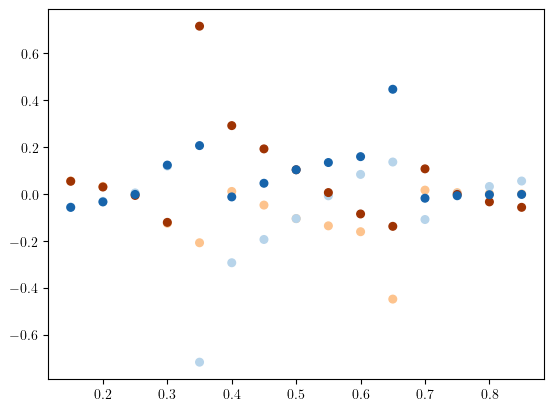

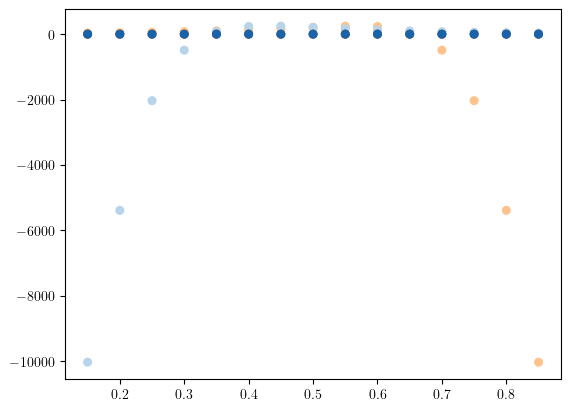

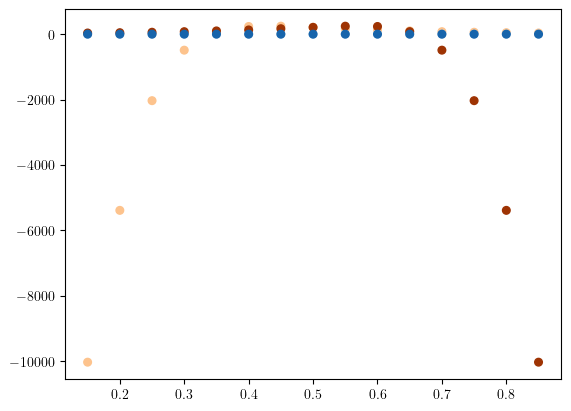

In [9]:
def grad(b,h,a,chain_length,interaction,d):
    latticeA = np.array([[0,0],[a,0]])
    latticeB = np.array([b,h])
    dist1 = latticeB-latticeA[0]
    dist2 = latticeA[1]-latticeB
    grad1 = interaction(dist1,d)
    grad2 = interaction(dist2,d)
    grad_vec = np.zeros(chain_length)
    print(grad1,grad2)
    grad_vec[0] = -grad1
    grad_vec[1:-1] = -grad2+grad1
    grad_vec[-1] = grad1-(grad1-grad2)*(chain_length%2)
    grad_vec[1:-1] *= (-1)**np.arange(chain_length-2)
    return grad_vec
    return grad1, grad2
    return dist1, dist2



def nearest_nb_Hamiltonian(b,h,a,chain_length,interaction,Delta,d):
    latticeA = np.zeros((2,chain_length//2+chain_length%2))
    latticeB = np.zeros((2,chain_length//2))
    for n in range(latticeA.shape[1]):
        latticeA[:,n] = n*np.array([1,0])*a
    for n in range(latticeB.shape[1]):
        latticeB[:,n] = n*np.array([1,0])*a + b * np.array([1,0])+h*np.array([0,1])
    dmat = np.zeros((chain_length,chain_length))
    ind = np.arange(chain_length,dtype=np.int16)
    inter_1 = interaction(latticeB[:,0]-latticeA[:,0],d)
    inter_2 = interaction(latticeB[:,0]-latticeA[:,1],d)
    dmat[ind[:-1:2],ind[1::2]]= inter_1
    dmat[ind[1::2],ind[:-1:2]]= inter_1
    dmat[ind[1:-1:2],ind[2::2]] = inter_2
    dmat[ind[2::2],ind[1:-1:2]] = inter_2
    dmat[0,0] = -inter_1
    dmat[-1,-1] = -inter_1-(inter_2-inter_1)*(chain_length%2)
    dmat[ind[1:-1],ind[1:-1]] = -inter_1-inter_2 

    # dmat[ind[2:-1:2],ind[2:-1:2]]= -Delta
    # print(inter_1,inter_2,b)
    return dmat - np.diag(np.ones(chain_length))*dmat[chain_length//2,chain_length//2]

def nearest_nb_Hamiltonian_test(alpha,b,h,a,chain_length,interaction,Delta,d):
    latticeA = np.zeros((2,chain_length//2+chain_length%2))
    latticeB = np.zeros((2,chain_length//2))
    for n in range(latticeA.shape[1]):
        latticeA[:,n] = n*np.array([1,0])*a
    for n in range(latticeB.shape[1]):
        latticeB[:,n] = n*np.array([1,0])*a + b * np.array([1,0])+h*np.array([0,1])
    dmat = np.zeros((chain_length,chain_length))
    ind = np.arange(chain_length,dtype=np.int16)
    inter_1 = interaction(latticeB[:,0]-latticeA[:,0],d)
    inter_2 = interaction(latticeB[:,0]-latticeA[:,1],d)
    dmat[ind[:-1:2],ind[1::2]]= inter_1
    dmat[ind[1::2],ind[:-1:2]]= inter_1
    dmat[ind[1:-1:2],ind[2::2]] = inter_2
    dmat[ind[2::2],ind[1:-1:2]] = inter_2
    dmat[0,0] = dmat[-1,-1] = alpha*np.max(np.abs(dmat))
    # dmat[0,0] = -inter_1
    # dmat[-1,-1] = -inter_1-(inter_2-inter_1)*(chain_length%2)
    # dmat[ind[1:-1],ind[1:-1]] = -inter_1-inter_2 


    # dmat[ind[2:-1:2],ind[2:-1:2]]= -Delta
    # print(inter_1,inter_2,b)
    return dmat #- np.diag(np.ones(chain_length))*dmat[chain_length//2,chain_length//2]


import matplotlib.cm as cm
orange = cm.Oranges
blue = cm.Blues
chain_length = 4
N = 15
# b = np.linspace(0.465,0.535,N)
b = np.linspace(0.15,0.85,N)
h = 0.2
a = 1
# d = np.array([np.sqrt(1/3),np.sqrt(2/3)])
d = np.array([1,0])
eigenvecs = np.zeros((N,chain_length))
dist1 = np.zeros(N)
dist2 = np.zeros(N)
fig, ax = plt.subplots(1,1)
fig2, ax2 = plt.subplots(1,1)
fig3, ax3 = plt.subplots(1,1)
colors = np.zeros((chain_length,4))
colors[::2] = orange(np.linspace(0.3,0.9,chain_length//2+chain_length%2))
colors[1::2] = blue(np.linspace(0.3,0.8,chain_length//2))
for i in range(N):
    dmat = nearest_nb_Hamiltonian(b[i],h,a,chain_length,lambda x, y: dip_derivative_full(x, 0, 0, y),0,d)
    dmat += np.diag(np.ones(chain_length))*(m*w**2*r**2/V)[-1]
    beta = grad(b[i],h,a,chain_length,nom_der1,d)
    # eig, vecs = np.linalg.eig(dmat)
    # eigenvecs[i,:] = sorted(eig)
    eigenvecs[i,:] = np.linalg.solve(dmat,beta)
    # ax.scatter(b[i]*np.ones(chain_length-2),beta[::3],color='0')
    # ax.scatter(b[i]*np.ones(chain_length-2),eigenvecs[i,2:],color=colors[:2],s=30)
    ax.scatter(b[i]*np.ones(chain_length),eigenvecs[i,:],color=colors,s=30)
    # dist1[i], dist2[i] = grad(b[i],h,a,chain_length,nom_der1,d)
    # ax.scatter(b[i]*np.ones(chain_length),beta,color='0')
    ax2.scatter(b[i]*np.ones(chain_length),dmat[:,0],color=colors,s=30)
    ax3.scatter(b[i]*np.ones(chain_length),dmat[:,1],color=colors,s=30)
    # ax.scatter(b[i]*np.ones(1),dist1,color='0')
    # ax.scatter(b[i]*np.ones(1),dist2,color='red')
# ax.scatter(b,dist1,color='0')
# ax.scatter(b,dist2[::-1],color='red')
# ax.set_ylim(-3,3)
plt.show()


In [94]:
# long range
def grad_long_range(b,h,a,chain_length,interaction,d,*cut):
    latticeA = np.stack((np.arange(chain_length//2+chain_length%2),np.zeros(chain_length//2+chain_length%2))).T * a
    latticeB = np.stack((np.arange(chain_length//2)*a+b,np.ones(chain_length//2)*h)).T 
    indA = np.arange(latticeA.shape[0],dtype=np.int16)
    indB = np.arange(latticeB.shape[0],dtype=np.int16)
    grad_vec = np.zeros(chain_length)
    interAA = np.zeros((latticeA.shape[0],latticeA.shape[0]-1))
    interAB = np.zeros((latticeA.shape[0],latticeB.shape[0]))
    for i in range(latticeA.shape[0]):
        interAA[i] = np.concatenate((interaction(latticeA[i]-latticeA[:i],d),-interaction(latticeA[i+1:]-latticeA[i],d)))
        interAB[i] = np.concatenate((interaction(latticeA[i]-latticeB[:i],d),-interaction(latticeB[i:]-latticeA[i],d)))
        grad_vec[2*i] = np.sum(interAA[i])+np.sum(interAB[i])
    
    interBB = np.zeros((latticeB.shape[0],latticeB.shape[0]-1))
    interBA = np.zeros((latticeB.shape[0],latticeA.shape[0]))
    for i in range(latticeA.shape[0]):
        interBB[i] = np.concatenate((interaction(latticeB[i]-latticeB[:i],d),-interaction(latticeB[i+1:]-latticeB[i],d)))
        interBA[i] = np.concatenate((interaction(latticeB[i]-latticeA[:i+1],d),-interaction(latticeA[i+1:]-latticeB[i],d)))
        grad_vec[2*i+1] = np.sum(interBB[i])+np.sum(interBA[i])
    # print(interAA)
    # print(interAB)
    # print(interBB)
    # print(interBA)
    if cut:
        return np.where(np.abs(grad_vec)<cut,0,grad_vec)
    return grad_vec

def hopping_Ham2(b,h,Delta,a,chain_length,interaction,d,*cut):
    latticeA = np.stack((np.arange(chain_length//2+chain_length%2),np.zeros(chain_length//2+chain_length%2))).T * a
    latticeB = np.stack((np.arange(chain_length//2)*a+b,np.ones(chain_length//2)*h)).T 
    
    dmat = np.zeros((chain_length,chain_length))
    interAA = np.zeros((latticeA.shape[0],latticeA.shape[0]-1))
    interAB = np.zeros((latticeA.shape[0],latticeB.shape[0]))
    for i in range(latticeA.shape[0]):
        interAA[i] = np.concatenate((interaction(latticeA[i]-latticeA[:i],d),interaction(latticeA[i+1:]-latticeA[i],d)))
        interAB[i] = np.concatenate((interaction(latticeA[i]-latticeB[:i],d),interaction(latticeB[i:]-latticeA[i],d)))
        # dmat[i,:latticeA.shape[0]] = interAA[i]
        # dmat[i,latticeA.shape[0]:] = interAB[i]
        # dmat[i,i] = - np.sum(interAA[i]) - np.sum(interAB[i]) + Delta
        dmat[2*i,2::2] = interAA[i]
        dmat[2*i,1::2] = interAB[i]
        dmat[2*i,2*i] = - np.sum(interAA[i]) - np.sum(interAB[i]) + Delta
        
    interBB = np.zeros((latticeB.shape[0],latticeB.shape[0]-1))
    interBA = np.zeros((latticeB.shape[0],latticeA.shape[0]))
    for i in range(latticeA.shape[0]):
        interBB[i] = np.concatenate((interaction(latticeB[i]-latticeB[:i],d),interaction(latticeB[i+1:]-latticeB[i],d)))
        interBA[i] = np.concatenate((interaction(latticeB[i]-latticeA[:i+1],d),interaction(latticeA[i+1:]-latticeB[i],d)))
        # dmat[latticeA.shape[0]+i,latticeA.shape[0]:] = interBB[i]
        # dmat[latticeA.shape[0]+i,:latticeA.shape[0]] = interBA[i]
        # dmat[i,i] = - np.sum(interBB[i]) - np.sum(interBA[i]) + Delta
        dmat[2*i+1,2::2] = interBB[i]
        dmat[2*i+1,1::2] = interBA[i]
        dmat[2*i+1,2*i+1] = - np.sum(interBB[i]) - np.sum(interBA[i]) + Delta
    return dmat

def hopping_Ham(b,h,Delta,a,chain_length,interaction,d,*cut):
    latticeA = np.stack((np.arange(chain_length//2+chain_length%2),np.zeros(chain_length//2+chain_length%2))).T * a
    latticeB = np.stack((np.arange(chain_length//2)*a+b,np.ones(chain_length//2)*h)).T  
    
    dmat = np.zeros((chain_length,chain_length))
    interAA = np.zeros((latticeA.shape[0],latticeA.shape[0]-1))
    interAB = np.zeros((latticeA.shape[0],latticeB.shape[0]))
    # print("lattice",latticeA[0]-latticeA[:0])
    for i in range(latticeA.shape[0]):
        interAA[i] = np.concatenate((interaction(latticeA[i]-latticeA[:i],d),interaction(latticeA[i+1:]-latticeA[i],d)))
        interAB[i] = np.concatenate((interaction(latticeA[i]-latticeB[:i],d),interaction(latticeB[i:]-latticeA[i],d)))
        # dmat[i,:latticeA.shape[0]] = interAA[i]
        # dmat[i,latticeA.shape[0]:] = interAB[i]
        # dmat[i,i] = - np.sum(interAA[i]) - np.sum(interAB[i]) + Delta
        dmat[2*i,:2*i:2] = interAA[i][:i]
        dmat[2*i,2*(i+1)::2] = interAA[i][i:]
        dmat[2*i,1::2] = interAB[i]
        dmat[2*i,2*i] = - np.sum(interAA[i]) - np.sum(interAB[i]) + Delta
        
    interBB = np.zeros((latticeB.shape[0],latticeB.shape[0]-1))
    interBA = np.zeros((latticeB.shape[0],latticeA.shape[0]))
    for i in range(latticeA.shape[0]):
        interBB[i] = np.concatenate((interaction(latticeB[i]-latticeB[:i],d),interaction(latticeB[i+1:]-latticeB[i],d)))
        interBA[i] = np.concatenate((interaction(latticeB[i]-latticeA[:i+1],d),interaction(latticeA[i+1:]-latticeB[i],d)))
        # dmat[latticeA.shape[0]+i,latticeA.shape[0]:] = interBB[i]
        # dmat[latticeA.shape[0]+i,:latticeA.shape[0]] = interBA[i]
        # dmat[i,i] = - np.sum(interBB[i]) - np.sum(interBA[i]) + Delta
        dmat[2*i+1,1:2*i+1:2] = interBB[i][:i]
        dmat[2*i+1,2*(i+1)+1::2] = interBB[i][i:]
        dmat[2*i+1,::2] = interBA[i]
        dmat[2*i+1,2*i+1] = - np.sum(interBB[i]) - np.sum(interBA[i]) + Delta
    
    if cut:
        return np.where(np.abs(dmat)<cut,0,dmat) #+ np.diag(np.ones(chain_length)*np.max(np.abs(dmat)))
    return dmat #- np.diag(np.ones(chain_length))*dmat[chain_length//2,chain_length//2]

def hopping_Ham_alpha(b,h,alpha,a,chain_length,interaction,d,*cut):
    latticeA = np.stack((np.arange(chain_length//2+chain_length%2),np.zeros(chain_length//2+chain_length%2))).T * a
    latticeB = np.stack((np.arange(chain_length//2)*a+b,np.ones(chain_length//2)*h)).T  
    
    dmat = np.zeros((chain_length,chain_length))
    interAA = np.zeros((latticeA.shape[0],latticeA.shape[0]-1))
    interAB = np.zeros((latticeA.shape[0],latticeB.shape[0]))
    # print("lattice",latticeA[0]-latticeA[:0])
    for i in range(latticeA.shape[0]):
        interAA[i] = np.concatenate((interaction(latticeA[i]-latticeA[:i],d),interaction(latticeA[i+1:]-latticeA[i],d)))
        interAB[i] = np.concatenate((interaction(latticeA[i]-latticeB[:i],d),interaction(latticeB[i:]-latticeA[i],d)))
        # dmat[i,:latticeA.shape[0]] = interAA[i]
        # dmat[i,latticeA.shape[0]:] = interAB[i]
        # dmat[i,i] = - np.sum(interAA[i]) - np.sum(interAB[i]) + Delta
        dmat[2*i,:2*i:2] = interAA[i][:i]
        dmat[2*i,2*(i+1)::2] = interAA[i][i:]
        dmat[2*i,1::2] = interAB[i]
        dmat[2*i,2*i] = (- np.sum(interAA[i]) - np.sum(interAB[i]) )* alpha
        
    interBB = np.zeros((latticeB.shape[0],latticeB.shape[0]-1))
    interBA = np.zeros((latticeB.shape[0],latticeA.shape[0]))
    for i in range(latticeA.shape[0]):
        interBB[i] = np.concatenate((interaction(latticeB[i]-latticeB[:i],d),interaction(latticeB[i+1:]-latticeB[i],d)))
        interBA[i] = np.concatenate((interaction(latticeB[i]-latticeA[:i+1],d),interaction(latticeA[i+1:]-latticeB[i],d)))
        # dmat[latticeA.shape[0]+i,latticeA.shape[0]:] = interBB[i]
        # dmat[latticeA.shape[0]+i,:latticeA.shape[0]] = interBA[i]
        # dmat[i,i] = - np.sum(interBB[i]) - np.sum(interBA[i]) + Delta
        dmat[2*i+1,1:2*i+1:2] = interBB[i][:i]
        dmat[2*i+1,2*(i+1)+1::2] = interBB[i][i:]
        dmat[2*i+1,::2] = interBA[i]
        dmat[2*i+1,2*i+1] = (- np.sum(interBB[i]) - np.sum(interBA[i])) * alpha
        
    # dmat[0,0] = dmat[-1,-1] = alpha*np.max(np.abs(dmat))
    if cut:
        return np.where(np.abs(dmat)<cut,0,dmat) #+ np.diag(np.ones(chain_length)*np.max(np.abs(dmat)))
    return dmat - np.diag(np.ones(chain_length))*dmat[chain_length//2,chain_length//2]




def hopping_Ham_block(b,h,Delta,a,chain_length,interaction,d,*cut):
    latticeA = np.stack((np.arange(chain_length//2+chain_length%2),np.zeros(chain_length//2+chain_length%2))).T * a
    latticeB = np.stack((np.arange(chain_length//2)*a+b,np.ones(chain_length//2)*h)).T  
    
    dmat = np.zeros((chain_length,chain_length))
    interAA = np.zeros((latticeA.shape[0],latticeA.shape[0]-1))
    interAB = np.zeros((latticeA.shape[0],latticeB.shape[0]))
    lenA = latticeA.shape[0]
    lenB = latticeB.shape[0]
    # print("lattice",latticeA[0]-latticeA[:0])
    for i in range(latticeA.shape[0]):
        interAA[i] = np.concatenate((interaction(latticeA[i]-latticeA[:i],d),interaction(latticeA[i+1:]-latticeA[i],d)))
        interAB[i] = np.concatenate((interaction(latticeA[i]-latticeB[:i],d),interaction(latticeB[i:]-latticeA[i],d)))
        # dmat[i,:latticeA.shape[0]] = interAA[i]
        # dmat[i,latticeA.shape[0]:] = interAB[i]
        # dmat[i,i] = - np.sum(interAA[i]) - np.sum(interAB[i]) + Delta
        dmat[i,:i] = interAA[i][:i]
        dmat[i,i+1:lenA] = interAA[i][i:]
        dmat[i,lenA:] = interAB[i]
        dmat[i,i] = - np.sum(interAA[i]) - np.sum(interAB[i]) + Delta
        
    interBB = np.zeros((latticeB.shape[0],latticeB.shape[0]-1))
    interBA = np.zeros((latticeB.shape[0],latticeA.shape[0]))
    
    for i in range(latticeA.shape[0]):
        interBB[i] = np.concatenate((interaction(latticeB[i]-latticeB[:i],d),interaction(latticeB[i+1:]-latticeB[i],d)))
        interBA[i] = np.concatenate((interaction(latticeB[i]-latticeA[:i+1],d),interaction(latticeA[i+1:]-latticeB[i],d)))
        # dmat[latticeA.shape[0]+i,latticeA.shape[0]:] = interBB[i]
        # dmat[latticeA.shape[0]+i,:latticeA.shape[0]] = interBA[i]
        # dmat[i,i] = - np.sum(interBB[i]) - np.sum(interBA[i]) + Delta
        dmat[lenA+i,lenA:lenA+i] = interBB[i][:i]
        dmat[lenA+i,lenA+i+1:] = interBB[i][i:]
        dmat[lenA+i,:lenA] = interBA[i]
        dmat[lenA+i,lenA+i] = - np.sum(interBB[i]) - np.sum(interBA[i]) + Delta
    
    if cut:
        return np.where(np.abs(dmat)<cut,0,dmat) #+ np.diag(np.ones(chain_length)*np.max(np.abs(dmat)))
    return dmat# + np.diag(np.ones(chain_length)*np.max(np.abs(dmat)))




def hopping_Ham_xy(b,h,Delta,a,chain_length,interaction,d,*cut):
    Hamxx = hopping_Ham(b,h,Delta,a,chain_length,lambda r,d:interaction(r,0,0,d),d,*cut)
    Hamxy = hopping_Ham(b,h,Delta,a,chain_length,lambda r,d:interaction(r,0,1,d),d,*cut)
    Hamyy = hopping_Ham(b,h,Delta,a,chain_length,lambda r,d:interaction(r,1,1,d),d,*cut)

    dmat = np.zeros((2*chain_length,2*chain_length))
    for i in range(chain_length):
        dmat[2*i,::2] = Hamxx[i,:]
        dmat[2*i,1::2] = Hamxy[i,:]
        dmat[2*i+1,::2] = Hamxy[i,:]
        dmat[2*i+1,1::2] = Hamyy[i,:]
    return dmat

def hopping_Ham_xy_alpha(b,h,alpha,a,chain_length,interaction,d,*cut):
    Hamxx = hopping_Ham_alpha(b,h,alpha,a,chain_length,lambda r,d:interaction(r,0,0,d),d,*cut)
    Hamxy = hopping_Ham(b,h,0,a,chain_length,lambda r,d:interaction(r,0,1,d),d,*cut)
    Hamyy = hopping_Ham_alpha(b,h,alpha,a,chain_length,lambda r,d:interaction(r,1,1,d),d,*cut)

    dmat = np.zeros((2*chain_length,2*chain_length))
    for i in range(chain_length):
        dmat[2*i,::2] = Hamxx[i,:]
        dmat[2*i,1::2] = Hamxy[i,:]
        dmat[2*i+1,::2] = Hamxy[i,:]
        dmat[2*i+1,1::2] = Hamyy[i,:]
    return dmat

def hopping_Ham_xy_block(b,h,Delta,a,chain_length,interaction,d,*cut):
    Hamxx = hopping_Ham_block(b,h,Delta,a,chain_length,lambda r,d:interaction(r,0,0,d),d,*cut)
    Hamxy = hopping_Ham_block(b,h,Delta,a,chain_length,lambda r,d:interaction(r,0,1,d),d,*cut)
    Hamyy = hopping_Ham_block(b,h,Delta,a,chain_length,lambda r,d:interaction(r,1,1,d),d,*cut)

    dmat = np.zeros((2*chain_length,2*chain_length))
    for i in range(chain_length):
        dmat[2*i,::2] = Hamxx[i,:]
        dmat[2*i,1::2] = Hamxy[i,:]
        dmat[2*i+1,::2] = Hamxy[i,:]
        dmat[2*i+1,1::2] = Hamyy[i,:]
    return dmat

def hopping_Ham_xy_bblock(b,h,Delta,a,chain_length,interaction,d,*cut):
    Hamxx = hopping_Ham_block(b,h,Delta,a,chain_length,lambda r,d:interaction(r,0,0,d),d,*cut)
    Hamxy = hopping_Ham_block(b,h,Delta,a,chain_length,lambda r,d:interaction(r,0,1,d),d,*cut)
    Hamyy = hopping_Ham_block(b,h,Delta,a,chain_length,lambda r,d:interaction(r,1,1,d),d,*cut)

    dmat = np.zeros((2*chain_length,2*chain_length))
    lenA = chain_length//2+chain_length%2
    lenB = chain_length//2
    dmat[:lenA,:lenA] = Hamxx[:lenA,:lenA]
    dmat[:lenA,lenA:2*lenA] = Hamxy[:lenA,:lenA]
    dmat[lenA:2*lenA,:lenA] = Hamxy[:lenA,:lenA]
    dmat[lenA:2*lenA,lenA:2*lenA] = Hamyy[:lenA,:lenA]
    dmat[:lenA,2*lenA:2*lenA+lenB] = Hamxx[:lenA,lenA:]
    dmat[:lenA,2*lenA+lenB:] = Hamxy[:lenA,lenA:]
    dmat[lenA:2*lenA,2*lenA:2*lenA+lenB] = Hamxy[:lenA,lenA:]
    dmat[lenA:2*lenA,2*lenA+lenB:] = Hamyy[:lenA,lenA:]

    dmat[2*lenA:2*lenA+lenB,:lenA] = Hamxx[lenA:,:lenA]
    dmat[2*lenA:2*lenA+lenB,lenA:2*lenA] = Hamxy[lenA:,:lenA]
    dmat[2*lenA:2*lenA+lenB,2*lenA:2*lenA+lenB] = Hamxx[lenA:,lenA:]
    dmat[2*lenA:2*lenA+lenB,2*lenA+lenB:] =  Hamxy[lenA:,lenA:]
    dmat[2*lenA+lenB:,:lenA] = Hamxy[lenA:,:lenA]
    dmat[2*lenA+lenB:,lenA:2*lenA] = Hamyy[lenA:,:lenA]
    dmat[2*lenA+lenB:,2*lenA:2*lenA+lenB] = Hamxy[lenA:,lenA:]
    dmat[2*lenA+lenB:,2*lenA+lenB:] = Hamyy[lenA:,lenA:]
    return dmat





def hopping_Ham_cut(b,h,Delta,a,chain_length,interaction,d,*cut):
    latticeA = np.stack((np.arange(chain_length//2+chain_length%2),np.zeros(chain_length//2+chain_length%2))).T * a
    latticeB = np.stack((np.arange(chain_length//2)*a+b,np.ones(chain_length//2)*h)).T  
    
    dmat = np.zeros((chain_length,chain_length))
    interAA = np.zeros((latticeA.shape[0],latticeA.shape[0]-1))
    interAB = np.zeros((latticeA.shape[0],latticeB.shape[0]))
    # print("lattice",latticeA[0]-latticeA[:0])
    def f(x):
        if x<0:
            return 0
        elif x>=chain_length:
            return chain_length
        else:
            return x
    for i in range(latticeA.shape[0]):
        interAA[i] = np.concatenate((interaction(latticeA[i]-latticeA[f(i-cut):i],d),interaction(latticeA[i+1:f(i+cut+1)]-latticeA[i],d)))
        interAB[i] = np.concatenate((interaction(latticeA[i]-latticeB[f(i-cut):i],d),interaction(latticeB[i:f(i+cut)]-latticeA[i],d)))
        # dmat[i,:latticeA.shape[0]] = interAA[i]
        # dmat[i,latticeA.shape[0]:] = interAB[i]
        # dmat[i,i] = - np.sum(interAA[i]) - np.sum(interAB[i]) + Delta
        dmat[2*i,:2*i:2] = interAA[i][:i]
        dmat[2*i,2*(i+1)::2] = interAA[i][i:]
        dmat[2*i,1::2] = interAB[i]
        dmat[2*i,2*i] = - np.sum(interAA[i]) - np.sum(interAB[i]) + Delta
        
    interBB = np.zeros((latticeB.shape[0],latticeB.shape[0]-1))
    interBA = np.zeros((latticeB.shape[0],latticeA.shape[0]))
    for i in range(latticeA.shape[0]):
        interBB[i] = np.concatenate((interaction(latticeB[i]-latticeB[f(i-cut):i],d),interaction(latticeB[i+1:f(i+cut+1)]-latticeB[i],d)))
        interBA[i] = np.concatenate((interaction(latticeB[i]-latticeA[f(i+1-cut):i+1],d),interaction(latticeA[i+1:f(i+1+cut)]-latticeB[i],d)))
        # dmat[latticeA.shape[0]+i,latticeA.shape[0]:] = interBB[i]
        # dmat[latticeA.shape[0]+i,:latticeA.shape[0]] = interBA[i]
        # dmat[i,i] = - np.sum(interBB[i]) - np.sum(interBA[i]) + Delta
        dmat[2*i+1,1:2*i+1:2] = interBB[i][:i]
        dmat[2*i+1,2*(i+1)+1::2] = interBB[i][i:]
        dmat[2*i+1,::2] = interBA[i]
        dmat[2*i+1,2*i+1] = - np.sum(interBB[i]) - np.sum(interBA[i]) + Delta
    return dmat

def hopping_Ham_k(k,b,h,Delta,a,chain_length,interaction,d):
    latticeA = np.stack((np.arange(chain_length//2+chain_length%2),np.zeros(chain_length//2+chain_length%2))).T * a
    latticeB = np.stack((np.arange(chain_length//2)*a+b,np.ones(chain_length//2)*h)).T  
    
    dmat = np.zeros((2,2),dtype=np.complex128)
    
    distAA = np.zeros((latticeA.shape[0]-1,2))
    distAB = np.zeros((latticeB.shape[0],2))
    # print("lattice",latticeA[0]-latticeA[:0])
    i = chain_length//4
    distAA = np.concatenate((-latticeA[:i]+latticeA[i],latticeA[i+1:]-latticeA[i]))
    interAA = interaction(distAA,d)
    distAB = np.concatenate((-latticeB[:i]+latticeA[i],latticeB[i:]-latticeA[i]))
    interAB = interaction(distAB,d)

    distBB = np.zeros((latticeB.shape[0]-1,2))
    distBA = np.zeros((latticeA.shape[0],2))
    
    distBB = np.concatenate((-latticeB[:i]+latticeB[i],latticeB[i+1:]-latticeB[i]))
    interBB = interaction(distBB,d)
    distBA = np.concatenate((-latticeA[:i+1]+latticeB[i],latticeA[i+1:]-latticeB[i]))
    interBA = interaction(distBA,d)
        # dmat[i,:latticeA.shape[0]] = interAA[i]
        # dmat[i,latticeA.shape[0]:] = interAB[i]
        # dmat[i,i] = - np.sum(interAA[i]) - np.sum(interAB[i]) + Delta
    cell_list = [n for n in range(chain_length//2)]
    
    unit_distAA = (np.array(cell_list[:i] +cell_list[i+1:])-i)*a
    unit_distAB = (np.array(cell_list)-i)*a
    dmat[0,0] = np.sum(interAA*np.exp(-1j*k*unit_distAA))
    dmat[0,1] = np.sum(interAB*np.exp(-1j*k*unit_distAB))
    dmat[0,0] += (- np.sum(interAA) - np.sum(interAB) + Delta)
    dmat[1,0] = np.sum(interBA*np.exp(-1j*k*unit_distAB))
    dmat[1,1] = np.sum(interBB*np.exp(-1j*k*unit_distAA))
    dmat[1,1] += (- np.sum(interBB) - np.sum(interBA) + Delta)

    return dmat

def BdG_Ham(b,h,Delta,a,chain_length,interaction,d):
    dmat_diag = hopping_Ham(b,h,Delta,a,chain_length,interaction,d)
    dmat_off = hopping_Ham(b,h,0,a,chain_length,interaction,d)
    dmat_BdG = np.zeros((2*chain_length,2*chain_length))
    dmat_BdG[:chain_length,:chain_length] = dmat_diag
    dmat_BdG[:chain_length,chain_length:] = dmat_off
    dmat_BdG[chain_length:,chain_length:] = -dmat_diag
    dmat_BdG[chain_length:,:chain_length] = -dmat_off
    return dmat_BdG

def BdG_Ham_k(k,b,h,Delta,a,chain_length,interaction,d):
    dmat_diag = hopping_Ham_k(k,b,h,Delta,a,chain_length,interaction,d)
    dmat_off = hopping_Ham_k(k,b,h,0,a,chain_length,interaction,d)
    dmat_BdG = np.zeros((4,4),dtype=np.complex128)
    dmat_BdG[:2,:2] = dmat_diag
    dmat_BdG[:2,2:4] = dmat_off
    dmat_BdG[2:4,:2] = -dmat_off
    dmat_BdG[2:4,2:4] = -dmat_diag
    
    return dmat_BdG

chain_length = 4
b0 = 0.3
h = 0.2
a=1
dmat = hopping_Ham(b0,h,0,a,chain_length,lambda x, y: dip_derivative_full_vec(x,y),d)
dmat_nn = nearest_nb_Hamiltonian(b0,h,a,chain_length,lambda x, y: dip_derivative_full(x,0,0,y),0,d)
# # # gradient_nn = grad(b,h,a,chain_length,nom_der1,d)
# # # gradient = grad_long_range(b,h,a,chain_length,nom_der1_vec,d)
# # # gradient, gradient_nn
dmat, dmat_nn

(array([[-2.95089598e+03,  2.94865224e+03,  0.00000000e+00,
          2.24373504e+00],
        [ 2.94865224e+03, -2.89533010e+03, -5.33221421e+01,
          0.00000000e+00],
        [ 0.00000000e+00, -5.33221421e+01, -2.89533010e+03,
          2.94865224e+03],
        [ 2.24373504e+00,  0.00000000e+00,  2.94865224e+03,
         -2.95089598e+03]]),
 array([[ -53.32214211, 2948.65224366,    0.        ,    0.        ],
        [2948.65224366,    0.        ,  -53.32214211,    0.        ],
        [   0.        ,  -53.32214211,    0.        , 2948.65224366],
        [   0.        ,    0.        , 2948.65224366,  -53.32214211]]))

In [11]:
length = 64
from random import random
b0 =random()
h = random()
print(b0,h)
Ham = hopping_Ham_xy(b0,h,0,a,length,dip_derivative_ffull_vec,d)
Ham_block = hopping_Ham_xy_block(b0,h,0,a,length,dip_derivative_ffull_vec,d)
Ham_bblock = hopping_Ham_xy_bblock(b0,h,0,a,length,dip_derivative_ffull_vec,d)
eig = np.sort(np.linalg.eigvals(Ham))
eig_block = np.sort(np.linalg.eigvals(Ham_block))
eig_bblock = np.sort(np.linalg.eigvals(Ham_bblock))
np.max(np.abs(eig- eig_block)), np.max(np.abs(eig-eig_bblock))


0.26808827224716114 0.4442077919697347


(np.float64(5.229594535194337e-12), np.float64(3.637978807091713e-12))

In [12]:
def grad_long_range_spph2(b,h,a,chain_length,interaction,d):
    latticeA = np.stack((np.arange(chain_length//2+chain_length%2),np.zeros(chain_length//2+chain_length%2))).T * a
    latticeB = np.stack((np.arange(chain_length//2)*a+b,np.ones(chain_length//2)*h)).T 
    indA = np.arange(latticeA.shape[0],dtype=np.int16)
    indB = np.arange(latticeB.shape[0],dtype=np.int16)
    grad_vec = np.zeros((chain_length**2-chain_length)//2)
    interAA = np.zeros((latticeA.shape[0],latticeA.shape[0]-1))
    interAB = np.zeros((latticeA.shape[0],latticeB.shape[0]))
    for i in range(latticeA.shape[0]):
        interAA[i,:i] = interaction(latticeA[i]-latticeA[:i],d)
        interAB[i,:i] = interaction(latticeA[i]-latticeB[:i],d)
        grad_vec[(2*i-1)*i:(2*i+1)*i:2] = interAA[i,:i]
        grad_vec[(2*i-1)*i+1:(2*i+1)*i:2] = interAB[i,:i]
        # grad_vec[2*i] = np.sum(interAA[i])+np.sum(interAB[i])
    
    interBB = np.zeros((latticeB.shape[0],latticeB.shape[0]-1))
    interBA = np.zeros((latticeB.shape[0],latticeA.shape[0]))
    for i in range(latticeA.shape[0]):
        interBB[i,:i] = interaction(latticeB[i]-latticeB[:i],d)
        interBA[i,:i+1] = interaction(latticeB[i]-latticeA[:i+1],d)
        grad_vec[(2*i+1)*i+1:(2*i+1)*(2*i+2)//2:2] = interBB[i,:i]
        grad_vec[(2*i+1)*i:(2*i+1)*(2*i+2)//2:2] = interBA[i,:i+1]
    # print(interAA)
    # print(interAB)
    # print(interBB)
    # print(interBA)
    return grad_vec

def grad_long_range_spph(b,h,a,chain_length,interaction,d):
    latticeA = np.stack((np.arange(chain_length//2+chain_length%2),np.zeros(chain_length//2+chain_length%2))).T * a
    latticeB = np.stack((np.arange(chain_length//2)*a+b,np.ones(chain_length//2)*h)).T 
    lattice = np.zeros((chain_length,2))
    lattice[::2] = latticeA
    lattice[1::2] = latticeB
    
    grad_vec = np.zeros((chain_length**2-chain_length)//2)
    
    for i in range(chain_length):
        for j in range(i):
            inter = interaction(lattice[i]-lattice[j],d)
            grad_vec[(i-1)*i//2+j] =  inter
    return grad_vec

def hopping_Ham_spph(b,h,a,chain_length,interaction,d):
    latticeA = np.stack((np.arange(chain_length//2+chain_length%2),np.zeros(chain_length//2+chain_length%2))).T * a
    latticeB = np.stack((np.arange(chain_length//2)*a+b,np.ones(chain_length//2)*h)).T 
    lattice = np.zeros((chain_length,2))
    lattice[::2] = latticeA
    lattice[1::2] = latticeB
    dmat = np.zeros(((chain_length**2-chain_length)//2,chain_length))
    # print("lattice",latticeA[0]-latticeA[:0])
    for i in range(lattice.shape[0]):
        for j in range(i):
            inter = interaction(lattice[i]-lattice[j],d)
            dmat[(i-1)*i//2+j,i] =  inter
            dmat[(i-1)*i//2+j,j] = -inter
        
    return dmat

chain_length = 4
b = 0.3
h = 0.2
g = grad_long_range_spph(b,h,a,chain_length,nom_der1,d)
g2 = grad_long_range_spph2(b,h,a,chain_length,nom_der1_vec,d)
dmat = hopping_Ham_spph(b,h,a,chain_length,lambda x, y: dip_derivative_full(x,0,0,y),d)

dis = np.linalg.lstsq(dmat,g)[0]
print(np.linalg.norm(g-dmat@dis),dis)
g2-g
def matrix_eq(dis,A,B):
    return np.sum((A@dis-B)**2)+np.linalg.norm(dis)#,method="Nelder-Mead"

# minimize(matrix_eq,x0=np.ones(chain_length),args=(dmat,g))
    

5.640852667260002 [ 0.01438177 -0.12452199  0.12452199 -0.01438177]


In [13]:
import numpy as np

def solve_dx(dy, rx, ry):
    """
    Solves for d_x in the equation:
    3 - 15*d_x^2 = -1/r^5 * (3 - 15*(r_x*d_x + r_y*d_y)^2)
    
    Returns:
        tuple: (dx1, dx2) containing the two solutions.
    """
    discriminant = discrim(dy,rx,ry)
    r = np.sqrt(rx**2+ry**2)
    rx_hat = rx/r
    ry_hat = ry/r
    A = 5.0 * (r**5 + rx_hat**2)
    B = -10.0 * rx_hat * ry_hat * dy
    C = 5.0 * ry_hat**2 * dy**2 - (r**5 + 1.0)
    
    
    # return discriminant
    # Handle real and complex cases seamlessly using numpy sqrt
    # sqrt_disc = np.sqrt(discriminant + 0j) if discriminant < 0 else np.sqrt(discriminant)
    sqrt_disc = np.sqrt(discriminant)
    dx1 = (-B + sqrt_disc) / (2.0 * A)
    dx2 = (-B - sqrt_disc) / (2.0 * A)
    
    return dx1, dx2

def equation(dy, rx, ry):
    """
    Solves for d_x in the equation:
    3 - 15*d_x^2 = -1/r^5 * (3 - 15*(r_x*d_x + r_y*d_y)^2)
    Returns:
        tuple: (dx1, dx2) containing the two solutions.
    """
    max_dy = np.sqrt(disc(rx-1,ry))
    if np.abs(dy)>max_dy-1e-2 or np.abs(dy)>1:
        return 10**8+dy**2
    t,dx = solve_dx(dy,rx-1,ry)
    # dx, t = solve_dx(dy,rx-1,ry)
    if dx**2+dy**2>1:
        return 10**8+dx**2+dy**2
    r = np.sqrt(rx**2+ry**2)
    rx_hat = rx/r
    ry_hat = ry/r
    A = 5.0 * (r**5 + rx_hat**2)
    B = -10.0 * rx_hat * ry_hat * dy
    C = 5.0 * ry_hat**2 * dy**2 - (r**5 + 1.0)
    
    return A*dx**2+B*dx+C

def disc(rx, ry):
    
    r = np.sqrt(rx**2+ry**2)
    # rx_hat = rx_hat/r
    # ry_hat = ry_hat/r
    return ( r**2 + rx**2 + rx**2/r**5+r**7)/5/ry**2

def discrim(dy,rx,ry):
    r = np.sqrt(rx**2+ry**2)
    rx_hat = rx/r
    ry_hat = ry/r
    A = 5.0 * (r**5 + rx_hat**2)
    B = -10.0 * rx_hat * ry_hat * dy
    C = 5.0 * ry_hat**2 * dy**2 - (r**5 + 1.0)
    
    discriminant = B**2 - 4.0 * A * C
    return discriminant

def find_dip(rx,ry):
    
    r = root_scalar(equation,args=(rx,ry),x0=0)
    if r.converged:
        return r.root
    else:
        return np.nan

In [14]:
# def disc(rx, ry):
    
#     r = np.sqrt(rx**2+ry**2)
#     rx = rx/r
#     ry = ry/r
#     return ( 1 + rx**2 + rx**2/r**5+r**5)/5/ry**2

N = 30
rx = np.linspace(0.01,1,N)
ry = rx
r = np.meshgrid(rx,ry)
dy = np.zeros((N,N))
r[0][i,j]
# # display(r)
dis = np.sqrt(disc(*r))-1e-2
sumxx = np.zeros((N,N))
# disval = solve_dx(dis,*r)[1]
# disval = discrim(dis,*r)
for i in range(N):
    for j in range(N):
        dy[i,j]= np.real(find_dip(r[0][i,j],r[1][i,j]))
        r_vec1 = np.array([r[0][i,j],r[1][i,j]])
        r_vec2 = r_vec1 - np.array([1,0])
        d = np.array([solve_dx(dy[i,j],r[0][i,j],r[1][i,j])[0],dy[i,j]])
        sumxx[i,j] = dip_derivative_full(r_vec1,0,0,d)+dip_derivative_full(r_vec2,0,0,d)
fig, ax = plt.subplots(1,1)
# im = ax.imshow(np.where(np.abs(dis)>1,np.nan,dis))
# im = ax.imshow(np.where(np.abs(dy)>1,np.nan,dy), extent=[0.01, 1, 0.01, 1], origin="lower")
im = ax.imshow(dy, extent=[0.01, 1, 0.01, 1], origin="lower")
# im = ax.imshow(np.where(disval>=0,np.nan,disval), extent=[0.01, 1, 0.01, 1], origin="lower")
cmap = fig.colorbar(im,ax=ax)
fig, ax = plt.subplots(1,1)
disval = solve_dx(dy,*r)[1]
# im = ax.imshow(np.where(np.abs(disval)>1,np.nan,disval), extent=[0.01, 1, 0.01, 1], origin="lower")
im = ax.imshow(disval, extent=[0.01, 1, 0.01, 1], origin="lower")
# im = ax.imshow(np.where(np.abs(sumxx)>1,np.nan,sumxx), extent=[0.01, 1, 0.01, 1], origin="lower")
cmap = fig.colorbar(im,ax=ax)
# Ny = 5
# dy = np.linspace(-1,1)
# for i in range(Ny):
#     dis = equation(dy[i],*r)
#     fig, ax = plt.subplots(1,1)
#     im = ax.imshow(np.where(np.abs(dis)>1,np.nan,dis))
#     cmap = fig.colorbar(im,ax=ax)

NameError: name 'j' is not defined

In [ ]:
import numpy as np
from scipy.optimize import least_squares


def c_element(r_vec, d_vec, alpha: int, beta: int) -> float:
    r_vec = np.asarray(r_vec, dtype=float)
    d_vec = np.asarray(d_vec, dtype=float)

    r = np.linalg.norm(r_vec)
    r_hat = r_vec / r
    d_hat = d_vec / np.linalg.norm(d_vec)

    r_dot_d = np.dot(r_hat, d_hat)
    kronecker = 1.0 if alpha == beta else 0.0

    term1 = kronecker * (-3.0 + 15.0 * r_dot_d**2)
    term2 = -6.0 * d_hat[alpha] * d_hat[beta]
    term3 = (
        30.0
        * ((d_hat[alpha] * r_vec[beta] + d_hat[beta] * r_vec[alpha]) / r)
        * r_dot_d
    )
    term4 = (
        15.0
        * (r_vec[alpha] * r_vec[beta] / r**2)
        * (1.0 - 7.0 * r_dot_d**2)
    )

    return term1 + term2 + term3 + term4


def joint_residuals(angles: list, r1_vec, r2_vec, r3_vec) -> np.ndarray:
    """Computes 4 residuals: [f_xx(1,2), f_yy(1,2), f_xx(1,3), f_yy(1,3)]."""
    theta, phi = angles
    d_vec = np.array(
        [np.sin(theta) * np.cos(phi), np.sin(theta) * np.sin(phi), np.cos(theta)]
    )

    r1_3d = np.append(r1_vec, 0.0) if len(r1_vec) == 2 else r1_vec
    r2_3d = np.append(r2_vec, 0.0) if len(r2_vec) == 2 else r2_vec
    r3_3d = np.append(r3_vec, 0.0) if len(r3_vec) == 2 else r3_vec

    n1, n2, n3 = (
        np.linalg.norm(r1_3d),
        np.linalg.norm(r2_3d),
        np.linalg.norm(r3_3d),
    )

    # Tensor components for r1, r2, r3
    c_xx_1, c_yy_1 = c_element(r1_3d, d_vec, 0, 0), c_element(r1_3d, d_vec, 1, 1)
    c_xx_2, c_yy_2 = c_element(r2_3d, d_vec, 0, 0), c_element(r2_3d, d_vec, 1, 1)
    c_xx_3, c_yy_3 = c_element(r3_3d, d_vec, 0, 0), c_element(r3_3d, d_vec, 1, 1)

    # Residuals for pair (r1, r2)
    f_xx_12 = (c_xx_1 / n1**5) + (c_xx_2 / n2**5)
    f_yy_12 = (c_yy_1 / n1**5) + (c_yy_2 / n2**5)

    # Residuals for pair (r1, r3)
    f_xx_13 = (c_xx_1 / n1**5) + (c_xx_3 / n3**5)
    f_yy_13 = (c_yy_1 / n1**5) + (c_yy_3 / n3**5)

    return np.array([f_xx_12, f_yy_12, f_xx_13, f_yy_13])


def find_joint_dipole(x: float, y: float, initial_guess=None):
    """Finds a single dipole orientation d_hat that satisfies the tensor equations

    simultaneously for r1=(1,0), r2=(x,y), and r3=(x-1,y).

    Returns:
        d_hat: Unit dipole vector array [dx, dy, dz].
        res: Optimization result containing residuals and cost.
    """
    r1 = np.array([1.0, 0.0])
    r2 = np.array([x, y])
    r3 = np.array([x - 1.0, y])

    x0 = [np.pi / 4, np.pi / 4] if initial_guess is None else initial_guess

    res = least_squares(joint_residuals, x0, args=(r1, r2, r3))

    theta, phi = res.x
    return theta, phi
    d_hat = np.array(
        [np.sin(theta) * np.cos(phi), np.sin(theta) * np.sin(phi), np.cos(theta)]
    )

    return d_hat, res

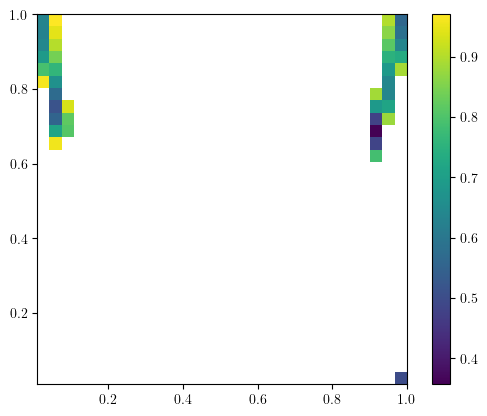

In [ ]:
N = 30
rx = np.linspace(0.01,1,N)
ry = rx
r = np.meshgrid(rx,ry)
# d_vecs = np.zeros((N,N,3))
angles = np.zeros((N,N,2))
condition = np.zeros((N,N))
for i in range(N):
    for j in range(N):
        x, y = r[0][i,j],r[1][i,j]
        angles[i,j] = find_joint_dipole(x,y)
        r1 = np.array([1.0, 0.0])
        r2 = np.array([x, y])
        r3 = np.array([x - 1.0, y])
        condition[i,j] = np.linalg.norm(joint_residuals(angles[i,j],r1,r2,r3))
fig, ax = plt.subplots(1,1)
# im = ax.imshow(np.where(np.abs(dis)>1,np.nan,dis))
im = ax.imshow(np.where(np.abs(condition)>1,np.nan,condition), extent=[0.01, 1, 0.01, 1], origin="lower")
# im = ax.imshow(condition, extent=[0.01, 1, 0.01, 1], origin="lower")
# im = ax.imshow(np.where(disval>=0,np.nan,disval), extent=[0.01, 1, 0.01, 1], origin="lower")
cmap = fig.colorbar(im,ax=ax)
# fig, ax = plt.subplots(1,1)
# disval = solve_dx(dy,*r)[0]
# # im = ax.imshow(np.where(np.abs(disval)>1,np.nan,disval), extent=[0.01, 1, 0.01, 1], origin="lower")
# # im = ax.imshow(disval, extent=[0.01, 1, 0.01, 1], origin="lower")
# im = ax.imshow(np.where(np.abs(sumxx)>1,np.nan,sumxx), extent=[0.01, 1, 0.01, 1], origin="lower")
# cmap = fig.colorbar(im,ax=ax)

In [ ]:
import numpy as np
from scipy.optimize import least_squares


def solve_dx_branches(dy: float, r2_vec):
    """Analytically solves the first equation for d_x using the quadratic formula.

    Returns the two real solutions (dx1, dx2), or (None, None) if unphysical.
    """
    r2 = np.linalg.norm(r2_vec)
    rx_hat = r2_vec[0] / r2
    ry_hat = r2_vec[1] / r2

    A = 5.0 * (r2**5 + rx_hat**2)
    B = -10.0 * rx_hat * ry_hat * dy
    C = 5.0 * ry_hat**2 * dy**2 - (r2**5 + 1.0)

    discriminant = B**2 - 4.0 * A * C
    if discriminant < 0:
        return None, None

    sqrt_disc = np.sqrt(discriminant)
    dx1 = (-B + sqrt_disc) / (2.0 * A)
    dx2 = (-B - sqrt_disc) / (2.0 * A)

    return dx1, dx2


def joint_residuals_3eq(params: list, r1_vec, r2_vec, r3_vec) -> np.ndarray:
    """Computes the 3 remaining residuals [f_yy(1,2), f_xx(1,3), f_yy(1,3)]

    by substituting the analytical d_x branches.
    """
    dy = params[0]
    dz = params[1] if len(params) > 1 else 0.0

    # 1. Solve d_x analytically for pair (r1, r2)
    dx1, dx2 = solve_dx_branches(dy, r2_vec)

    if dx1 is None:
        return np.array([1e6, 1e6, 1e6])

    r1_3d = np.append(r1_vec, 0.0) if len(r1_vec) == 2 else r1_vec
    r2_3d = np.append(r2_vec, 0.0) if len(r2_vec) == 2 else r2_vec
    r3_3d = np.append(r3_vec, 0.0) if len(r3_vec) == 2 else r3_vec

    n1, n2, n3 = (
        np.linalg.norm(r1_3d),
        np.linalg.norm(r2_3d),
        np.linalg.norm(r3_3d),
    )

    best_residuals = None
    min_norm = np.inf

    # 2. Evaluate remaining 3 equations for both analytical branches of d_x
    for dx in (dx1, dx2):
        d_vec = np.array([dx, dy, dz])
        d_norm = np.linalg.norm(d_vec)
        if d_norm == 0:
            continue
        d_hat = d_vec / d_norm

        c_yy_1 = c_element(r1_3d, d_hat, 1, 1)
        c_yy_2 = c_element(r2_3d, d_hat, 1, 1)

        c_xx_1_r3 = c_element(r1_3d, d_hat, 0, 0)
        c_xx_3 = c_element(r3_3d, d_hat, 0, 0)
        c_yy_3 = c_element(r3_3d, d_hat, 1, 1)

        # 3 remaining residual equations
        f_yy_12 = (c_yy_1 / n1**5) + (c_yy_2 / n2**5)
        f_xx_13 = (c_xx_1_r3 / n1**5) + (c_xx_3 / n3**5)
        f_yy_13 = (c_yy_1 / n1**5) + (c_yy_3 / n3**5)

        res_candidate = np.array([f_yy_12, f_xx_13, f_yy_13])
        current_norm = np.linalg.norm(res_candidate)

        if current_norm < min_norm:
            min_norm = current_norm
            best_residuals = res_candidate

    return (
        best_residuals
        if best_residuals is not None
        else np.array([1e6, 1e6, 1e6])
    )


def find_joint_dipole_reduced(x: float, y: float, initial_guess=None):
    """Solves the reduced 3-residual system over parameters [d_y, d_z]."""
    r1 = np.array([1.0, 0.0])
    r2 = np.array([x, y])
    r3 = np.array([x - 1.0, y])

    x0 = [0.1, 0.1] if initial_guess is None else initial_guess

    res = least_squares(joint_residuals_3eq, x0, args=(r1, r2, r3))

    dy_opt = res.x[0]
    dz_opt = res.x[1] if len(res.x) > 1 else 0.0
    dx1, dx2 = solve_dx_branches(dy_opt, r2)

    # Reconstruct best d_hat vector
    dx_opt = (
        dx1
        if (
            dx1 is not None
            and np.linalg.norm(
                joint_residuals_3eq([dy_opt, dz_opt], r1, r2, r3)
            )
            < 1e5
        )
        else (dx2 if dx2 is not None else 0.0)
    )
    d_vec = np.array([dx_opt, dy_opt, dz_opt])
    d_hat = d_vec / np.linalg.norm(d_vec)

    return d_hat#, res

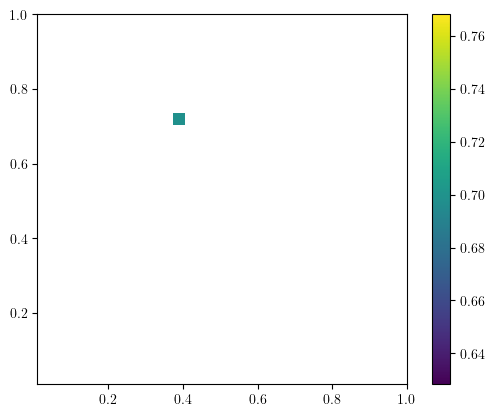

In [ ]:
N = 30
rx = np.linspace(0.01,1,N)
ry = rx
# r = np.meshgrid(rx,ry)
d_vecs = np.zeros((N,N,3))
angles = np.zeros((N,N,2))
condition = np.zeros((N,N))
for i in range(N):
    for j in range(N):
        x, y = r[0][i,j],r[1][i,j]
        d_vecs[i,j] = find_joint_dipole_reduced(x,y,initial_guess=[dy[i,j],np.sqrt(1-dy[i,j]**2-disval[i,j]**2)] if not np.isnan(dy[i,j]) else None)
        r1 = np.array([1.0, 0.0])
        r2 = np.array([x, y])
        r3 = np.array([x - 1.0, y])
        condition[i,j] = np.linalg.norm(joint_residuals_3eq(d_vecs[i,j,1:],r1,r2,r3))
fig, ax = plt.subplots(1,1)
# im = ax.imshow(np.where(np.abs(dis)>1,np.nan,dis))
im = ax.imshow(np.where(np.abs(condition)>1,np.nan,condition), extent=[0.01, 1, 0.01, 1], origin="lower")
# im = ax.imshow(condition, extent=[0.01, 1, 0.01, 1], origin="lower")
# im = ax.imshow(np.where(disval>=0,np.nan,disval), extent=[0.01, 1, 0.01, 1], origin="lower")
cmap = fig.colorbar(im,ax=ax)

In [ ]:
import numpy as np
from scipy.optimize import root_scalar


def rotate_z(vec: np.ndarray, angle: float) -> np.ndarray:
    """Rotates a 3D vector around the z-axis by `angle` radians."""
    c, s = np.cos(angle), np.sin(angle)
    R = np.array([[c, -s, 0.0], [s, c, 0.0], [0.0, 0.0, 1.0]])

    vec_3d = np.append(vec, 0.0) if len(vec) == 2 else vec
    return R @ vec_3d


def c_element(
    r_vec: np.ndarray, d_vec: np.ndarray, alpha: int, beta: int
) -> float:
    """Computes c_{alpha, beta}(r_hat) for a position vector and unit dipole."""
    r_vec = np.asarray(r_vec, dtype=float)
    d_vec = np.asarray(d_vec, dtype=float)

    if len(r_vec) == 2:
        r_vec = np.append(r_vec, 0.0)

    r = np.linalg.norm(r_vec)
    r_hat = r_vec / r
    d_hat = d_vec / np.linalg.norm(d_vec)

    r_dot_d = np.dot(r_hat, d_hat)
    kronecker = 1.0 if alpha == beta else 0.0

    term1 = kronecker * (-3.0 + 15.0 * r_dot_d**2)
    term2 = -6.0 * d_hat[alpha] * d_hat[beta]
    term3 = (
        30.0
        * ((d_hat[alpha] * r_vec[beta] + d_hat[beta] * r_vec[alpha]) / r)
        * r_dot_d
    )
    term4 = (
        15.0 * (r_vec[alpha] * r_vec[beta] / r**2) * (1.0 - 7.0 * r_dot_d**2)
    )

    return term1 + term2 + term3 + term4


def eq_residual_gamma(
    gamma: float,
    d_vec: np.ndarray,
    r1_vec: np.ndarray,
    r_other_vec: np.ndarray,
    alpha: int,
    beta: int,
) -> float:
    """Evaluates equation residual in a frame rotated by gamma around the z-axis."""
    d_rot = rotate_z(d_vec, gamma)
    r1_rot = rotate_z(r1_vec, gamma)
    ro_rot = rotate_z(r_other_vec, gamma)

    r1_norm = np.linalg.norm(r1_rot)
    ro_norm = np.linalg.norm(ro_rot)

    c1 = c_element(r1_rot, d_rot, alpha, beta)
    co = c_element(ro_rot, d_rot, alpha, beta)

    return (c1 / r1_norm**5) + (co / ro_norm**5)


def find_gamma_roots(
    d_vec: np.ndarray,
    r1_vec: np.ndarray,
    r_other_vec: np.ndarray,
    alpha: int,
    beta: int,
    grid_points: int = 180,
) -> list:
    """Finds all root angles gamma in [0, pi) solving the given equation."""
    gamma_grid = np.linspace(0.0, np.pi, grid_points)
    residuals = [
        eq_residual_gamma(g, d_vec, r1_vec, r_other_vec, alpha, beta)
        for g in gamma_grid
    ]

    roots = []
    for i in range(len(gamma_grid) - 1):
        g1, g2 = gamma_grid[i], gamma_grid[i + 1]
        f1, f2 = residuals[i], residuals[i + 1]

        if f1 * f2 <= 0:
            try:
                sol = root_scalar(
                    eq_residual_gamma,
                    args=(d_vec, r1_vec, r_other_vec, alpha, beta),
                    bracket=[g1, g2],
                    method="brentq",
                )
                if sol.converged:
                    roots.append(sol.root)
            except ValueError:
                continue

    return roots


def filter_dipoles_single_optimization(
    dipoles, r1_vec, r2_vec, r3_vec, tol: float = 1e-4, atol_dedup: float = 1e-4
):
    """Filters dipole candidates, executing find_gamma_roots at most once per branch

    and tracking the resulting rotation angle gamma.
    """
    r1_orig = np.asarray(r1_vec, dtype=float)
    r2_orig = np.asarray(r2_vec, dtype=float)
    r3_orig = np.asarray(r3_vec, dtype=float)

    eq_specs = [
        (r2_orig, 0, 0, "r1,r2 (xx)"),
        (r2_orig, 1, 1, "r1,r2 (yy)"),
        (r3_orig, 0, 0, "r1,r3 (xx)"),
        (r3_orig, 1, 1, "r1,r3 (yy)"),
    ]

    accepted_results = []

    for d_cand in dipoles:
        d_cand = np.asarray(d_cand, dtype=float)
        if np.linalg.norm(d_cand) == 0:
            continue
        d_cand = d_cand / np.linalg.norm(d_cand)

        # Active frames initialized with `gamma` set to 0.0
        active_frames = [{
            "d": d_cand,
            "r1": r1_orig,
            "r2": r2_orig,
            "r3": r3_orig,
            "optimized": False,
            "gamma": 0.0,
        }]

        for r_other_spec, alpha, beta, label in eq_specs:
            next_frames = []

            for frame in active_frames:
                d_curr = frame["d"]
                r1_curr = frame["r1"]
                r2_curr = frame["r2"]
                r3_curr = frame["r3"]
                optimized = frame["optimized"]
                current_gamma = frame["gamma"]

                r_other_curr = (
                    r2_curr
                    if np.array_equal(r_other_spec, r2_orig)
                    else r3_curr
                )
                res = eq_residual_gamma(
                    0.0, d_curr, r1_curr, r_other_curr, alpha, beta
                )

                if abs(res) <= tol:
                    # Satisfied in current frame: pass frame through unchanged
                    next_frames.append(frame)
                elif not optimized:
                    # Unsatisfied AND not yet optimized: solve for gamma branches once
                    gamma_roots = find_gamma_roots(
                        d_curr, r1_curr, r_other_curr, alpha, beta
                    )

                    for g_root in gamma_roots:
                        next_frames.append({
                            "d": rotate_z(d_curr, g_root),
                            "r1": rotate_z(r1_curr, g_root),
                            "r2": rotate_z(r2_curr, g_root),
                            "r3": rotate_z(r3_curr, g_root),
                            "optimized": True,
                            "gamma": current_gamma + g_root,  # Accumulate rotation
                        })
                # If unsatisfied AND optimized is True: frame is dismissed

            active_frames = next_frames
            if not active_frames:
                break

        # Deduplicate valid solution frames and store gamma
        for frame in active_frames:
            d_valid = frame["d"]
            is_dup = any(
                np.allclose(d_valid, item["d_hat"], atol=atol_dedup)
                for item in accepted_results
            )
            if not is_dup:
                accepted_results.append({
                    "d_hat": d_valid,
                    "r1": frame["r1"],
                    "r2": frame["r2"],
                    "r3": frame["r3"],
                    "gamma": frame["gamma"],
                })

    return accepted_results




In [ ]:
N = 30
rx = np.linspace(0.01,1,N)
ry = rx
r = np.meshgrid(rx,ry)
d_cand = []
d_valid = []
for i in range(N):
    for j in range(N):
        x, y = r[0][i,j],r[1][i,j]
        
        r1 = np.array([1.0, 0.0])
        r2 = np.array([x, y])
        r3 = np.array([x - 1.0, y])
        d_cand.append(find_unique_dipole_solutions(r1,r2,r3))
        # valids = filter_dipoles(d_cand[-1],r1,r2,r3)
        valids = filter_dipoles_single_optimization(d_cand[-1],r1,r2,r3)
        if len(valids)>0:
            d_valid.append([i,j,valids])
d_valid
# fig, ax = plt.subplots(1,1)
# # im = ax.imshow(np.where(np.abs(dis)>1,np.nan,dis))
# im = ax.imshow(np.where(np.abs(condition)>1,np.nan,condition), extent=[0.01, 1, 0.01, 1], origin="lower")
# # im = ax.imshow(condition, extent=[0.01, 1, 0.01, 1], origin="lower")
# # im = ax.imshow(np.where(disval>=0,np.nan,disval), extent=[0.01, 1, 0.01, 1], origin="lower")
# cmap = fig.colorbar(im,ax=ax)

[]

In [ ]:
import numpy as np
from scipy.optimize import root_scalar


def get_coeffs(r_vec: np.ndarray):
    """Extracts quadratic coefficients A, B, C for position vector r

    using unit components rx_hat = rx/r and ry_hat = ry/r.
    """
    r_vec = np.asarray(r_vec, dtype=float)
    if len(r_vec) == 2:
        r_vec = np.append(r_vec, 0.0)

    r = np.linalg.norm(r_vec)
    if r == 0:
        raise ValueError("Position vector norm cannot be zero.")

    rx_hat = r_vec[0] / r
    ry_hat = r_vec[1] / r
    r_sq = r**2

    c_xx = -30.0 * rx_hat * ry_hat + 105.0 * (rx_hat**3) * ry_hat
    c_xy = -24.0 - 24.0 * r_sq + 210.0 * (rx_hat**2) * (ry_hat**2)
    c_yy = -30.0 * rx_hat * ry_hat + 105.0 * rx_hat * (ry_hat**3)
    c00 = -15 * rx_hat * ry_hat
    return c_xx, c_xy, c_yy, c00


def solve_dx_branches_xy(dy: float, r2_vec: np.ndarray):
    """Analytically computes dx branches as a function of dy using the quadratic formula for r = r2."""
    c_xx, c_xy, c_yy, c00 = get_coeffs(r2_vec)

    A = c_xx
    B = c_xy * dy
    C = c_yy * (dy**2) + c00

    discriminant = B**2 - 4.0 * A * C
    if discriminant < 0 or abs(A) < 1e-12:
        return None, None

    sqrt_disc = np.sqrt(discriminant)
    dx1 = (-B + sqrt_disc) / (2.0 * A)
    dx2 = (-B - sqrt_disc) / (2.0 * A)

    return dx1, dx2


def eq2_residual_xy(
    dy: float, branch: int, r2_vec: np.ndarray, r3_vec: np.ndarray
):
    """Evaluates the equation for r = r3 using the dx(dy) branch from r = r2."""
    dx1, dx2 = solve_dx_branches_xy(dy, r2_vec)
    dx = dx1 if branch == 1 else dx2

    if dx is None or (dx**2 + dy**2 > 1.0 + 1e-12):
        return np.nan

    c_xx, c_xy, c_yy, c00 = get_coeffs(r3_vec)

    return c_xx * (dx**2) + c_xy * dx * dy + c_yy * (dy**2) + c00


def find_dipole_orientations(
    r2_vec, r3_vec, grid_points: int = 500, atol: float = 1e-4
):
    """Finds all distinct dipole solutions d = (dx, dy, dz) satisfying equation 1 and 2

    by solving dx(dy) for r2 and root-finding dy in [-1, 1] for r3.
    """
    r2_vec = np.asarray(r2_vec, dtype=float)
    r3_vec = np.asarray(r3_vec, dtype=float)

    dy_grid = np.linspace(-1.0, 1.0, grid_points)
    unique_dipoles = []

    for branch in [1, 2]:
        residuals = np.array([
            eq2_residual_xy(dy, branch, r2_vec, r3_vec) for dy in dy_grid
        ])

        for i in range(len(dy_grid) - 1):
            y1, y2 = dy_grid[i], dy_grid[i + 1]
            f1, f2 = residuals[i], residuals[i + 1]

            if np.isnan(f1) or np.isnan(f2):
                continue

            if f1 * f2 <= 0:
                try:
                    sol = root_scalar(
                        eq2_residual_xy,
                        args=(branch, r2_vec, r3_vec),
                        bracket=[y1, y2],
                        method="brentq",
                    )

                    if sol.converged:
                        dy_root = sol.root
                        dx1, dx2 = solve_dx_branches_xy(dy_root, r2_vec)
                        dx_root = dx1 if branch == 1 else dx2

                        if dx_root is not None and (
                            dx_root**2 + dy_root**2 <= 1.0 + 1e-8
                        ):
                            dz_sq = max(0.0, 1.0 - dx_root**2 - dy_root**2)
                            dz_root = np.sqrt(dz_sq)

                            d_cand = np.array([dx_root, dy_root, dz_root])

                            is_dup = any(
                                np.allclose(d_cand, d_exist, atol=atol)
                                for d_exist in unique_dipoles
                            )
                            if not is_dup:
                                unique_dipoles.append(d_cand)
                except ValueError:
                    continue

    return np.array(unique_dipoles)




In [ ]:
N = 30
rx = np.linspace(0.01,1,N)
ry = rx
r = np.meshgrid(rx,ry)
d_cand = []
d_valid = []
for i in range(N):
    for j in range(N):
        x, y = r[0][i,j],r[1][i,j]
        
        r1 = np.array([1.0, 0.0])
        r2 = np.array([x, y])
        r3 = np.array([x - 1.0, y])
        d_cand.append(len(find_dipole_orientations(r2,r3)))

d_cand
        

[4,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 4,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 4,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 4,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 4,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 4,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 4,
 4,
 2,
 2,
 2,
 2,
 2,
 0,
 2,
 0,
 2,
 2,
 2,
 2,
 4,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 4,
 4,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 0,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 4,
 4,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 4,
 4,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 0,
 4,
 2,
 0,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 4,
 2,
 2,
 4,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,


In [ ]:
import numpy as np
from scipy.optimize import root_scalar


def get_coeffs(r_vec: np.ndarray):
    """Extracts quadratic coefficients A, B, C for position vector r

    using unit components rx_hat = rx/r and ry_hat = ry/r.
    """
    r_vec = np.asarray(r_vec, dtype=float)
    if len(r_vec) == 2:
        r_vec = np.append(r_vec, 0.0)

    r = np.linalg.norm(r_vec)
    if r == 0:
        raise ValueError("Position vector norm cannot be zero.")

    rx_hat = r_vec[0] / r
    ry_hat = r_vec[1] / r
    r_sq = r**2

    c_xx = -30.0 * rx_hat * ry_hat + 105.0 * (rx_hat**3) * ry_hat
    c_xy = -24.0  + 210.0 * (rx_hat**2) * (ry_hat**2)
    c_yy = -30.0 * rx_hat * ry_hat + 105.0 * rx_hat * (ry_hat**3)
    c00 = -15* rx_hat*ry_hat

    return c_xx, c_xy, c_yy, c00


def solve_dx_branches_xy(dy: float, r2_vec: np.ndarray):
    """Analytically computes dx branches as a function of dy using the quadratic formula for r = r2."""
    c_xx, c_xy, c_yy, c00 = get_coeffs(r2_vec)

    A = c_xx
    B = c_xy * dy
    C = c_yy * (dy**2) + c00 
    

    discriminant = B**2 - 4.0 * A * C
    if discriminant < 0:
        return None, None
    elif abs(A) < 1e-12:
        if abs(B) < 1e-12:
            return None, None
        else:
            return -C/B


    sqrt_disc = np.sqrt(discriminant)
    dx1 = (-B + sqrt_disc) / (2.0 * A)
    dx2 = (-B - sqrt_disc) / (2.0 * A)

    return dx1, dx2


def eq2_residual_xy(
    dy: float, branch: int, r2_vec: np.ndarray, r3_vec: np.ndarray
):
    """Evaluates the equation for r = r3 using the dx(dy) branch from r = r2."""
    dx1, dx2 = solve_dx_branches_xy(dy, r2_vec)
    dx = dx1 if branch == 1 else dx2

    if dx is None or (dx**2 + dy**2 > 1.0 + 1e-12):
        return np.nan

    c_xx, c_xy, c_yy, c00 = get_coeffs(r3_vec)

    return c_xx * (dx**2) + c_xy * dx * dy + c_yy * (dy**2) + c00


def find_dipole_orientations(
    r2_vec, r3_vec, grid_points: int = 10000, atol: float = 1e-4, sci_tol: float = 1e-4
):
    """Finds all distinct dipole solutions d = (dx, dy, dz) satisfying equation 1 and 2

    by solving dx(dy) for r2 and root-finding dy in [-1, 1] for r3.
    """
    r2_vec = np.asarray(r2_vec, dtype=float)
    r3_vec = np.asarray(r3_vec, dtype=float)

    dy_grid = np.linspace(-1.0, 1.0, grid_points)
    unique_dipoles = []

    for branch in [1, 2]:
        residuals = np.array([
            eq2_residual_xy(dy, branch, r2_vec, r3_vec) for dy in dy_grid
        ])

        for i in range(len(dy_grid) - 1):
            y1, y2 = dy_grid[i], dy_grid[i + 1]
            f1, f2 = residuals[i], residuals[i + 1]

            if np.isnan(f1) or np.isnan(f2):
                continue

            if f1 * f2 <= 0:
                try:
                    sol = root_scalar(
                        eq2_residual_xy,
                        args=(branch, r2_vec, r3_vec),
                        bracket=[y1, y2],
                        method="brentq",
                        # xtol= sci_tol,
                    )

                    if sol.converged:
                        dy_root = sol.root
                        dx1, dx2 = solve_dx_branches_xy(dy_root, r2_vec)
                        dx_root = dx1 if branch == 1 else dx2

                        if dx_root is not None and (
                            dx_root**2 + dy_root**2 <= 1.0 + 1e-8
                        ):
                            dz_sq = max(0.0, 1.0 - dx_root**2 - dy_root**2)
                            dz_root = np.sqrt(dz_sq)

                            d_cand = np.array([dx_root, dy_root, dz_root])

                            is_dup = any(
                                np.allclose(d_cand, d_exist, atol=atol)
                                for d_exist in unique_dipoles
                            )
                            if not is_dup:
                                unique_dipoles.append(d_cand)
                except ValueError:
                    continue

    return np.array(unique_dipoles)




### Order dipoles

In [ ]:
import numpy as np
from scipy.optimize import linear_sum_assignment


def nan_squared_dist(
    u: np.ndarray, v: np.ndarray, nan_penalty: float = 1e3
) -> float:
    """Computes a NaN-aware squared distance between two vectors.

    - Both NaN: cost = 0
    - One NaN, one valid: cost = nan_penalty
    - Both valid: cost = sum((u - v)^2)
    """
    u_nan = np.isnan(u)
    v_nan = np.isnan(v)

    both_valid = ~(u_nan | v_nan)
    one_nan = u_nan ^ v_nan

    cost = np.zeros_like(u, dtype=float)
    cost[both_valid] = (u[both_valid] - v[both_valid]) ** 2
    cost[one_nan] = nan_penalty

    return np.sum(cost)


def get_spatial_neighbors_4shells(
    i: int, j: int, Ny: int, Nx: int, distance_weighting: bool = True
) -> list:
    """Returns valid grid neighbors up to the 4th nearest-neighbor shell with inverse-distance weighting.

    Total maximum neighbors = 20 (4 + 4 + 4 + 8).
    """
    # Define (delta_i, delta_j) offsets and exact Euclidean distances for 4 shells
    shells = [
        # Shell 1: 1st NN (dist = 1.0)
        ([(-1, 0), (1, 0), (0, -1), (0, 1)], 1.0),
        # Shell 2: 2nd NN (dist = sqrt(2))
        ([(-1, -1), (-1, 1), (1, -1), (1, 1)], np.sqrt(2.0)),
        # Shell 3: 3rd NN (dist = 2.0)
        ([(-2, 0), (2, 0), (0, -2), (0, 2)], 2.0),
        # Shell 4: 4th NN (dist = sqrt(5))
        (
            [
                (-2, -1),
                (-2, 1),
                (2, -1),
                (2, 1),
                (-1, -2),
                (-1, 2),
                (1, -2),
                (1, 2),
            ],
            np.sqrt(5.0),
        ),
    ]

    neighbors = []
    for offsets, dist in shells:
        weight = (1.0 / dist) if distance_weighting else 1.0
        for di, dj in offsets:
            ni, nj = i + di, j + dj
            if 0 <= ni < Ny and 0 <= nj < Nx:
                neighbors.append((ni, nj, weight))

    return neighbors


def align_grid_vectors_4shells(
    arr: np.ndarray,
    max_iter: int = 10,
    tol: float = 1e-6,
    nan_penalty: float = 1e3,
    distance_weighting: bool = True,
) -> np.ndarray:
    """Reorders the 4 entries along axis 2 of an array considering 4 spatial

    nearest-neighbor shells (20 neighbors) with inverse-distance weighting.

    Parameters
    ----------
    arr : np.ndarray
        Array of shape (N, N, 4) or (N, N, 4, D) containing vectors/values.
    max_iter : int
        Maximum number of spatial relaxation sweeps.
    tol : float
        Convergence threshold for cost reduction.
    nan_penalty : float
        Penalty applied when matching a NaN value with a valid numeric value.
    distance_weighting : bool
        If True, weights each neighbor by 1/distance.

    Returns
    -------
    np.ndarray
        Reordered array with identical shape as `arr`.
    """
    orig_shape = arr.shape
    if arr.ndim == 3:
        work_arr = arr[..., np.newaxis].copy()
    else:
        work_arr = arr.copy()

    Ny, Nx, K, D = work_arr.shape
    assert K == 4, "Axis 2 must have length 4."

    # Step 1: Causal Wavefront Initialization Pass
    for i in range(Ny):
        for j in range(Nx):
            if i == 0 and j == 0:
                continue

            all_nb = get_spatial_neighbors_4shells(
                i, j, Ny, Nx, distance_weighting=distance_weighting
            )
            # Causal filter: only neighbors already visited in raster order
            causal_neighbors = [
                (ni, nj, w)
                for (ni, nj, w) in all_nb
                if (ni < i) or (ni == i and nj < j)
            ]

            if not causal_neighbors:
                continue

            cands = work_arr[i, j]
            cost_matrix = np.zeros((K, K))

            for a in range(K):
                cand_vec = cands[a]
                for k in range(K):
                    for ni, nj, w in causal_neighbors:
                        target_vec = work_arr[ni, nj, k]
                        cost_matrix[a, k] += w * nan_squared_dist(
                            cand_vec, target_vec, nan_penalty
                        )

            row_ind, col_ind = linear_sum_assignment(cost_matrix)
            work_arr[i, j] = cands[row_ind[np.argsort(col_ind)]]

    # Step 2: Bi-directional Relaxation Sweeps across full 4-shell neighborhood
    prev_total_cost = float("inf")

    for sweep in range(max_iter):
        total_cost = 0.0
        i_range = range(Ny) if sweep % 2 == 0 else range(Ny - 1, -1, -1)
        j_range = range(Nx) if sweep % 2 == 0 else range(Nx - 1, -1, -1)

        for i in i_range:
            for j in j_range:
                neighbors = get_spatial_neighbors_4shells(
                    i, j, Ny, Nx, distance_weighting=distance_weighting
                )
                cands = work_arr[i, j]
                cost_matrix = np.zeros((K, K))

                for a in range(K):
                    cand_vec = cands[a]
                    for k in range(K):
                        for ni, nj, w in neighbors:
                            target_vec = work_arr[ni, nj, k]
                            cost_matrix[a, k] += w * nan_squared_dist(
                                cand_vec, target_vec, nan_penalty
                            )

                row_ind, col_ind = linear_sum_assignment(cost_matrix)
                permuted = cands[row_ind[np.argsort(col_ind)]]
                work_arr[i, j] = permuted

                for k in range(K):
                    for ni, nj, w in neighbors:
                        total_cost += w * nan_squared_dist(
                            permuted[k], work_arr[ni, nj, k], nan_penalty
                        )

        if abs(prev_total_cost - total_cost) < tol:
            break
        prev_total_cost = total_cost

    return work_arr.reshape(orig_shape)




In [ ]:
import numpy as np
from scipy.optimize import linear_sum_assignment


def nan_squared_dist(
    u: np.ndarray, v: np.ndarray, nan_penalty: float = 1e3
) -> float:
    """Computes a NaN-aware squared distance between two vectors.

    - Both NaN: cost = 0
    - One NaN, one valid: cost = nan_penalty
    - Both valid: cost = sum((u - v)^2)
    """
    u_nan = np.isnan(u)
    v_nan = np.isnan(v)

    both_valid = ~(u_nan | v_nan)
    one_nan = u_nan ^ v_nan

    cost = np.zeros_like(u, dtype=float)
    cost[both_valid] = (u[both_valid] - v[both_valid]) ** 2
    cost[one_nan] = nan_penalty

    return np.sum(cost)


def get_spatial_neighbors_8shells(
    i: int, j: int, Ny: int, Nx: int, distance_weighting: bool = True
) -> list:
    """Returns valid grid neighbors up to the 8th nearest-neighbor shell with inverse-distance weighting.

    Total maximum neighbors = 44 (4 + 4 + 4 + 8 + 4 + 4 + 8 + 8).
    """
    shells = [
        # Shell 1: 1st NN (dist = 1.0)
        ([(-1, 0), (1, 0), (0, -1), (0, 1)], 1.0),
        # Shell 2: 2nd NN (dist = sqrt(2))
        ([(-1, -1), (-1, 1), (1, -1), (1, 1)], np.sqrt(2.0)),
        # Shell 3: 3rd NN (dist = 2.0)
        ([(-2, 0), (2, 0), (0, -2), (0, 2)], 2.0),
        # Shell 4: 4th NN (dist = sqrt(5))
        (
            [
                (-2, -1),
                (-2, 1),
                (2, -1),
                (2, 1),
                (-1, -2),
                (-1, 2),
                (1, -2),
                (1, 2),
            ],
            np.sqrt(5.0),
        ),
        # Shell 5: 5th NN (dist = sqrt(8))
        ([(-2, -2), (-2, 2), (2, -2), (2, 2)], np.sqrt(8.0)),
        # Shell 6: 6th NN (dist = 3.0)
        ([(-3, 0), (3, 0), (0, -3), (0, 3)], 3.0),
        # Shell 7: 7th NN (dist = sqrt(10))
        (
            [
                (-3, -1),
                (-3, 1),
                (3, -1),
                (3, 1),
                (-1, -3),
                (-1, 3),
                (1, -3),
                (1, 3),
            ],
            np.sqrt(10.0),
        ),
        # Shell 8: 8th NN (dist = sqrt(13))
        (
            [
                (-3, -2),
                (-3, 2),
                (3, -2),
                (3, 2),
                (-2, -3),
                (-2, 3),
                (2, -3),
                (2, 3),
            ],
            np.sqrt(13.0),
        ),
    ]

    neighbors = []
    for offsets, dist in shells:
        weight = (1.0 / dist) if distance_weighting else 1.0
        for di, dj in offsets:
            ni, nj = i + di, j + dj
            if 0 <= ni < Ny and 0 <= nj < Nx:
                neighbors.append((ni, nj, weight))

    return neighbors


def align_grid_vectors_8shells(
    arr: np.ndarray,
    max_iter: int = 10,
    tol: float = 1e-6,
    nan_penalty: float = 1e3,
    distance_weighting: bool = True,
) -> np.ndarray:
    """Reorders the 4 entries along axis 2 of an array considering 8 spatial

    nearest-neighbor shells (up to 44 neighbors) with inverse-distance weighting.

    Parameters
    ----------
    arr : np.ndarray
        Array of shape (N, N, 4) or (N, N, 4, D) containing vectors/values.
    max_iter : int
        Maximum number of spatial relaxation sweeps.
    tol : float
        Convergence threshold for cost reduction.
    nan_penalty : float
        Penalty applied when matching a NaN value with a valid numeric value.
    distance_weighting : bool
        If True, weights each neighbor by 1/distance.

    Returns
    -------
    np.ndarray
        Reordered array with identical shape as `arr`.
    """
    orig_shape = arr.shape
    if arr.ndim == 3:
        work_arr = arr[..., np.newaxis].copy()
    else:
        work_arr = arr.copy()

    Ny, Nx, K, D = work_arr.shape
    assert K == 4, "Axis 2 must have length 4."

    # Step 1: Causal Wavefront Initialization Pass
    for i in range(Ny):
        for j in range(Nx):
            if i == 0 and j == 0:
                continue

            all_nb = get_spatial_neighbors_8shells(
                i, j, Ny, Nx, distance_weighting=distance_weighting
            )
            causal_neighbors = [
                (ni, nj, w)
                for (ni, nj, w) in all_nb
                if (ni < i) or (ni == i and nj < j)
            ]

            if not causal_neighbors:
                continue

            cands = work_arr[i, j]
            cost_matrix = np.zeros((K, K))

            for a in range(K):
                cand_vec = cands[a]
                for k in range(K):
                    for ni, nj, w in causal_neighbors:
                        target_vec = work_arr[ni, nj, k]
                        cost_matrix[a, k] += w * nan_squared_dist(
                            cand_vec, target_vec, nan_penalty
                        )

            row_ind, col_ind = linear_sum_assignment(cost_matrix)
            work_arr[i, j] = cands[row_ind[np.argsort(col_ind)]]

    # Step 2: Bi-directional Relaxation Sweeps across full 8-shell neighborhood
    prev_total_cost = float("inf")

    for sweep in range(max_iter):
        total_cost = 0.0
        i_range = range(Ny) if sweep % 2 == 0 else range(Ny - 1, -1, -1)
        j_range = range(Nx) if sweep % 2 == 0 else range(Nx - 1, -1, -1)

        for i in i_range:
            for j in j_range:
                neighbors = get_spatial_neighbors_8shells(
                    i, j, Ny, Nx, distance_weighting=distance_weighting
                )
                cands = work_arr[i, j]
                cost_matrix = np.zeros((K, K))

                for a in range(K):
                    cand_vec = cands[a]
                    for k in range(K):
                        for ni, nj, w in neighbors:
                            target_vec = work_arr[ni, nj, k]
                            cost_matrix[a, k] += w * nan_squared_dist(
                                cand_vec, target_vec, nan_penalty
                            )

                row_ind, col_ind = linear_sum_assignment(cost_matrix)
                permuted = cands[row_ind[np.argsort(col_ind)]]
                work_arr[i, j] = permuted

                for k in range(K):
                    for ni, nj, w in neighbors:
                        total_cost += w * nan_squared_dist(
                            permuted[k], work_arr[ni, nj, k], nan_penalty
                        )

        if abs(prev_total_cost - total_cost) < tol:
            break
        prev_total_cost = total_cost

    return work_arr.reshape(orig_shape)




In [ ]:
import numpy as np
from scipy.optimize import linear_sum_assignment


def nan_squared_dist(
    u: np.ndarray, v: np.ndarray, nan_penalty: float = 1e3
) -> float:
    """Computes a NaN-aware squared distance between two vectors."""
    u_nan = np.isnan(u)
    v_nan = np.isnan(v)

    both_valid = ~(u_nan | v_nan)
    one_nan = u_nan ^ v_nan

    cost = np.zeros_like(u, dtype=float)
    cost[both_valid] = (u[both_valid] - v[both_valid]) ** 2
    cost[one_nan] = nan_penalty

    return np.sum(cost)


def get_anisotropic_neighbors_8shells(
    i: int, j: int, Ny: int, Nx: int, alpha_first_axis: float = 2.0
) -> list:
    """Returns valid grid neighbors up to 8 distance shells (max_dist = sqrt(13) ~ 3.61).

    Parameters
    ----------
    alpha_first_axis : float
        Anisotropy factor (alpha >= 1.0).
        - alpha = 1.0: Isotropic (equal weighting on both axes).
        - alpha > 1.0: Penalizes offsets along axis 0, giving stronger weights
          to neighbors with smaller |delta_i|.
    """
    max_r_iso = np.sqrt(13.0)  # Covers 8 shells (44 neighbors)
    max_offset = 3

    neighbors = []
    for di in range(-max_offset, max_offset + 1):
        for dj in range(-max_offset, max_offset + 1):
            if di == 0 and dj == 0:
                continue

            # Standard isotropic distance check to preserve the 8-shell cutoff
            d_iso = np.sqrt(di**2 + dj**2)
            if d_iso <= max_r_iso:
                ni, nj = i + di, j + dj
                if 0 <= ni < Ny and 0 <= nj < Nx:
                    # Anisotropic Euclidean distance
                    d_aniso = np.sqrt(alpha_first_axis * (di**2) + (dj**2))
                    weight = 1.0 / d_aniso
                    neighbors.append((ni, nj, weight))

    return neighbors


def align_grid_vectors_anisotropic(
    arr: np.ndarray,
    max_iter: int = 10,
    tol: float = 1e-6,
    nan_penalty: float = 1e3,
    alpha_first_axis: float = 2.0,
) -> np.ndarray:
    """Reorders the 4 entries along axis 2 using anisotropic 8-shell spatial weighting.

    Parameters
    ----------
    arr : np.ndarray
        Array of shape (N, N, 4) or (N, N, 4, D).
    max_iter : int
        Maximum relaxation sweeps.
    tol : float
        Convergence threshold.
    nan_penalty : float
        Penalty for matching valid values to NaNs.
    alpha_first_axis : float
        Weighting factor for first axis (> 1.0 prioritizes smaller |delta_i|).
    """
    orig_shape = arr.shape
    if arr.ndim == 3:
        work_arr = arr[..., np.newaxis].copy()
    else:
        work_arr = arr.copy()

    Ny, Nx, K, D = work_arr.shape
    assert K == 4, "Axis 2 must have length 4."

    # Step 1: Causal Wavefront Pass
    for i in range(Ny):
        for j in range(Nx):
            if i == 0 and j == 0:
                continue

            all_nb = get_anisotropic_neighbors_8shells(
                i, j, Ny, Nx, alpha_first_axis=alpha_first_axis
            )
            causal_neighbors = [
                (ni, nj, w)
                for (ni, nj, w) in all_nb
                if (ni < i) or (ni == i and nj < j)
            ]

            if not causal_neighbors:
                continue

            cands = work_arr[i, j]
            cost_matrix = np.zeros((K, K))

            for a in range(K):
                cand_vec = cands[a]
                for k in range(K):
                    for ni, nj, w in causal_neighbors:
                        target_vec = work_arr[ni, nj, k]
                        cost_matrix[a, k] += w * nan_squared_dist(
                            cand_vec, target_vec, nan_penalty
                        )

            row_ind, col_ind = linear_sum_assignment(cost_matrix)
            work_arr[i, j] = cands[row_ind[np.argsort(col_ind)]]

    # Step 2: Bi-directional Relaxation Sweeps
    prev_total_cost = float("inf")

    for sweep in range(max_iter):
        total_cost = 0.0
        i_range = range(Ny) if sweep % 2 == 0 else range(Ny - 1, -1, -1)
        j_range = range(Nx) if sweep % 2 == 0 else range(Nx - 1, -1, -1)

        for i in i_range:
            for j in j_range:
                neighbors = get_anisotropic_neighbors_8shells(
                    i, j, Ny, Nx, alpha_first_axis=alpha_first_axis
                )
                cands = work_arr[i, j]
                cost_matrix = np.zeros((K, K))

                for a in range(K):
                    cand_vec = cands[a]
                    for k in range(K):
                        for ni, nj, w in neighbors:
                            target_vec = work_arr[ni, nj, k]
                            cost_matrix[a, k] += w * nan_squared_dist(
                                cand_vec, target_vec, nan_penalty
                            )

                row_ind, col_ind = linear_sum_assignment(cost_matrix)
                permuted = cands[row_ind[np.argsort(col_ind)]]
                work_arr[i, j] = permuted

                for k in range(K):
                    for ni, nj, w in neighbors:
                        total_cost += w * nan_squared_dist(
                            permuted[k], work_arr[ni, nj, k], nan_penalty
                        )

        if abs(prev_total_cost - total_cost) < tol:
            break
        prev_total_cost = total_cost

    return work_arr.reshape(orig_shape)



In [ ]:
import numpy as np
from scipy.optimize import linear_sum_assignment


def nan_squared_dist(
    u: np.ndarray, v: np.ndarray, nan_penalty: float = 1e3
) -> float:
    """Computes a NaN-aware squared distance between two vectors."""
    u_nan = np.isnan(u)
    v_nan = np.isnan(v)

    both_valid = ~(u_nan | v_nan)
    one_nan = u_nan ^ v_nan

    cost = np.zeros_like(u, dtype=float)
    cost[both_valid] = (u[both_valid] - v[both_valid]) ** 2
    cost[one_nan] = nan_penalty

    return np.sum(cost)


def get_spatial_neighbors_4shells(
    i: int, j: int, Ny: int, Nx: int, distance_weighting: bool = True
) -> list:
    """Returns valid grid neighbors up to the 4th nearest-neighbor shell (20 neighbors max)."""
    shells = [
        # Shell 1: 1st NN (dist = 1.0)
        ([(-1, 0), (1, 0), (0, -1), (0, 1)], 1.0),
        # Shell 2: 2nd NN (dist = sqrt(2))
        ([(-1, -1), (-1, 1), (1, -1), (1, 1)], np.sqrt(2.0)),
        # Shell 3: 3rd NN (dist = 2.0)
        ([(-2, 0), (2, 0), (0, -2), (0, 2)], 2.0),
        # Shell 4: 4th NN (dist = sqrt(5))
        (
            [
                (-2, -1),
                (-2, 1),
                (2, -1),
                (2, 1),
                (-1, -2),
                (-1, 2),
                (1, -2),
                (1, 2),
            ],
            np.sqrt(5.0),
        ),
    ]

    neighbors = []
    for offsets, dist in shells:
        weight = (1.0 / dist) if distance_weighting else 1.0
        for di, dj in offsets:
            ni, nj = i + di, j + dj
            if 0 <= ni < Ny and 0 <= nj < Nx:
                neighbors.append((ni, nj, weight))

    return neighbors


def align_grid_vectors_4shells_sym(
    arr: np.ndarray,
    max_iter: int = 15,
    tol: float = 1e-6,
    nan_penalty: float = 1e3,
    sym_weight: float = 1.0,
    distance_weighting: bool = True,
) -> np.ndarray:
    """Reorders the 4 entries along axis 2 of an array strictly locally at each (i, j).

    Combines 4-shell spatial neighbor smoothness with midpoint reflection symmetry
    across the second axis (j <-> Nx - 1 - j).

    Parameters
    ----------
    arr : np.ndarray
        Array of shape (Ny, Nx, 4) or (Ny, Nx, 4, D).
    max_iter : int
        Maximum relaxation sweeps.
    tol : float
        Convergence threshold.
    nan_penalty : float
        Penalty applied when matching NaN with a valid numeric entry.
    sym_weight : float
        Strength of the reflection coupling penalty across axis 1 midpoint.
    distance_weighting : bool
        If True, weights spatial neighbors by 1/distance.

    Returns
    -------
    np.ndarray
        Reordered array with identical shape.
    """
    orig_shape = arr.shape
    if arr.ndim == 3:
        work_arr = arr[..., np.newaxis].copy()
    else:
        work_arr = arr.copy()

    Ny, Nx, K, D = work_arr.shape
    assert K == 4, "Axis 2 must have length 4."

    # Step 1: Causal Wavefront Initialization Pass
    for i in range(Ny):
        for j in range(Nx):
            if i == 0 and j == 0:
                continue

            all_nb = get_spatial_neighbors_4shells(
                i, j, Ny, Nx, distance_weighting=distance_weighting
            )
            causal_neighbors = [
                (ni, nj, w)
                for (ni, nj, w) in all_nb
                if (ni < i) or (ni == i and nj < j)
            ]

            j_mirror = Nx - 1 - j
            has_mirror_visited = (j != j_mirror) and (j_mirror < j)

            cands = work_arr[i, j]
            cost_matrix = np.zeros((K, K))

            for a in range(K):
                cand_vec = cands[a]
                for k in range(K):
                    # Local spatial cost
                    for ni, nj, w in causal_neighbors:
                        target_vec = work_arr[ni, nj, k]
                        cost_matrix[a, k] += w * nan_squared_dist(
                            cand_vec, target_vec, nan_penalty
                        )

                    # Reflection symmetry cost (if mirror cell was already processed in wavefront)
                    if has_mirror_visited:
                        mirror_vec = work_arr[i, j_mirror, k]
                        cost_matrix[a, k] += sym_weight * nan_squared_dist(
                            cand_vec, mirror_vec, nan_penalty
                        )

            row_ind, col_ind = linear_sum_assignment(cost_matrix)
            work_arr[i, j] = cands[row_ind[np.argsort(col_ind)]]

    # Step 2: Bi-directional Relaxation Sweeps
    prev_total_cost = float("inf")

    for sweep in range(max_iter):
        total_cost = 0.0
        i_range = range(Ny) if sweep % 2 == 0 else range(Ny - 1, -1, -1)
        j_range = range(Nx) if sweep % 2 == 0 else range(Nx - 1, -1, -1)

        for i in i_range:
            for j in j_range:
                neighbors = get_spatial_neighbors_4shells(
                    i, j, Ny, Nx, distance_weighting=distance_weighting
                )
                j_mirror = Nx - 1 - j

                cands = work_arr[i, j]
                cost_matrix = np.zeros((K, K))

                for a in range(K):
                    cand_vec = cands[a]
                    for k in range(K):
                        # 1. Spatial smoothness across 4 shells
                        for ni, nj, w in neighbors:
                            target_vec = work_arr[ni, nj, k]
                            cost_matrix[a, k] += w * nan_squared_dist(
                                cand_vec, target_vec, nan_penalty
                            )

                        # 2. Reflection symmetry across midpoint of second axis
                        if j != j_mirror:
                            mirror_vec = work_arr[i, j_mirror, k]
                            cost_matrix[a, k] += sym_weight * nan_squared_dist(
                                cand_vec, mirror_vec, nan_penalty
                            )

                row_ind, col_ind = linear_sum_assignment(cost_matrix)
                permuted = cands[row_ind[np.argsort(col_ind)]]
                work_arr[i, j] = permuted

                # Accumulate system total energy
                for k in range(K):
                    for ni, nj, w in neighbors:
                        total_cost += w * nan_squared_dist(
                            permuted[k], work_arr[ni, nj, k], nan_penalty
                        )
                    if j != j_mirror:
                        total_cost += sym_weight * nan_squared_dist(
                            permuted[k], work_arr[i, j_mirror, k], nan_penalty
                        )

        if abs(prev_total_cost - total_cost) < tol:
            break
        prev_total_cost = total_cost

    return work_arr.reshape(orig_shape)




In [ ]:
import numpy as np
from scipy.optimize import linear_sum_assignment


def nan_squared_dist(
    u: np.ndarray, v: np.ndarray, nan_penalty: float = 1e3
) -> float:
    """Computes a NaN-aware squared distance between two vectors."""
    u_nan = np.isnan(u)
    v_nan = np.isnan(v)

    both_valid = ~(u_nan | v_nan)
    one_nan = u_nan ^ v_nan

    cost = np.zeros_like(u, dtype=float)
    cost[both_valid] = (u[both_valid] - v[both_valid]) ** 2
    cost[one_nan] = nan_penalty

    return np.sum(cost)


def get_spatial_neighbors_4shells(
    i: int, j: int, Ny: int, Nx: int, distance_weighting: bool = True
) -> list:
    """Returns valid grid neighbors up to the 4th nearest-neighbor shell (20 neighbors max)."""
    shells = [
        # Shell 1: 1st NN (dist = 1.0)
        ([(-1, 0), (1, 0), (0, -1), (0, 1)], 1.0),
        # Shell 2: 2nd NN (dist = sqrt(2))
        ([(-1, -1), (-1, 1), (1, -1), (1, 1)], np.sqrt(2.0)),
        # Shell 3: 3rd NN (dist = 2.0)
        ([(-2, 0), (2, 0), (0, -2), (0, 2)], 2.0),
        # Shell 4: 4th NN (dist = sqrt(5))
        (
            [
                (-2, -1),
                (-2, 1),
                (2, -1),
                (2, 1),
                (-1, -2),
                (-1, 2),
                (1, -2),
                (1, 2),
            ],
            np.sqrt(5.0),
        ),
    ]

    neighbors = []
    for offsets, dist in shells:
        weight = (1.0 / dist) if distance_weighting else 1.0
        for di, dj in offsets:
            ni, nj = i + di, j + dj
            if 0 <= ni < Ny and 0 <= nj < Nx:
                neighbors.append((ni, nj, weight))

    return neighbors


def align_grid_vectors_4shells_sym_axis0(
    arr: np.ndarray,
    max_iter: int = 15,
    tol: float = 1e-6,
    nan_penalty: float = 1e3,
    sym_weight: float = 1.0,
    distance_weighting: bool = True,
) -> np.ndarray:
    """Reorders the 4 entries along axis 2 of an array strictly locally at each (i, j).

    Combines 4-shell spatial neighbor smoothness with midpoint reflection symmetry
    across the FIRST axis (i <-> Ny - 1 - i).

    Parameters
    ----------
    arr : np.ndarray
        Array of shape (Ny, Nx, 4) or (Ny, Nx, 4, D).
    max_iter : int
        Maximum relaxation sweeps.
    tol : float
        Convergence threshold.
    nan_penalty : float
        Penalty applied when matching NaN with a valid numeric entry.
    sym_weight : float
        Strength of the reflection coupling penalty across axis 0 midpoint.
    distance_weighting : bool
        If True, weights spatial neighbors by 1/distance.

    Returns
    -------
    np.ndarray
        Reordered array with identical shape.
    """
    orig_shape = arr.shape
    if arr.ndim == 3:
        work_arr = arr[..., np.newaxis].copy()
    else:
        work_arr = arr.copy()

    Ny, Nx, K, D = work_arr.shape
    assert K == 4, "Axis 2 must have length 4."

    # Step 1: Causal Wavefront Initialization Pass
    for i in range(Ny):
        for j in range(Nx):
            if i == 0 and j == 0:
                continue

            all_nb = get_spatial_neighbors_4shells(
                i, j, Ny, Nx, distance_weighting=distance_weighting
            )
            causal_neighbors = [
                (ni, nj, w)
                for (ni, nj, w) in all_nb
                if (ni < i) or (ni == i and nj < j)
            ]

            i_mirror = Ny - 1 - i
            has_mirror_visited = (i != i_mirror) and (i_mirror < i)

            cands = work_arr[i, j]
            cost_matrix = np.zeros((K, K))

            for a in range(K):
                cand_vec = cands[a]
                for k in range(K):
                    # Local 4-shell spatial cost
                    for ni, nj, w in causal_neighbors:
                        target_vec = work_arr[ni, nj, k]
                        cost_matrix[a, k] += w * nan_squared_dist(
                            cand_vec, target_vec, nan_penalty
                        )

                    # Reflection symmetry cost across axis 0 (if mirror row already processed)
                    if has_mirror_visited:
                        mirror_vec = work_arr[i_mirror, j, k]
                        cost_matrix[a, k] += sym_weight * nan_squared_dist(
                            cand_vec, mirror_vec, nan_penalty
                        )

            row_ind, col_ind = linear_sum_assignment(cost_matrix)
            work_arr[i, j] = cands[row_ind[np.argsort(col_ind)]]

    # Step 2: Bi-directional Relaxation Sweeps
    prev_total_cost = float("inf")

    for sweep in range(max_iter):
        total_cost = 0.0
        i_range = range(Ny) if sweep % 2 == 0 else range(Ny - 1, -1, -1)
        j_range = range(Nx) if sweep % 2 == 0 else range(Nx - 1, -1, -1)

        for i in i_range:
            for j in j_range:
                neighbors = get_spatial_neighbors_4shells(
                    i, j, Ny, Nx, distance_weighting=distance_weighting
                )
                i_mirror = Ny - 1 - i

                cands = work_arr[i, j]
                cost_matrix = np.zeros((K, K))

                for a in range(K):
                    cand_vec = cands[a]
                    for k in range(K):
                        # 1. Spatial smoothness across 4 shells
                        for ni, nj, w in neighbors:
                            target_vec = work_arr[ni, nj, k]
                            cost_matrix[a, k] += w * nan_squared_dist(
                                cand_vec, target_vec, nan_penalty
                            )

                        # 2. Reflection symmetry across midpoint of first axis
                        if i != i_mirror:
                            mirror_vec = work_arr[i_mirror, j, k]
                            cost_matrix[a, k] += sym_weight * nan_squared_dist(
                                cand_vec, mirror_vec, nan_penalty
                            )

                row_ind, col_ind = linear_sum_assignment(cost_matrix)
                permuted = cands[row_ind[np.argsort(col_ind)]]
                work_arr[i, j] = permuted

                # Accumulate system total energy
                for k in range(K):
                    for ni, nj, w in neighbors:
                        total_cost += w * nan_squared_dist(
                            permuted[k], work_arr[ni, nj, k], nan_penalty
                        )
                    if i != i_mirror:
                        total_cost += sym_weight * nan_squared_dist(
                            permuted[k], work_arr[i_mirror, j, k], nan_penalty
                        )

        if abs(prev_total_cost - total_cost) < tol:
            break
        prev_total_cost = total_cost

    return work_arr.reshape(orig_shape)




In [ ]:
import numpy as np
from scipy.optimize import linear_sum_assignment


def nan_squared_dist(
    u: np.ndarray, v: np.ndarray, nan_penalty: float = 1e3
) -> float:
    """Computes a NaN-aware squared distance between two vectors."""
    u_nan = np.isnan(u)
    v_nan = np.isnan(v)

    both_valid = ~(u_nan | v_nan)
    one_nan = u_nan ^ v_nan

    cost = np.zeros_like(u, dtype=float)
    cost[both_valid] = (u[both_valid] - v[both_valid]) ** 2
    cost[one_nan] = nan_penalty

    return np.sum(cost)


def get_spatial_neighbors_4shells(
    i: int, j: int, Ny: int, Nx: int, distance_weighting: bool = True
) -> list:
    """Returns valid grid neighbors up to the 4th nearest-neighbor shell (20 neighbors max)."""
    shells = [
        # Shell 1: 1st NN (dist = 1.0)
        ([(-1, 0), (1, 0), (0, -1), (0, 1)], 1.0),
        # Shell 2: 2nd NN (dist = sqrt(2))
        ([(-1, -1), (-1, 1), (1, -1), (1, 1)], np.sqrt(2.0)),
        # Shell 3: 3rd NN (dist = 2.0)
        ([(-2, 0), (2, 0), (0, -2), (0, 2)], 2.0),
        # Shell 4: 4th NN (dist = sqrt(5))
        (
            [
                (-2, -1),
                (-2, 1),
                (2, -1),
                (2, 1),
                (-1, -2),
                (-1, 2),
                (1, -2),
                (1, 2),
            ],
            np.sqrt(5.0),
        ),
    ]

    neighbors = []
    for offsets, dist in shells:
        weight = (1.0 / dist) if distance_weighting else 1.0
        for di, dj in offsets:
            ni, nj = i + di, j + dj
            if 0 <= ni < Ny and 0 <= nj < Nx:
                neighbors.append((ni, nj, weight))

    return neighbors


def align_grid_vectors_4shells_antisym_axis0(
    arr: np.ndarray,
    max_iter: int = 15,
    tol: float = 1e-6,
    nan_penalty: float = 1e3,
    sym_weight: float = 1.0,
    distance_weighting: bool = True,
) -> np.ndarray:
    """Reorders the 4 entries along axis 2 of an array strictly locally at each (i, j).

    Combines 4-shell spatial neighbor smoothness with anti-symmetry
    across the FIRST axis (i <-> Ny - 1 - i, matching v with -v_mirror).

    Parameters
    ----------
    arr : np.ndarray
        Array of shape (Ny, Nx, 4) or (Ny, Nx, 4, D).
    max_iter : int
        Maximum relaxation sweeps.
    tol : float
        Convergence threshold.
    nan_penalty : float
        Penalty applied when matching NaN with a valid numeric entry.
    sym_weight : float
        Strength of the anti-symmetry coupling penalty across axis 0 midpoint.
    distance_weighting : bool
        If True, weights spatial neighbors by 1/distance.

    Returns
    -------
    np.ndarray
        Reordered array with identical shape.
    """
    orig_shape = arr.shape
    if arr.ndim == 3:
        work_arr = arr[..., np.newaxis].copy()
    else:
        work_arr = arr.copy()

    Ny, Nx, K, D = work_arr.shape
    assert K == 4, "Axis 2 must have length 4."

    # Step 1: Causal Wavefront Initialization Pass
    for i in range(Ny):
        for j in range(Nx):
            if i == 0 and j == 0:
                continue

            all_nb = get_spatial_neighbors_4shells(
                i, j, Ny, Nx, distance_weighting=distance_weighting
            )
            causal_neighbors = [
                (ni, nj, w)
                for (ni, nj, w) in all_nb
                if (ni < i) or (ni == i and nj < j)
            ]

            i_mirror = Ny - 1 - i
            has_mirror_visited = (i != i_mirror) and (i_mirror < i)

            cands = work_arr[i, j]
            cost_matrix = np.zeros((K, K))

            for a in range(K):
                cand_vec = cands[a]
                for k in range(K):
                    # Local 4-shell spatial cost
                    for ni, nj, w in causal_neighbors:
                        target_vec = work_arr[ni, nj, k]
                        cost_matrix[a, k] += w * nan_squared_dist(
                            cand_vec, target_vec, nan_penalty
                        )

                    # Anti-symmetry cost across axis 0: match cand_vec with -mirror_vec
                    if has_mirror_visited:
                        mirror_vec = -work_arr[i_mirror, j, k]
                        cost_matrix[a, k] += sym_weight * nan_squared_dist(
                            cand_vec, mirror_vec, nan_penalty
                        )

            row_ind, col_ind = linear_sum_assignment(cost_matrix)
            work_arr[i, j] = cands[row_ind[np.argsort(col_ind)]]

    # Step 2: Bi-directional Relaxation Sweeps
    prev_total_cost = float("inf")

    for sweep in range(max_iter):
        total_cost = 0.0
        i_range = range(Ny) if sweep % 2 == 0 else range(Ny - 1, -1, -1)
        j_range = range(Nx) if sweep % 2 == 0 else range(Nx - 1, -1, -1)

        for i in i_range:
            for j in j_range:
                neighbors = get_spatial_neighbors_4shells(
                    i, j, Ny, Nx, distance_weighting=distance_weighting
                )
                i_mirror = Ny - 1 - i

                cands = work_arr[i, j]
                cost_matrix = np.zeros((K, K))

                for a in range(K):
                    cand_vec = cands[a]
                    for k in range(K):
                        # 1. Spatial smoothness across 4 shells
                        for ni, nj, w in neighbors:
                            target_vec = work_arr[ni, nj, k]
                            cost_matrix[a, k] += w * nan_squared_dist(
                                cand_vec, target_vec, nan_penalty
                            )

                        # 2. Anti-symmetry across midpoint of first axis
                        if i != i_mirror:
                            mirror_vec = -work_arr[i_mirror, j, k]
                            cost_matrix[a, k] += sym_weight * nan_squared_dist(
                                cand_vec, mirror_vec, nan_penalty
                            )

                row_ind, col_ind = linear_sum_assignment(cost_matrix)
                permuted = cands[row_ind[np.argsort(col_ind)]]
                work_arr[i, j] = permuted

                # Accumulate system total energy
                for k in range(K):
                    for ni, nj, w in neighbors:
                        total_cost += w * nan_squared_dist(
                            permuted[k], work_arr[ni, nj, k], nan_penalty
                        )
                    if i != i_mirror:
                        total_cost += sym_weight * nan_squared_dist(
                            permuted[k], -work_arr[i_mirror, j, k], nan_penalty
                        )

        if abs(prev_total_cost - total_cost) < tol:
            break
        prev_total_cost = total_cost

    return work_arr.reshape(orig_shape)



In [ ]:
import numpy as np
from scipy.optimize import linear_sum_assignment


def nan_squared_dist(
    u: np.ndarray, v: np.ndarray, nan_penalty: float = 1e3
) -> float:
    """Computes a NaN-aware squared distance between two vectors."""
    u_nan = np.isnan(u)
    v_nan = np.isnan(v)

    both_valid = ~(u_nan | v_nan)
    one_nan = u_nan ^ v_nan

    cost = np.zeros_like(u, dtype=float)
    cost[both_valid] = (u[both_valid] - v[both_valid]) ** 2
    cost[one_nan] = nan_penalty

    return np.sum(cost)


def get_spatial_neighbors_4shells(
    i: int,
    j: int,
    Ny: int,
    Nx: int,
    axis0_scale: float = 1.0,
    distance_weighting: bool = True,
) -> list:
    """Returns valid grid neighbors up to the 4th nearest-neighbor shell (20 neighbors max)

    with anisotropic distance weighting along axis 0.

    Parameters
    ----------
    i, j : int
        Current cell position.
    Ny, Nx : int
        Grid bounds.
    axis0_scale : float
        Anisotropy factor alpha. Values > 1.0 increase distance penalty along axis 0
        (weaker coupling to delta_i), while values < 1.0 strengthen axis 0 coupling.
    distance_weighting : bool
        If True, weights neighbors by 1 / d_eff.
    """
    shells_offsets = [
        # Shell 1: 1st NN
        [(-1, 0), (1, 0), (0, -1), (0, 1)],
        # Shell 2: 2nd NN
        [(-1, -1), (-1, 1), (1, -1), (1, 1)],
        # Shell 3: 3rd NN
        [(-2, 0), (2, 0), (0, -2), (0, 2)],
        # Shell 4: 4th NN
        [
            (-2, -1),
            (-2, 1),
            (2, -1),
            (2, 1),
            (-1, -2),
            (-1, 2),
            (1, -2),
            (1, 2),
        ],
    ]

    neighbors = []
    for offsets in shells_offsets:
        for di, dj in offsets:
            ni, nj = i + di, j + dj
            if 0 <= ni < Ny and 0 <= nj < Nx:
                if distance_weighting:
                    d_eff = np.sqrt((axis0_scale * di) ** 2 + dj**2)
                    weight = 1.0 / d_eff
                else:
                    weight = 1.0
                neighbors.append((ni, nj, weight))

    return neighbors


def align_grid_vectors_4shells_antisym_axis0(
    arr: np.ndarray,
    max_iter: int = 15,
    tol: float = 1e-6,
    nan_penalty: float = 1e3,
    sym_weight: float = 1.0,
    axis0_scale: float = 1.0,
    distance_weighting: bool = True,
) -> np.ndarray:
    """Reorders the 4 entries along axis 2 strictly locally at each (i, j).

    Combines:
    1. 4-shell spatial neighborhood matching with controllable axis 0 anisotropy.
    2. Midpoint anti-symmetry across axis 0 (i <-> Ny - 1 - i, matching v with -v_mirror).

    Parameters
    ----------
    arr : np.ndarray
        Array of shape (Ny, Nx, 4) or (Ny, Nx, 4, D).
    max_iter : int
        Maximum relaxation sweeps.
    tol : float
        Convergence threshold.
    nan_penalty : float
        Penalty applied when matching NaN with a valid numeric entry.
    sym_weight : float
        Strength of anti-symmetry coupling penalty across axis 0 midpoint.
    axis0_scale : float
        Anisotropy factor for axis 0.
        - alpha = 1.0: Isotropic 4-shell weighting.
        - alpha > 1.0: Weaker coupling along axis 0 (prioritizes axis 1 smoothness).
        - alpha < 1.0: Stronger coupling along axis 0 (prioritizes axis 0 smoothness).
    distance_weighting : bool
        If True, weights spatial neighbors by inverse effective distance.

    Returns
    -------
    np.ndarray
        Reordered array with identical shape.
    """
    orig_shape = arr.shape
    if arr.ndim == 3:
        work_arr = arr[..., np.newaxis].copy()
    else:
        work_arr = arr.copy()

    Ny, Nx, K, D = work_arr.shape
    assert K == 4, "Axis 2 must have length 4."

    # Step 1: Causal Wavefront Initialization Pass
    for i in range(Ny):
        for j in range(Nx):
            if i == 0 and j == 0:
                continue

            all_nb = get_spatial_neighbors_4shells(
                i,
                j,
                Ny,
                Nx,
                axis0_scale=axis0_scale,
                distance_weighting=distance_weighting,
            )
            causal_neighbors = [
                (ni, nj, w)
                for (ni, nj, w) in all_nb
                if (ni < i) or (ni == i and nj < j)
            ]

            i_mirror = Ny - 1 - i
            has_mirror_visited = (i != i_mirror) and (i_mirror < i)

            cands = work_arr[i, j]
            cost_matrix = np.zeros((K, K))

            for a in range(K):
                cand_vec = cands[a]
                for k in range(K):
                    # 1. Anisotropic spatial 4-shell cost
                    for ni, nj, w in causal_neighbors:
                        target_vec = work_arr[ni, nj, k]
                        cost_matrix[a, k] += w * nan_squared_dist(
                            cand_vec, target_vec, nan_penalty
                        )

                    # 2. Anti-symmetry cost across axis 0 midpoint
                    if has_mirror_visited:
                        mirror_vec = -work_arr[i_mirror, j, k]
                        cost_matrix[a, k] += sym_weight * nan_squared_dist(
                            cand_vec, mirror_vec, nan_penalty
                        )

            row_ind, col_ind = linear_sum_assignment(cost_matrix)
            work_arr[i, j] = cands[row_ind[np.argsort(col_ind)]]

    # Step 2: Bi-directional Relaxation Sweeps
    prev_total_cost = float("inf")

    for sweep in range(max_iter):
        total_cost = 0.0
        i_range = range(Ny) if sweep % 2 == 0 else range(Ny - 1, -1, -1)
        j_range = range(Nx) if sweep % 2 == 0 else range(Nx - 1, -1, -1)

        for i in i_range:
            for j in j_range:
                neighbors = get_spatial_neighbors_4shells(
                    i,
                    j,
                    Ny,
                    Nx,
                    axis0_scale=axis0_scale,
                    distance_weighting=distance_weighting,
                )
                i_mirror = Ny - 1 - i

                cands = work_arr[i, j]
                cost_matrix = np.zeros((K, K))

                for a in range(K):
                    cand_vec = cands[a]
                    for k in range(K):
                        # 1. Anisotropic 4-shell spatial cost
                        for ni, nj, w in neighbors:
                            target_vec = work_arr[ni, nj, k]
                            cost_matrix[a, k] += w * nan_squared_dist(
                                cand_vec, target_vec, nan_penalty
                            )

                        # 2. Anti-symmetry across midpoint of axis 0
                        if i != i_mirror:
                            mirror_vec = -work_arr[i_mirror, j, k]
                            cost_matrix[a, k] += sym_weight * nan_squared_dist(
                                cand_vec, mirror_vec, nan_penalty
                            )

                row_ind, col_ind = linear_sum_assignment(cost_matrix)
                permuted = cands[row_ind[np.argsort(col_ind)]]
                work_arr[i, j] = permuted

                # Accumulate system total cost
                for k in range(K):
                    for ni, nj, w in neighbors:
                        total_cost += w * nan_squared_dist(
                            permuted[k], work_arr[ni, nj, k], nan_penalty
                        )
                    if i != i_mirror:
                        total_cost += sym_weight * nan_squared_dist(
                            permuted[k], -work_arr[i_mirror, j, k], nan_penalty
                        )

        if abs(prev_total_cost - total_cost) < tol:
            break
        prev_total_cost = total_cost

    return work_arr.reshape(orig_shape)




stronger condition

In [69]:
import numpy as np
from scipy.optimize import minimize


def dip_derivative_full(
    Delta_R_vec: np.ndarray, i: int, j: int, d: np.ndarray
) -> float:
    """Computes the interaction derivative for 3D displacement and dipole vectors."""
    Del_R = np.linalg.norm(Delta_R_vec)
    if Del_R == 0:
        return 0.0

    dot_d_R = np.dot(d, Delta_R_vec)

    potential = 0.0
    if i == j:
        potential += 3 / Del_R**5 - 15 * dot_d_R**2 / Del_R**7

    potential += 6 / Del_R**5 * d[i] * d[j]
    potential -= (
        30
        * (d[i] * Delta_R_vec[j] + d[j] * Delta_R_vec[i])
        * dot_d_R
        / Del_R**7
    )
    potential -= (
        15
        * Delta_R_vec[i]
        * Delta_R_vec[j]
        * (1 / Del_R**7 - 7 * dot_d_R**2 / Del_R**9)
    )

    return potential


def objective_ratio(
    params: tuple, x: float, y: float, use_abs: bool = False
) -> float:
    """Calculates min(Tuple 1) / max(Tuple 2) for unit dipole d(theta, phi).

    params : (theta, phi) where theta in [0, pi] (polar) and phi in [0, 2*pi) (azimuthal).
    """
    theta, phi = params

    # 3D Unit Dipole Vector
    d = np.array([
        np.sin(theta) * np.cos(phi),
        np.sin(theta) * np.sin(phi),
        np.cos(theta),
    ])

    # 3D Distance Vectors in the xy-plane
    r1 = np.array([1.0, 0.0, 0.0])
    r2 = np.array([x, y, 0.0])
    r3 = np.array([x-1, y, 0.0])

    # 4-Tuple: xx (0,0) and yy (1,1) for r2 and r3
    t1 = np.array([
        dip_derivative_full(r2, 0, 0, d),
        dip_derivative_full(r2, 1, 1, d),
        dip_derivative_full(r3, 0, 0, d),
        dip_derivative_full(r3, 1, 1, d),
    ])

    # 5-Tuple: xy (1,0) for r2, r3, and xx, xy, yy for r1
    t2 = np.array([
        dip_derivative_full(r2, 1, 0, d),
        dip_derivative_full(r3, 1, 0, d),
        dip_derivative_full(r1, 0, 0, d),
        dip_derivative_full(r1, 1, 0, d),
        dip_derivative_full(r1, 1, 1, d),
    ])

    if use_abs:
        t1 = np.abs(t1)
        t2 = np.abs(t2)

    min_t1 = np.min(t1)
    max_t2 = np.max(t2)

    if abs(max_t2) < 1e-12:
        return -1e12

    return min_t1 / max_t2

from scipy.optimize import differential_evolution
def optimize_dipole_orientation_3d(
    x: float,
    y: float,
    use_abs: bool = False,
    threshold: float = 100.0
):


    """Finds spherical angles maximizing the ratio using global, derivative-free optimization."""
    
    # Define the search space: theta in [0, pi], phi in [0, 2*pi]
    bounds = [(0, np.pi), (0, 2 * np.pi)]

    # differential_evolution minimizes, so we pass the negative objective ratio
    res = differential_evolution(
        func=lambda p: -objective_ratio(p, x, y, use_abs=use_abs),
        bounds=bounds,
        strategy='best1bin', # Standard robust mutation strategy
        popsize=100,          # Larger population explores the space more thoroughly
        tol=1e-5,            # Tighter convergence tolerance
        updating='deferred', # Better for rugged landscapes
        seed=42              # Optional: Fixes random seed for perfectly reproducible runs
    )

    max_ratio = -res.fun
    opt_theta, opt_phi = res.x
    
    return opt_theta, opt_phi, max_ratio
    # 3. Threshold check
    if max_ratio > threshold:
        return opt_theta, opt_phi, max_ratio
    else:
        return np.nan, np.nan, np.nan


# if __name__ == "__main__":
#     x_val, y_val = 0.5, 0.866

#     result = optimize_dipole_orientation_3d(
#         x=x_val, y=y_val, use_abs=True, threshold=100.0
#     )

#     if np.ndim(result) == 0 and np.isnan(result):
#         print("Maximized ratio did not exceed 100.0 -> Returned np.nan")
#     else:
#         opt_theta, opt_phi = result
#         d_opt = np.array([
#             np.sin(opt_theta) * np.cos(opt_phi),
#             np.sin(opt_theta) * np.sin(opt_phi),
#             np.cos(opt_theta),
#         ])
#         print(f"Optimal Polar Angle theta: {np.degrees(opt_theta):.3f}°")
#         print(f"Optimal Azimuthal Angle phi: {np.degrees(opt_phi):.3f}°")
#         print(
#             f"3D Dipole Vector d: [{d_opt[0]:.4f}, {d_opt[1]:.4f}, {d_opt[2]:.4f}]"
#         )

In [58]:
import numpy as np
from scipy.optimize import differential_evolution


def dip_derivative_full(
    Delta_R_vec: np.ndarray, i: int, j: int, d: np.ndarray
) -> float:
    """Computes interaction derivative for 3D displacement and dipole vectors."""
    Del_R = np.linalg.norm(Delta_R_vec)
    if Del_R == 0:
        return 0.0

    dot_d_R = np.dot(d, Delta_R_vec)

    potential = 0.0
    if i == j:
        potential += 3 / Del_R**5 - 15 * dot_d_R**2 / Del_R**7

    potential += 6 / Del_R**5 * d[i] * d[j]
    potential -= (
        30
        * (d[i] * Delta_R_vec[j] + d[j] * Delta_R_vec[i])
        * dot_d_R
        / Del_R**7
    )
    potential -= (
        15
        * Delta_R_vec[i]
        * Delta_R_vec[j]
        * (1 / Del_R**7 - 7 * dot_d_R**2 / Del_R**9)
    )

    return potential


def objective_ratio_single(
    theta: float, phi: float, x: float, y: float, use_abs: bool = True
) -> float:
    """Computes objective ratio R = min(T1) / max(T2) for a single (x, y) point."""
    d = np.array([
        np.sin(theta) * np.cos(phi),
        np.sin(theta) * np.sin(phi),
        np.cos(theta),
    ])

    r1 = np.array([1.0, 0.0, 0.0])
    r2 = np.array([x, y, 0.0])
    r3 = np.array([ x-1, y, 0.0])

    t1 = np.array([
        dip_derivative_full(r2, 0, 0, d),
        dip_derivative_full(r2, 1, 1, d),
        dip_derivative_full(r3, 0, 0, d),
        dip_derivative_full(r3, 1, 1, d),
    ])

    t2 = np.array([
        dip_derivative_full(r2, 1, 0, d),
        dip_derivative_full(r3, 1, 0, d),
        dip_derivative_full(r1, 0, 0, d),
        dip_derivative_full(r1, 1, 0, d),
        dip_derivative_full(r1, 1, 1, d),
    ])

    if use_abs:
        t1 = np.abs(t1)
        t2 = np.abs(t2)

    min_t1 = np.min(t1)
    max_t2 = np.max(t2)

    if abs(max_t2) < 1e-12:
        return -1e12

    return min_t1 / max_t2


def get_4_neighbors(i: int, j: int, Ny: int, Nx: int) -> list:
    """Returns valid 4-connected spatial neighbor grid indices."""
    neighbors = []
    for di, dj in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
        ni, nj = i + di, j + dj
        if 0 <= ni < Ny and 0 <= nj < Nx:
            neighbors.append((ni, nj))
    return neighbors


def combined_neighborhood_score(
    params: tuple,
    i: int,
    j: int,
    X: np.ndarray,
    Y: np.ndarray,
    alpha: float,
    use_abs: bool = True,
) -> float:
    """Evaluates score = alpha * R_center + sum(R_neighbors) to MAXIMIZE local spatial continuity."""
    theta, phi = params
    Ny, Nx = X.shape

    # 1. Ratio at center point
    r_center = objective_ratio_single(
        theta, phi, X[i, j], Y[i, j], use_abs=use_abs
    )

    # 2. Ratios at neighboring points
    neighbors = get_4_neighbors(i, j, Ny, Nx)
    r_neighbors_sum = sum(
        objective_ratio_single(theta, phi, X[ni, nj], Y[ni, nj], use_abs=use_abs)
        for ni, nj in neighbors
    )

    return alpha * r_center + r_neighbors_sum


def wrap_minimization(i:int,j:int,X: np.ndarray,
    Y: np.ndarray,
    alpha: float = 1.0,
    use_abs: bool = True,
    threshold: float = 0.0,
    seed: int = 42,):
    # Differential evolution minimizes, so negate the additive continuity score
    bounds = [(0, np.pi), (0, 2 * np.pi)]
    res = differential_evolution(
        func=lambda p: -combined_neighborhood_score(
            p, i, j, X, Y, alpha=alpha, use_abs=use_abs
        ),
        bounds=bounds,
        strategy="best1bin",
        popsize=15,
        tol=1e-4,
        seed=seed,
    )

    opt_theta, opt_phi = res.x

    # Evaluate standalone ratio at the center point under optimal orientation
    r_center = objective_ratio_single(
        opt_theta, opt_phi, X[i, j], Y[i, j], use_abs=use_abs
    )
    
    if r_center > threshold:
        # print(r_center)
        return opt_theta, opt_phi, r_center
        angles_grid[i, j] = [opt_theta, opt_phi]
        center_ratios[i, j] = r_center
    else:
        return np.nan, np.nan, np.nan 

def optimize_grid_dipoles(
    X: np.ndarray,
    Y: np.ndarray,
    alpha: float = 1.0,
    use_abs: bool = True,
    threshold: float = 100.0,
    seed: int = 42,
) -> tuple:
    """Optimizes dipole orientation (theta, phi) across a 2D spatial grid (X, Y)

    to maximize localized ratio continuity across surrounding 4-neighbor patches.
    """
    Ny, Nx = X.shape
    # angles_grid = np.full((Ny, Nx, 2), np.nan)
    # center_ratios = np.full((Ny, Nx), np.nan)

    # bounds = [(0, np.pi), (0, 2 * np.pi)]

    
    # def wrap_minimization(i,j,base):
    #         # Differential evolution minimizes, so negate the additive continuity score
    #         res = differential_evolution(
    #             func=lambda p: -combined_neighborhood_score(
    #                 p, i, j, X, Y, alpha=alpha, use_abs=use_abs
    #             ),
    #             bounds=bounds,
    #             strategy="best1bin",
    #             popsize=15,
    #             tol=1e-4,
    #             seed=seed,
    #         )

    #         opt_theta, opt_phi = res.x

    #         # Evaluate standalone ratio at the center point under optimal orientation
    #         r_center = objective_ratio_single(
    #             opt_theta, opt_phi, X[i, j], Y[i, j], use_abs=use_abs
    #         )

    #         if r_center > threshold:
    #             return opt_theta, opt_phi, r_center
    #             angles_grid[i, j] = [opt_theta, opt_phi]
    #             center_ratios[i, j] = r_center
    #         else:
    #             return np.nan, np.nan, np.nan 
    # wrap_minimization(0,0,None)
    angles_grid = parallel_for([[0,Nx],[0,Ny]],wrap_minimization,X,Y,alpha,use_abs,threshold,seed)

    return angles_grid[:,:,:2], angles_grid[:,:,2]




In [ ]:
import numpy as np
from scipy.optimize import minimize_scalar, minimize


def get_c_terms(r_vec: np.ndarray):
    """Calculates c0, cxx, cyy, cxy using the normalized vector components

    rx = Rx / |R| and ry = Ry / |R|.
    """
    R = np.linalg.norm(r_vec)
    if R == 0:
        raise ValueError("Displacement vector magnitude cannot be zero.")

    # Unit vector components
    rx = r_vec[0] / R
    ry = r_vec[1] / R

    c0 = -3.0 + 15.0 * rx**2
    cxx = -6.0 + 75.0 * rx**2 - 105.0 * rx**4
    cyy = 15.0 * (1.0 - 7.0 * rx**2) * ry**2
    cxy = 90.0 * rx * ry - 210.0 * rx**3 * ry

    return c0, cxx, cyy, cxy, R


def solve_dx(
    dy: float, r1_vec: np.ndarray, r2_vec: np.ndarray
) -> tuple[float, float]:
    """Solves the quadratic equation A*dx^2 + B(dy)*dx + C(dy) = 0 for dx."""
    c0_1, cxx_1, cyy_1, cxy_1, R1 = get_c_terms(r1_vec)
    c0_2, cxx_2, cyy_2, cxy_2, R2 = get_c_terms(r2_vec)

    # Assemble quadratic terms weighted by 1 / R^5
    A = cxx_1 / R1**5 + cxx_2 / R2**5
    beta = cxy_1 / R1**5 + cxy_2 / R2**5
    B = beta * dy
    gamma_0 = c0_1 / R1**5 + c0_2 / R2**5
    gamma_y = cyy_1 / R1**5 + cyy_2 / R2**5
    C = gamma_0 + gamma_y * dy**2

    discriminant = B**2 - 4 * A * C

    if discriminant < 0:
        return np.nan, np.nan

    dx1 = (-B + np.sqrt(discriminant)) / (2 * A)
    dx2 = (-B - np.sqrt(discriminant)) / (2 * A)
    return dx1, dx2


def vxx_r1(dx: float) -> float:
    """Interaction Vxx in direction r1 = (1, 0, 0)."""
    return 3.0 - 9.0 * dx**2


def objective_vxx(dy: float, r1_vec: np.ndarray, r2_vec: np.ndarray) -> float:
    """Objective function returning Vxx(dy) to be minimized."""
    dx1, dx2 = solve_dx(dy, r1_vec, r2_vec)
    if np.isnan(dx1):
            return 1e12
    if dx1**2 + dy**2 >1:
        if dx2**2 + dy**2 > 1:
            return 1e12+1e7 *min(dx1**2 + dy**2, dx2**2 + dy**2)
        else:
            return (dx2-np.sqrt(1/3))**2
    elif dx2**2 + dy**2 > 1:
        return (dx1-np.sqrt(1/3))**2
    else:
        return min((dx1-np.sqrt(1/3))**2, (dx2-np.sqrt(1/3))**2)
      # Penalty for invalid real roots

def objective_vxx2(dy: float, r1_vec: np.ndarray, r2_vec: np.ndarray) -> float:
    """Objective function returning Vxx(dy) to be minimized."""
    dx1, dx2 = solve_dx(dy, r1_vec, r2_vec)
    r = np.array([1,0,0])
    if np.isnan(dx1):
            return 1e12
    if dx1**2 + dy**2 >1:
        if dx2**2 + dy**2 > 1:
            return 1e12+1e7 *min(dx1**2 + dy**2, dx2**2 + dy**2)
        else:
            return dip_derivative_full(r,0,0,np.array([dx2,dy,0]))**2
    elif dx2**2 + dy**2 > 1:
        return dip_derivative_full(r,0,0,np.array([dx1,dy,0]))**2
    else:
        return min(dip_derivative_full(r,0,0,np.array([dx1,dy,0]))**2, dip_derivative_full(r,0,0,np.array([dx2,dy,0]))**2)

def objective_vxx_h(p: np.ndarray, b: float) -> float:
    """Objective function returning Vxx(dy) to be minimized."""
    r1_vec = np.array([b,p[1],0])
    r2_vec = np.array([b-1,p[1],0])
    dy = p[0]
    dx1, dx2 = solve_dx(dy, r1_vec, r2_vec)
    r = np.array([1,0,0])
    if np.isnan(dx1):
            return 1e12
    if dx1**2 + dy**2 >1:
        if dx2**2 + dy**2 > 1:
            return 1e10+1e7 *min(dx1**2 + dy**2, dx2**2 + dy**2)
        else:
            return dip_derivative_full(r,0,0,np.array([dx2,dy,0]))**2
    elif dx2**2 + dy**2 > 1:
        return dip_derivative_full(r,0,0,np.array([dx1,dy,0]))**2
    else:
        return min(dip_derivative_full(r,0,0,np.array([dx1,dy,0]))**2, dip_derivative_full(r,0,0,np.array([dx2,dy,0]))**2)

def choose_right_dx(dx1,dy):
    if np.isnan(dx1):
        return 1e12
    elif dx1**2 + dy**2 >1:
        
            return 1e10+1e7 *(dx1**2 + dy**2)
    else:
        return (dx1-np.sqrt(1/3))**2


def minimize_vxx_by_dy(r1_vec: np.ndarray, r2_vec: np.ndarray, objective=objective_vxx):
    """Finds optimal dy minimizing Vxx along r1=(1,0) subject to the normalized equation constraint."""
    res = minimize_scalar(
        objective, args=(r1_vec, r2_vec), bounds=(-1.0, 1.0), method="bounded"
    )

    opt_dy = res.x
    opt_dx1, opt_dx2 = solve_dx(opt_dy, r1_vec, r2_vec)

    opt_branch = np.argmin([choose_right_dx(opt_dx1,opt_dy), choose_right_dx(opt_dx2,opt_dy)])

    dx_opt = opt_dx1 if opt_branch == 0 else opt_dx2    
    min_vxx = vxx_r1(dx_opt)

    return opt_dy, dx_opt, min_vxx


def minimize_vxx_by_dy_h(b: float,boundaries: tuple ,start: tuple):
    """Finds optimal dy minimizing Vxx along r1=(1,0) subject to the normalized equation constraint."""
    res = minimize(
        objective_vxx_h,x0=start, args=(b,), bounds=boundaries
    )
  
    opt_dy, h = res.x
    if np.isnan(opt_dy) or np.isnan(h):
         print(res)
    r1_vec = np.array([b,h,0])
    r2_vec = np.array([b-1,h,0])
    opt_dx1, opt_dx2 = solve_dx(opt_dy, r1_vec, r2_vec)

    opt_branch = np.argmin([choose_right_dx(opt_dx1,opt_dy), choose_right_dx(opt_dx2,opt_dy)])

    dx_opt = opt_dx1 if opt_branch == 0 else opt_dx2    
    min_vxx = vxx_r1(dx_opt)

    return opt_dy, dx_opt, h, min_vxx

In [ ]:
def wrap_optimize_h(i,base):
    x = rx[i]
    dx, dy, y, opt = minimize_vxx_by_dy_h(x)
    r1 = np.array([x,y])
    r2 = np.array([x-1,y])
    d = np.array([dx,dy,0])
    v1 = dip_derivative_full(np.array([x,y,0]),0,0,d)
    v2 = dip_derivative_full(np.array([x-1,y,0]),0,0,d)
    v3 = dip_derivative_full(np.array([1,0,0]),0,0,d)
    return dx, dy, y, v1/v3, v2/v3

dh_opt = parallel_for([[0,N]],wrap_optimize_h)

In [ ]:
dh_opt = np.zeros((N,5))
x = rx[0]
dy, dx, y, opt = minimize_vxx_by_dy_h(x,((-1.0,1.0),(0.0,1.0)),start=(0.5,0.5))
d = np.array([dx,dy,0])
v1 = dip_derivative_full(np.array([x,y,0]),0,0,d)
v2 = dip_derivative_full(np.array([x-1,y,0]),0,0,d)
v3 = dip_derivative_full(np.array([1,0,0]),0,0,d)
dh_opt[0] = dx, dy, y, v1/v3, v2/v3
Deltad, Deltay = 0.03, 0.05
def boundd(bd):
    for i in range(len(bd)):
        bd[i] = min(1,max(-1,bd[i]))
    if bd[0] == -1:
        bd[1] = -1+2*Deltad
    if bd[1] ==1:
        bd[0] = 1-2*Deltad
    return bd
def boundy(bd):
    for i in range(len(bd)):
        bd[i] = min(1,max(0,bd[i]))
    if bd[0] == 0:
        bd[1] = 0+2*Deltay
    if bd[1] ==1:
        bd[0] = 1-2*Deltay
    return bd
for i in range(N):
    x = rx[i]
    dy, dx, y, opt = minimize_vxx_by_dy_h(x,boundaries=(boundd([dy-Deltad,dy+Deltad]),boundy([y-Deltay,y+Deltay])),start=(dy,y))
    d = np.array([dx,dy,0])
    v1 = dip_derivative_full(np.array([x,y,0]),0,0,d)
    v2 = dip_derivative_full(np.array([x-1,y,0]),0,0,d)
    v3 = dip_derivative_full(np.array([1,0,0]),0,0,d)
    dh_opt[i] = dx, dy, y, v1/v3, v2/v3


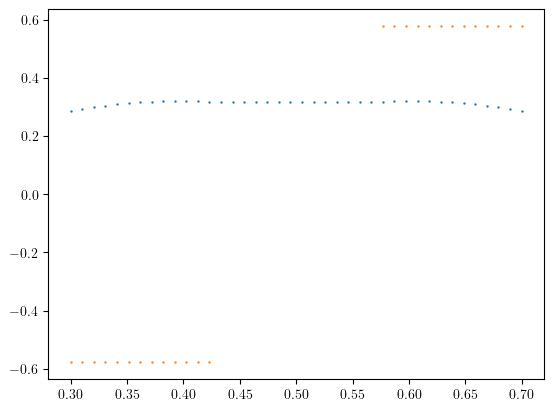

In [ ]:
fig, ax = plt.subplots(1,1)
ax.scatter(rx, dh_opt[:,2])
ax.scatter(rx,dh_opt[:,0])
plt.show()

In [ ]:
N = 40
eps = 0.1
rx = np.linspace(0.2+eps,0.8-eps,N)
ry = np.linspace(0.15,0.4,N)
r = np.meshgrid(rx,ry)

def wrap_optimize(i,j,base):
    x, y = r[0][i,j],r[1][i,j]
    r1 = np.array([x,y])
    r2 = np.array([x-1,y])
    dx, dy, opt = minimize_vxx_by_dy(r1,r2)
    d = np.array([dx,dy,0])
    v1 = dip_derivative_full(np.array([x,y,0]),0,0,d)
    v2 = dip_derivative_full(np.array([x-1,y,0]),0,0,d)
    v3 = dip_derivative_full(np.array([1,0,0]),0,0,d)
    return dx, dy, v1/v3, v2/v3
d_opt = parallel_for([[0,N],[0,N]],wrap_optimize,objective_vxx2)

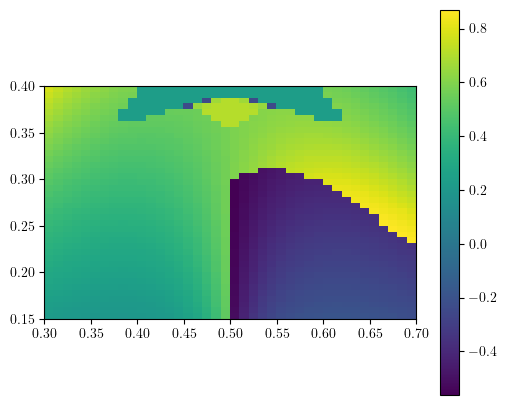

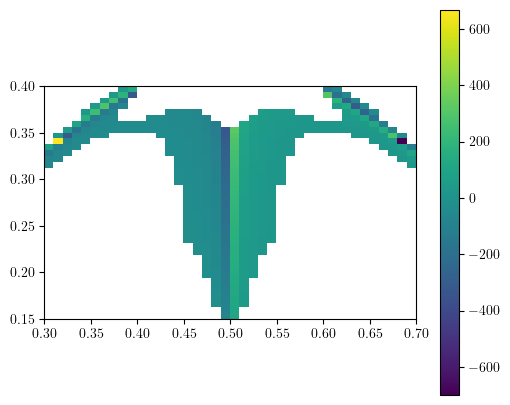

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))

im = ax.imshow(np.where(np.abs(d_opt[:,:,0]**2+d_opt[:,:,1]**2)>(1+1e-2),np.nan,d_opt[:,:,0]),extent=[0.3,0.7,0.15,0.4],origin='lower')
cbar = fig.colorbar(im, ax=ax)
plt.show()
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
def condition():
    return (np.abs(d_opt[:,:,2])<20) | (np.abs(d_opt[:,:,3])<20)
im = ax.imshow(np.where(condition(),np.nan,d_opt[:,:,2]),extent=[0.3,0.7,0.15,0.4],origin='lower')
cbar = fig.colorbar(im, ax=ax)
plt.show()

In [ ]:
N = 10
eps = 0.1
rx = np.linspace(0.2+eps,0.8-eps,N)
ry = np.linspace(0.15,0.4,N)
r = np.meshgrid(rx,ry)
d_angles, ratios = optimize_grid_dipoles(r[0], r[1], alpha=1., use_abs=True, threshold=0.0, seed=42)

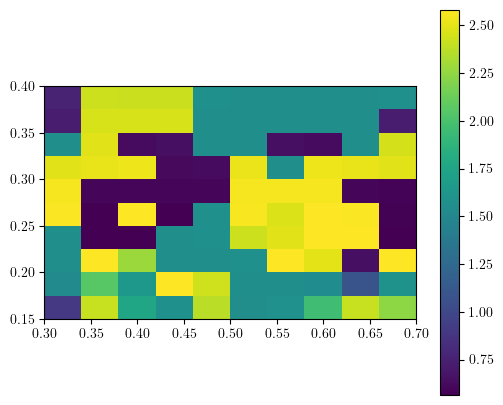

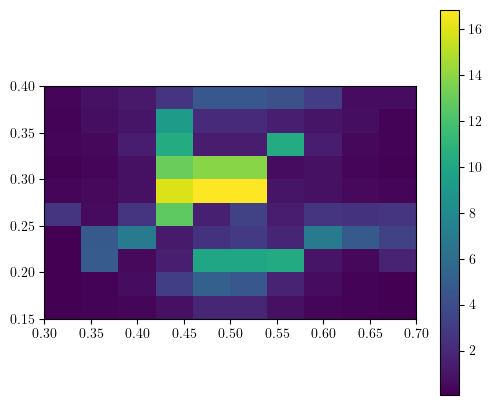

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))

im = ax.imshow(d_angles[:,:,0],extent=[0.3,0.7,0.15,0.4],origin='lower')
cbar = fig.colorbar(im, ax=ax)
plt.show()
fig, ax = plt.subplots(1, 1, figsize=(6, 5))

im = ax.imshow(ratios,extent=[0.3,0.7,0.15,0.4],origin='lower')
cbar = fig.colorbar(im, ax=ax)
plt.show()

In [72]:
N = 30
eps = 0.1
rx = np.linspace(0.2+eps,0.8-eps,N)
ry = np.linspace(0.15,0.4,N)
r = np.meshgrid(rx,ry)
d_angle = np.ones((N,N))
opt_ratio = np.ones((N,N))*np.nan
disi = np.ones((N,N,3))*np.nan
def wrap_optimize(i,j,base):
    x, y = r[0][i,j],r[1][i,j]
    d_theta, d_phi, opt_ratio = optimize_dipole_orientation_3d(x,y,use_abs=True)
    disi = np.array([np.sin(d_theta) * np.cos(d_phi), np.sin(d_theta) * np.sin(d_phi), np.cos(d_theta)])
    return *disi, opt_ratio
d_opt = parallel_for([[0,N],[0,N]],wrap_optimize)
# for i in range(N):
#     for j in range(N):
#         x, y = r[0][i,j],r[1][i,j]
        
#         r1 = np.array([1.0, 0.0])
#         r2 = np.array([x, y])
#         r3 = np.array([x - 1.0, y])
#         d_angle[i,j], opt_ratio[i,j] = optimize_dipole_orientation(x,y,use_abs=True,threshold=100.0)
#         disi[i,j] = np.array([np.cos(d_angle[i,j]),np.sin(d_angle[i,j])])
        


        

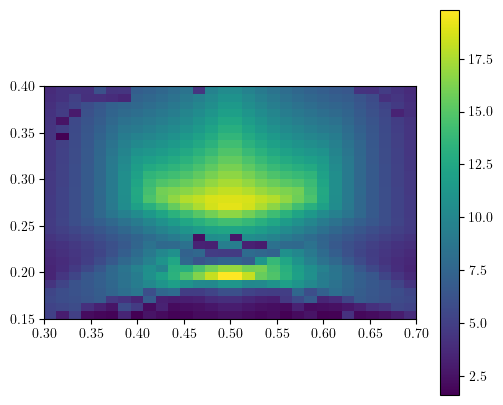

In [73]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
grid_density = 100
thetas = np.linspace(0, np.pi, grid_density)
phis = np.linspace(0, 2 * np.pi, grid_density, endpoint=False)
TH, PH = np.meshgrid(thetas, phis)

# grid_ratios = np.zeros_like(TH)
# for idx in np.ndindex(TH.shape):
#     grid_ratios[idx] = objective_ratio(
#         (TH[idx], PH[idx]), x, y, use_abs=True
#     )
im = ax.imshow(np.abs(d_opt[:,:,3]),extent=[0.3,0.7,0.15,0.4],origin='lower')
cbar = fig.colorbar(im, ax=ax)
plt.show()

In [173]:
green = "darkgreen"

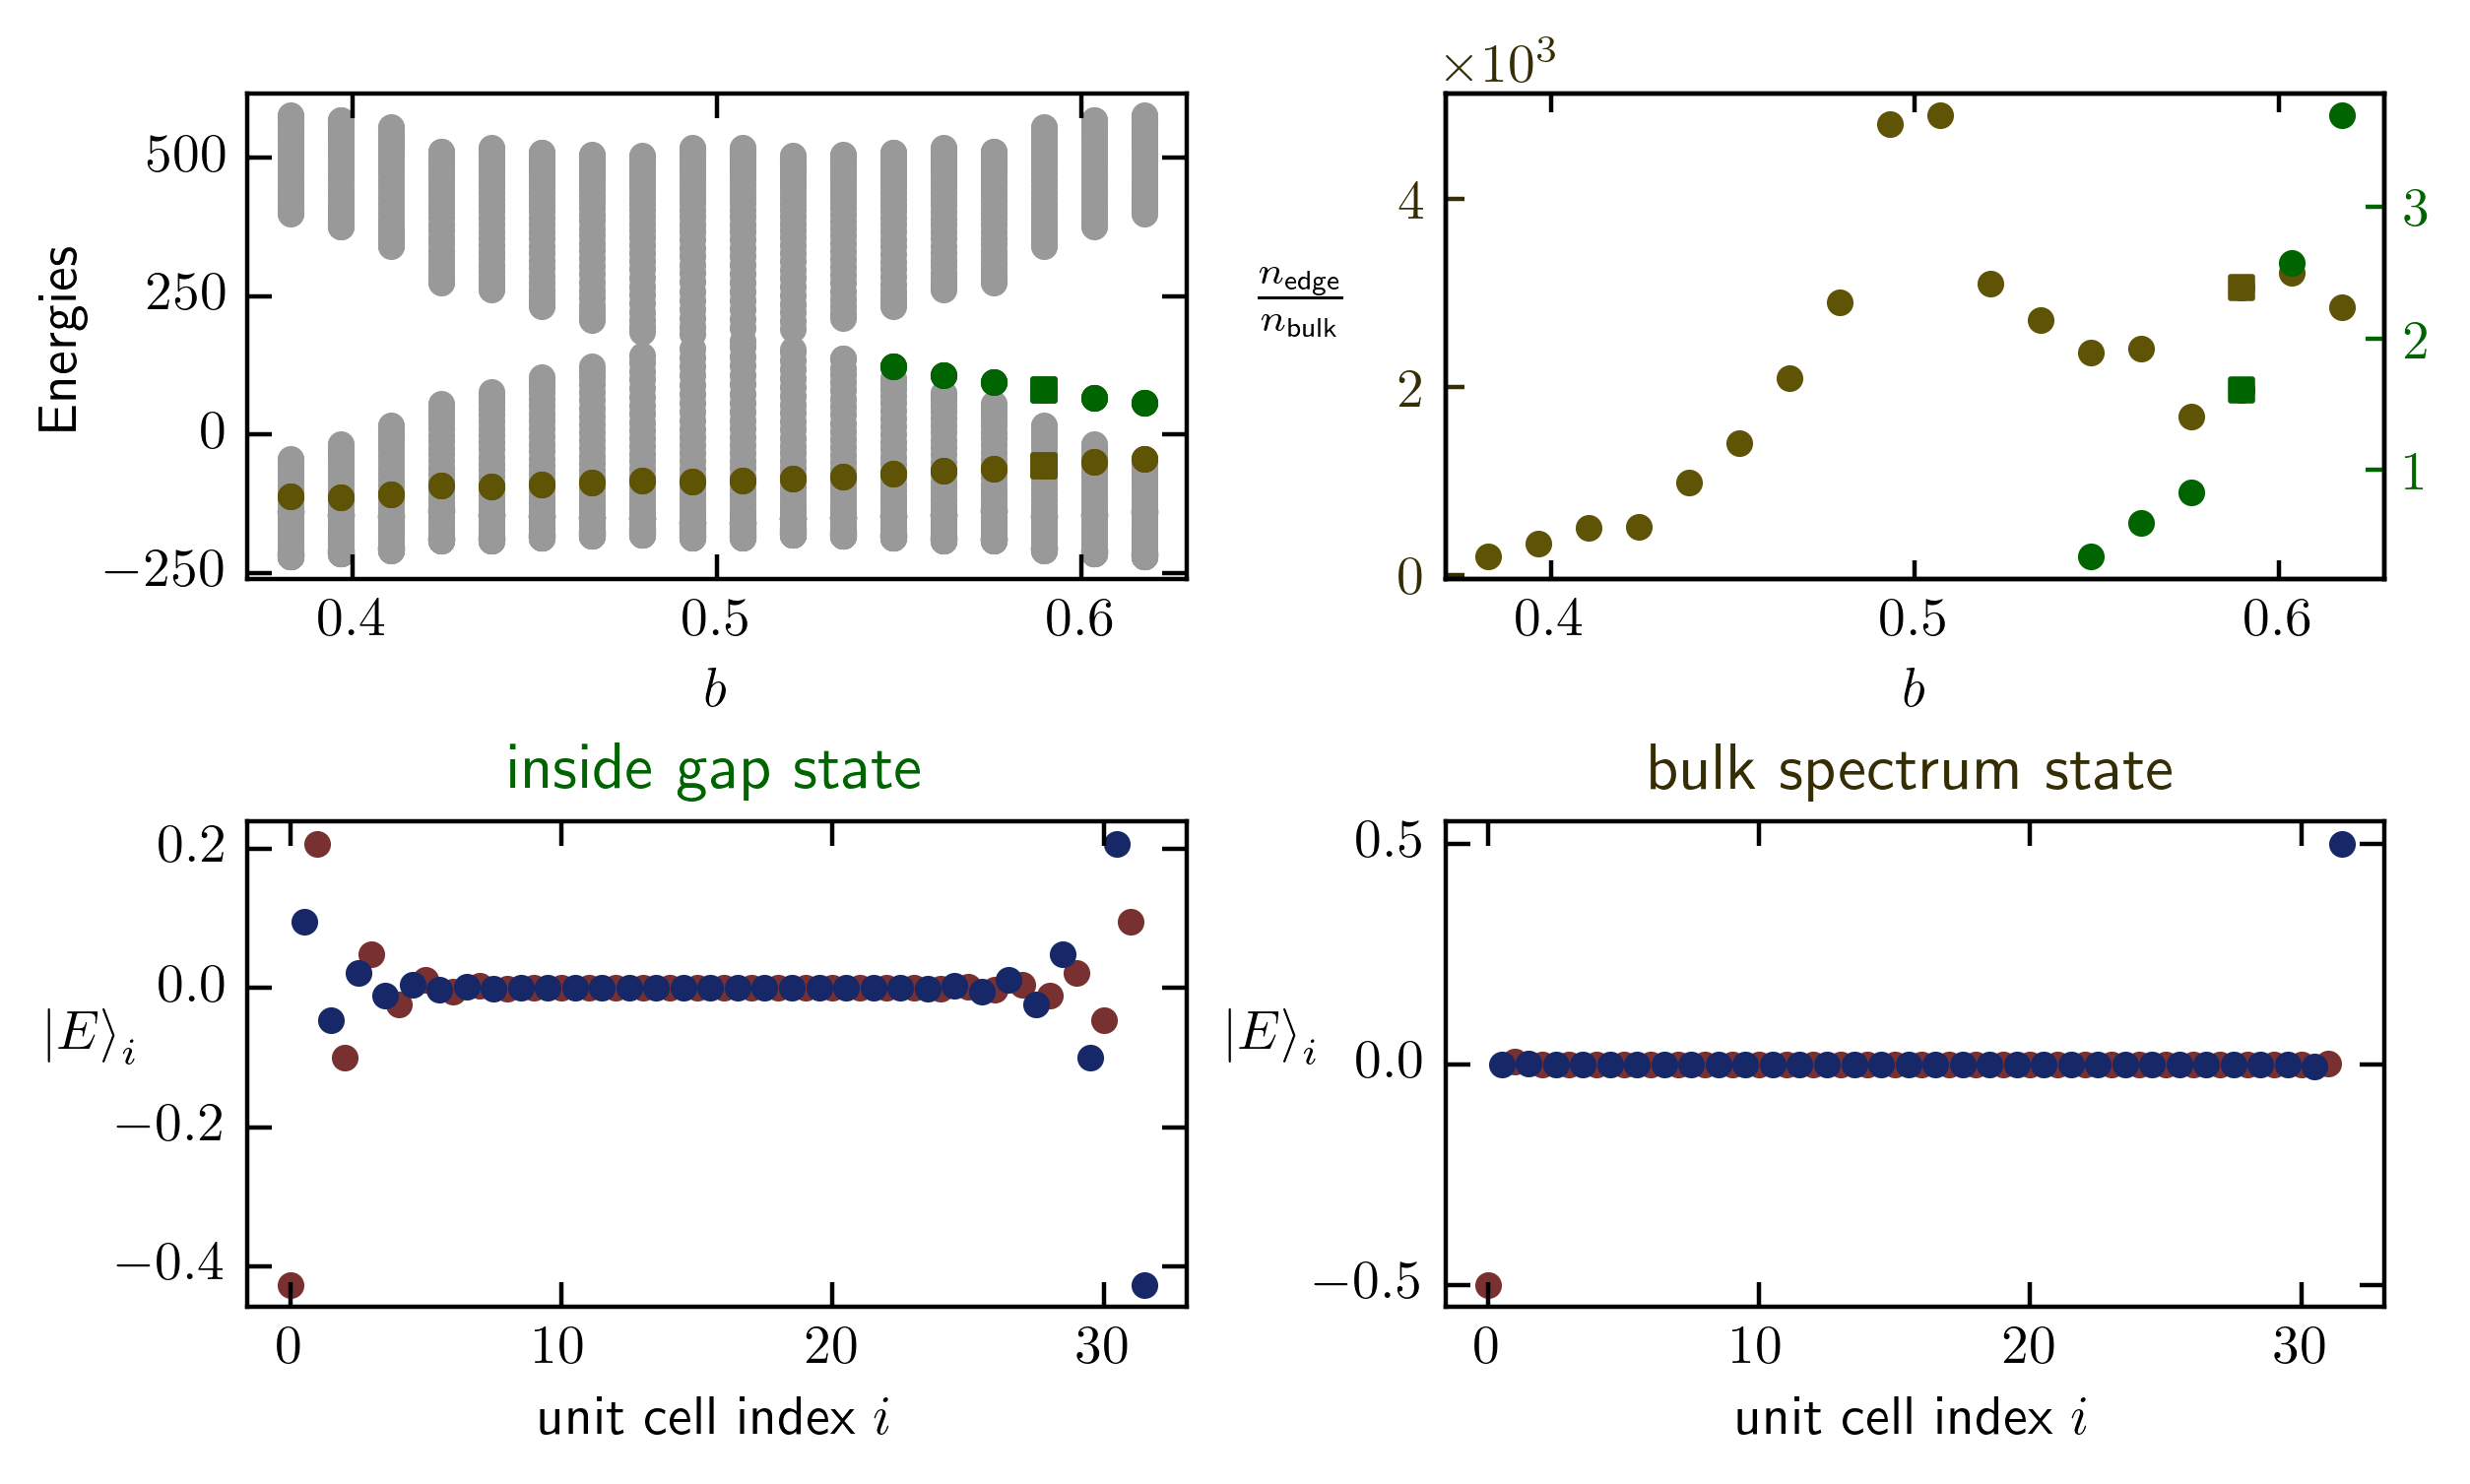

In [ ]:
step = 6
step2 = 6
length = 64
N =30
horizont = np.argmax(d_opt[10:,step:-step,3],axis=0)+10
vertical = np.argmax(d_opt[step2:-step2,:,3],axis=1)
ind = 15
bulk_color="#5f5306ff"
# fig, ax = plt.subplots(1,1)
# fig2, ax2 = plt.subplots(1,1)
tickp = TickProperties(0.15,0.05,0.1,0.05)
setup = Setup_Fig(xax_share=False,yax_share=False,tickp=tickp,fig_width=7,fig_height=4)
fig, ax = setup.return_fig((2,2))
# ax3 = axes[0]
eigenvalues = np.zeros((N-2*step,2*length,2*length+1))
neighbors = np.zeros((N-2*step,2*length,2*length+1))
gapst = np.zeros((N-2*step,2*length,2*length+1))
for i in range(N-2*step):
    b0 = r[0][horizont[i],step+i]
    h = r[1][horizont[i],step+i]
    # print(b0,h)
    # ax2.scatter(b0,h,s=10,color='0')
    Ham= hopping_Ham_xy_alpha(b0,h,0,a,length,dip_derivative_ffull_vec,d_opt[horizont[i],step+i,:3])
    eig, vecs = np.linalg.eigh(Ham)
    
    eigenvalues[i]= sort_eigenvalues(eig,vecs,2)
    neighbors[i] = sort_eigenvalues_energies(eig,vecs,eigenvalues[i,0,0])
    gapst[i] = sort_eigenvalues_energies(eig,vecs,120)
    ax[0,0].scatter(b0*np.ones(2*length-2),eigenvalues[i,2:,0],color='0.6',s=15)
    ax[0,0].scatter(b0*np.ones(2),eigenvalues[i,:2,0],color=bulk_color,s=15)
    if i == ind:
        ax[0,0].scatter(b0*np.ones(2),gapst[i,:2,0],color=green,s=15,marker="s")
        ax[0,0].scatter(b0*np.ones(2),eigenvalues[i,:2,0],color=bulk_color,s=15,marker='s')
    elif i >11:
        ax[0,0].scatter(b0*np.ones(2),gapst[i,:2,0],color=green,s=15)
# plt.show()
ax[0,0] = setup.format_ax(ax[0,0],(1,2),j=0,set_ticks=False)
edge_size = 4
# fig, ax = plt.subplots(1,1) 
ax[0,1].scatter(r[0][0,step+ind],np.sum(np.abs(eigenvalues[ind,0,1:1+edge_size])**2)/np.sum(np.abs(eigenvalues[ind,0,1+edge_size:-edge_size])**2),color=bulk_color,s=15,marker='s')
ax[0,1].scatter(r[0][0,step:-step],np.sum(np.abs(eigenvalues[:,0,1:1+edge_size])**2,axis=1)/np.sum(np.abs(eigenvalues[:,0,1+edge_size:-edge_size])**2,axis=1),color=bulk_color,s=15)
ax1 = ax[0,1].twinx()
ax1.scatter(r[0][0,step+12:-step],np.sum(np.abs(gapst[12:,0,1:1+edge_size])**2,axis=1)/np.sum(np.abs(gapst[12:,0,1+edge_size:-edge_size])**2,axis=1),color=green,s=15)
ax1.scatter(r[0][0,step+ind],np.sum(np.abs(gapst[ind,0,1:1+edge_size])**2)/np.sum(np.abs(gapst[ind,0,1+edge_size:-edge_size])**2),color=green,s=15,marker='s')
ax1.tick_params(axis='y',direction='in',which='both',left=False,right=True,labelright=True,colors=green) 
ax[0,1].tick_params(axis='x',direction='in',which='both',bottom=True,top=True,labelbottom=True)
ax[0,1].tick_params(axis='y',direction='in',which='both',left=True,right=False,labelleft=True,colors="#352e04ff")   
ax[0,1].ticklabel_format(style='sci', axis='y', scilimits=(4, 5), useMathText=True)
ax[0,0].set_xlabel(r"$b$")
ax[0,0].set_ylabel(r"Energies",labelpad=3)
ax[0,1].set_xlabel(r"$b$")
ax[0,1].set_ylabel(r"$\frac{n_\text{edge}}{n_\text{bulk}}$",rotation=0,labelpad=18)
latticeA = np.stack((np.arange(length//2+length%2),np.zeros(length//2+length%2))).T * a
latticeB = np.stack((np.arange(length//2)*a+0.5,np.ones(length//2)*h)).T 
i=0
ax[1,0].scatter(latticeA[:,0],gapst[ind,i,1::4],color="#793030ff",s=15)
ax[1,0].scatter(latticeB[:,0],gapst[ind,i,3::4],color="#162868ff",s=15)

ax[1,1].scatter(latticeA[:,0],eigenvalues[ind,i,1::4],color="#793030ff",s=15)
ax[1,1].scatter(latticeB[:,0],eigenvalues[ind,i,3::4],color="#162868ff",s=15)
ax[1,0].set_xlabel(r"unit cell index $i$")
ax[1,0].set_ylabel(r"$\ket{E}_i$",rotation=0)
ax[1,1].set_ylabel(r"$\ket{E}_i$",rotation=0,labelpad=7)
ax[1,1].set_xlabel(r"unit cell index $i$")
ax[1,1].set_title(r"bulk spectrum state",color="#352e04ff")
ax[1,0].set_title(r"inside gap state",color=green)
ax[1,0] = setup.format_ax(ax[1,0],(2,2),j=0,set_ticks=False)
ax[1,1] = setup.format_ax(ax[1,1],(2,2),j=0,set_ticks=False)
plt.subplots_adjust(wspace=0.275,hspace=0.5)
# ax1.set_ylabel(r"\frac{n}")
# for i in range(N-2*step2):
#     b0 = r[0][step2+i,vertical[i]]
#     h = r[1][step2+i,vertical[i]]
#     # print(b0,h)
#     Ham= hopping_Ham_xy(b0,h,0,a,length,dip_derivative_ffull_vec,d_opt[step2+i,vertical[i],:3])
#     eig, vecs = np.linalg.eigh(Ham)
#     ax.scatter(b0*np.ones(2*length),eig,color='0',s=15)
# plt.savefig("/home//christian/Documents/master/protocol/pictures/"+"edge_occupation_xy_model.pdf",bbox_inches='tight')
plt.show()

In [186]:
np.sum(np.abs(gapst[ind,0,1:1+edge_size])**2)/np.sum(np.abs(gapst[ind,0,1+edge_size:-edge_size])**2)

np.float64(2.1516717638421325)

-108.41943758530299 0.32758620689655177


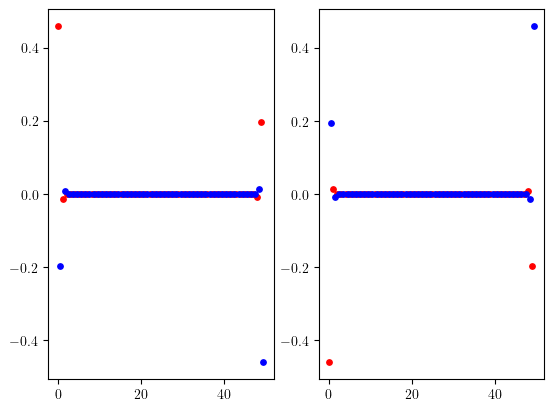

-108.41943758777082 0.32758620689655177


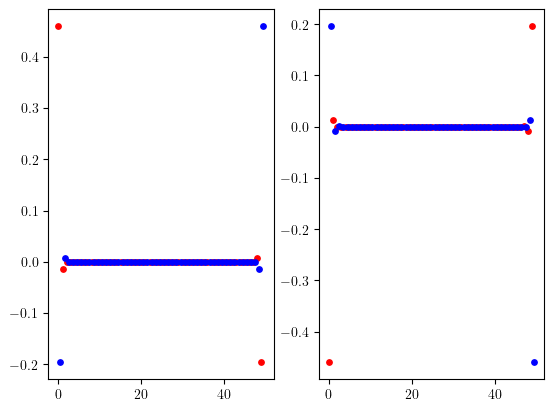

-107.28187666758238 0.32758620689655177


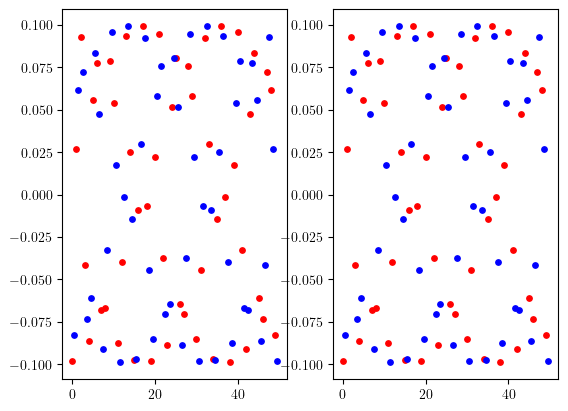

-113.90003772556261 0.32758620689655177


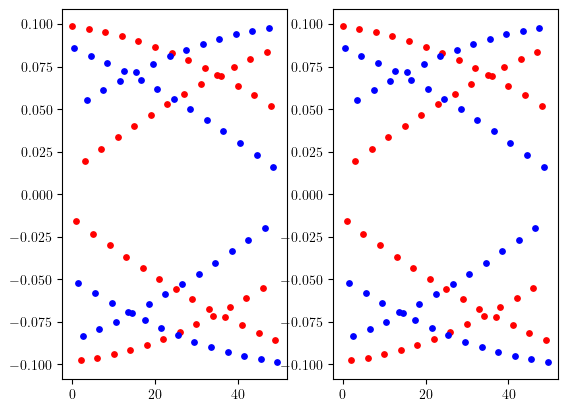

-100.55216175614463 0.32758620689655177


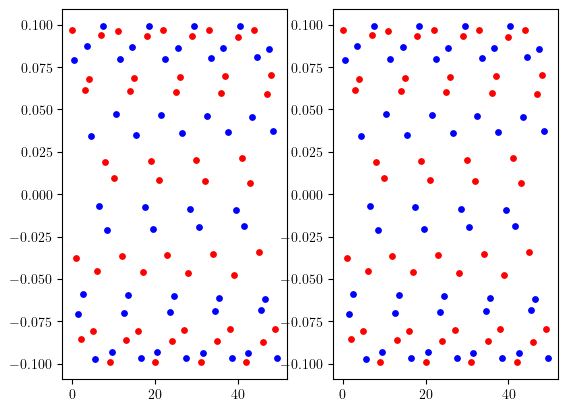

-120.3894114637944 0.32758620689655177


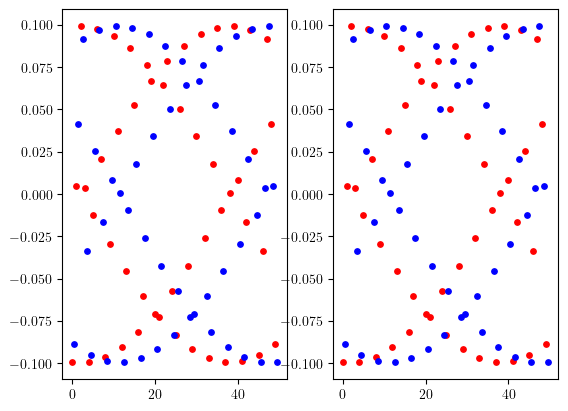

In [128]:
latticeA = np.stack((np.arange(length//2+length%2),np.zeros(length//2+length%2))).T * a
latticeB = np.stack((np.arange(length//2)*a+0.5,np.ones(length//2)*h)).T 
for i in range(6):
    fig, ax = plt.subplots(1,2)
    ind = 2
    print(neighbors[ind,i,0],rx[ind])
    ax[0].scatter(latticeA[:,0],neighbors[ind,i,1::4],color="red",s=15)
    ax[0].scatter(latticeB[:,0],neighbors[ind,i,3::4],color="blue",s=15)

    ax[1].scatter(latticeA[:,0],neighbors[ind,i,2::4],color="red",s=15)
    ax[1].scatter(latticeB[:,0],neighbors[ind,i,4::4],color="blue",s=15)
    plt.show()

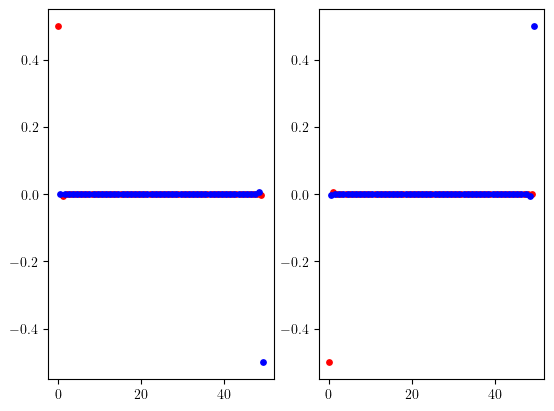

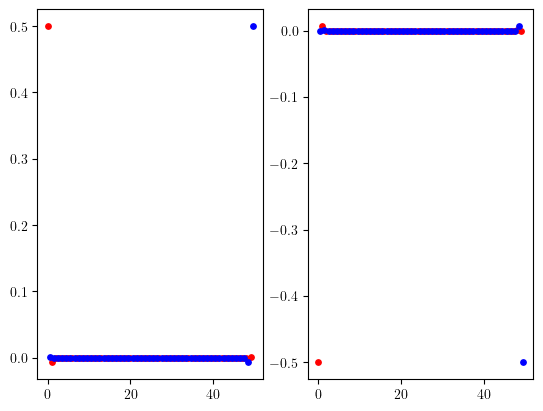

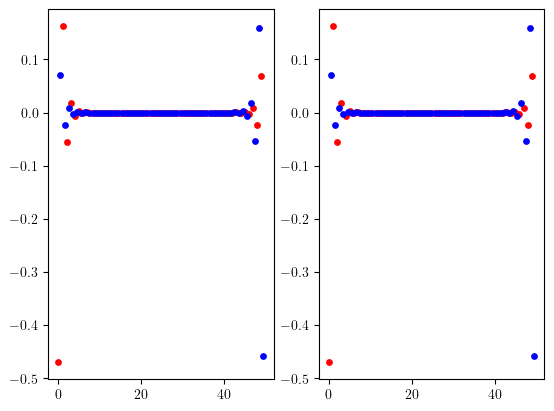

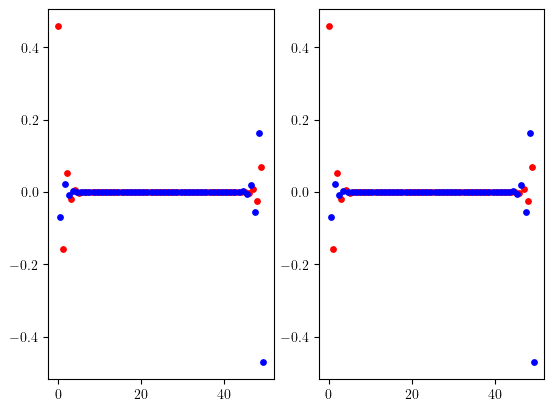

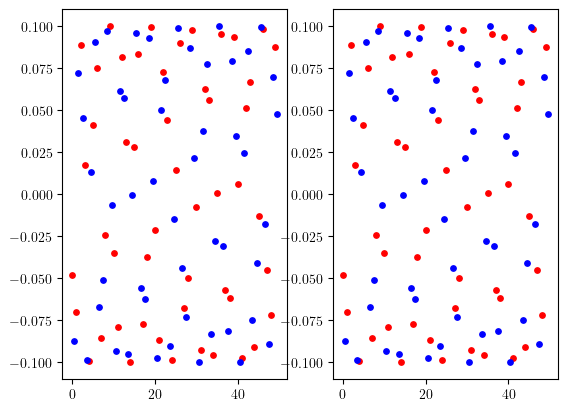

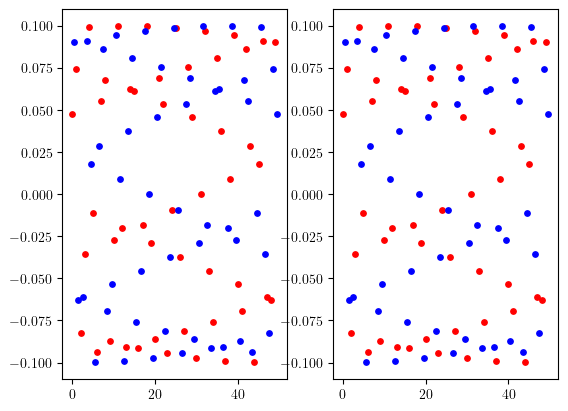

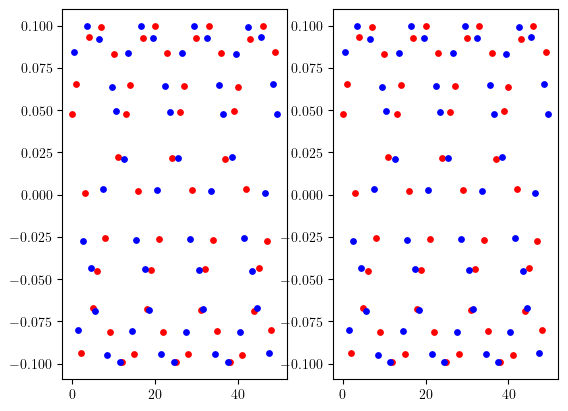

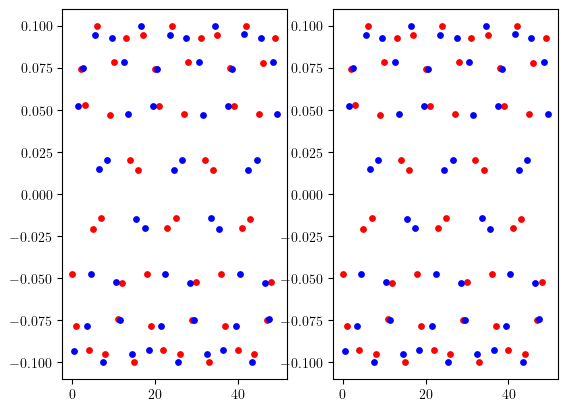

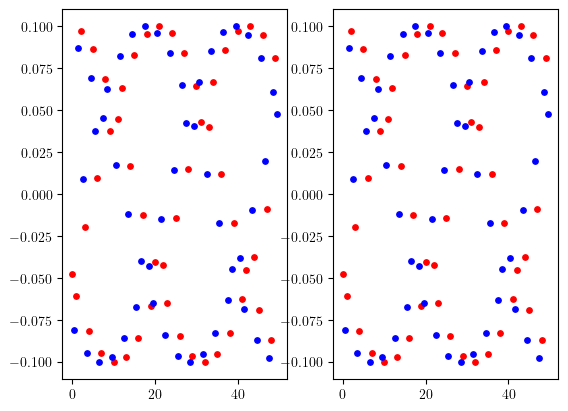

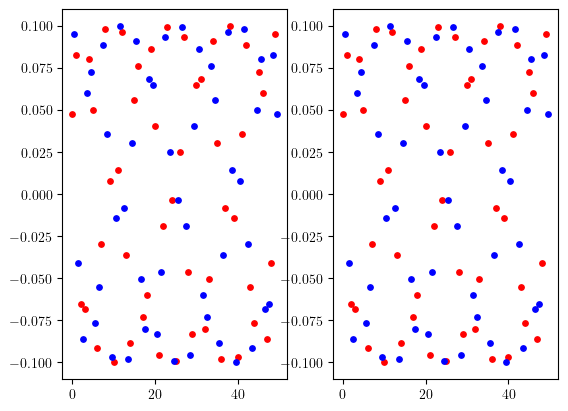

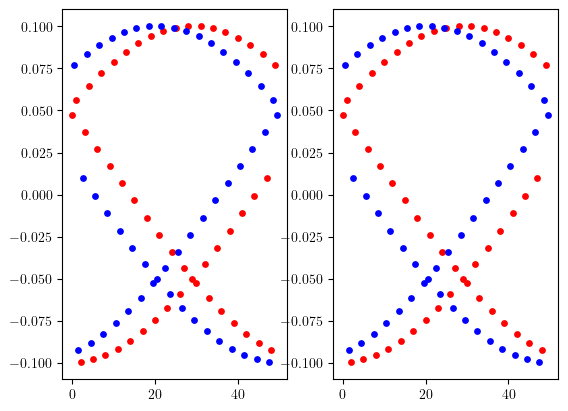

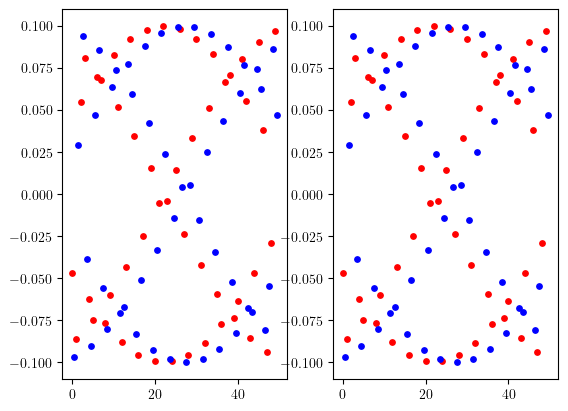

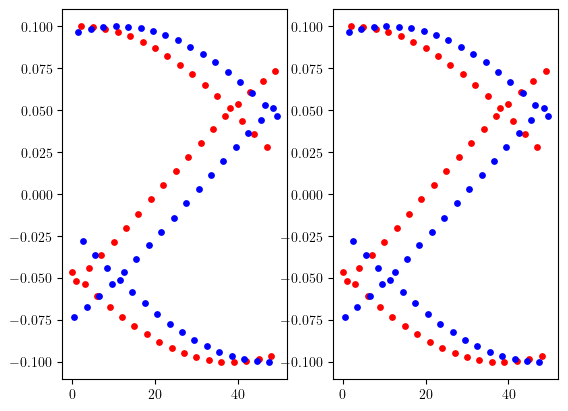

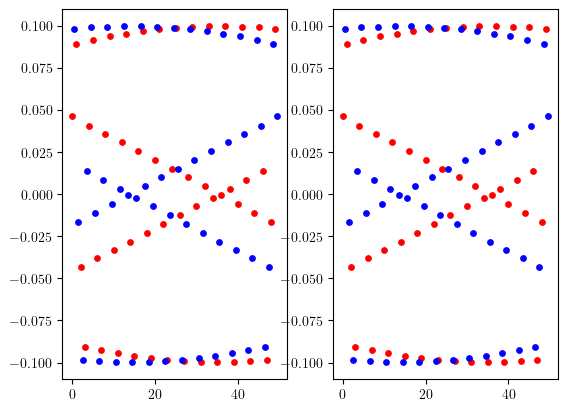

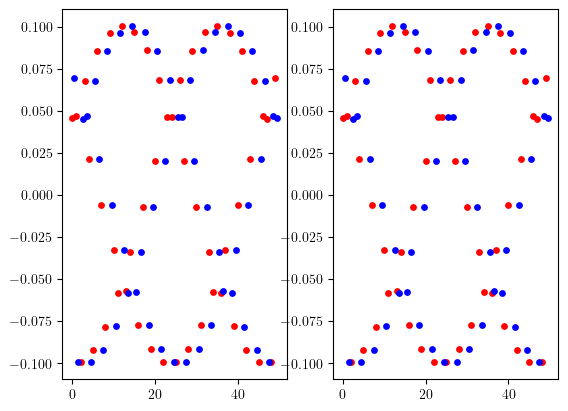

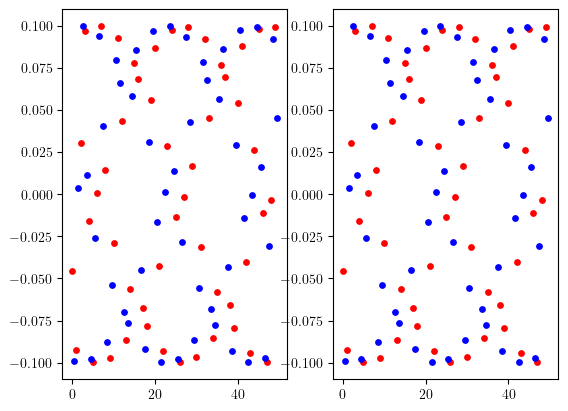

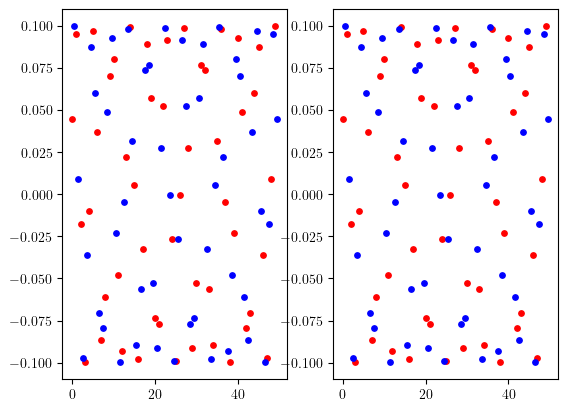

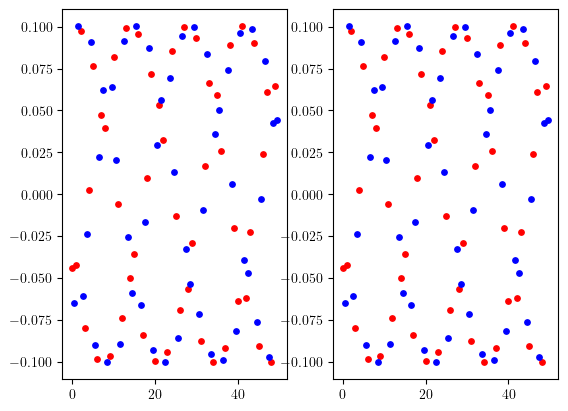

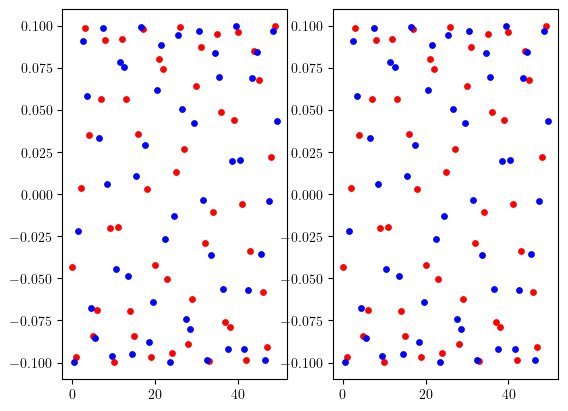

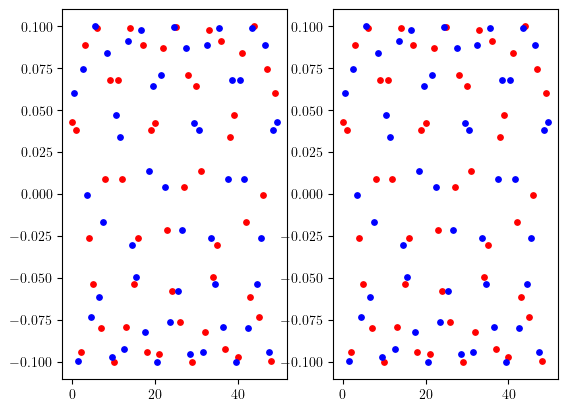

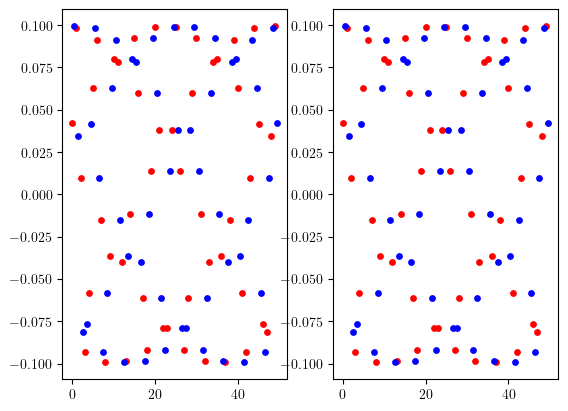

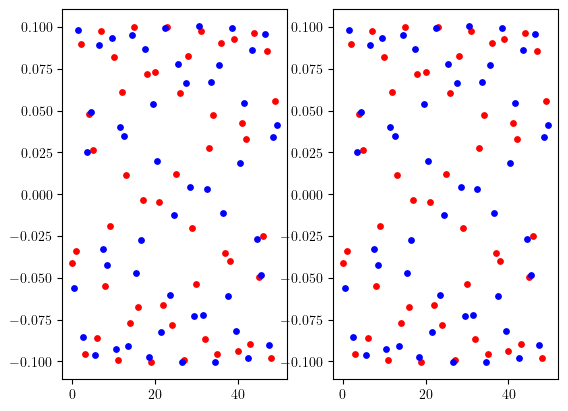

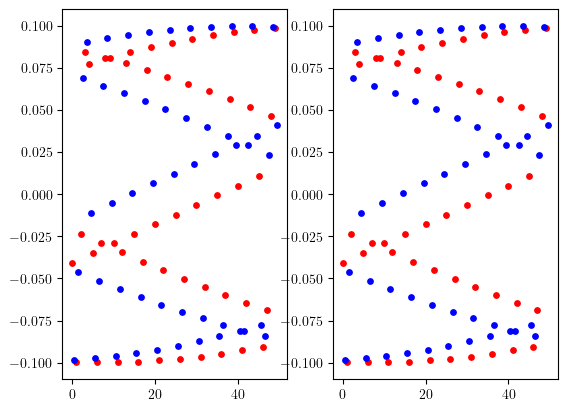

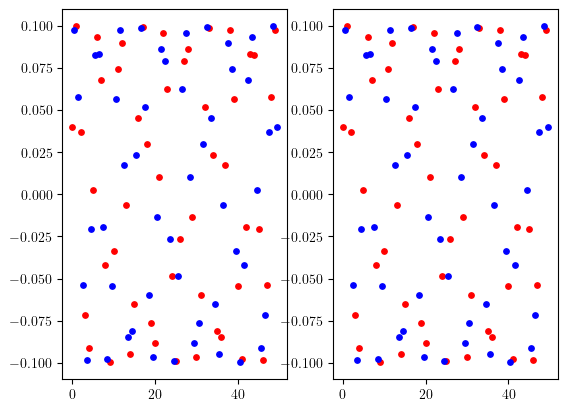

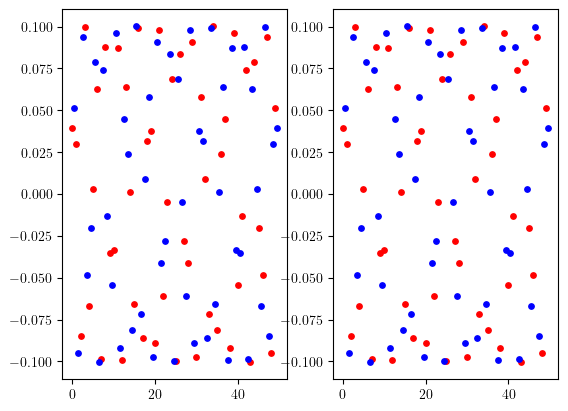

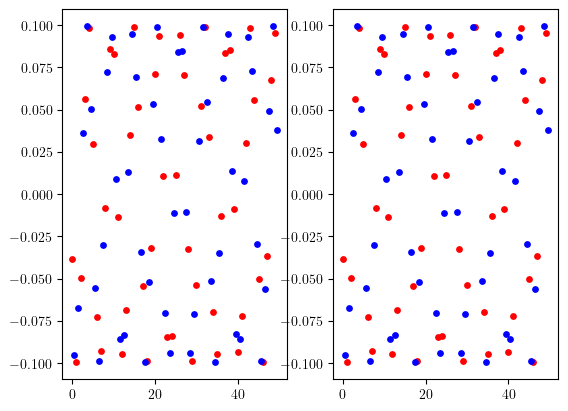

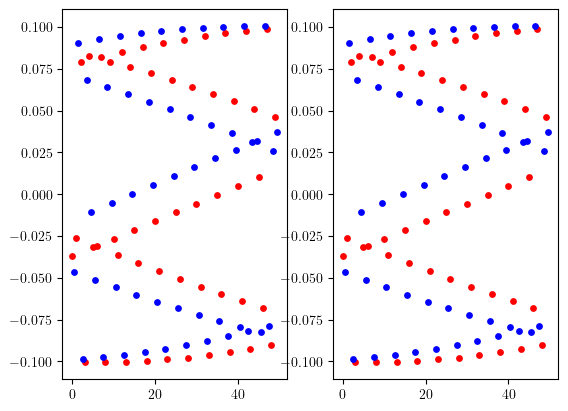

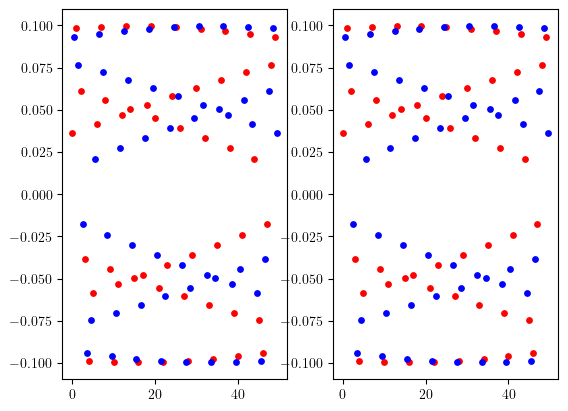

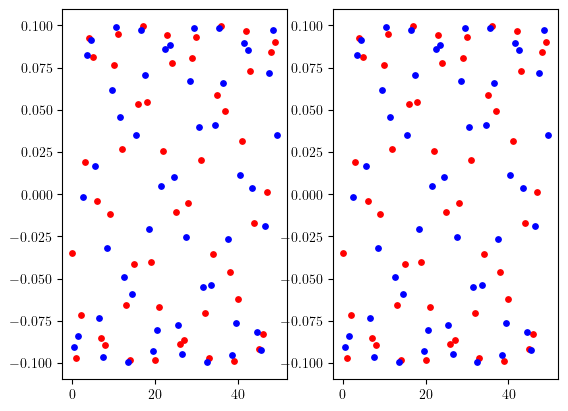

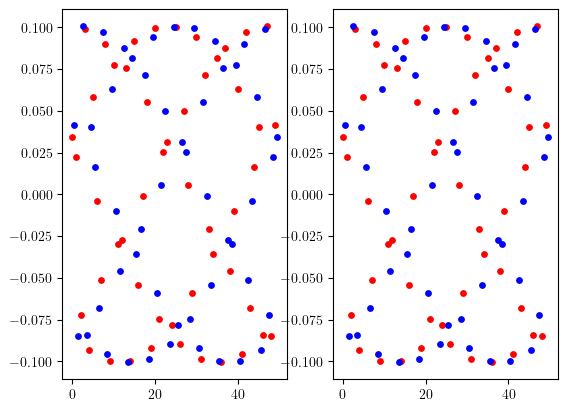

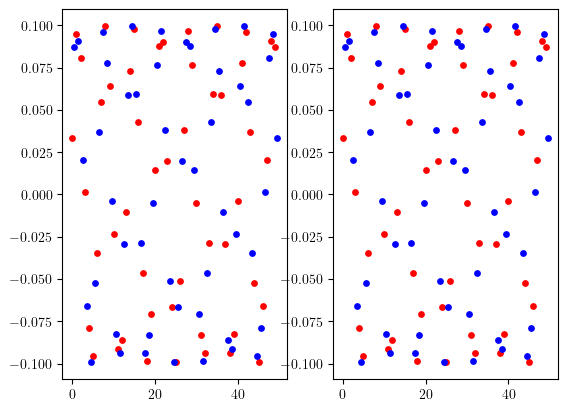

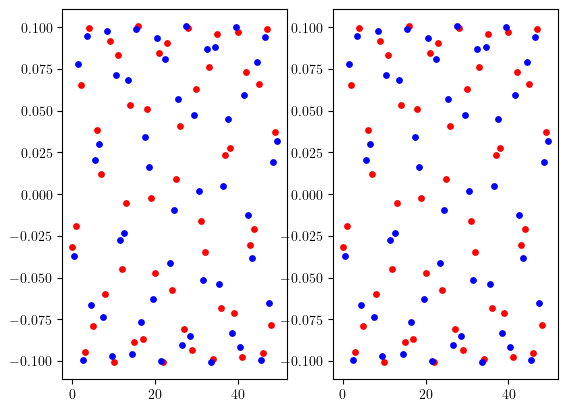

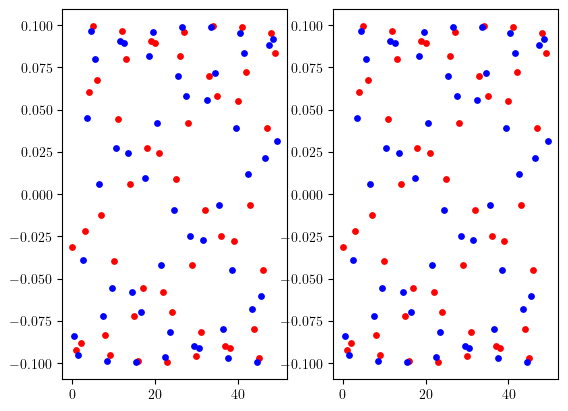

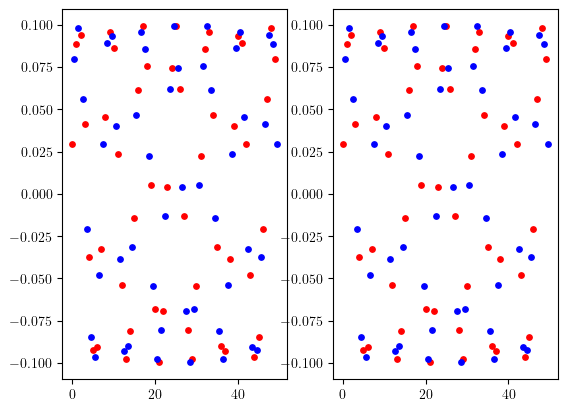

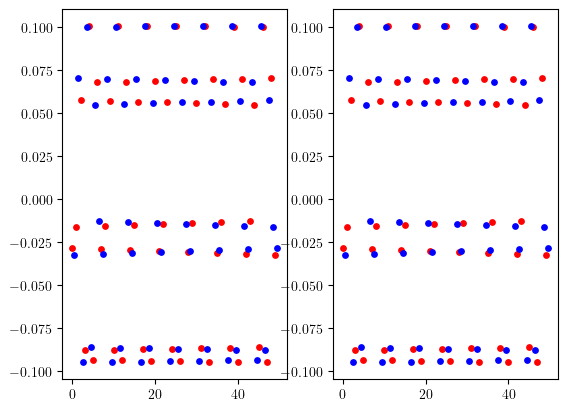

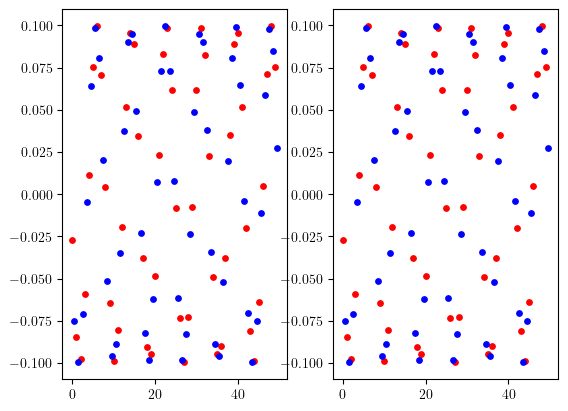

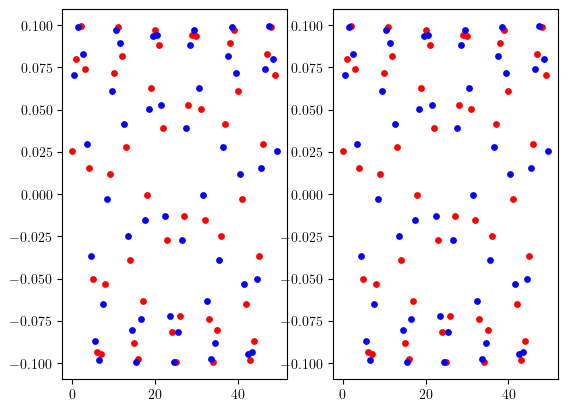

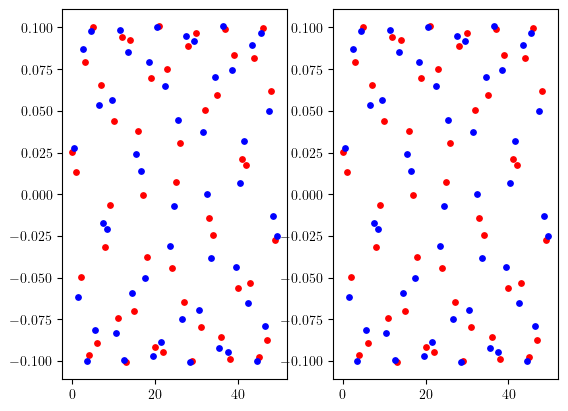

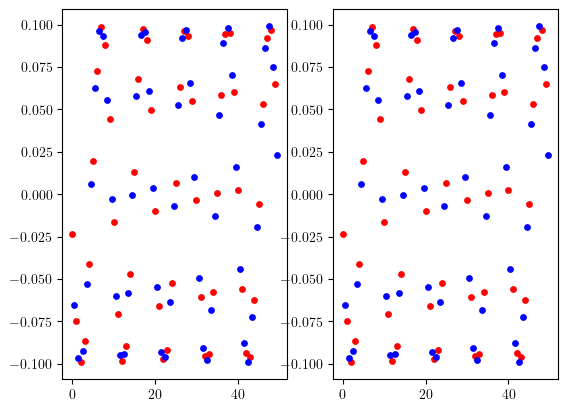

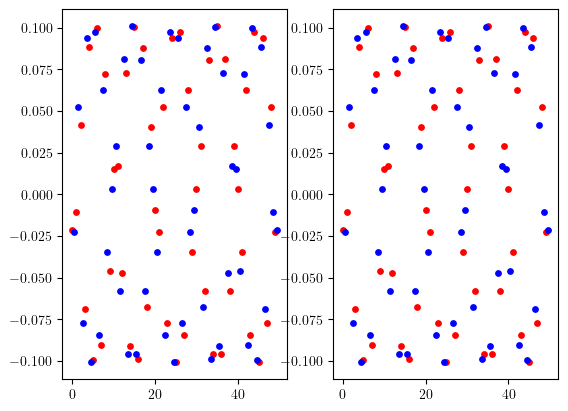

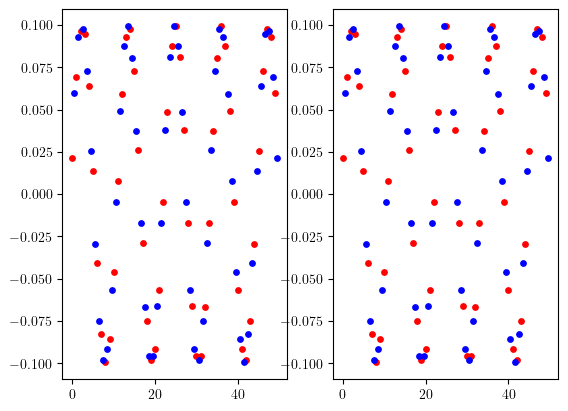

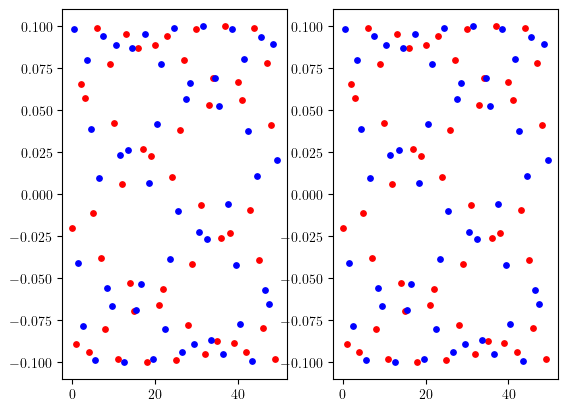

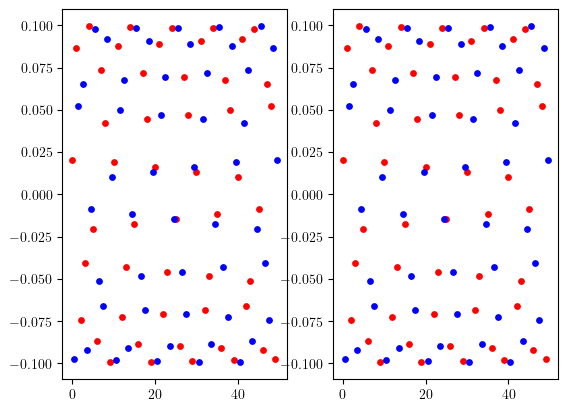

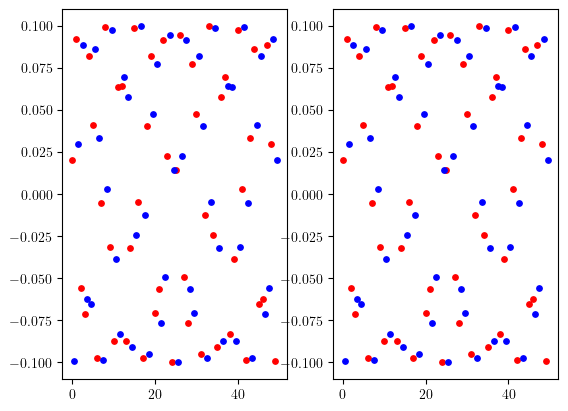

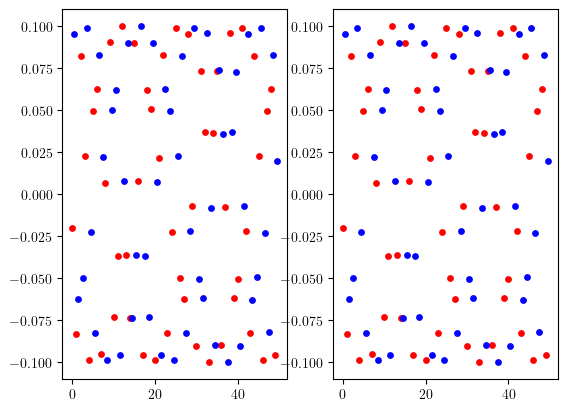

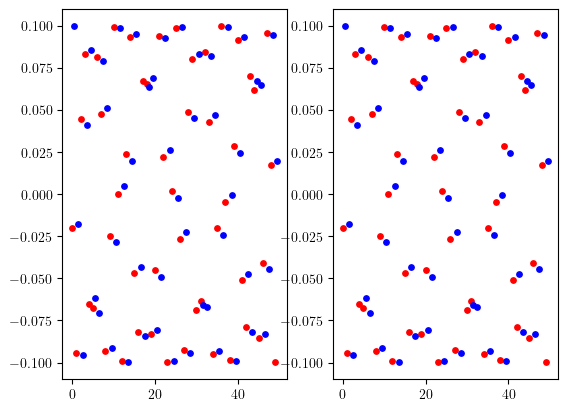

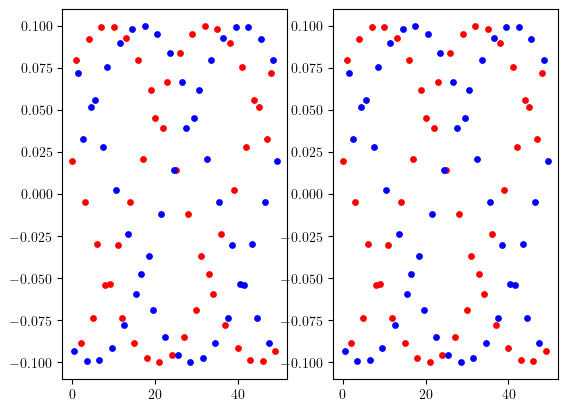

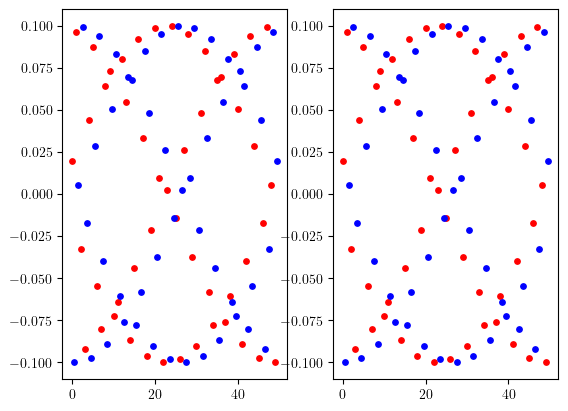

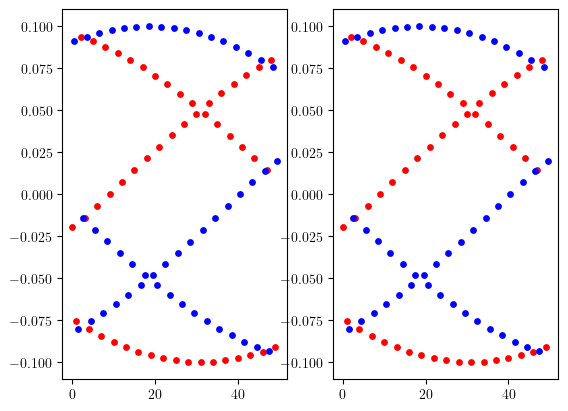

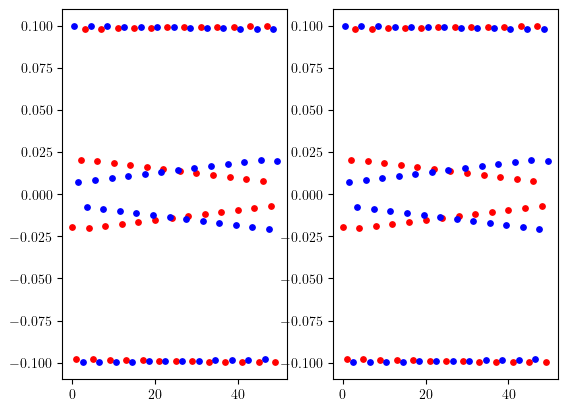

KeyboardInterrupt: 

In [177]:
latticeA = np.stack((np.arange(length//2+length%2),np.zeros(length//2+length%2))).T * a
latticeB = np.stack((np.arange(length//2)*a+0.5,np.ones(length//2)*h)).T 
for i in range(2*length):
    fig, ax = plt.subplots(1,2)
    ind = 17
    # print(eigenvalues[ind,i,0],rx[ind])
    ax[0].scatter(latticeA[:,0],eigenvalues[ind,i,1::4],color="red",s=15)
    ax[0].scatter(latticeB[:,0],eigenvalues[ind,i,3::4],color="blue",s=15)

    ax[1].scatter(latticeA[:,0],eigenvalues[ind,i,2::4],color="red",s=15)
    ax[1].scatter(latticeB[:,0],eigenvalues[ind,i,4::4],color="blue",s=15)
    plt.show()


0.38888888888888895 0.28888888888888886
0.43333333333333335 0.28888888888888886
0.47777777777777786 0.28888888888888886
0.5222222222222223 0.28888888888888886
0.5666666666666667 0.28888888888888886
0.6111111111111112 0.28888888888888886


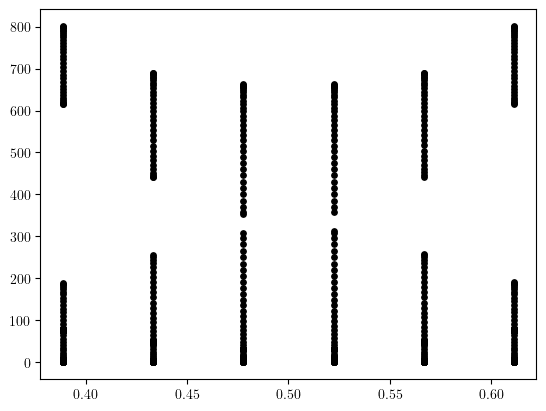

In [ ]:
length 
eigenvalues = np.zeros((6,2*length,2*length+1))
fig, ax = plt.subplots(1,1)
for i in range(2,8):
    b0 = r[0][5,i]
    h = r[1][5,i]
    # print(b0,h)
    
    # Hamx = nearest_nb_Hamiltonian(b0,h,a,length,lambda r,d : dip_derivative_full(r,0,0,d),0,d_opt[5,i,:2])
    # Hamx = nearest_nb_Hamiltonian_test(0,b0,h,a,length,lambda r,d : dip_derivative_full(r,1,1,d),0,d_opt[5,i,:2])
    # eig, vecs = np.linalg.eigh(Hamx)
    Ham= hopping_Ham_xy(b0,h,0,a,length,dip_derivative_ffull_vec,d_opt[5,i,:3])
    eig, vecs = np.linalg.eigh(Ham)
    # eigenvalues[i-2] = sort_eigenvalues(eig,vecs)
    # print(d_opt[5,i,3])
    ax.scatter(b0*np.ones(2*length),eig,color='0',s=15)

plt.show()


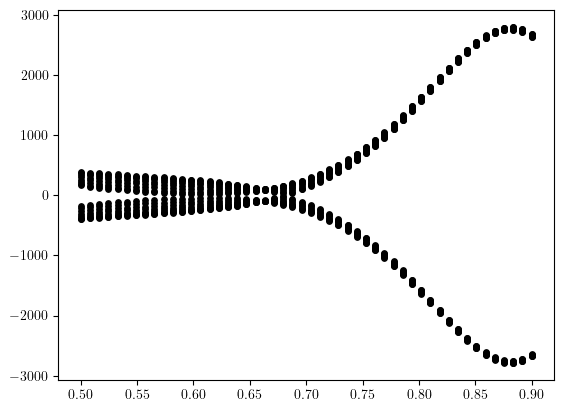

(2,)


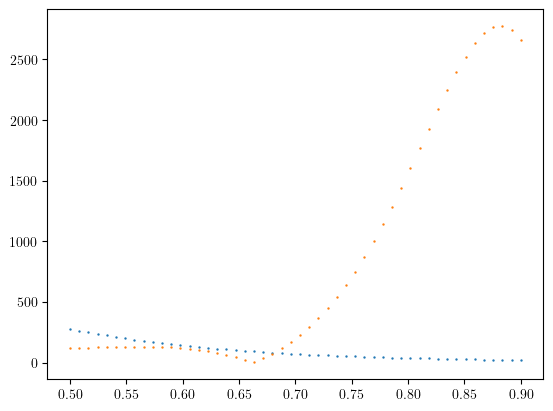

In [18]:
length = 16
eigenvalues = np.zeros((len(rx),length,length+1))
fig, ax = plt.subplots(1,1)
rx = np.linspace(0.5,0.9)
for i in range(len(rx)):
    b0 = rx[i]
    h = 0.3
    d= np.array([np.sqrt(1/3),np.sqrt(2/3)])
    # print(b0,h)
    
    # Hamx = nearest_nb_Hamiltonian(b0,h,a,length,lambda r,d : dip_derivative_full(r,0,0,d),0,d)
    Hamx = hopping_Ham_alpha(b0,h,1,a,length,lambda r,d : dip_derivative_ffull_vec(r,0,0,d),d)
    # Hamx = nearest_nb_Hamiltonian_test(0.9,b0,h,a,length,lambda r,d : dip_derivative_full(r,0,0,d),0,d)
    eig, vecs = np.linalg.eigh(Hamx)
    # Ham= hopping_Ham_xy(b0,h,0,a,length,dip_derivative_ffull_vec,d_opt[5,i,:3])
    # eig, vecs = np.linalg.eigh(Ham)
    eigenvalues[i] = sort_eigenvalues(eig,vecs)
    # print(d_opt[5,i,3])
    ax.scatter(b0*np.ones(length),eig,color='0',s=15)
plt.show()
fig, ax = plt.subplots(1,1)
print(dip_derivative_ffull_vec(np.array([rx,h*np.ones(len(rx))]),0,0,d).shape)
ax.scatter(rx,np.abs(dip_derivative_ffull_vec(np.array([rx,h*np.ones(len(rx))]).T,0,0,d)))
ax.scatter(rx,np.abs(dip_derivative_ffull_vec(np.array([rx-1,h*np.ones(len(rx))]).T,0,0,d)))
plt.show()

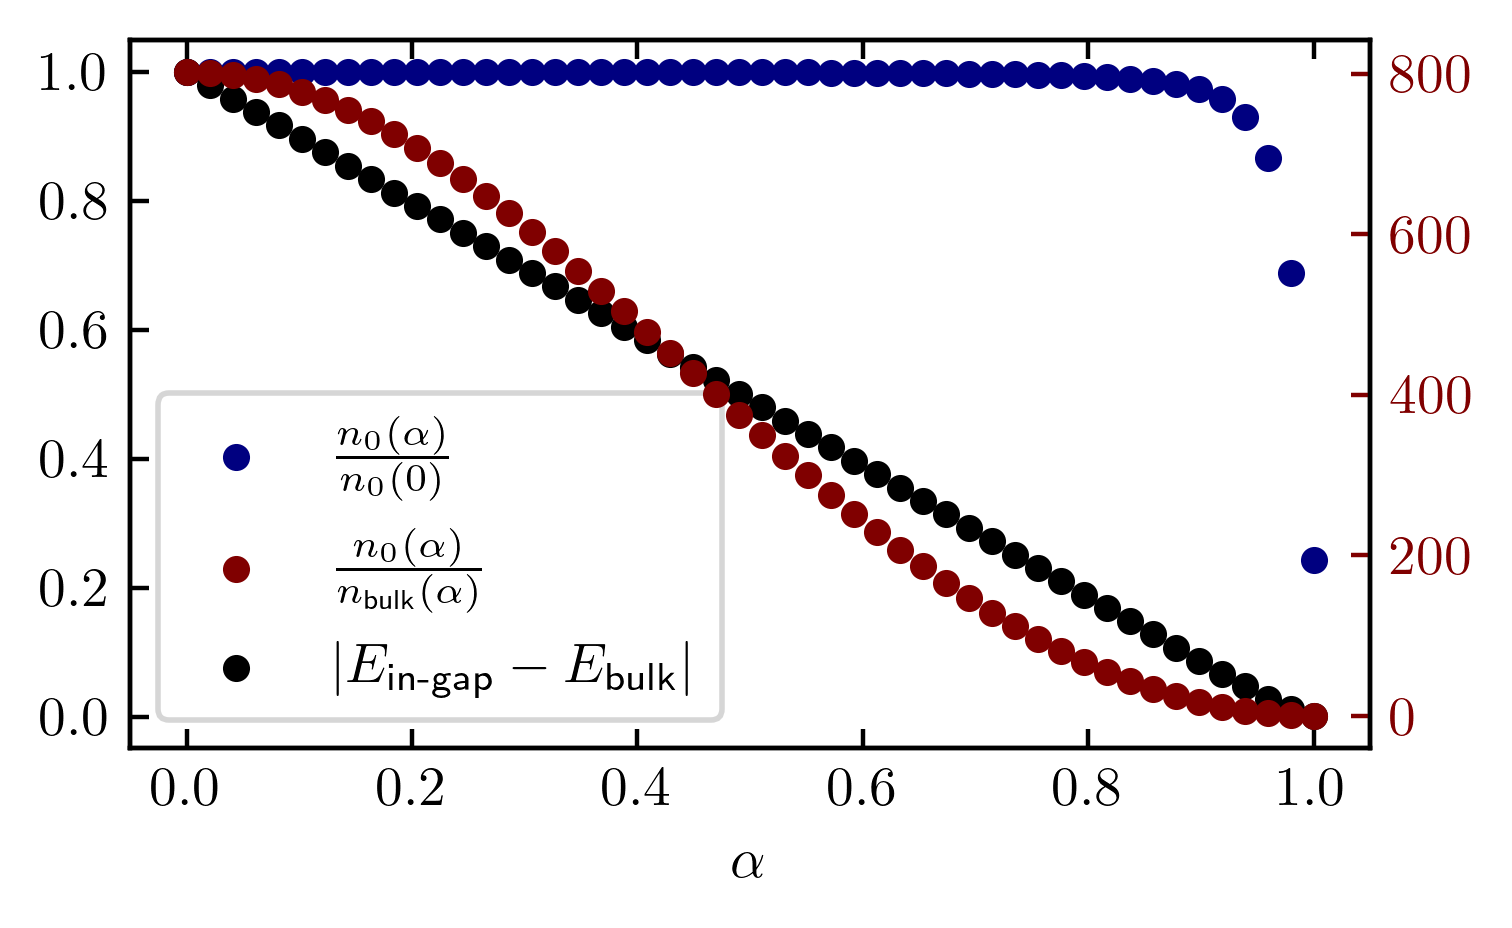

In [ ]:
N = 50
length = 64
alphas = np.linspace(0,1,N)
eigenvalues = np.zeros((N,length,length+1))
eigen = np.zeros((N,length))
for i in range(N):
    b0 = 0.8
    h = 0.3
    Hamx = hopping_Ham_alpha(b0,h,alphas[i],a,length,lambda r,d : dip_derivative_ffull_vec(r,0,0,d),d)
    eig, vecs = np.linalg.eigh(Hamx)
    eigenvalues[i] = sort_eigenvalues(eig,vecs)
    eigen[i] = sorted(np.abs(eig))

tickp = TickProperties(0.15,0.05,0.1,0.05)
setup = Setup_Fig(xax_share=True,yax_share=True,tickp=tickp,fig_width=4,fig_height=2.3)
fig, ax = setup.return_fig((1,1))#
ax1 = ax.twinx()
#
line2 = ax.scatter(alphas,np.abs(eigenvalues[:,0,1])**2/np.abs(eigenvalues[0,0,1])**2,s=15,color="navy",label=r"$\frac{n_0(\alpha)}{n_0(0)}$")
# line2 = ax.scatter(alphas,np.linalg.norm(eigenvalues[:,0,1:],axis=1),s=15,color="navy",label=r"$\frac{n_0(\alpha)}{n_0(0)}$")
# plt.show()
# fig, ax = plt.subplots(1,1)#
line3 = ax.scatter(alphas,np.abs(eigenvalues[:,0,0]-eigen[:,2])/np.abs(eigenvalues[0,0,0]-eigen[0,2]),s=15,color="0",label=r"$|E_\text{in-gap}-E_\text{bulk}|$")
line1 = ax1.scatter(alphas,np.abs(eigenvalues[:,0,1])**2/np.sum(np.abs(eigenvalues[:,0,2:-1])**2,axis=1),s=15,color="maroon",label=r"$\frac{n_0(\alpha)}{n_\text{bulk}(\alpha)}$")
lines = [line2, line1, line3]
labels = [line.get_label() for line in lines]
ax.legend(lines,labels)
# ax1.tick_params(axis='y', colors='maroon',grid_color='maroon')
ax1.tick_params(axis='y',direction='in',which='both',left=False,right=True,labelright=True,colors="maroon") 
ax.tick_params(axis='x',direction='in',which='both',bottom=True,top=True,labelbottom=True)
ax.tick_params(axis='y',direction='in',which='both',left=True,right=False,labelleft=True)   
  
ax.set_xlabel(r"$\alpha$")
# ax1 = setup.format_ax(ax1,(1,1),set_ticks=False)
# ax = setup.format_ax(ax,(1,1),set_ticks=False)
# plt.savefig("/home//christian/Documents/master/protocol/pictures/"+"edge_occupation_alpha.pdf",bbox_inches='tight')
plt.show()

556.3239778867692 0.7448979591836735


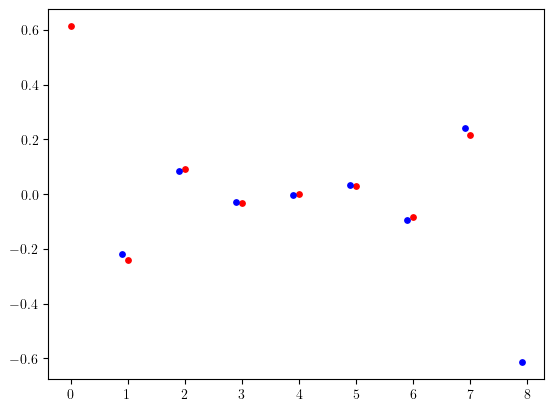

556.2171230948418 0.7448979591836735


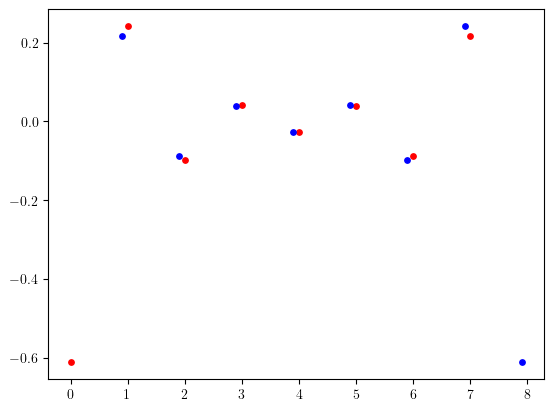

629.8758491610928 0.7448979591836735


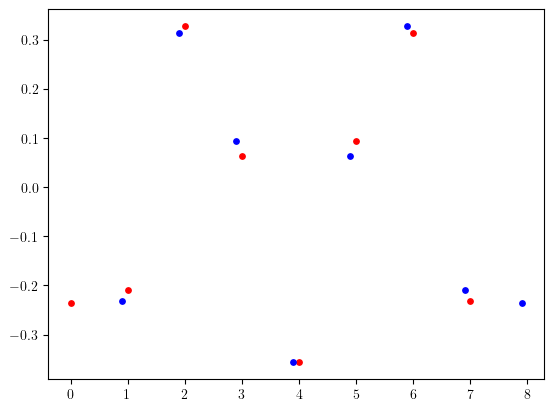

651.1009326560784 0.7448979591836735


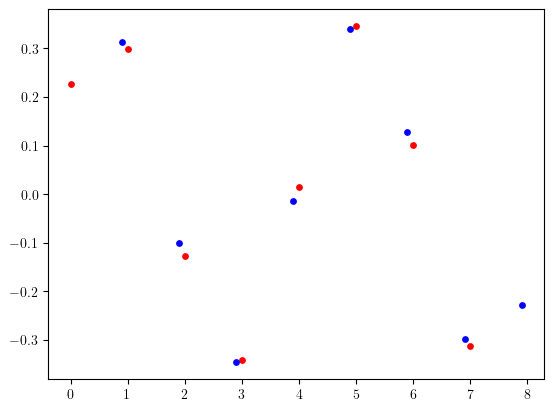

608.8116337401175 0.7448979591836735


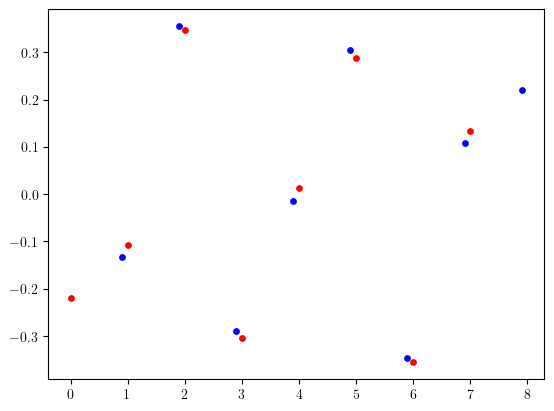

669.5779286980611 0.7448979591836735


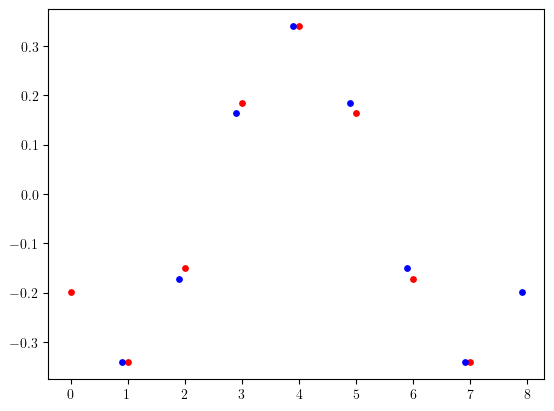

591.9089268280961 0.7448979591836735


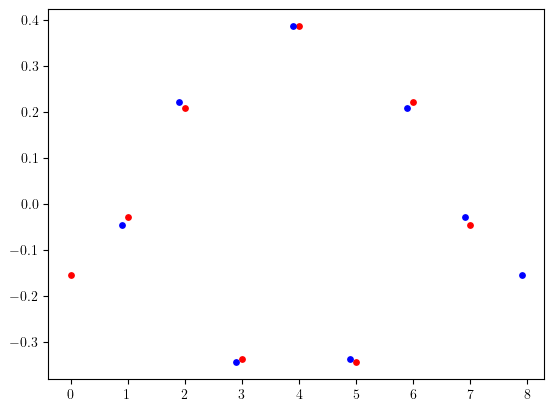

683.430572033767 0.7448979591836735


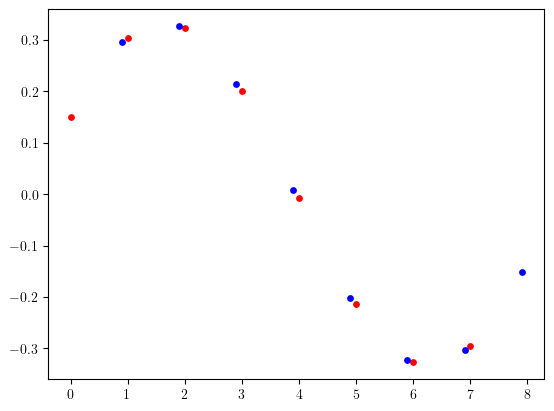

691.8048629929173 0.7448979591836735


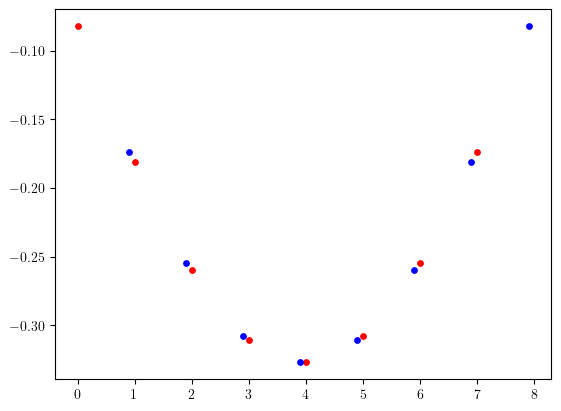

-642.0962554310473 0.7448979591836735


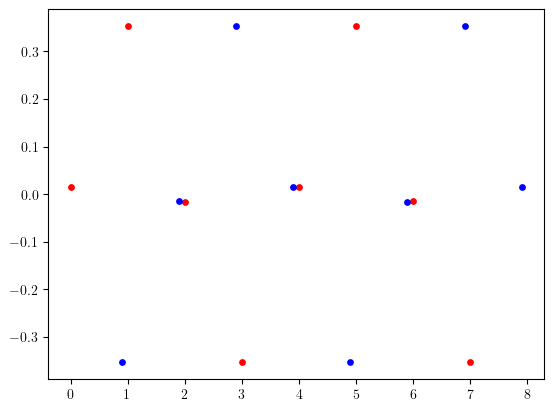

-620.8244712886163 0.7448979591836735


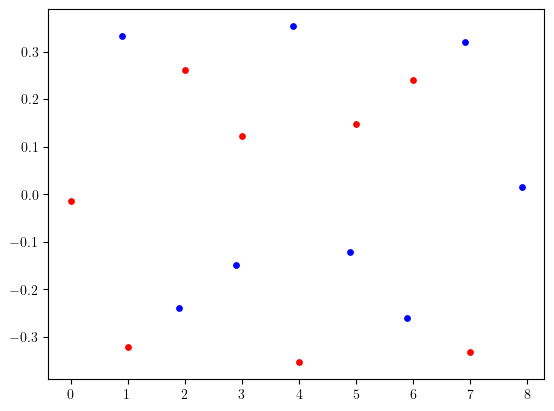

-662.6769153494619 0.7448979591836735


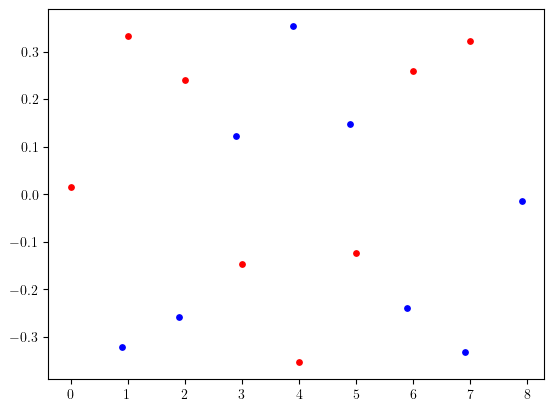

-602.1946757474977 0.7448979591836735


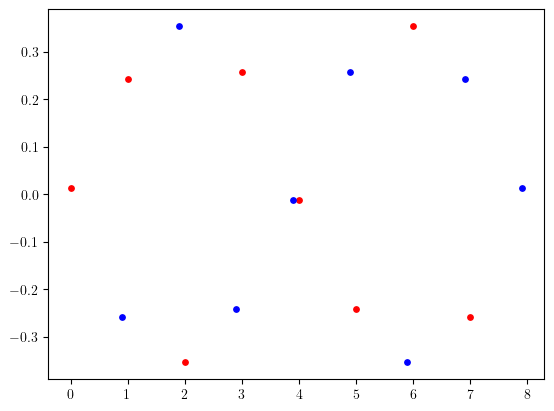

-679.6303673126255 0.7448979591836735


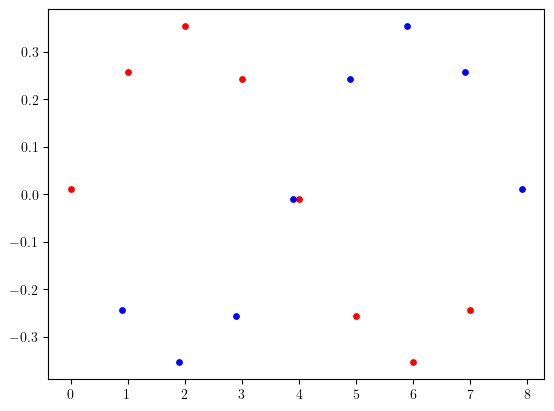

-589.4138788044115 0.7448979591836735


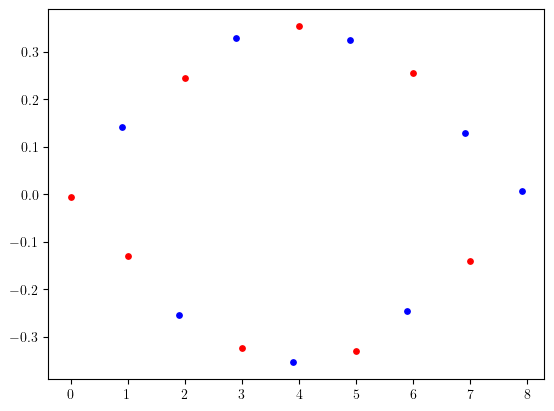

-690.7236083628657 0.7448979591836735


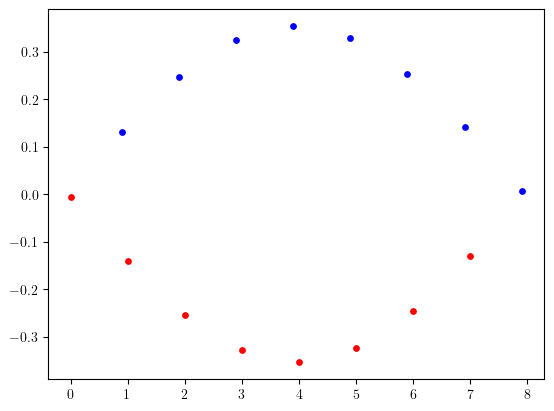

In [ ]:


latticeA = np.stack((np.arange(length//2+length%2),np.zeros(length//2+length%2))).T * a
latticeB = np.stack((np.arange(length//2)*a+b0,np.ones(length//2)*h)).T 
for i in range(length):
    fig, ax = plt.subplots(1,1)
    ind = 30
    print(eigenvalues[ind,i,0],rx[ind])
    ax.scatter(latticeA[:,0],eigenvalues[ind,i,1::2],color="red",s=15)
    ax.scatter(latticeB[:,0],eigenvalues[ind,i,2::2],color="blue",s=15)
    plt.show()

    

In [ ]:
ds = np.load("topological_phenomena_dipoles/dipoles_for_xy_decoupling.npy")

In [ ]:
N = 40
eps = 0.1
rx = np.linspace(0.2+eps,0.8-eps,N)
ry = np.linspace(0.15,0.4,N)
r = np.meshgrid(rx,ry)
d_numb = np.zeros((N,N))

v1 = np.ones((N,N,4,3))*np.nan
v2 = np.ones_like(v1)*np.nan
v3 = np.ones_like(v1)*np.nan
threshold = 10
for i in range(N):
    for j in range(N):
        x, y = r[0][i,j],r[1][i,j]
        
        r1 = np.array([1.0, 0.0])
        r2 = np.array([x, y])
        r3 = np.array([x - 1.0, y])
        
        for n in range(len(ds[i,j,:,0])):
            if not np.isnan(ds[i,j,n,0]):
                for k in range(3):
                    direc = (k//2,int(k>0))
                    v1[i,j,n,k] = dip_derivative_full(r1,*direc,ds[i,j,n][:2])
                for k in range(3):
                    direc = (k//2,int(k>0))
                    v2[i,j,n,k] = dip_derivative_full(r3,*direc,ds[i,j,n][:2])
                    v3[i,j,n,k] = dip_derivative_full(r2,*direc,ds[i,j,n][:2])
                    if np.abs(v2[i,j,n,k]/np.max(np.abs(v1[i,j,n,:])))<threshold or np.abs(v3[i,j,n,k]/np.max(np.abs(v1[i,j,n,:])))<threshold:
                        v2[i,j,n,k] = np.nan
                        v3[i,j,n,k] = np.nan
                d_numb[i,j] += 1


        

In [ ]:
for k in range(3):
                    direc = (k//2,int(k>0))
                    print(direc)

(0, 0)
(0, 1)
(1, 1)


In [ ]:
N = 40
eps = 0.1
rx = np.linspace(0.2+eps,0.8-eps,N)
ry = np.linspace(0.15,0.4,N)
r = np.meshgrid(rx,ry)
d_numb = np.zeros((N,N))
ds = np.ones((N,N,4,3))*np.nan
vxy1 = np.ones((N,N,4))*np.nan
vxy2 = np.ones_like(vxy1)*np.nan
for i in range(N):
    for j in range(N):
        x, y = r[0][i,j],r[1][i,j]
        
        r1 = np.array([1.0, 0.0])
        r2 = np.array([x, y])
        r3 = np.array([x - 1.0, y])
        dcand = find_dipole_orientations(r2,r3)
        d_numb[i,j] = len(dcand)
        for n in range(len(dcand)):
            vxy1[i,j,n] = dip_derivative_full(r2,0,1,dcand[n][:2])
            vxy2[i,j,n] = dip_derivative_full(r3,0,1,dcand[n][:2])
            ds[i,j,n]= dcand[n]


        

NameError: name 'find_dipole_orientations' is not defined

In [ ]:
import matplotlib.colors as mcolors

# 1. TEMPLATE: Fill in your color names here. 
# You can use standard names ("rebeccapurple"), hex codes ("#FF5733"), or CSS colors.
colors = [
    "darkgrey",  # Maps to the lowest value (vmin)
    "rebeccapurple",          # Maps to the midpoint
    "forestgreen",
    "saddlebrown"     # Maps to the highest value (vmax)
]

# Create the colormap object (this object is inherently a callable function in Matplotlib)
custom_cmap = mcolors.LinearSegmentedColormap.from_list("my_cmap", colors)

# ==========================================
# USE CASE A: Pass directly to imshow
# ==========================================
# ax.imshow(ds[:,:,1,0], cmap=custom_cmap, vmin=-0.6, vmax=0.6)


# ==========================================
# USE CASE B: Use as a standalone function
# ==========================================
# Matplotlib colormaps expect a normalized number between 0.0 and 1.0. 
# To feed it your raw data values (e.g., -0.6 to 0.6), wrap it with a Normalizer.
norm = mcolors.Normalize(vmin=-0.6, vmax=0.6)

def get_color(value: float) -> tuple:
    """
    Takes a raw numerical value and returns an RGBA tuple 
    (e.g., (0.4, 0.2, 0.6, 1.0)) that Matplotlib understands.
    """
    normalized_val = norm(value)
    rgba_format = custom_cmap(normalized_val)
    return rgba_format

# Example:
# print(get_color(0.0))

In [ ]:
# np.save("topological_phenomena_dipoles/dipoles_for_xy_decoupling",ds)

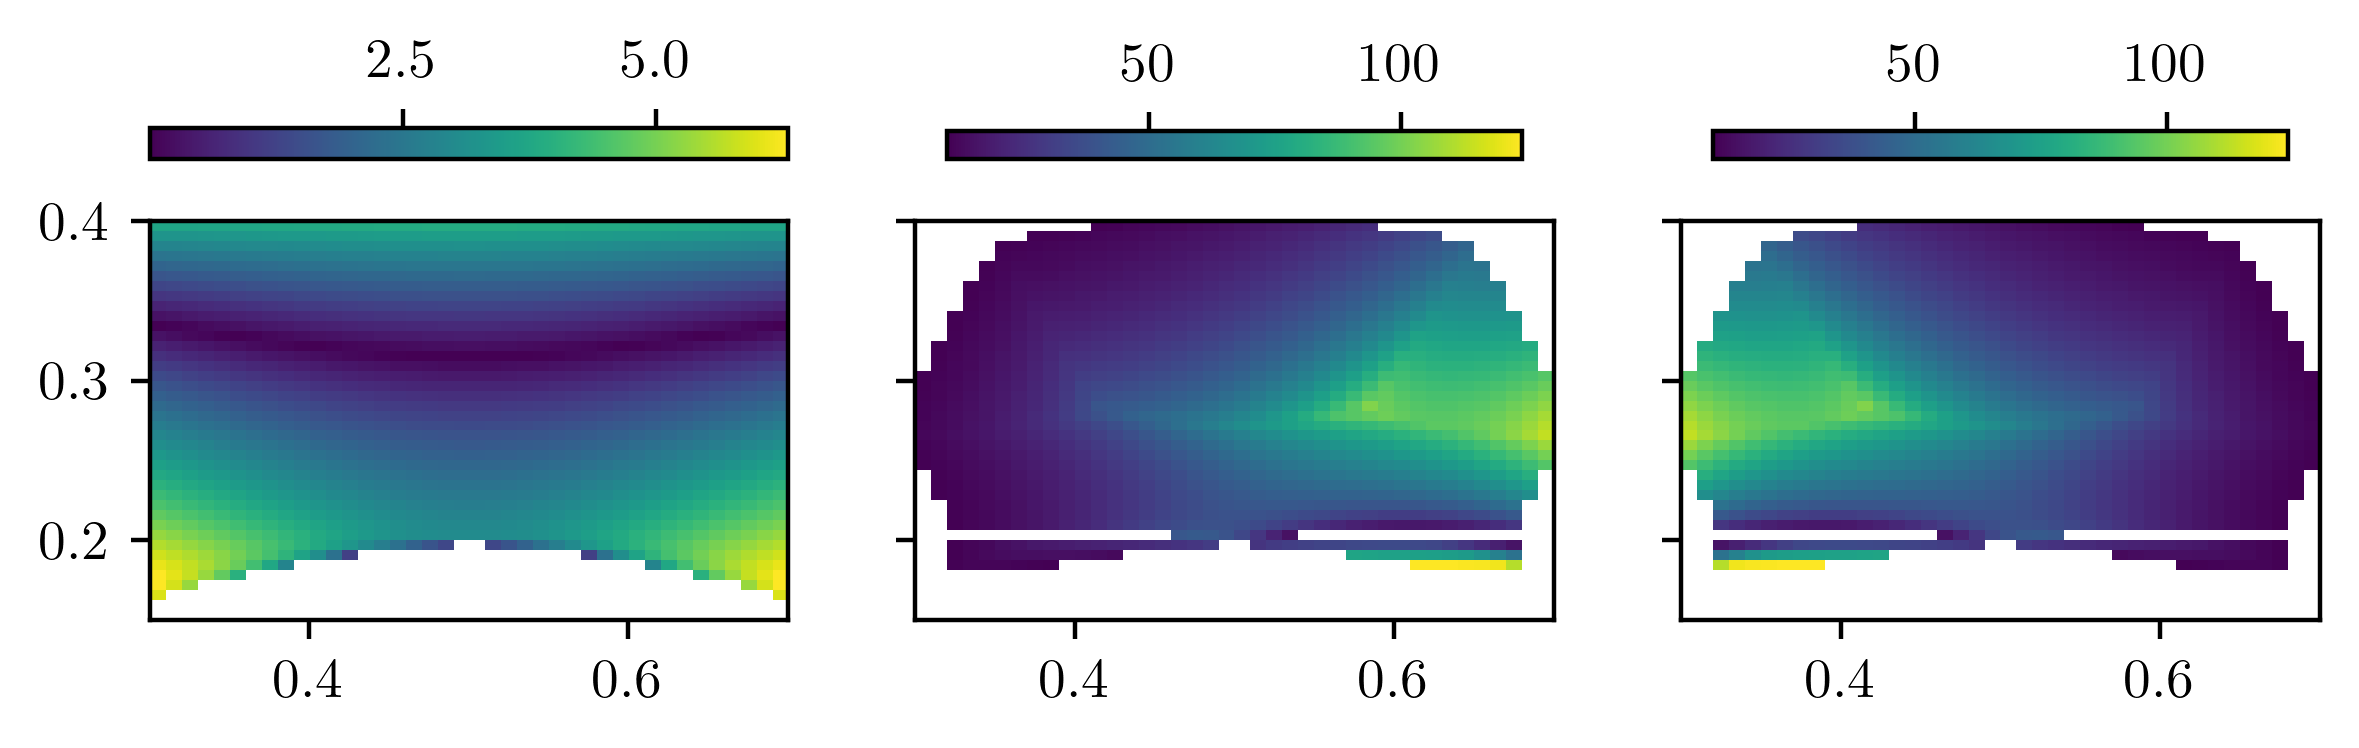

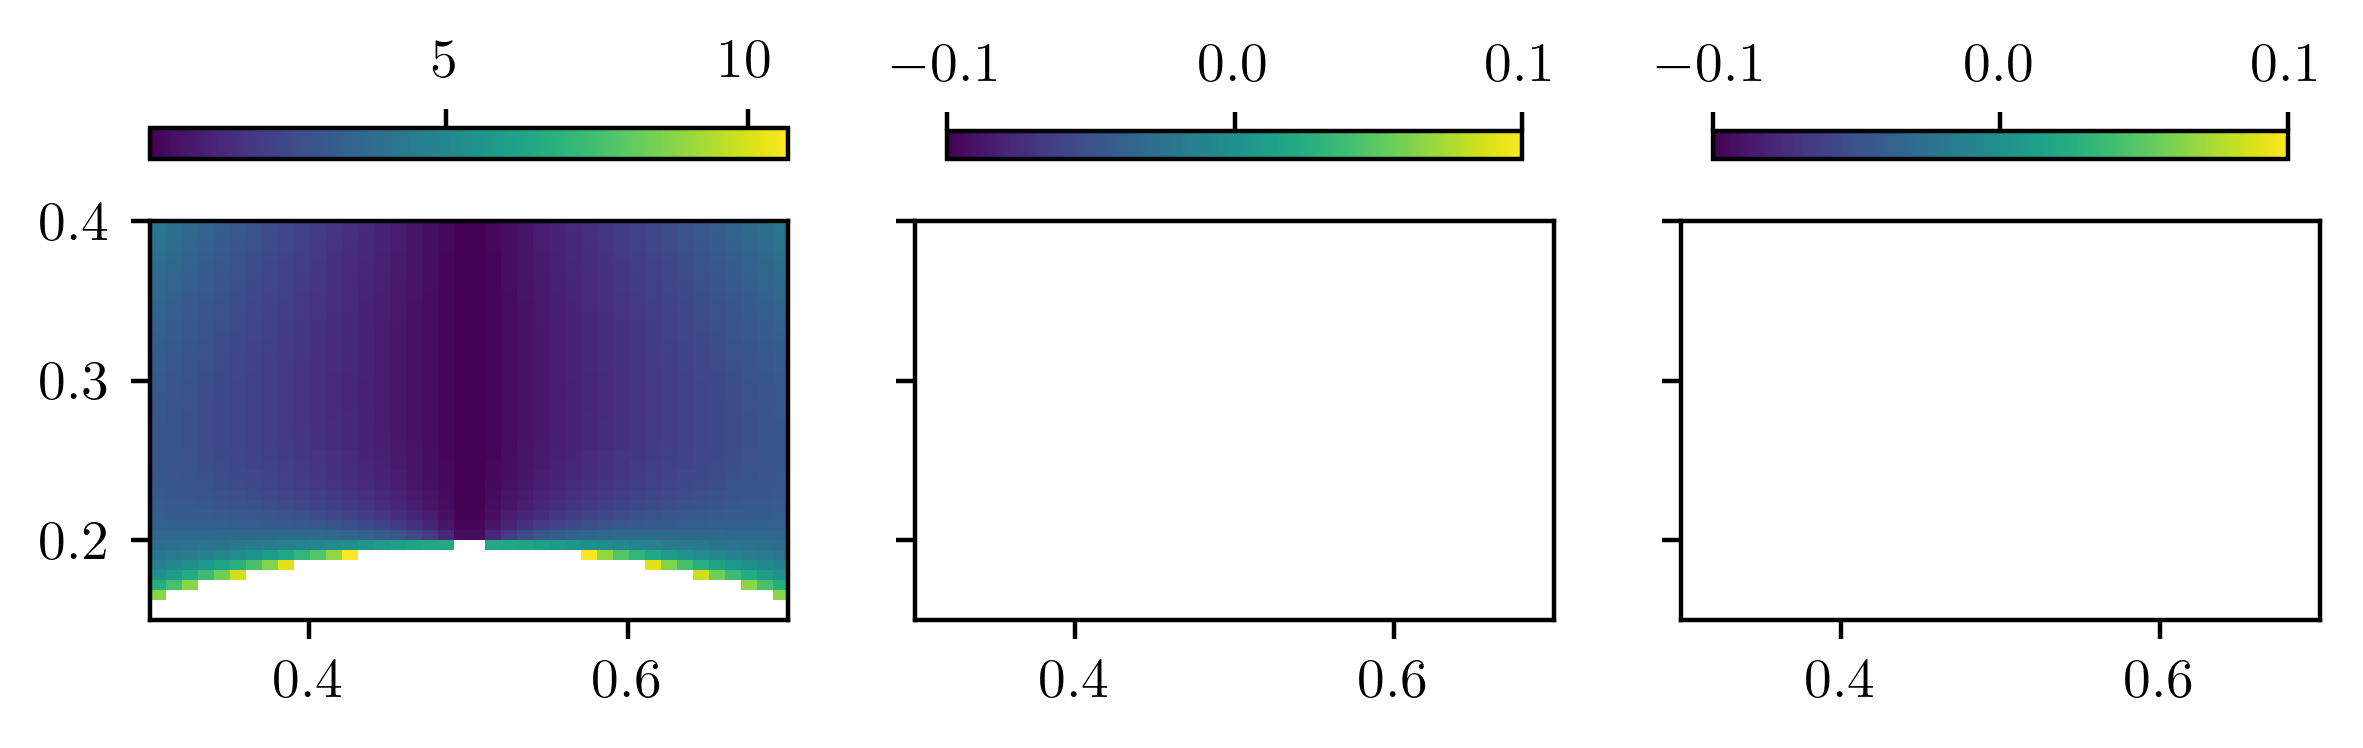

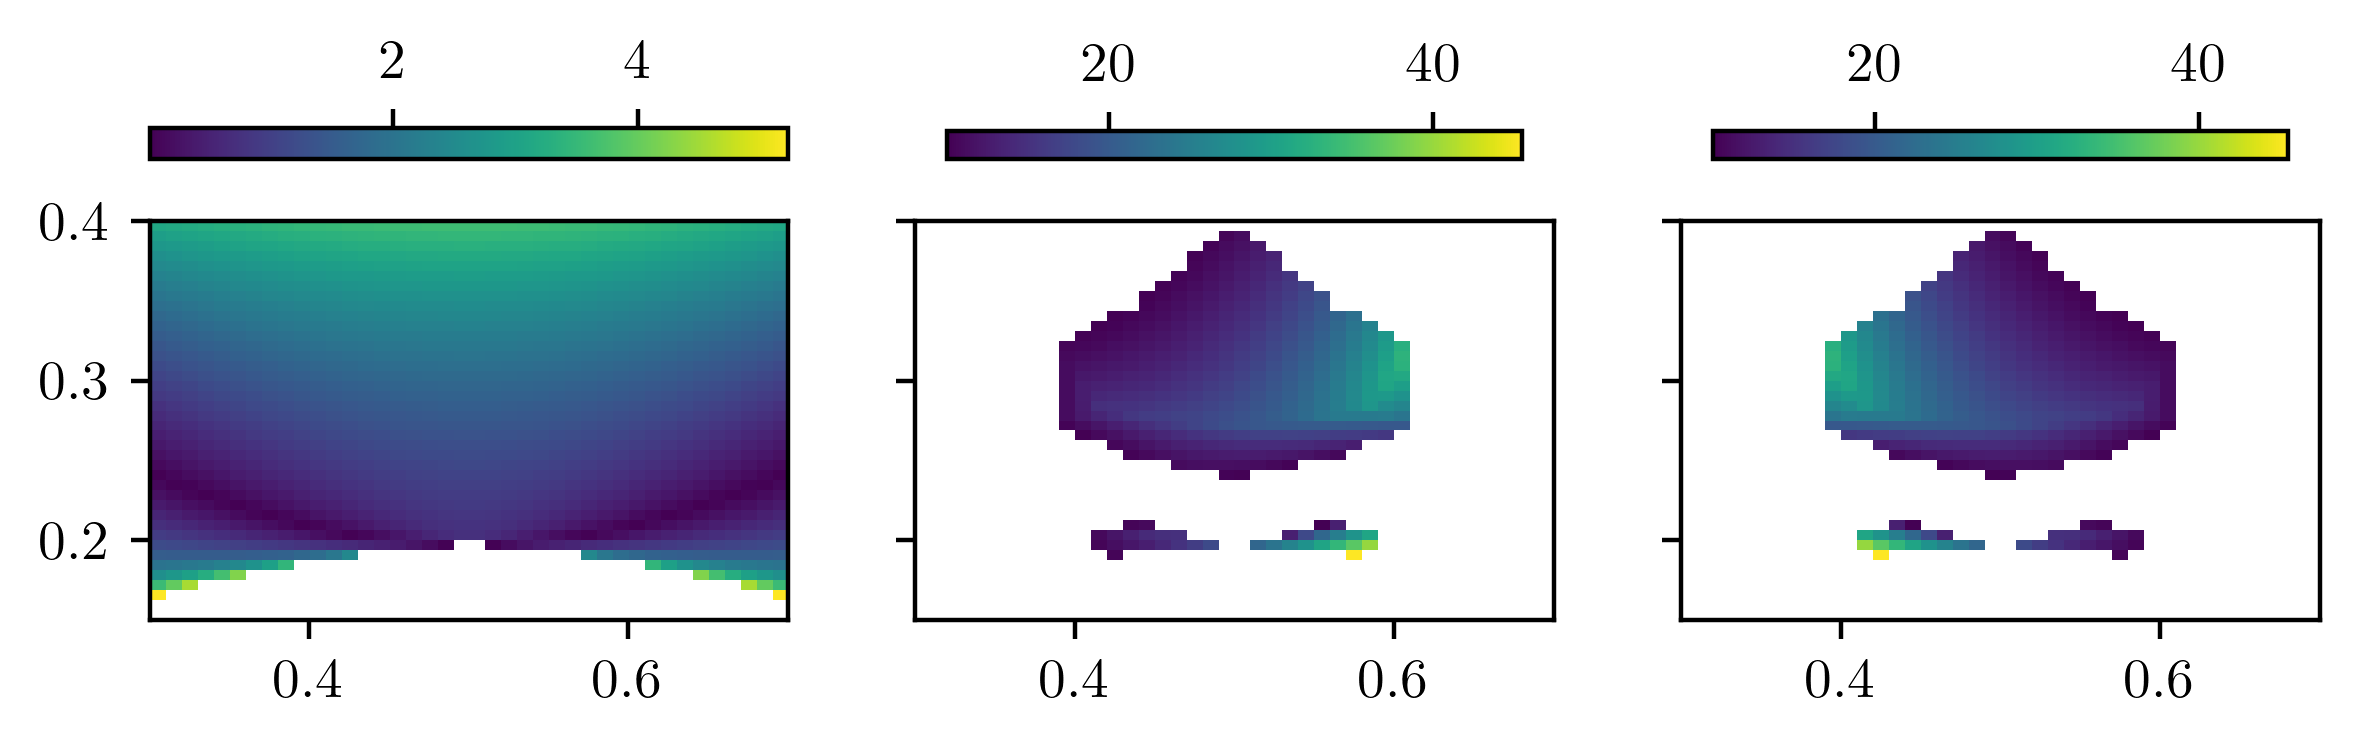

In [ ]:
tickp = TickProperties(0.15,0.05,0.1,0.05)
setup = Setup_Fig(xax_share=True,yax_share=True,tickp=tickp,fig_width=7,fig_height=4)
layer = 2
for k in range(3):
    fig, ax = setup.return_fig((1,3))
    
    shr = 0.9
    
    
    im0 = ax[0].imshow(np.abs(v1[:,:,layer,k]),extent=(0.3,0.7,0.15,0.4),origin='lower')
    # ax[0,0] = setup.format_ax(ax[0,0],(2,2),tickprop=tickp,j=0,bottom=0)
    cbar0 = fig.colorbar(im0,ax= ax[0],location="top")
    data = np.abs(v2[:,:,layer,k])/np.max(np.abs(v1[:,:,layer,:]),axis=2)
    def condition(data):
        return False #(data< 20) | (data> 100)
    im1 = ax[1].imshow(np.where(condition(data),np.nan,data),extent=(0.3,0.7,0.15,0.4),origin='lower')
    # ax[1] = setup.format_ax(ax[1],(1,3),tickprop=tickp,j=1,bottom=True)
    cbar1 = fig.colorbar(im1,ax= ax[1],location="top",shrink=shr)
    data2 = np.abs(v3[:,:,layer,k])/np.max(np.abs(v1[:,:,layer,:]),axis=2)
    im2 = ax[2].imshow(np.where(condition(data2),np.nan,data2),extent=(0.3,0.7,0.15,0.4),origin='lower')
    # ax[2] = setup.format_ax(ax[2],(1,3),tickprop=tickp,j=2,bottom=True)/v1[:,:,layer,k]
    cbar2 = fig.colorbar(im2,ax= ax[2],location="top",shrink=shr)
    # ax[1,0].set_xticks([0.4,0.5,0.6])
    # ax[0,0].text(s=r"$h/a$",x=-0.17,y=0.47,transform= ax[0,0].transAxes)
    # ax[1,0].text(s=r"$h/a$",x=-0.17,y=0.47,transform= ax[1,0].transAxes)
    # ax[0,0].text(s=r"$d_x$",x=-0.01,y=1.275,transform= ax[0,0].transAxes)
    # ax[1,0].set_xlabel(r"$b/a$")
    # ax[1,1].set_xlabel(r"$b/a$")
    # plt.subplots_adjust(wspace=0.005,hspace=0.01)
# plt.savefig("/home//christian/Documents/master/protocol/pictures/"+"topological_phases_decoupled_2D.pdf",bbox_inches='tight')

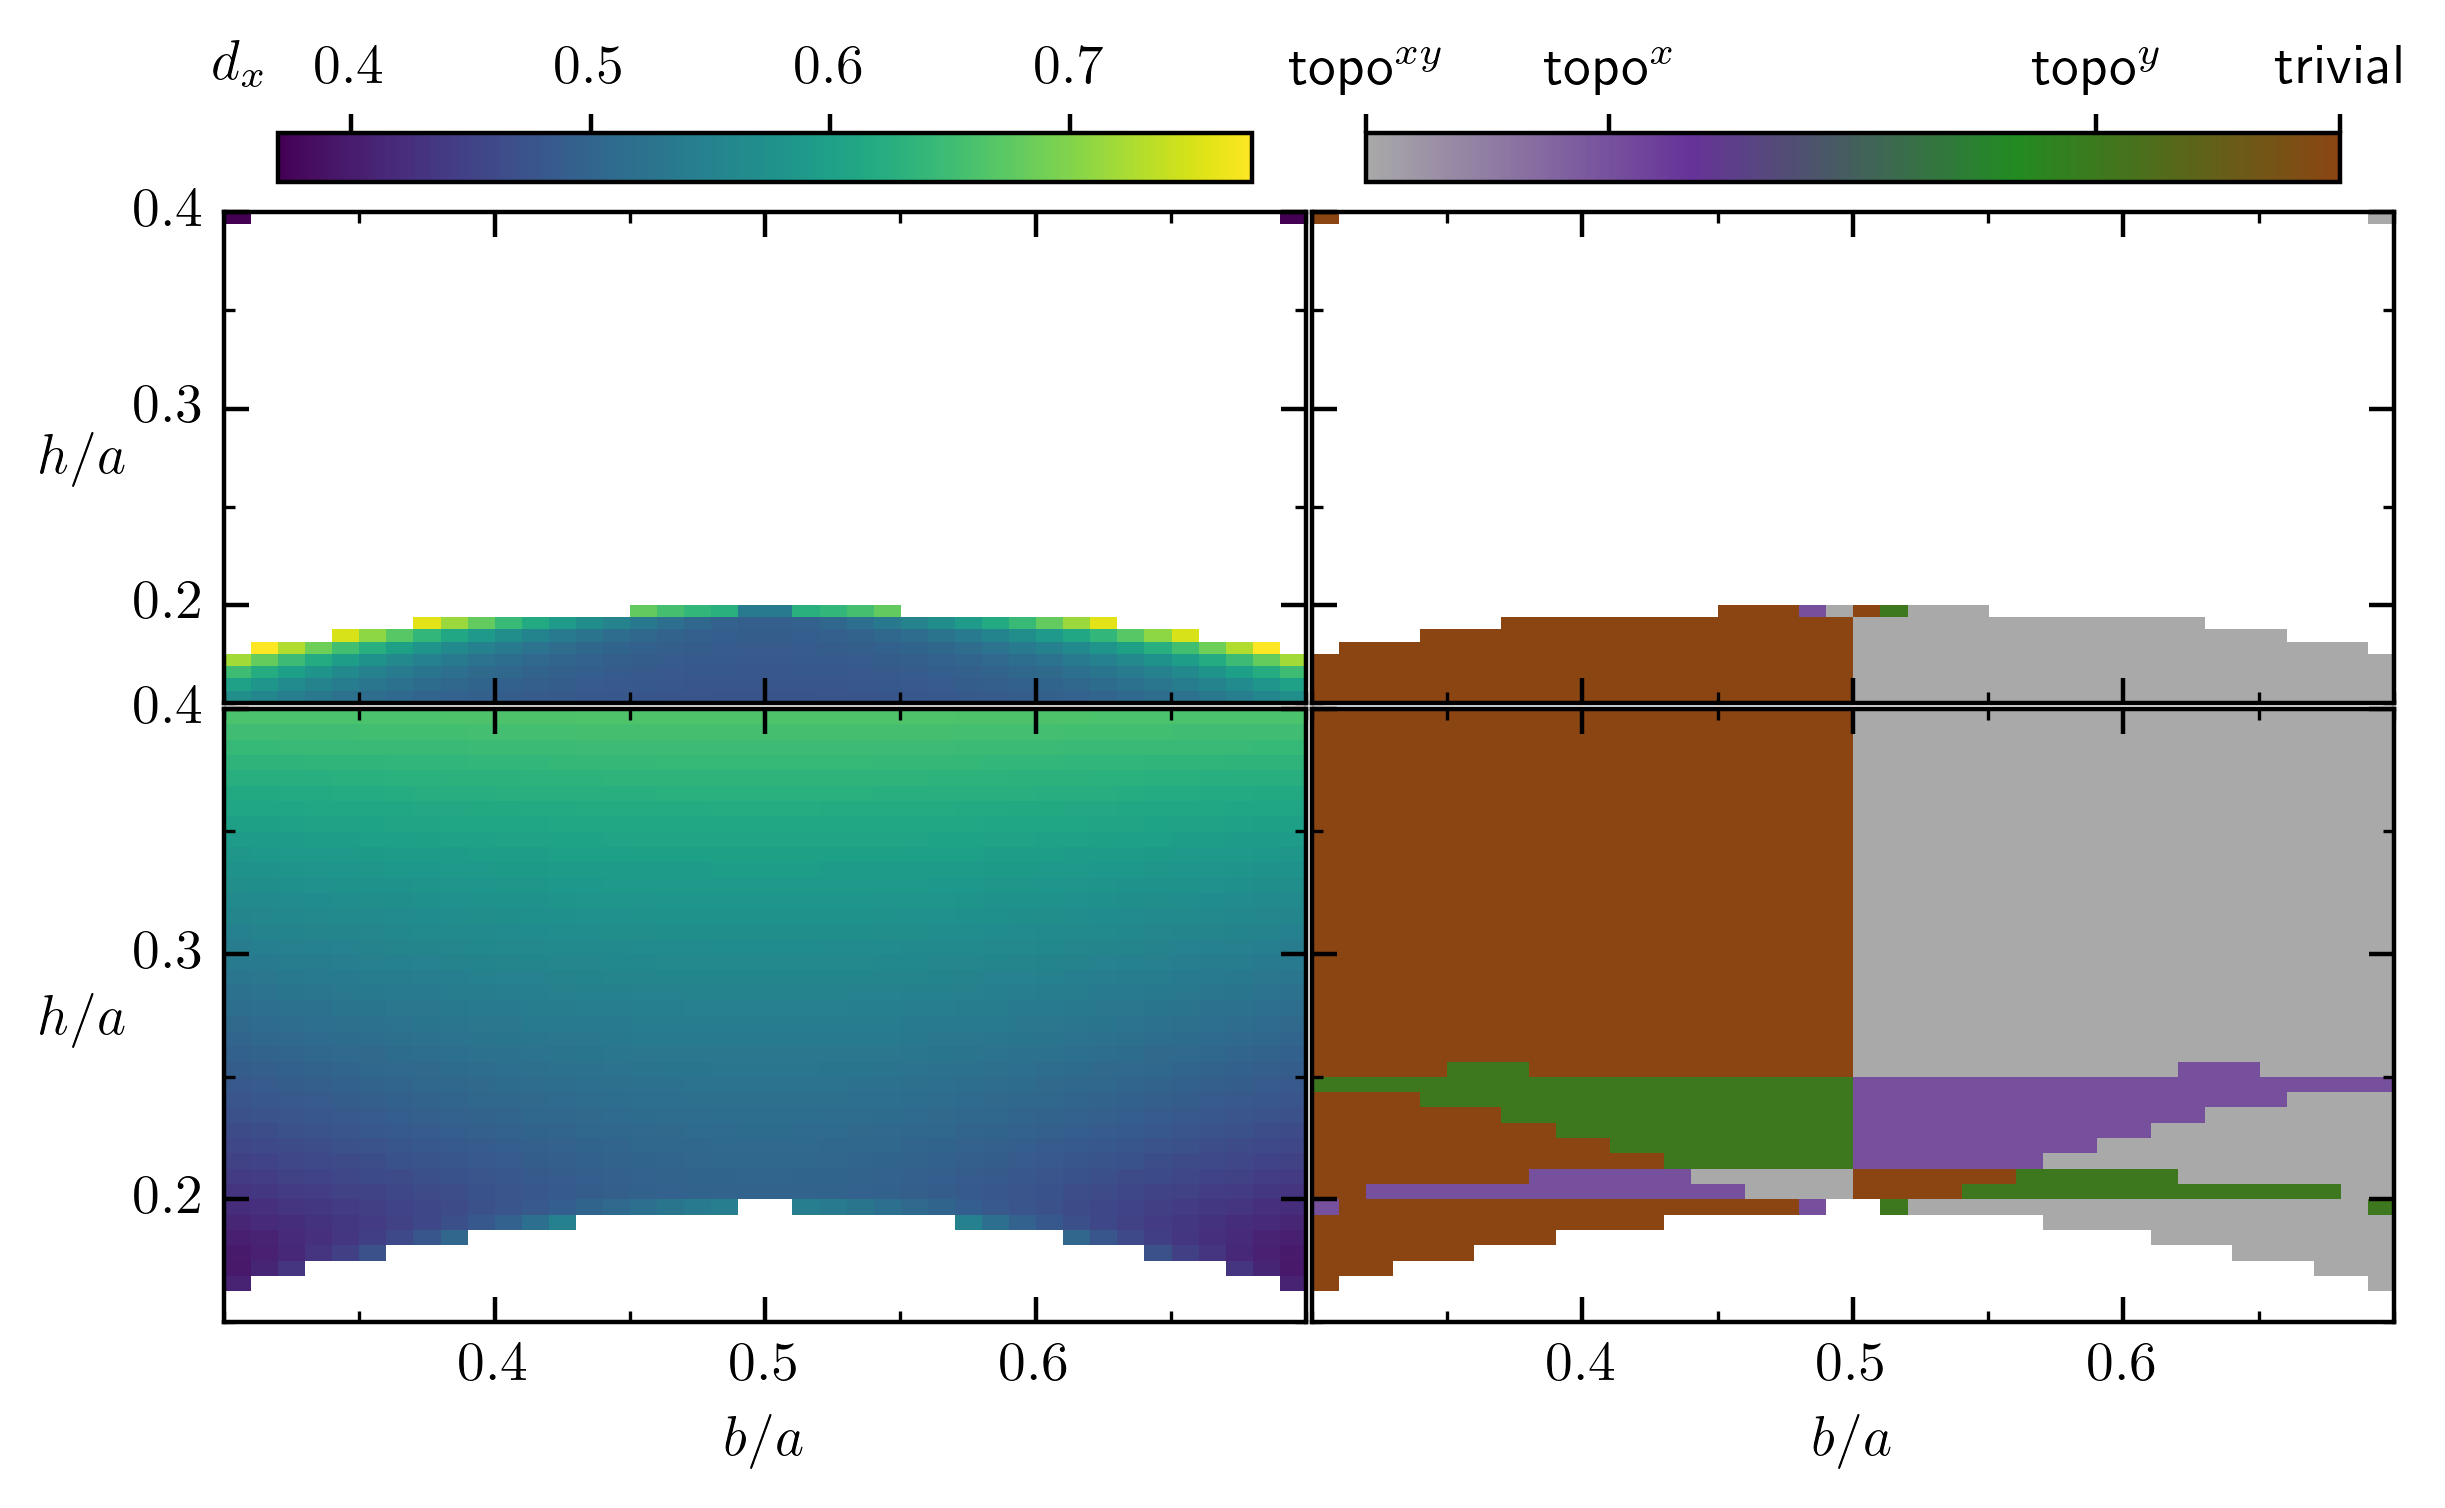

In [ ]:
tickp = TickProperties(0.15,0.05,0.1,0.05)
setup = Setup_Fig(xax_share=True,yax_share=True,tickp=tickp,fig_width=7,fig_height=4)
fig, ax = setup.return_fig((2,2))
import matplotlib.colorizer as mcolorizer
import matplotlib.colors as mcolors
vmin=np.nanmin(ds[:,:,0:3:2,0])
vmax=np.nanmax(ds[:,:,0:3:2,0])
shr = 0.9
def fromater(x,pos):
    if x == -2:
        return r"$\text{topo}^{xy}$"
    if x == -1:
        return r"$\text{topo}^x$"
    if x == 1:
        return r"$\text{topo}^{y}$"
    if x == 2:
        return r"trivial"
    else: 
        return 0
# colorizerl = mcolorizer.Colorizer(norm=norml)
im0 = ax[0,0].imshow(ds[:,:,0,0],extent=(0.3,0.7,0.15,0.4),origin='lower',vmin=vmin,vmax=vmax)
ax[0,0] = setup.format_ax(ax[0,0],(2,2),tickprop=tickp,j=0,bottom=0)
# cbar0 = fig.colorbar(im0,ax= ax[0,0],location="top")
im2 = ax[1,0].imshow(ds[:,:,2,0],extent=(0.3,0.7,0.15,0.4),origin='lower',vmin=vmin,vmax=vmax)
ax[1,0] = setup.format_ax(ax[1,0],(2,2),tickprop=tickp,j=0,bottom=True)
cbar2 = fig.colorbar(im0,ax= ax[0,0],location="top",shrink=shr)
im1 = ax[0,1].imshow(ratio[:,:,0],extent=(0.3,0.7,0.15,0.4),origin='lower',cmap=custom_cmap,vmin=-2,vmax=2)
ax[0,1] = setup.format_ax(ax[0,1],(2,2),tickprop=tickp,j=1,bottom=0)
# cbar0 = fig.colorbar(im0,ax= ax[0,0],location="top")
im3 = ax[1,1].imshow(ratio[:,:,2],extent=(0.3,0.7,0.15,0.4),origin='lower',cmap=custom_cmap,vmin=-2,vmax=2)
ax[1,1] = setup.format_ax(ax[1,1],(2,2),tickprop=tickp,j=1,bottom=True)
cbar2 = fig.colorbar(im1,ax= ax[0,1],location="top",ticks=[-2,-1,1,2],format=fromater,shrink=shr)
ax[1,0].set_xticks([0.4,0.5,0.6])
ax[0,0].text(s=r"$h/a$",x=-0.17,y=0.47,transform= ax[0,0].transAxes)
ax[1,0].text(s=r"$h/a$",x=-0.17,y=0.47,transform= ax[1,0].transAxes)
ax[0,0].text(s=r"$d_x$",x=-0.01,y=1.275,transform= ax[0,0].transAxes)
ax[1,0].set_xlabel(r"$b/a$")
ax[1,1].set_xlabel(r"$b/a$")
plt.subplots_adjust(wspace=0.005,hspace=0.01)
# plt.savefig("/home//christian/Documents/master/protocol/pictures/"+"topological_phases_decoupled_2D.pdf",bbox_inches='tight')

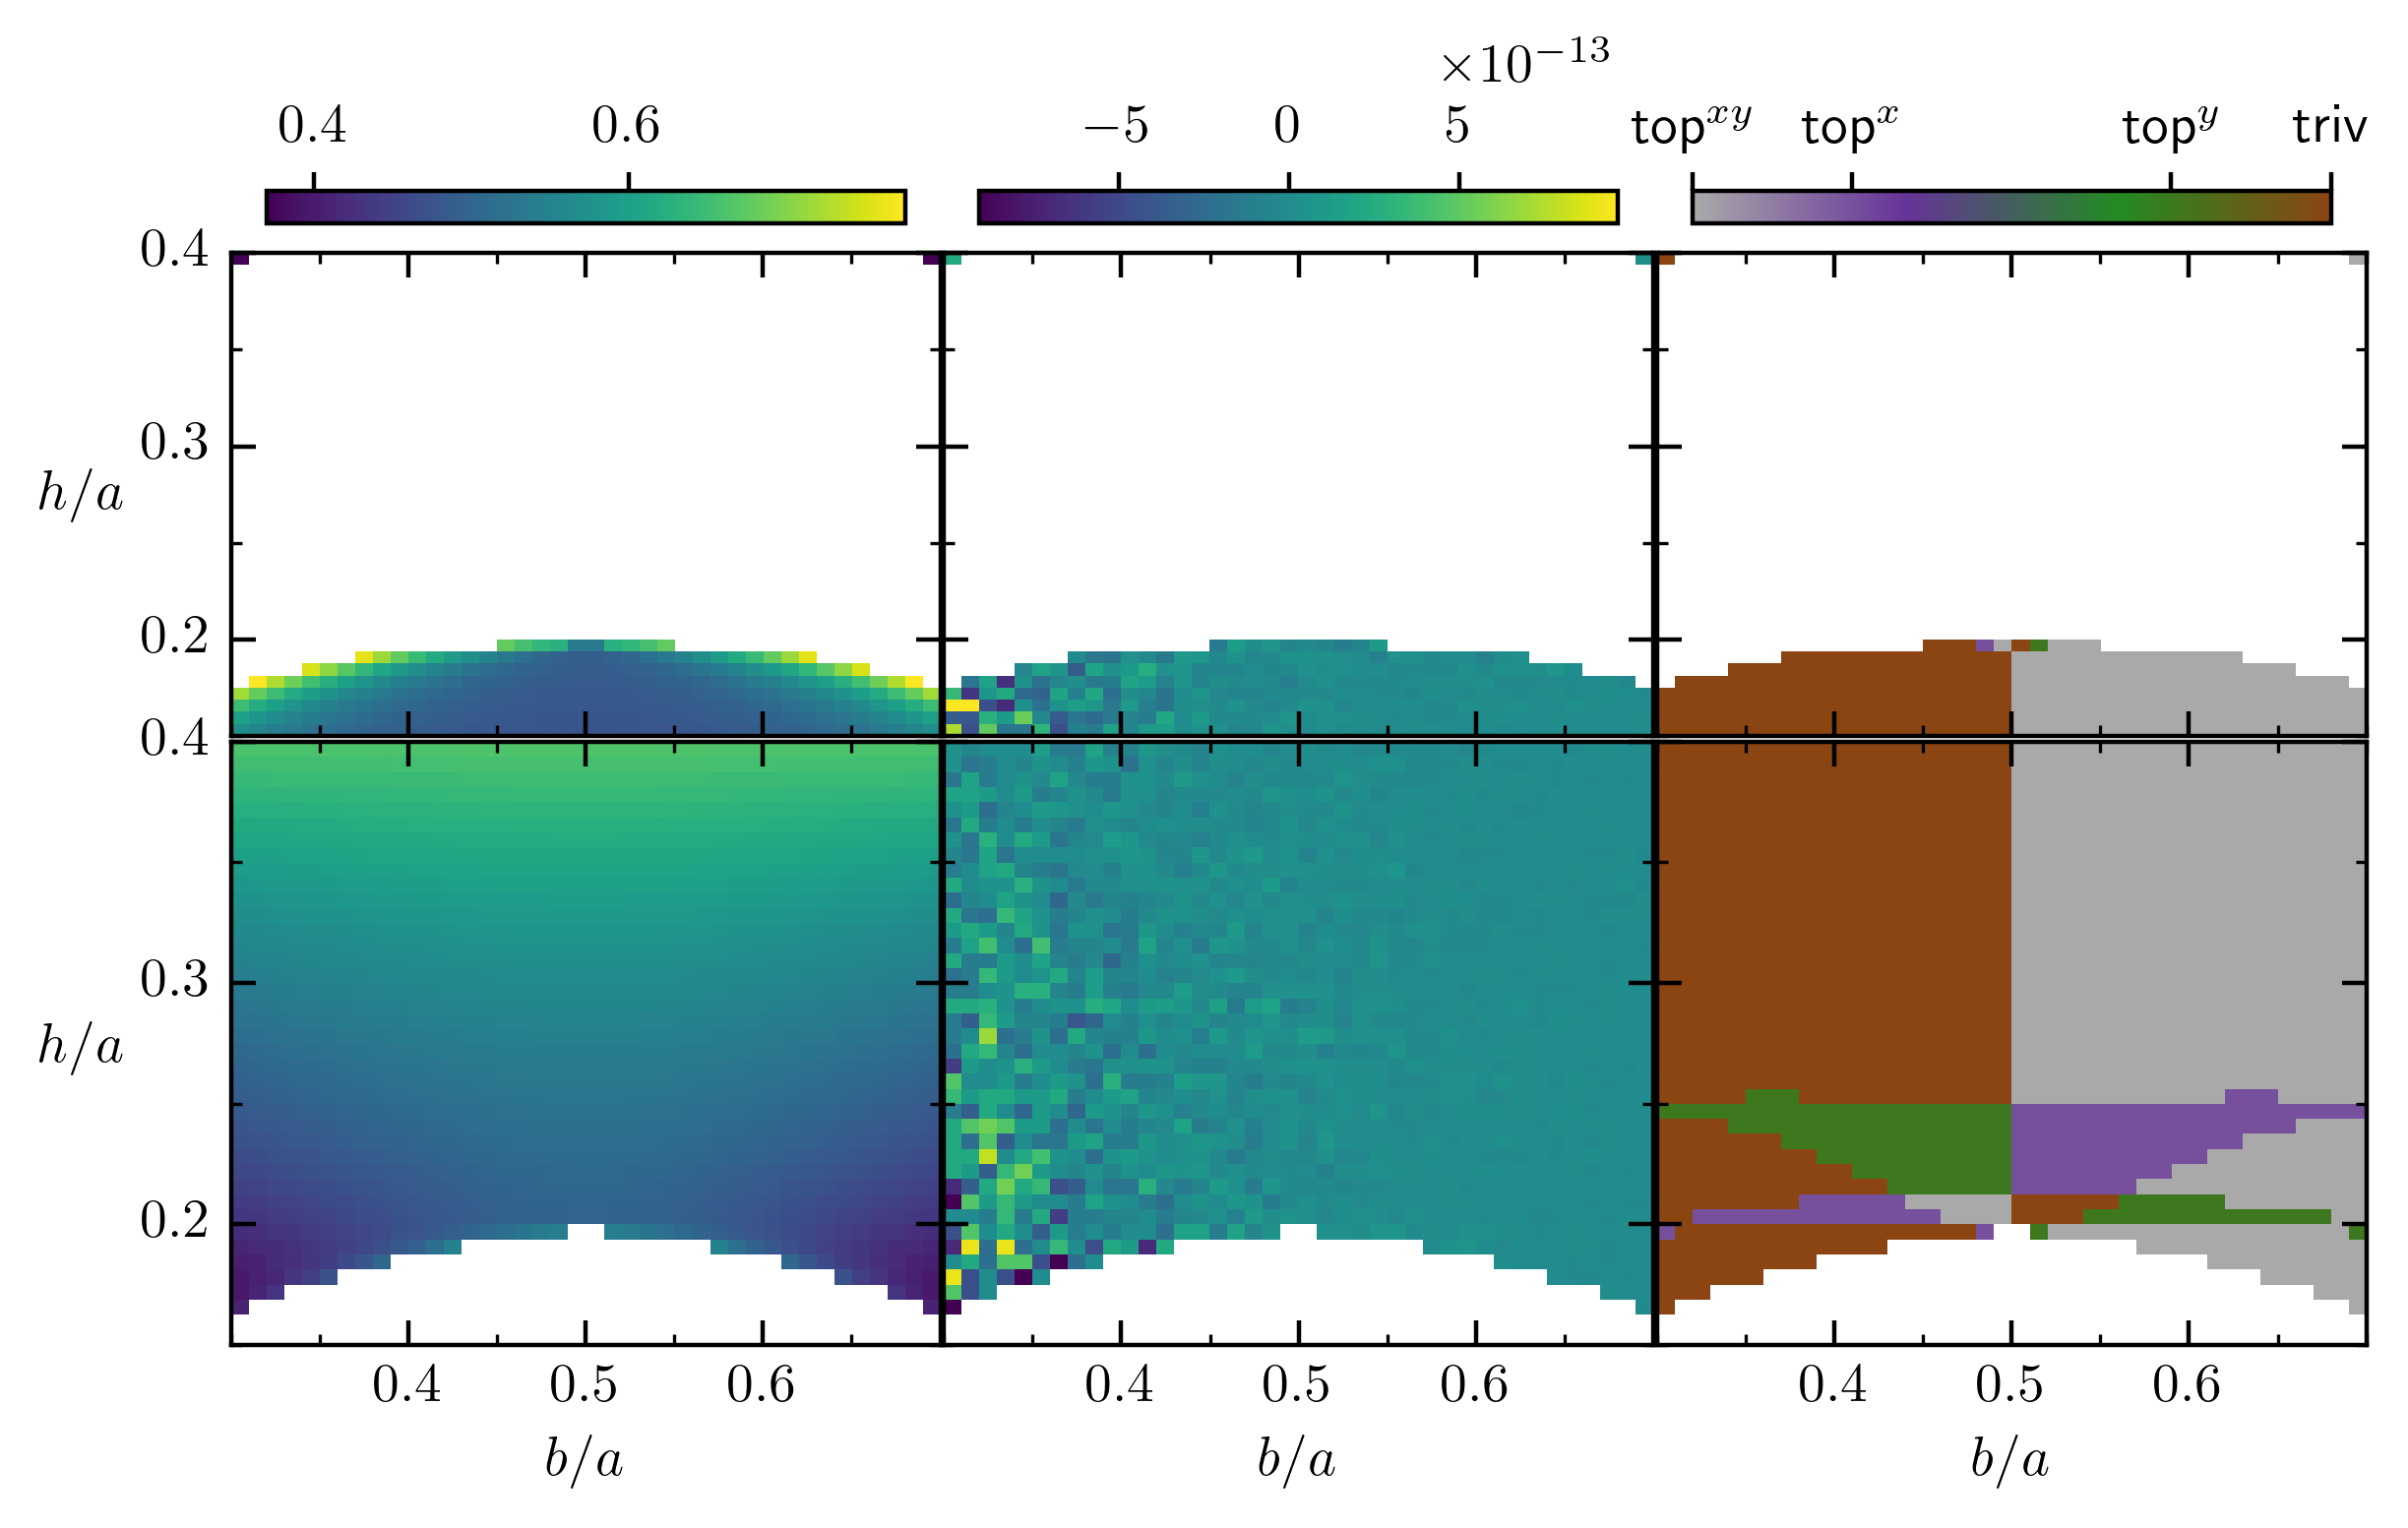

In [ ]:
tickp = TickProperties(0.15,0.05,0.1,0.05)
setup = Setup_Fig(xax_share=True,yax_share=True,tickp=tickp,fig_width=7,fig_height=4)
fig, ax = setup.return_fig((2,3))
import matplotlib.colorizer as mcolorizer
import matplotlib.colors as mcolors
vmin=np.nanmin(ds[:,:,0:3:2,0])
vmax=np.nanmax(ds[:,:,0:3:2,0])
vxy = vxy1.copy()
vmin1=np.nanmin(vxy[:,:,0:3:2])
vmax1=np.nanmax(vxy[:,:,0:3:2])
shr = 0.9
def fromater(x,pos):
    if x == -2:
        return r"$\text{top}^{xy}$"
    if x == -1:
        return r"$\text{top}^x$"
    if x == 1:
        return r"$\text{top}^{y}$"
    if x == 2:
        return r"triv"
    else: 
        return 0
# colorizerl = mcolorizer.Colorizer(norm=norml)
im0 = ax[0,0].imshow(ds[:,:,0,0],extent=(0.3,0.7,0.15,0.4),origin='lower',vmin=vmin,vmax=vmax)
ax[0,0] = setup.format_ax(ax[0,0],(2,2),tickprop=tickp,j=0,bottom=0)
# cbar0 = fig.colorbar(im0,ax= ax[0,0],location="top")
im2 = ax[1,0].imshow(ds[:,:,2,0],extent=(0.3,0.7,0.15,0.4),origin='lower',vmin=vmin,vmax=vmax)
ax[1,0] = setup.format_ax(ax[1,0],(2,2),tickprop=tickp,j=0,bottom=True)
cbar0 = fig.colorbar(im0,ax= ax[0,0],location="top",shrink=shr)
im1 = ax[0,2].imshow(ratio[:,:,0],extent=(0.3,0.7,0.15,0.4),origin='lower',cmap=custom_cmap,vmin=-2,vmax=2)
ax[0,2] = setup.format_ax(ax[0,2],(2,2),tickprop=tickp,j=1,bottom=0)
# cbar0 = fig.colorbar(im0,ax= ax[0,0],location="top")
im3 = ax[1,2].imshow(ratio[:,:,2],extent=(0.3,0.7,0.15,0.4),origin='lower',cmap=custom_cmap,vmin=-2,vmax=2)
ax[1,2] = setup.format_ax(ax[1,2],(2,2),tickprop=tickp,j=1,bottom=True)
cbar2 = fig.colorbar(im1,ax= ax[0,2],location="top",ticks=[-2,-1,1,2],format=fromater,shrink=shr)

im4 = ax[0,1].imshow(vxy[:,:,0],extent=(0.3,0.7,0.15,0.4),origin='lower',vmin=vmin1,vmax=vmax1)
ax[0,1] = setup.format_ax(ax[0,1],(2,2),tickprop=tickp,j=1,bottom=0)
# cbar0 = fig.colorbar(im0,ax= ax[0,0],location="top")
im5 = ax[1,1].imshow(vxy[:,:,2],extent=(0.3,0.7,0.15,0.4),origin='lower',vmin=vmin1,vmax=vmax1)
ax[1,1] = setup.format_ax(ax[1,1],(2,2),tickprop=tickp,j=1,bottom=True)
cbar5 = fig.colorbar(im4,ax= ax[0,1],location="top",shrink=shr)

ax[1,0].set_xticks([0.4,0.5,0.6])
ax[0,0].text(s=r"$h/a$",x=-0.27,y=0.47,transform= ax[0,0].transAxes)
ax[1,0].text(s=r"$h/a$",x=-0.27,y=0.47,transform= ax[1,0].transAxes)
ax[1,0].set_xlabel(r"$b/a$")
ax[1,1].set_xlabel(r"$b/a$")
ax[1,2].set_xlabel(r"$b/a$")
plt.subplots_adjust(wspace=0.005,hspace=0.01)
# plt.savefig("/home//christian/Documents/master/protocol/pictures/"+"topological_phases_decoupled_2D_2.pdf",bbox_inches='tight')

In [ ]:
# ds = align_grid_vectors_anisotropic(dsorg,alpha_first_axis=2)
# dsorg = ds.copy()
# ds = np.swapaxes(align_grid_vectors_4shells_sym_axis0(np.swapaxes(dsorg,0,1),sym_weight=20,nan_penalty=20),0,1)
ds = np.swapaxes(align_grid_vectors_4shells_antisym_axis0(np.swapaxes(dsorg,0,1),axis0_scale=1),0,1)

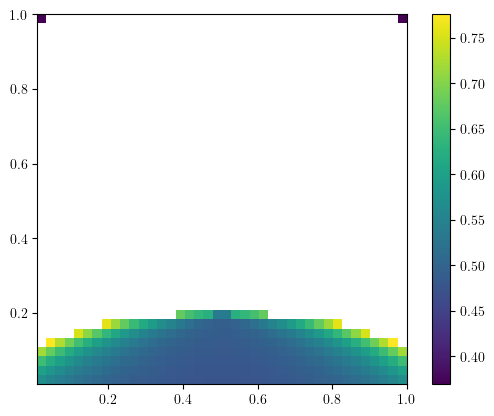

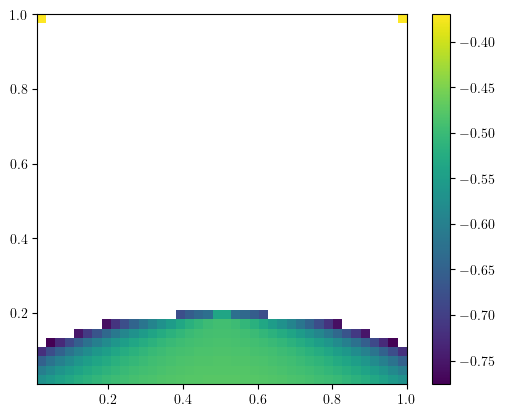

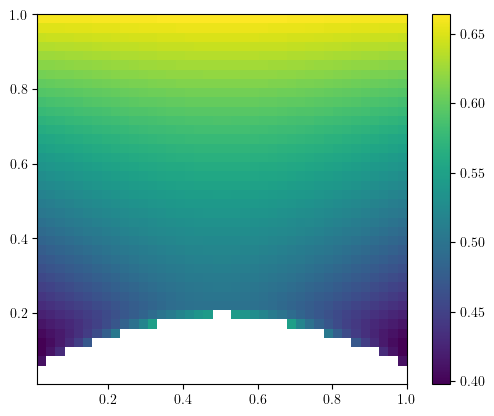

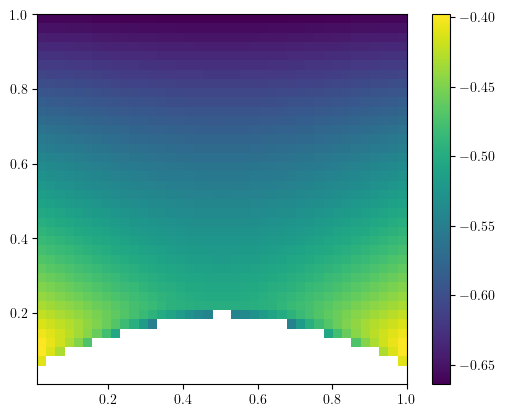

In [ ]:
for n in range(4):
    fig, ax = plt.subplots(1,1)
    im = ax.imshow(ds[:,:,n,0], extent=[0.01, 1, 0.01, 1], origin="lower")
    # im = ax.imshow(vxy2[:,:,n], extent=[0.01, 1, 0.01, 1], origin="lower")
    # im = ax.imshow(r[0], extent=[0.01, 1, 0.01, 1], origin="lower")
    cmap = fig.colorbar(im,ax=ax)
    

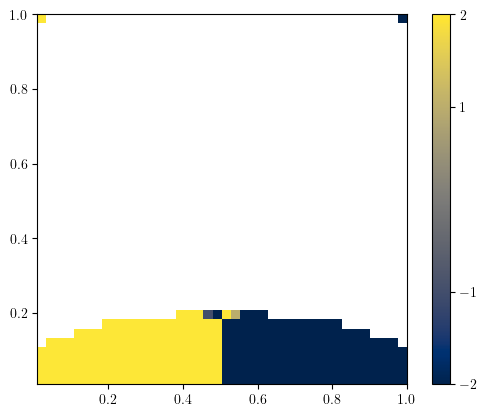

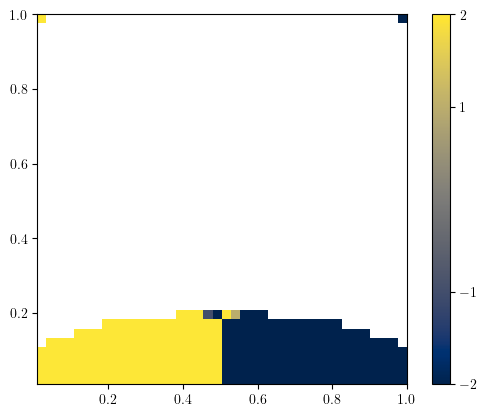

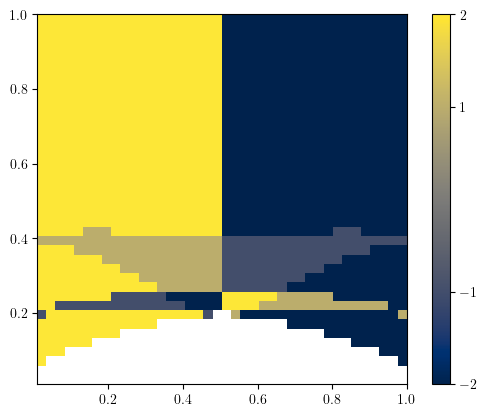

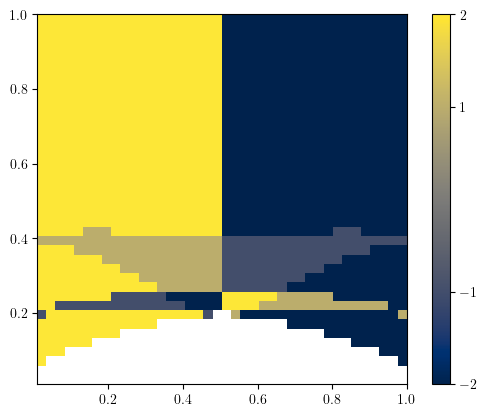

In [ ]:
ratio = np.ones((N,N,4))*np.nan
for n in range(4):    
    # rp = np.where(np.isnan(ds[:,:,n,0]),np.nan,r)
    # ratio = np.ones_like(r[0])*np.nan
    for i in range(N):
        for j in range(N):
            
            if False and j<N//2:
                d = np.ones(3)*np.nan
                # d = ds[i,N-1-j,n,:2].copy()
                # d[0] *= (-1)
            else:
                d = ds[i,j,n,:2]
            if np.isnan(d[0]):
                continue
               
            x, y = r[0][i,j],r[1][i,j]
            r2 = np.array([x, y])
            r3 = np.array([x - 1.0, y])
            xx = np.abs(dip_derivative_full(r2,0,0,d))-np.abs(dip_derivative_full(r3,0,0,d))
            yy = np.abs(dip_derivative_full(r2,1,1,d))-np.abs(dip_derivative_full(r3,1,1,d))
            ratio[i,j,n]= (1.5+np.sign(xx*yy)/2)*np.sign(xx)

    fig, ax = plt.subplots(1,1)
    im = ax.imshow(ratio[:,:,n], extent=[0.01, 1, 0.01, 1], origin="lower",cmap="cividis")
    cmap = fig.colorbar(im,ax=ax,ticks=[-2,-1,1,2])

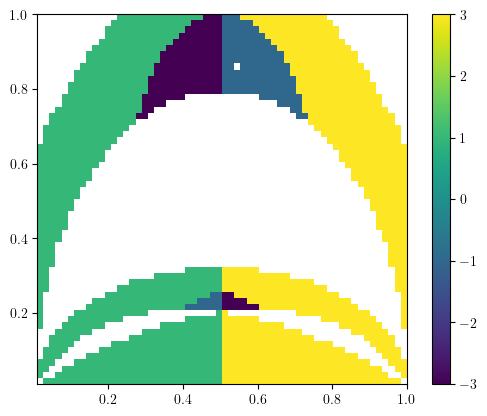

In [ ]:
rp = np.where(np.isnan(ds[:,:,0]),np.nan,r)
ratio = np.ones_like(r[0])*np.nan
for i in range(N):
    for j in range(N):
        if not np.isnan(ds[i,j,0]):
            x, y = r[0][i,j],r[1][i,j]
            r2 = np.array([x, y])
            r3 = np.array([x - 1.0, y])
            xx = np.abs(dip_derivative_full(r2,0,0,ds[i,j,:2]))-np.abs(dip_derivative_full(r3,0,0,ds[i,j,:2]))
            yy = np.abs(dip_derivative_full(r2,1,1,ds[i,j,:2]))-np.abs(dip_derivative_full(r3,1,1,ds[i,j,:2]))
            ratio[i,j]= np.sign(xx*yy)*(2-np.sign(xx))

fig, ax = plt.subplots(1,1)
im = ax.imshow(ratio, extent=[0.01, 1, 0.01, 1], origin="lower")
cmap = fig.colorbar(im,ax=ax)

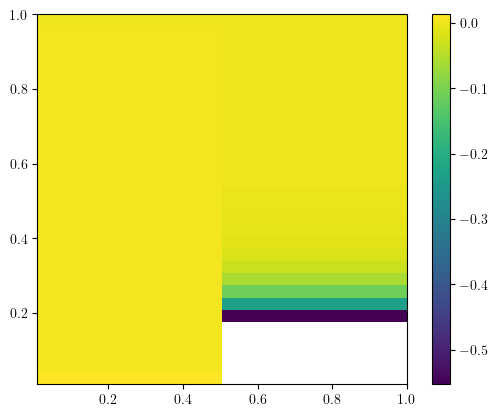

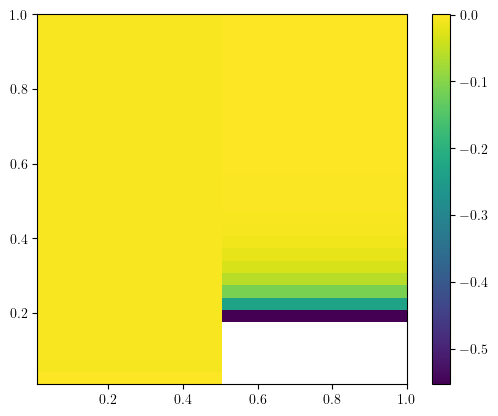

In [ ]:
# r2 = np.stack((r[0],r[1]))
# r3 = np.stack((r[0]-1,r[1]))
r2 = np.zeros((N,N,2))
r3 = np.zeros_like(r2)
r2[:,:,0] = r[0]
r2[:,:,1] = r[1]
r3[:,:,0] = r[0]-1
r3[:,:,1] = r[1]
# d = np.array([0,0,1])
xy2 = dip_derivative_ffull_vec(r2,0,1,ds[:,:,0,:2])
xy3 = dip_derivative_ffull_vec(r3,0,1,ds[:,:,0,:2])
fig, ax = plt.subplots(1,1)
im = ax.imshow(np.where(np.abs(xy2)<1,xy2,np.nan), extent=[0.01, 1, 0.01, 1], origin="lower")
cmap = fig.colorbar(im,ax=ax)
fig, ax = plt.subplots(1,1)
im = ax.imshow(np.where(np.abs(xy3)<1,xy3,np.nan), extent=[0.01, 1, 0.01, 1], origin="lower")
cmap = fig.colorbar(im,ax=ax)

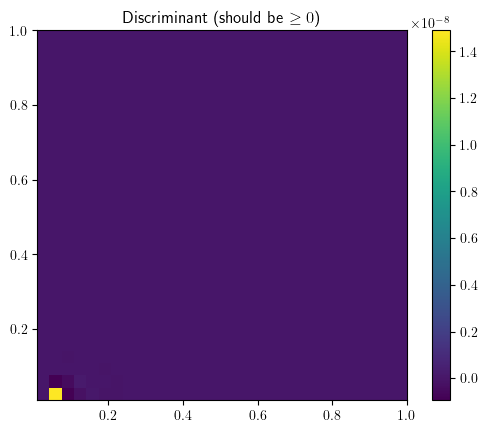

In [ ]:

# def disc(rx, ry):
#     r = np.sqrt(rx**2 + ry**2)
#     # Avoid division by zero at r = 0
#     with np.errstate(divide="ignore", invalid="ignore"):
#         rx_hat = np.where(r == 0, 0, rx / r)
#         ry_hat = np.where(r == 0, 0, ry / r)
#         d_y_sq_max = (1 + rx_hat**2 + rx_hat**2 / r**5 + r**5) / (
#             5 * ry_hat**2
#         )
#     return d_y_sq_max


# def discrim(dy, rx, ry):
#     r = np.sqrt(rx**2 + ry**2)
#     with np.errstate(divide="ignore", invalid="ignore"):
#         rx_hat = np.where(r == 0, 0, rx / r)
#         ry_hat = np.where(r == 0, 0, ry / r)
#         A = 5.0 * (r**5 + rx_hat**2)
#         B = -10.0 * rx_hat * ry_hat * dy
#         C = 5.0 * ry_hat**2 * dy**2 - (r**5 + 1.0)
#         discriminant = B**2 - 4.0 * A * C
#     return discriminant


# Exclude 0 to avoid r=0 singularity, or handle with small offset
N = 30
rx = np.linspace(0.01, 1, N)
ry = np.linspace(0.01, 1, N)
r = np.meshgrid(rx, ry)

# Calculate max d_y^2 and derive valid d_y just under the limit
# dy_sq_max = disc(*r)
# # dy_test = np.sqrt(np.maximum(0, dy_sq_max))
# dy_test = np.sqrt(dy_sq_max)

# Discriminant is now guaranteed non-negative
# disval = discrim(dy_test, *r)

fig, ax = plt.subplots(1, 1)
# im = ax.imshow(np.where(dy_sq_max>1,np.nan,dy_sq_max), extent=[0.01, 1, 0.01, 1], origin="lower")
im = ax.imshow(disval, extent=[0.01, 1, 0.01, 1], origin="lower")
fig.colorbar(im, ax=ax)
plt.title(r"Discriminant (should be $\geq 0$)")
plt.show()

In [ ]:
def Hamk_2dis(k,a,b,h,d):
    latticeA = np.array([[0,0],[a,0]])
    latticeB = np.array([b,h])
    dist

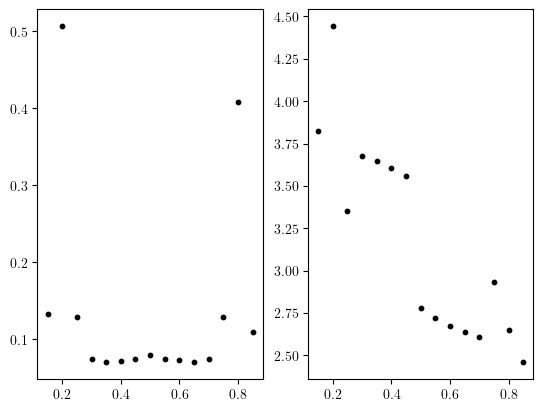

In [ ]:
chain_length = 8
def abs_eigvec(phid,b):
    d = np.array([np.cos(phid),np.sin(phid)])
    dmat = nearest_nb_Hamiltonian(b,h,a,chain_length,lambda x, y: dip_derivative_full(x, 0, 0, y),0,d)
    dmat += np.diag(np.ones(chain_length))*(m*w**2*r**2/V)[-1]
    beta = grad(b,h,a,chain_length,nom_der1,d)
    eigenvecs = np.linalg.solve(dmat,beta)
    return np.max(np.abs(eigenvecs))
from scipy.optimize import minimize_scalar
b = np.linspace(0.15,0.85,N)
fig, ax = plt.subplots(1,2)
for i in range(N):
    res = minimize_scalar(abs_eigvec,args=b[i],bounds=(0,2*np.pi),method='bounded')
    ax[0].scatter(b[i],res.fun,color='0',s=10)
    ax[1].scatter(b[i],res.x,color='0',s=10)
plt.show()
    

IndexError: list index out of range

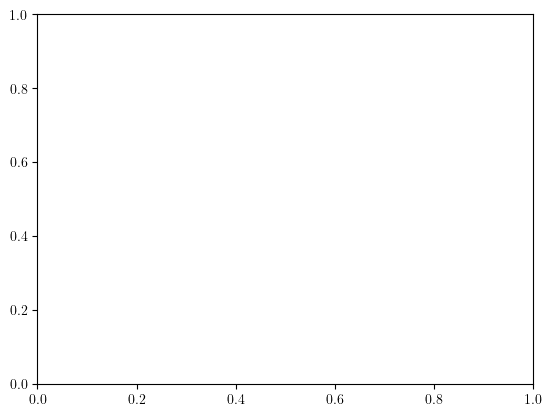

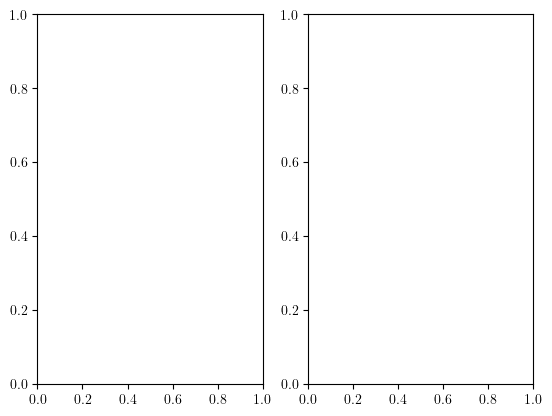

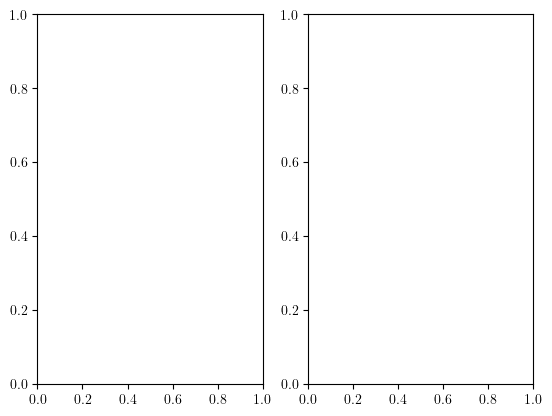

In [ ]:
def interaction(b,h,a,interaction1,interaction2,d):
    latticeA = np.array([[0,0],[a,0]])
    latticeB = np.array([b,h])
    dist1 = latticeB-latticeA[0]
    dist2 = latticeA[1]-latticeB
    grad1 = interaction1(dist1,d)
    grad2 = interaction1(dist2,d)
    hess1 = -interaction2(dist1,d)
    hess2 = -interaction2(dist2,d)
    return grad1, grad2, hess1, hess2

def interaction_nnn(b,h,a,interaction1,interaction2,d):
    latticeA = np.array([[0,0],[3*a,0]])
    latticeB = np.array([b,h])
    dist1 = latticeB-latticeA[0]
    dist2 = latticeA[1]-latticeB
    grad1 = interaction1(dist1,d)
    grad2 = interaction1(dist2,d)
    hess1 = -interaction2(dist1,d)
    hess2 = -interaction2(dist2,d)
    return grad1, grad2, hess1, hess2

def min_unwanted(param,b):
    phid = param[0]
    h = param[1]
    d = np.array([np.cos(phid),np.sin(phid)])
    dmat = nearest_nb_Hamiltonian(b,h,a,chain_length,lambda x, y: dip_derivative_full(x, 0, 0, y),0,d)
    dmat += np.diag(np.ones(chain_length))*(m*w**2*r**2/V)[-1]/10**8
    beta = grad(b,h,a,chain_length,nom_der1,d)
    eigenvecs = np.linalg.solve(dmat,beta)
    # eigenvecs = np.linalg.lstsq(dmat,beta)[0]
    # return np.linalg.norm(beta)
    return np.max(np.abs(eigenvecs))
from scipy.optimize import minimize
N = 60
b = np.linspace(0.25,0.75,N)
phis = np.ones(N)*(3.7)
hs = np.ones(N)*0.25
fig2, ax2 = plt.subplots(1,1)
fig3, ax3 = plt.subplots(1,2)
fig, ax = plt.subplots(1,2)
chain_length = 16
Deltap = 0.2
Deltah = 0.1
for i in range(N):
    phi_grid = np.linspace(-Deltap,Deltap,10)+phis[i-1]
    h_grid = np.linspace(-Deltah,Deltah,10)+hs[i-1]
    min_vals = np.zeros((len(phi_grid),len(h_grid)))
    min_phi = np.zeros_like(min_vals)
    min_h = np.zeros_like(min_vals)
    min_vals = []
    min_phi = []
    min_h = []
    
    for n in range(len(phi_grid)):
        for m in range(len(h_grid)):
            try:
                res = minimize(abs_eigvec,x0=(phi_grid[n],h_grid[m]),args=b[i],bounds=((0,2*np.pi),(-0.5,0.5)),tol=1e-12)
                min_vals.append(res.fun)
                min_phi.append(res.x[0])
                min_h.append(res.x[1])
            except:
                pass
    crit = np.array([min_vals, min_phi, min_h]).T
    sorted_crit = sorted(crit, key=lambda x: x[0])
    

    phis[i] = sorted_crit[0][1]
    hs[i] = sorted_crit[0][2]
    dmat = nearest_nb_Hamiltonian(b[i],hs[i],a,chain_length,lambda x, y: dip_derivative_full(x, 0, 0, y),0,np.array([np.cos(phis[i]),np.sin(phis[i])]))
    eig, vec = np.linalg.eig(dmat)
    ax3[0].scatter(b[i]*np.ones(chain_length),eig,color='0',s=30)
    beta = grad(b[i],hs[i],a,chain_length,nom_der1,np.array([np.cos(phis[i]),np.sin(phis[i])]))
    dmatp = dmat+ np.diag(np.ones(chain_length))*(m*w**2*r**2/V)[-1]/10**8
    vecp = np.linalg.solve(dmatp,beta)
    dis = dmat@vecp
    ax3[1].scatter(b[i],np.max(dis),color='0',s=10)
    # ax3[1].scatter(b[i]*np.ones(chain_length),beta,color='0',s=30)
    ax2.scatter(b[i],np.max(np.abs(dmat)),color='0',s=10)
    # ax2.scatter(b[i],sorted_crit[0][0],color='0',s=10)

ax[0].scatter(b,phis,color='0',s=10)
ax[1].scatter(b,hs,color='0',s=10)
plt.show()

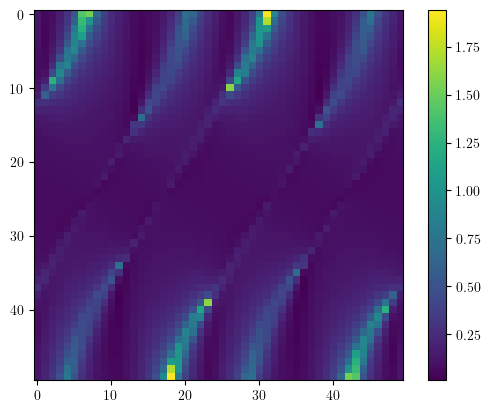

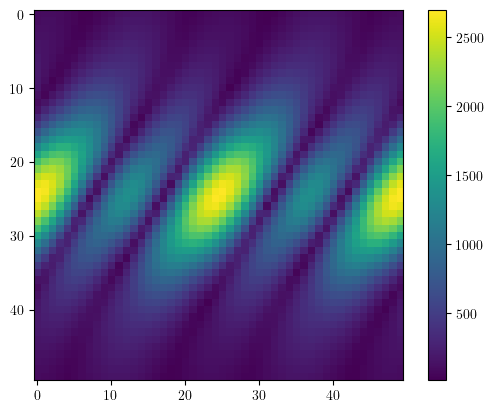

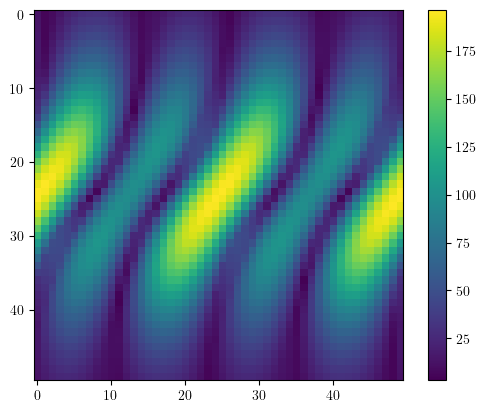

  message: ABNORMAL: 
  success: False
   status: 2
      fun: 0.04884375793010991
        x: [ 6.998e-01  3.630e-02]
      nit: 14
      jac: [ 1.783e-01  1.489e+00]
     nfev: 315
     njev: 105
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>

In [ ]:
N = 50
# phid = np.linspace(np.pi/4+0.2,np.pi/4*3-0.2,N)
# h = np.linspace(-0.2,-0.35,N)
phid = np.linspace(-np.pi,np.pi,N)
h = np.linspace(-0.5,0.5,N)
d = np.array([np.cos(phid),np.sin(phid)]).T
cut = 0.05
dis = np.zeros((N,N))
min_dmat = np.zeros((N,N))
min_beta = np.zeros((N,N))
b0 = 0.6
def abs_eigvec(param,b):
    phid = param[0]
    h = param[1]
    d = np.array([np.cos(phid),np.sin(phid)])
    # dmat = nearest_nb_Hamiltonian(b,h,a,chain_length,lambda x, y: dip_derivative_full(x, 0, 0, y),0,d)
    cut = 0.05
    # dmat += np.diag(np.ones(chain_length))*(m*w**2*r**2/V)[-1]/10**8
    # beta = grad(b,h,a,chain_length,nom_der1,d)
    dmat = hopping_Ham(b,h,1,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),d,cut)
    # dmat = hopping_Ham(b,h,(m*w**2*r**2/V)[-1]/10**8,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),d)
    beta = grad_long_range(b,h,a,chain_length,nom_der1_vec,d,cut)
    return np.max(np.abs(beta))/np.max(np.abs(dmat))#/np.min(np.where(dmat==0,np.inf,np.abs(dmat)))
    eigenvecs = np.linalg.solve(dmat,beta)
    # # eigenvecs = np.linalg.lstsq(dmat,beta)[0]
    # return np.linalg.norm(beta)
    return np.max(np.abs(eigenvecs))
for i in range(N):
    for j in range(N):
        dmat = hopping_Ham(b0,h[i],1,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),d[j],cut)
        beta = grad_long_range(b0,h[i],a,chain_length,nom_der1_vec,d[j],cut)
        eigenvecs = np.linalg.solve(dmat,beta)
        dis[i,j] = np.max(np.abs(beta))/np.max(np.where(np.abs(dmat)==0,0,np.abs(dmat)))
        min_dmat[i,j] = np.max(np.abs(dmat))#np.min(np.where(np.abs(dmat)==0,np.inf,np.abs(dmat)))
        min_beta[i,j] = np.max(np.abs(beta))
        # dis[i,j] = dis[i,j] if dis[i,j]<0.01 else np.nan
res = minimize(abs_eigvec,x0=(phid[N//2],h[N//2]),args=b0,bounds=((-2*np.pi,2*np.pi),(-0.7,0.7)),tol=1e-12)        
fig, ax = plt.subplots(1,1)
im = ax.imshow(dis)
cmap = fig.colorbar(im,ax=ax)
fig2, ax2 = plt.subplots(1,1)
im2 = ax2.imshow(min_dmat)
cmap2 = fig2.colorbar(im2,ax=ax2)
fig3, ax3 = plt.subplots(1,1)
im3 = ax3.imshow(min_beta)
cmap3 = fig3.colorbar(im3,ax=ax3)
plt.show()
res

In [ ]:
a=1

from scipy.optimize import minimize, minimize_scalar
def wrap_minimize(l,base=0):
    Del = Deltas[l]
    def abs_eigvec(param,b):
        phid = param[0]
        h = param[1]
        # h = -0.26
        d = np.array([np.cos(phid),np.sin(phid)])
        cut = 0.05
        dmat = hopping_Ham(b,h,Del,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),d,cut)
        beta = grad_long_range(b,h,a,chain_length,nom_der1_vec,d,cut)
        eigenvecs = np.linalg.solve(dmat,beta)
        return np.max(np.abs(eigenvecs))
    N = 20
    # b = np.linspace(0.25,0.75,N)
    b = np.linspace(0.35,0.65,N)
    phis = np.ones(N)*(np.pi/2)
    hs = np.ones(N)*-0.26
    chain_length = 8
    Deltap = 0.1
    Deltah = 0.01
    grid_numb = 7
    for i in range(N):
        phi_grid = np.linspace(-Deltap,Deltap,grid_numb)+phis[i-1]
        h_grid = np.linspace(-Deltah,Deltah,grid_numb)+hs[i-1]
        min_vals = np.zeros((len(phi_grid),len(h_grid)))
        min_phi = np.zeros_like(min_vals)
        min_h = np.zeros_like(min_vals)
        min_vals = []
        min_phi = []
        min_h = []
        
        for n in range(len(phi_grid)):
            for m in range(len(h_grid)):
                # try:
                    # res = minimize(abs_eigvec,x0=(phi_grid[n],h_grid[m]),args=b[i],bounds=((-2*np.pi,2*np.pi),(-0.7,0.7)),tol=1e-12)
                    res = minimize(abs_eigvec,x0=(phi_grid[n],h_grid[m]),args=b[i],bounds=((phis[i-1]-2*Deltap,phis[i-1]+2*Deltap),(hs[i-1]-2*Deltah,hs[i-1]+2*Deltah)),tol=1e-12)
                    # res = minimize_scalar(abs_eigvec,args=b[i],bounds=(np.pi*0.35,np.pi*0.65),tol=1e-12)
                    min_vals.append(res.fun)
                    min_phi.append(res.x[0])
                    # min_phi.append(res.x)
                    min_h.append(res.x[1])
                # except:
                #     pass
        crit = np.array([min_vals, min_phi, min_h]).T
        # crit = np.array([min_vals, min_phi]).T
        sorted_crit = sorted(crit, key=lambda x: x[0])
        

        phis[i] = sorted_crit[0][1]
        hs[i] = sorted_crit[0][2]
    print(1,end='')   
    return np.stack((phis, hs))
chain_length = 8
# Deltas = np.linspace(0.1,250,20)
# Deltas = [0.1,80,170,250]
Deltas = [2.5,0.8*250,4*250,2500]
opt_param = parallel_for([[0,4]],wrap_minimize)
# wrap_minimize(0)

1111

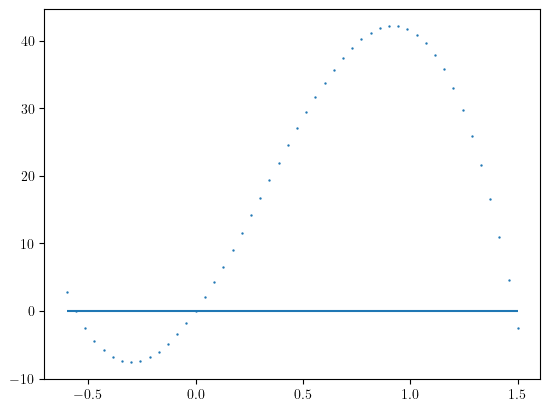

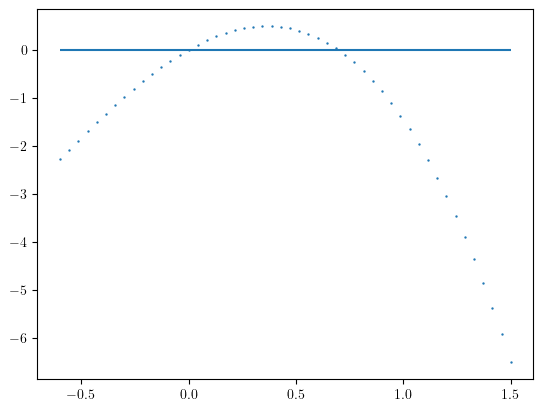

In [ ]:
alpha = np.array([np.sqrt(5)+2,np.sqrt(5)-2])

def func(r,i):
    return (24/np.sqrt(5)*alpha[i]) * r + (6*alpha[i]**2-30/np.sqrt(5)*alpha[i])*r**2+ (2-30/np.sqrt(5)*alpha[i])*r**3
r= np.linspace(-0.6,1.5)
fig, ax = plt.subplots(1,1)
ax.scatter(r,func(r,0))
ax.hlines(0,r[0],r[-1])
plt.show()
fig, ax = plt.subplots(1,1)
ax.scatter(r,func(r,1))
ax.hlines(0,r[0],r[-1])
plt.show()

/tmp/ipykernel_233039/3936734979.py:38: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(abs_eigvec,args=(b[11],hs[i]),bounds=(np.pi*0.35,np.pi*0.65),tol=1e-12)


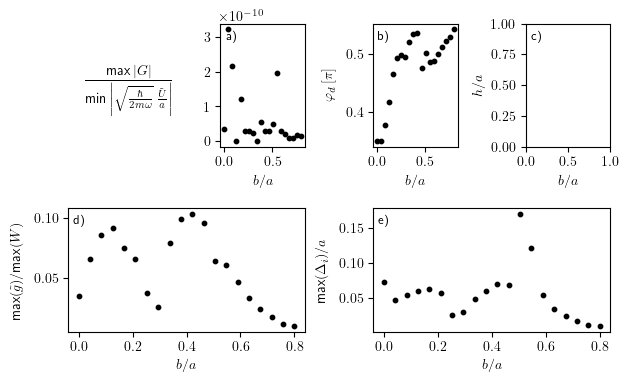

In [ ]:
from scipy.optimize import minimize, minimize_scalar
def abs_eigvec(param,b, h):
        phid = param        
        # h = -0.26
        d = np.array([np.cos(phid),np.sin(phid)])
        cut = 0.05
        dmat = hopping_Ham(b,h,170,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),d,cut)
        beta = grad_long_range(b,h,a,chain_length,nom_der1_vec,d,cut)
        eigenvecs = np.linalg.solve(dmat,beta)
        return np.max(np.abs(eigenvecs))   
N = 20   
phis = np.ones(N)*(np.pi/2)
hs = np.linspace(0,0.8,N)
fig = plt.figure(figsize=(setup.fig_width,setup.fig_height))
fig.tight_layout()
gs = gridspec.GridSpec(2,4, figure=fig)
ax0 = fig.add_subplot(gs[0,0])
ax1 = fig.add_subplot(gs[0,1])
ax2 = fig.add_subplot(gs[0,2])
ax3 = fig.add_subplot(gs[0,3])
ax4 = fig.add_subplot(gs[1,:2])
ax5 = fig.add_subplot(gs[1,2:])
chain_length = 8
Deltap = 0.2
b = np.linspace(0.35,0.65,N)
grid_numb = 7
for i in range(N):
    phi_grid = np.linspace(-Deltap,Deltap,grid_numb)+phis[i-1]
    
    min_vals = np.zeros(len(phi_grid))
    min_phi = np.zeros_like(min_vals)
    min_h = np.zeros_like(min_vals)
    min_vals = []
    min_phi = []
    min_h = []
    
    for n in range(len(phi_grid)):
        res = minimize_scalar(abs_eigvec,args=(b[11],hs[i]),bounds=(np.pi*0.35,np.pi*0.65),tol=1e-12)
        min_vals.append(res.fun)
        # min_phi.append(res.x[0])
        min_phi.append(res.x)
        # min_h.append(res.x[1])
               
#     crit = np.array([min_vals, min_phi, min_h]).T
    crit = np.array([min_vals, min_phi]).T
    sorted_crit = sorted(crit, key=lambda x: x[0])
        

    phis[i] = sorted_crit[0][1]
    dmat = hopping_Ham(b[11],hs[i],170,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis[i]),np.sin(phis[i])]))
    # bdg = BdG_Ham(b[i],hs[i],(m*w**2*r**2/V)[-1]/10**8,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis[i]),np.sin(phis[i])]))
    eig = np.linalg.eigvals(dmat)
    # ax1.scatter(b[i],np.max(np.abs(np.real(eig))),color='0',s=10)
    
    
    beta = grad_long_range(b[11],hs[i],a,chain_length,nom_der1_vec,np.array([np.cos(phis[i]),np.sin(phis[i])]))
    dis = np.linalg.solve(dmat,beta)
    h_new = beta-dmat@dis
    # ax3[1].scatter(b[i],np.max(h_new),color='0',s=10)
    # ax3[1].scatter(b[i]*np.ones(chain_length),beta,color='0',s=30)
    ax1.scatter(hs[i],np.max(h_new)/(np.min(np.where(dmat==0,np.inf,np.abs(dmat)))*3/1000),color='0',s=10)
    # ax6.scatter(b[i],np.max(dis)*10**3,color='0',s=10)
    ax5.scatter(hs[i],np.max(np.abs(np.real(dis))),color='0',s=10)
    # ax5.scatter(b[i],np.max(beta),color='0',s=10)
    ax4.scatter(hs[i],np.max(beta)/np.max(np.abs(dmat)),color='0',s=10)
ax0.axis("off")
ax2.scatter(hs,phis/np.pi,color='0',s=10)
# ax3.scatter(b,hs_plot,color='0',s=10)
ax1.set_xlabel(r"$b/a$")
ax2.set_ylabel(r"$\varphi_d\,[\pi]$",labelpad=pad)
ax2.set_xlabel(r"$b/a$")
ax3.set_ylabel(r"$h/a$")
ax3.set_xlabel(r"$b/a$")
ax4.set_xlabel(r"$b/a$")
# ax1.text(0.7,0.7,"a)",fontsize=9)

ax5.set_ylabel(r"max$(\Delta_i)/a$",labelpad=pad)
ax0.text(0.2,0.5,r"$$\frac{\text{max}\left|G\right|}{\text{min}\left|\sqrt{\frac{\hbar }{2m \omega}}\,\frac{\tilde{U}}{a}\right|}$$")
ax5.set_xlabel(r"$b/a$")
ax4.set_ylabel(r"$\text{max}(\tilde{g})/\text{max}(W)$",labelpad=pad)
# ax6.set_xlabel(r"$b/a$")
# ax6.set_ylabel(r"$$\text{max}(\Delta_i)/\sqrt{\hbar/2m\omega}$$",labelpad=pad)
ax4.text(0.02,0.88,"d)",fontsize=9,transform=ax4.transAxes)
ax5.text(0.02,0.88,"e)",fontsize=9,transform=ax5.transAxes)
ax1.text(0.06,0.87,"a)",fontsize=9,transform=ax1.transAxes)
ax2.text(0.06,0.87,"b)",fontsize=9,transform=ax2.transAxes)
ax3.text(0.06,0.87,"c)",fontsize=9,transform=ax3.transAxes)
plt.subplots_adjust(wspace=0.8,hspace=0.5)
# plt.savefig("/home//christian/Documents/master/protocol/pictures/"+"tuning_first_order_to_zero3.pdf",bbox_inches='tight')#free_evol_1spto10coupling
plt.show()

5.79719198072338 6.108962666353326
5.842879983202702 6.2598683125548735
5.854621365997753 6.3636848066657
5.832453632721582 6.4127274534158465
1.096340677775935 2.8803316621016815
0.6655176432471546 2.35031577477405
0.14424773133520333 1.6976668220410973
-0.5081657655822371 0.863810591128529
-0.3849229559226491 -0.9568641718264211
-0.3737114164037926 -0.6377533952168399
-0.5673457559356935 -0.5985433178165341
-1.0616257322735831 -0.891375429094904
4.178741564009668 4.895096729000689
1.811004576656468 2.8755354389113608
1.3558689454950013 2.8579836874040896
1.3846965704121794 3.0782357717627282
1.2840545910038188 2.9229148149118425
1.2066958041266305 2.823559028573854
1.1395535189269863 2.7504001728240635
1.0761894927467728 2.6884351153561505


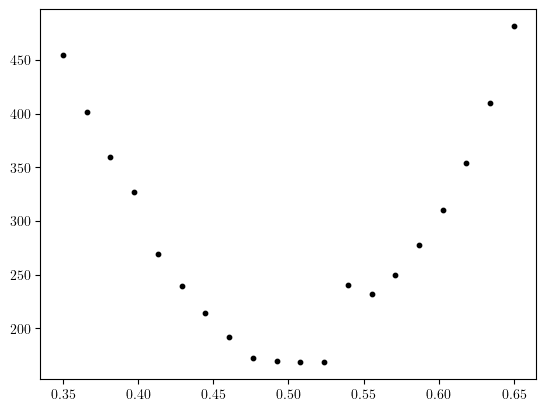

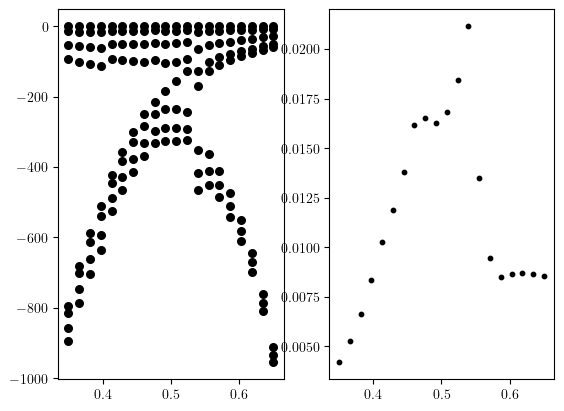

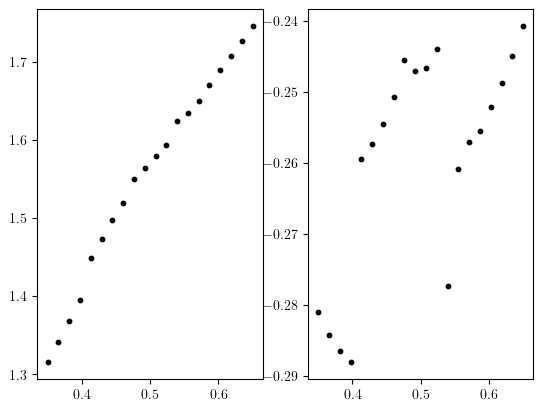

In [ ]:
a = 1
def abs_eigvec(param,b):
    phid = param[0]
    h = param[1]
    d = np.array([np.cos(phid),np.sin(phid)])
    # dmat = nearest_nb_Hamiltonian(b,h,a,chain_length,lambda x, y: dip_derivative_full(x, 0, 0, y),0,d)
    cut = 0.05
    # dmat += np.diag(np.ones(chain_length))*(m*w**2*r**2/V)[-1]/10**8
    # beta = grad(b,h,a,chain_length,nom_der1,d)
    dmat = hopping_Ham(b,h,250,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),d,cut)
    # dmat = hopping_Ham(b,h,(m*w**2*r**2/V)[-1]/10**8,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),d)
    beta = grad_long_range(b,h,a,chain_length,nom_der1_vec,d,cut)
    # return np.max(np.abs(beta))/np.max(np.abs(dmat))
    # return np.max(np.abs(beta))/np.min(np.where(dmat==0,np.inf,np.abs(dmat)))
    eigenvecs = np.linalg.solve(dmat,beta)
    # # eigenvecs = np.linalg.lstsq(dmat,beta)[0]
    # return np.linalg.norm(beta)
    return np.max(np.abs(eigenvecs))
from scipy.optimize import minimize
N = 20
# b = np.linspace(0.25,0.75,N)
b = np.linspace(0.35,0.65,N)
phis = np.ones(N)*(np.pi/2)
hs = np.ones(N)*-0.25
fig2, ax2 = plt.subplots(1,1)
fig3, ax3 = plt.subplots(1,2)
fig, ax = plt.subplots(1,2)
chain_length = 8
Deltap = 0.2
Deltah = 0.1
grid_numb = 7
for i in range(N):
    phi_grid = np.linspace(-Deltap,Deltap,grid_numb)+phis[i-1]
    h_grid = np.linspace(-Deltah,Deltah,grid_numb)+hs[i-1]
    min_vals = np.zeros((len(phi_grid),len(h_grid)))
    min_phi = np.zeros_like(min_vals)
    min_h = np.zeros_like(min_vals)
    min_vals = []
    min_phi = []
    min_h = []
    
    for n in range(len(phi_grid)):
        for m in range(len(h_grid)):
            try:
                # res = minimize(abs_eigvec,x0=(phi_grid[n],h_grid[m]),args=b[i],bounds=((-2*np.pi,2*np.pi),(-0.7,0.7)),tol=1e-12)
                res = minimize(abs_eigvec,x0=(phi_grid[n],h_grid[m]),args=b[i],bounds=((phis[i-1]-2*Deltap,phis[i-1]+2*Deltap),(hs[i-1]-2*Deltah,hs[i-1]+2*Deltah)),tol=1e-12)
                min_vals.append(res.fun)
                min_phi.append(res.x[0])
                min_h.append(res.x[1])
            except:
                pass
    crit = np.array([min_vals, min_phi, min_h]).T
    sorted_crit = sorted(crit, key=lambda x: x[0])
    

    phis[i] = sorted_crit[0][1]
    hs[i] = sorted_crit[0][2]
    dmat = nearest_nb_Hamiltonian(b[i],hs[i],a,chain_length,lambda x, y: dip_derivative_full(x, 0, 0, y),0,np.array([np.cos(phis[i]),np.sin(phis[i])]))
    eig, vec = np.linalg.eig(dmat)
    ax3[0].scatter(b[i]*np.ones(chain_length),eig,color='0',s=30)
    beta = grad(b[i],hs[i],a,chain_length,nom_der1,np.array([np.cos(phis[i]),np.sin(phis[i])]))
    # dmatp = dmat+ np.diag(np.ones(chain_length))*(m*w**2*r**2/V)[-1]/10**8
    # vecp = np.linalg.solve(dmatp,beta)
    # dis = dmat@vecp
    ax3[1].scatter(b[i],sorted_crit[0][0],color='0',s=10)
    # ax3[1].scatter(b[i]*np.ones(chain_length),beta,color='0',s=30)
    ax2.scatter(b[i],np.max(np.abs(dmat)),color='0',s=10)
    # ax2.scatter(b[i],sorted_crit[0][0],color='0',s=10)

ax[0].scatter(b,phis,color='0',s=10)
ax[1].scatter(b,hs,color='0',s=10)
plt.show()

13.275806024382677 8.934735820096527
203.68142223529148 50.98095698822362
177.85185185185085 56.273437499999886
155.989955832081 62.27087701825966
137.3863220214839 69.0890186539388
121.47520787640956 76.8663951496161
107.80222937943714 85.76960448102406
95.99999999999977 95.99999999999977
85.76960448102406 107.8022293794371
76.8663951496161 121.47520787640956
69.08901865393885 137.38632202148383
62.27087701825966 155.989955832081
56.273437499999886 177.85185185185085
50.98095698822362 203.68142223529162
46.2962962962962 234.37499999999866


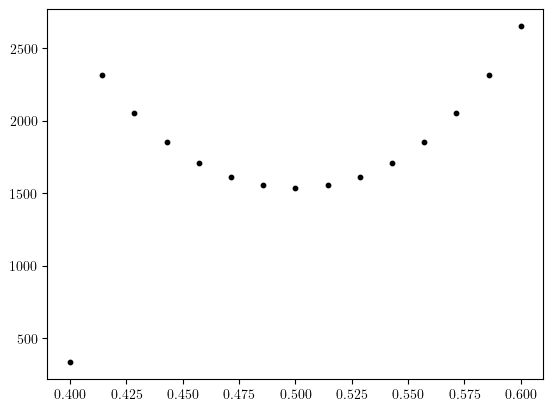

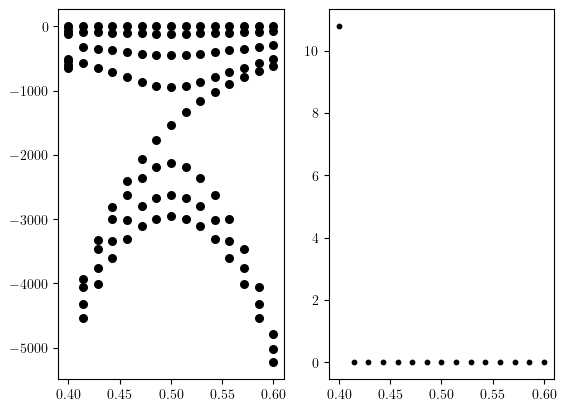

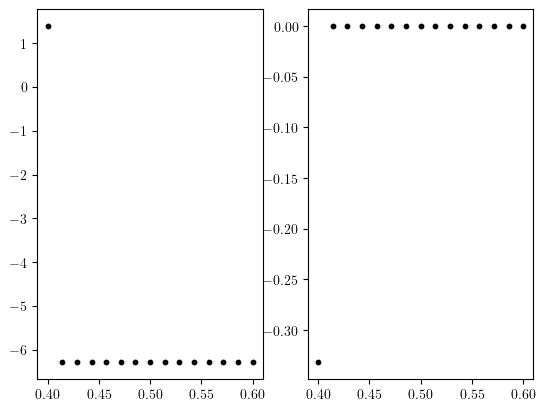

In [ ]:
a = 1
def abs_eigvec(param,b):
    phid = param[0]
    h = param[1]
    d = np.array([np.cos(phid),np.sin(phid)])
    # dmat = nearest_nb_Hamiltonian(b,h,a,chain_length,lambda x, y: dip_derivative_full(x, 0, 0, y),0,d)
    cut = 0.05
    # dmat += np.diag(np.ones(chain_length))*(m*w**2*r**2/V)[-1]/10**8
    # beta = grad(b,h,a,chain_length,nom_der1,d)
    dmat = hopping_Ham(b,h,0.01,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),d,cut)
    # dmat = hopping_Ham(b,h,(m*w**2*r**2/V)[-1]/10**8,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),d)
    beta = grad_long_range(b,h,a,chain_length,nom_der1_vec,d,cut)
    beta_h = grad_long_range(b,h,a,chain_length,gradh,d,cut)
    beta_phi = grad_long_range(b,h,a,chain_length,gradphi,d,cut)
    dmat_h = hopping_Ham(b,h,0.0,a,chain_length,hessh,d,cut)
    dmat_phi = hopping_Ham(b,h,0.0,a,chain_length,hessphi,d,cut)
    dmat_inv = np.linalg.inv(dmat)
    
    v = -dmat_h@ dmat_inv @ beta + beta_h - dmat_phi @ dmat_inv @ beta + beta_phi
    return np.linalg.norm(v)
    # return np.max(np.abs(beta))/np.min(np.where(dmat==0,np.inf,np.abs(dmat)))
    # eigenvecs = np.linalg.solve(dmat+dmat_h+dmat_phi,beta+beta_h+beta_phi)
    # # # eigenvecs = np.linalg.lstsq(dmat,beta)[0]
    # # return np.linalg.norm(beta)
    # return np.max(np.abs(eigenvecs))
from scipy.optimize import minimize
N = 15
# b = np.linspace(0.25,0.75,N)
b = np.linspace(0.4,0.6,N)
phis = np.ones(N)*(np.pi/2)
hs = np.ones(N)*-0.25
fig2, ax2 = plt.subplots(1,1)
fig3, ax3 = plt.subplots(1,2)
fig, ax = plt.subplots(1,2)
chain_length = 8
Deltap = 0.2
Deltah = 0.1
grid_numb = 3
for i in range(N):
    phi_grid = np.linspace(-Deltap,Deltap,grid_numb)+phis[i-1]
    h_grid = np.linspace(-Deltah,Deltah,grid_numb)+hs[i-1]
    min_vals = np.zeros((len(phi_grid),len(h_grid)))
    min_phi = np.zeros_like(min_vals)
    min_h = np.zeros_like(min_vals)
    min_vals = []
    min_phi = []
    min_h = []
    
    for n in range(len(phi_grid)):
        for m in range(len(h_grid)):
            # try:
                res = minimize(abs_eigvec,x0=(phi_grid[n],h_grid[m]),args=b[i],bounds=((-2*np.pi,2*np.pi),(-0.7,0.7)),tol=1e-12)
                min_vals.append(res.fun)
                min_phi.append(res.x[0])
                min_h.append(res.x[1])
            # except:
            #     pass
    crit = np.array([min_vals, min_phi, min_h]).T
    sorted_crit = sorted(crit, key=lambda x: x[0])
    

    phis[i] = sorted_crit[0][1]
    hs[i] = sorted_crit[0][2]
    dmat = nearest_nb_Hamiltonian(b[i],hs[i],a,chain_length,lambda x, y: dip_derivative_full(x, 0, 0, y),0,np.array([np.cos(phis[i]),np.sin(phis[i])]))
    eig, vec = np.linalg.eig(dmat)
    ax3[0].scatter(b[i]*np.ones(chain_length),eig,color='0',s=30)
    beta = grad(b[i],hs[i],a,chain_length,nom_der1,np.array([np.cos(phis[i]),np.sin(phis[i])]))
    # dmatp = dmat#+ np.diag(np.ones(chain_length))*(m*w**2*r**2/V)[-1]/10**8
    # vecp = np.linalg.solve(dmatp,beta)
    # dis = dmat@vecp
    ax3[1].scatter(b[i],sorted_crit[0][0],color='0',s=10)
    # ax3[1].scatter(b[i]*np.ones(chain_length),beta,color='0',s=30)
    ax2.scatter(b[i],np.max(np.abs(dmat)),color='0',s=10)
    # ax2.scatter(b[i],sorted_crit[0][0],color='0',s=10)

ax[0].scatter(b,phis,color='0',s=10)
ax[1].scatter(b,hs,color='0',s=10)
plt.show()

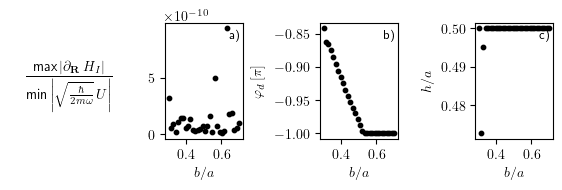

In [ ]:
phis_plot = phis
hs_plot = hs
setup = Setup_Fig(name_of_plot='lam2_anal_ml.png',fig_width=7,fig_height=1.5,xax_share=True,joined=True)
fig = plt.figure(figsize=(setup.fig_width,setup.fig_height))
fig.tight_layout()
gs = gridspec.GridSpec(1,4, figure=fig)
ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])
ax2 = fig.add_subplot(gs[2])
ax3 = fig.add_subplot(gs[3])
# ax4 = fig.add_subplot(gs[1,:2])
# ax5 = fig.add_subplot(gs[1,2:])
# ax6 = fig.add_subplot(gs[1,8:])
# fig, ax = setup.return_fig((1,2))
# fig2, ax3 = setup.return_fig((1,2))
# N = 30
pad = 7
# b = np.linspace(0.25,0.75,N)
b = np.linspace(0.3,0.7,N)
for i in range(N):
    
    # dmat = hopping_Ham(b[i],hs[i],(m*w**2*r**2/V)[-1]/10**8,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis[i]),np.sin(phis[i])]))
    dmat = hopping_Ham(b[i],hs[i],0,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis[i]),np.sin(phis[i])]))
    bdg = BdG_Ham(b[i],hs[i],(m*w**2*r**2/V)[-1]/10**8,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis[i]),np.sin(phis[i])]))
    eig = np.linalg.eigvals(dmat)
    # ax1.scatter(b[i],np.max(np.abs(np.real(eig))),color='0',s=10)
    
    
    beta = grad_long_range(b[i],hs[i],a,chain_length,nom_der1_vec,np.array([np.cos(phis[i]),np.sin(phis[i])]))
    dis = np.linalg.solve(dmat,beta)
    h_new = beta-dmat@dis
    # ax3[1].scatter(b[i],np.max(h_new),color='0',s=10)
    # ax3[1].scatter(b[i]*np.ones(chain_length),beta,color='0',s=30)
    ax1.scatter(b[i],np.max(h_new)/(np.min(np.where(dmat==0,np.inf,np.abs(dmat)))*3/1000),color='0',s=10)
    # ax6.scatter(b[i],np.max(dis)*10**3,color='0',s=10)
    # ax5.scatter(b[i],np.max(dis),color='0',s=10)
    # ax5.scatter(b[i],np.max(beta),color='0',s=10)
    # ax4.scatter(b[i],np.max(beta)/np.max(np.abs(dmatp)),color='0',s=10)
    # ax4.scatter(b[i],np.max(beta)/np.min(np.where(dmatp==0,np.inf,np.abs(dmatp))),color='0',s=10)
    # ax2.scatter(b[i],sorted_crit[0][0],color='0',s=10)
ax0.axis("off")
ax2.scatter(b,phis_plot/np.pi,color='0',s=10)
ax3.scatter(b,hs_plot,color='0',s=10)
ax1.set_xlabel(r"$b/a$")
ax2.set_ylabel(r"$\varphi_d\,[\pi]$",labelpad=pad)
ax2.set_xlabel(r"$b/a$")
ax3.set_ylabel(r"$h/a$")
ax3.set_xlabel(r"$b/a$")
# ax4.set_xlabel(r"$b/a$")
# # ax1.text(0.7,0.7,"a)",fontsize=9)

# ax5.set_ylabel(r"max$(\Delta_i)/a$",labelpad=pad)
# ax0.text(0.2,0.5,r"$$\frac{\text{max}\left|G\right|}{\text{min}\left|\sqrt{\frac{\hbar }{2m \omega}}\,\frac{\tilde{U}}{a}\right|}$$")
ax0.text(0.2,0.5,r"$$\frac{\text{max}\left|\partial_\mathbf{R}\,H_I\right|}{\text{min}\left|\sqrt{\frac{\hbar }{2m \omega}}\,U\right|}$$")
# ax5.set_xlabel(r"$b/a$")
# ax4.set_ylabel(r"$\text{max}(\tilde{g})/\text{max}(W)$",labelpad=pad)
# ax6.set_xlabel(r"$b/a$")
# ax6.set_ylabel(r"$$\text{max}(\Delta_i)/\sqrt{\hbar/2m\omega}$$",labelpad=pad)
# ax4.text(0.93,0.88,"d)",fontsize=9,transform=ax4.transAxes)
# ax5.text(0.93,0.88,"e)",fontsize=9,transform=ax5.transAxes)
ax1.text(0.82,0.87,"a)",fontsize=9,transform=ax1.transAxes)
ax2.text(0.82,0.87,"b)",fontsize=9,transform=ax2.transAxes)
ax3.text(0.82,0.87,"c)",fontsize=9,transform=ax3.transAxes)
plt.subplots_adjust(wspace=1,hspace=0.5)
# plt.savefig("/home//christian/Documents/master/protocol/pictures/"+"minimizing_first_order.pdf",bbox_inches='tight')#free_evol_1spto10coupling
plt.show()

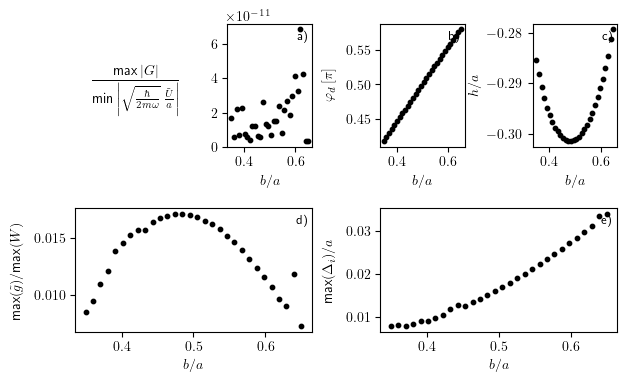

In [ ]:
phis_plot = phis
hs_plot = hs
setup = Setup_Fig(name_of_plot='lam2_anal_ml.png',fig_width=7,fig_height=4,xax_share=True,joined=True)
fig = plt.figure(figsize=(setup.fig_width,setup.fig_height))
fig.tight_layout()
gs = gridspec.GridSpec(2,4, figure=fig)
ax0 = fig.add_subplot(gs[0,0])
ax1 = fig.add_subplot(gs[0,1])
ax2 = fig.add_subplot(gs[0,2])
ax3 = fig.add_subplot(gs[0,3])
ax4 = fig.add_subplot(gs[1,:2])
ax5 = fig.add_subplot(gs[1,2:])
# ax6 = fig.add_subplot(gs[1,8:])
# fig, ax = setup.return_fig((1,2))
# fig2, ax3 = setup.return_fig((1,2))
# N = 30
pad = 7
# b = np.linspace(0.25,0.75,N)
# b = np.linspace(0.3,0.7,N)
for j in range(N):
    if j<N//2:
        i =j
    else:
        i = N-1-j
    i = j
    # dmat = hopping_Ham(b[i],hs[i],(m*w**2*r**2/V)[-1]/10**8,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis[i]),np.sin(phis[i])]))
    dmat = hopping_Ham(b[j],hs[i],1,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis[i]),np.sin(phis[i])]))
    # bdg = BdG_Ham(b[i],hs[i],(m*w**2*r**2/V)[-1]/10**8,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis[i]),np.sin(phis[i])]))
    eig = np.linalg.eigvals(dmat)
    # ax1.scatter(b[i],np.max(np.abs(np.real(eig))),color='0',s=10)
    
    
    beta = grad_long_range(b[j],hs[i],a,chain_length,nom_der1_vec,np.array([np.cos(phis[i]),np.sin(phis[i])]))
    dis = np.linalg.solve(dmat,beta)
    h_new = beta-dmat@dis
    # ax3[1].scatter(b[i],np.max(h_new),color='0',s=10)
    # ax3[1].scatter(b[i]*np.ones(chain_length),beta,color='0',s=30)
    ax1.scatter(b[j],np.max(h_new)/(np.min(np.where(dmat==0,np.inf,np.abs(dmat)))*3/1000),color='0',s=10)
    # ax6.scatter(b[i],np.max(dis)*10**3,color='0',s=10)
    ax5.scatter(b[j],np.max(dis),color='0',s=10)
    # ax5.scatter(b[i],np.max(beta),color='0',s=10)
    ax4.scatter(b[j],np.max(beta)/np.max(np.abs(dmat)),color='0',s=10)
    # ax4.scatter(b[i],np.max(np.abs(dmat)),color='0',s=10)
    # ax4.scatter(b[i],np.max(beta)/np.min(np.where(dmat==0,np.inf,np.abs(dmat))),color='0',s=10)
    # ax2.scatter(b[i],sorted_crit[0][0],color='0',s=10)
    ax2.scatter(b[j],phis_plot[i]/np.pi,color='0',s=10)
    ax3.scatter(b[j],hs_plot[i],color='0',s=10)
ax0.axis("off")

ax1.set_xlabel(r"$b/a$")
ax2.set_ylabel(r"$\varphi_d\,[\pi]$",labelpad=pad)
ax2.set_xlabel(r"$b/a$")
ax3.set_ylabel(r"$h/a$")
ax3.set_xlabel(r"$b/a$")
ax4.set_xlabel(r"$b/a$")
# ax1.text(0.7,0.7,"a)",fontsize=9)

ax5.set_ylabel(r"max$(\Delta_i)/a$",labelpad=pad)
ax0.text(0.2,0.5,r"$$\frac{\text{max}\left|G\right|}{\text{min}\left|\sqrt{\frac{\hbar }{2m \omega}}\,\frac{\tilde{U}}{a}\right|}$$")
ax5.set_xlabel(r"$b/a$")
ax4.set_ylabel(r"$\text{max}(\tilde{g})/\text{max}(W)$",labelpad=pad)
# ax6.set_xlabel(r"$b/a$")
# ax6.set_ylabel(r"$$\text{max}(\Delta_i)/\sqrt{\hbar/2m\omega}$$",labelpad=pad)
ax4.text(0.93,0.88,"d)",fontsize=9,transform=ax4.transAxes)
ax5.text(0.93,0.88,"e)",fontsize=9,transform=ax5.transAxes)
ax1.text(0.82,0.87,"a)",fontsize=9,transform=ax1.transAxes)
ax2.text(0.82,0.87,"b)",fontsize=9,transform=ax2.transAxes)
ax3.text(0.82,0.87,"c)",fontsize=9,transform=ax3.transAxes)
plt.subplots_adjust(wspace=0.8,hspace=0.5)
# plt.savefig("/home//christian/Documents/master/protocol/pictures/"+"tuning_first_order_to_zero2.pdf",bbox_inches='tight')#free_evol_1spto10coupling
plt.show()

In [ ]:
opt_param = np.load("topological_phenomena_dipoles/parameters_for_zero_first_order/phih_diff_del_chosen_opt.npy",allow_pickle=True)
b = np.load("topological_phenomena_dipoles/parameters_for_zero_first_order/b_diff_del_chosen_opt.npy",allow_pickle=True)
chain_length = 8
N = len(b)
Deltas = [2.5,0.8*250,4*250,2500]

In [ ]:
def abs_eigvecD(param,b,Del):
        phid = param[0]
        h = param[1]
        # h = -0.26
        d = np.array([np.cos(phid),np.sin(phid)])
        cut = 0.05
        dmat = hopping_Ham(b,h,Del,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),d,cut)
        beta = grad_long_range(b,h,a,chain_length,nom_der1_vec,d,cut)
        eigenvecs = np.linalg.solve(dmat,beta)
        return np.max(np.abs(eigenvecs))
def find_single_p(b,Del,Deltap,Deltah,phi0,h0,grid_numb):
    try:
        b[0]
        b0=b
    except:
        b0 = [b]
    phis = np.zeros(len(b0))
    hs = np.zeros_like(phis)
    minis = np.zeros_like(phis)
    for i in range(len(b0)):
        phi_grid = np.linspace(-Deltap,Deltap,grid_numb)+phi0
        h_grid = np.linspace(-Deltah,Deltah,grid_numb)+h0
        min_vals = np.zeros((len(phi_grid),len(h_grid)))
        min_phi = np.zeros_like(min_vals)
        min_h = np.zeros_like(min_vals)
        min_vals = []
        min_phi = []
        min_h = []
        for n in range(len(phi_grid)):
            for m in range(len(h_grid)):
            
                # try:
                    # res = minimize(abs_eigvec,x0=(phi_grid[n],h_grid[m]),args=b[i],bounds=((-2*np.pi,2*np.pi),(-0.7,0.7)),tol=1e-12)
                    res = minimize(abs_eigvecD,x0=(phi_grid[n],h_grid[m]),args=(b0[i],Del),bounds=((phi0-2*Deltap,phi0+2*Deltap),(h0-2*Deltah,h0+2*Deltah)),tol=1e-12)
                    # res = minimize_scalar(abs_eigvec,args=b[i],bounds=(np.pi*0.35,np.pi*0.65),tol=1e-12)
                    min_vals.append(res.fun)
                    min_phi.append(res.x[0]/np.pi)
                    # min_phi.append(res.x)
                    min_h.append(res.x[1])
                # except:
                #     pass
        crit = np.array([min_vals, min_phi, min_h]).T
        # crit = np.array([min_vals, min_phi]).T
        sorted_crit = sorted(crit, key=lambda x: x[0])
        minis[i] = sorted_crit[0][0]
        phis[i] = phi0 = sorted_crit[0][1]
        phi0 = sorted_crit[0][1]*np.pi
        hs[i] = h0 = sorted_crit[0][2]
    return np.stack((minis,phis,hs)).T

In [ ]:
param = find_single_p(b,Deltas[0],0.05,0.005,-0.42*np.pi,0.29,7)
# param = find_single_p(b[0],Deltas[0],np.pi/2,0.2,0,0.43,7)
param

array([[ 0.0073799 , -0.41778172,  0.28530393],
       [ 0.00797119, -0.42691063,  0.28969669],
       [ 0.00855771, -0.43565298,  0.29305459],
       [ 0.00920029, -0.44460524,  0.29582496],
       [ 0.00992975, -0.45269772,  0.29757715],
       [ 0.01091134, -0.46154711,  0.29921059],
       [ 0.01193795, -0.47042564,  0.3003998 ],
       [ 0.01332369, -0.47912704,  0.30133642],
       [ 0.0146159 , -0.48775937,  0.30162434],
       [ 0.01599885, -0.49639365,  0.30152529],
       [ 0.01747146, -0.50501278,  0.30105124],
       [ 0.01903258, -0.51360091,  0.30020922],
       [ 0.02068104, -0.52214344,  0.29900113],
       [ 0.02241584, -0.53062702,  0.29742361],
       [ 0.02423614, -0.53903932,  0.29546827],
       [ 0.02614143, -0.54736906,  0.29312184],
       [ 0.0281315 , -0.55560579,  0.29036661],
       [ 0.03020701, -0.56374025,  0.28718066],
       [ 0.03238305, -0.57176225,  0.2835344 ],
       [ 0.03463328, -0.5796647 ,  0.2794091 ]])

In [ ]:
opt_param[0,0,:] = param[:,1]*np.pi
opt_param[0,1,:] = param[:,2]

NameError: name 'param' is not defined

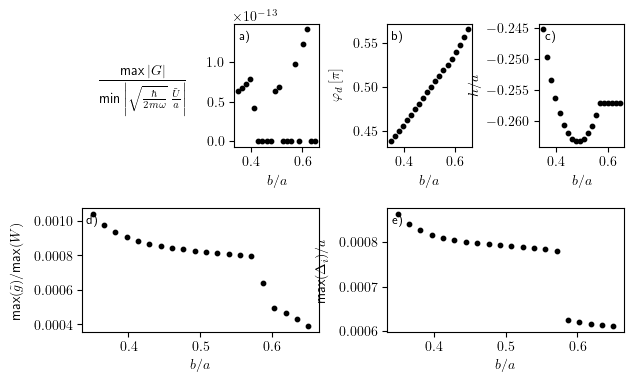

In [ ]:
l =3
# N=20
# b = np.linspace(0.35,0.65,N)
cut = 0.05
phis_plot = opt_param[l][0]
hs_plot = opt_param[l][1]
setup = Setup_Fig(name_of_plot='lam2_anal_ml.png',fig_width=7,fig_height=4,xax_share=True)
fig = plt.figure(figsize=(setup.fig_width,setup.fig_height))
fig.tight_layout()
gs = gridspec.GridSpec(2,4, figure=fig)
ax0 = fig.add_subplot(gs[0,0])
ax1 = fig.add_subplot(gs[0,1])
ax2 = fig.add_subplot(gs[0,2])
ax3 = fig.add_subplot(gs[0,3])
ax4 = fig.add_subplot(gs[1,:2])
ax5 = fig.add_subplot(gs[1,2:])
# ax6 = fig.add_subplot(gs[1,8:])
# fig, ax = setup.return_fig((1,2))
# fig2, ax3 = setup.return_fig((1,2))
# N = 30
pad = 7
# b = np.linspace(0.25,0.75,N)
# b = np.linspace(0.3,0.7,N)
for i in range(N):
    
    
    # dmat = hopping_Ham(b[i],hs[i],(m*w**2*r**2/V)[-1]/10**8,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis[i]),np.sin(phis[i])]))
    dmat = hopping_Ham(b[i],hs_plot[i],Deltas[l],a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis_plot[i]),np.sin(phis_plot[i])]),cut)
    # bdg = BdG_Ham(b[i],hs[i],(m*w**2*r**2/V)[-1]/10**8,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis[i]),np.sin(phis[i])]))
    eig = np.linalg.eigvals(dmat)
    # ax1.scatter(b[i],np.max(np.abs(np.real(eig))),color='0',s=10)
    
    
    beta = grad_long_range(b[i],hs_plot[i],a,chain_length,nom_der1_vec,np.array([np.cos(phis_plot[i]),np.sin(phis_plot[i])]),cut)
    dis = np.linalg.solve(dmat,beta)
    h_new = beta-dmat@dis
    # ax3[1].scatter(b[i],np.max(h_new),color='0',s=10)
    # ax3[1].scatter(b[i]*np.ones(chain_length),beta,color='0',s=30)
    ax1.scatter(b[i],np.max(h_new)/(np.min(np.where(dmat==0,np.inf,np.abs(dmat)))*3/1000),color='0',s=10)
    # ax6.scatter(b[i],np.max(dis)*10**3,color='0',s=10)
    ax5.scatter(b[i],np.max(np.abs(np.real(dis))),color='0',s=10)
    # ax5.scatter(b[i],np.max(beta),color='0',s=10)
    ax4.scatter(b[i],np.max(beta)/np.max(np.abs(dmat)),color='0',s=10)
    # ax4.scatter(b[i],np.max(np.abs(dmat)),color='0',s=10)
    # ax4.scatter(b[i],np.max(beta)/np.min(np.where(dmat==0,np.inf,np.abs(dmat))),color='0',s=10)
    # ax2.scatter(b[i],sorted_crit[0][0],color='0',s=10)
ax0.axis("off")
ax2.scatter(b,phis_plot/np.pi,color='0',s=10)
ax3.scatter(b,hs_plot,color='0',s=10)
ax1.set_xlabel(r"$b/a$")
ax2.set_ylabel(r"$\varphi_d\,[\pi]$",labelpad=pad)
ax2.set_xlabel(r"$b/a$")
ax3.set_ylabel(r"$h/a$")
ax3.set_xlabel(r"$b/a$")
ax4.set_xlabel(r"$b/a$")
# ax1.text(0.7,0.7,"a)",fontsize=9)

ax5.set_ylabel(r"max$(\Delta_i)/a$",labelpad=pad)
ax0.text(0.2,0.5,r"$$\frac{\text{max}\left|G\right|}{\text{min}\left|\sqrt{\frac{\hbar }{2m \omega}}\,\frac{\tilde{U}}{a}\right|}$$")
ax5.set_xlabel(r"$b/a$")
ax4.set_ylabel(r"$\text{max}(\tilde{g})/\text{max}(W)$",labelpad=pad)
# ax6.set_xlabel(r"$b/a$")
# ax6.set_ylabel(r"$$\text{max}(\Delta_i)/\sqrt{\hbar/2m\omega}$$",labelpad=pad)
ax4.text(0.02,0.88,"d)",fontsize=9,transform=ax4.transAxes)
ax5.text(0.02,0.88,"e)",fontsize=9,transform=ax5.transAxes)
ax1.text(0.06,0.87,"a)",fontsize=9,transform=ax1.transAxes)
ax2.text(0.06,0.87,"b)",fontsize=9,transform=ax2.transAxes)
ax3.text(0.06,0.87,"c)",fontsize=9,transform=ax3.transAxes)
plt.subplots_adjust(wspace=0.8,hspace=0.5)
# plt.savefig("/home//christian/Documents/master/protocol/pictures/"+"tuning_first_order_to_zero3.pdf",bbox_inches='tight')#free_evol_1spto10coupling
plt.show()

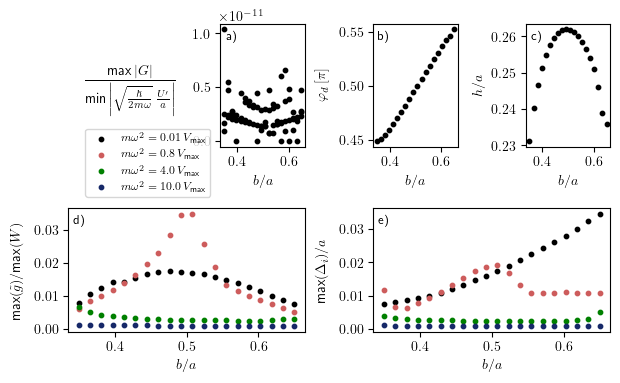

In [ ]:
l =3
# N=20
# b = np.linspace(0.35,0.65,N)
cut = 0.05

setup = Setup_Fig(name_of_plot='lam2_anal_ml.png',fig_width=7,fig_height=4,xax_share=True)
fig = plt.figure(figsize=(setup.fig_width,setup.fig_height))
fig.tight_layout()
gs = gridspec.GridSpec(2,4, figure=fig)
ax0 = fig.add_subplot(gs[0,0])
ax1 = fig.add_subplot(gs[0,1])
ax2 = fig.add_subplot(gs[0,2])
ax3 = fig.add_subplot(gs[0,3])
ax4 = fig.add_subplot(gs[1,:2])
ax5 = fig.add_subplot(gs[1,2:])
# ax6 = fig.add_subplot(gs[1,8:])
# fig, ax = setup.return_fig((1,2))
# fig2, ax3 = setup.return_fig((1,2))
# N = 30
pad = 7
# b = np.linspace(0.25,0.75,N)
# b = np.linspace(0.3,0.7,N)
colors = ['0','indianred','green',"#162868ff"]
for l in range(len(Deltas)):
    phis_plot = opt_param[l][0]
    hs_plot = opt_param[l][1]
    max_dis = np.zeros(N)
    max_beta = np.zeros(N)
    max_dmat = np.zeros(N)
    for i in range(N):
        
        
        # dmat = hopping_Ham(b[i],hs[i],(m*w**2*r**2/V)[-1]/10**8,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis[i]),np.sin(phis[i])]))
        dmat = hopping_Ham(b[i],hs_plot[i],Deltas[l],a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis_plot[i]),np.sin(phis_plot[i])]),cut)
        # bdg = BdG_Ham(b[i],hs[i],(m*w**2*r**2/V)[-1]/10**8,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis[i]),np.sin(phis[i])]))
        eig = np.linalg.eigvals(dmat)
        # ax1.scatter(b[i],np.max(np.abs(np.real(eig))),color='0',s=10)
        
        
        beta = grad_long_range(b[i],hs_plot[i],a,chain_length,nom_der1_vec,np.array([np.cos(phis_plot[i]),np.sin(phis_plot[i])]),cut)
        dis = np.linalg.solve(dmat,beta)
        h_new = beta-dmat@dis
        # ax3[1].scatter(b[i],np.max(h_new),color='0',s=10)
        # ax3[1].scatter(b[i]*np.ones(chain_length),beta,color='0',s=30)
        ax1.scatter(b[i],np.max(h_new)/(np.min(np.where(dmat==0,np.inf,np.abs(dmat)))*3/1000),color='0',s=10)
        # ax6.scatter(b[i],np.max(dis)*10**3,color='0',s=10)
        max_dis[i] = np.max(np.abs(np.real(dis)))
        max_beta[i] = np.max(beta)/np.max(np.abs(dmat))
    ax5.scatter(b,max_dis,color=colors[l],s=10)
    # ax5.scatter(b[i],np.max(beta),color='0',s=10)
    ax4.scatter(b,max_beta,color=colors[l],s=10,label=r"$m\omega^2 ={}\,$".format(Deltas[l]/250)+r"$V_\text{max}$")
        # ax4.scatter(b[i],np.max(np.abs(dmat)),color='0',s=10)
        # ax4.scatter(b[i],np.max(beta)/np.min(np.where(dmat==0,np.inf,np.abs(dmat))),color='0',s=10)
        # ax2.scatter(b[i],sorted_crit[0][0],color='0',s=10)
    if l==2:
        ax2.scatter(b,np.abs(phis_plot/np.pi),color='0',s=10)
        ax3.scatter(b,np.abs(hs_plot),color='0',s=10)
ax0.axis("off")
ax4.legend(fontsize=8,bbox_to_anchor=(0.05, 1.05))
ax1.set_xlabel(r"$b/a$")
ax2.set_ylabel(r"$\varphi_d\,[\pi]$",labelpad=pad)
ax2.set_xlabel(r"$b/a$")
ax3.set_ylabel(r"$h/a$")
ax3.set_xlabel(r"$b/a$")
ax4.set_xlabel(r"$b/a$")
# ax1.text(0.7,0.7,"a)",fontsize=9)

ax5.set_ylabel(r"max$(\Delta_i)/a$",labelpad=pad)
ax0.text(0.2,0.5,r"$$\frac{\text{max}\left|G\right|}{\text{min}\left|\sqrt{\frac{\hbar }{2m \omega}}\,\frac{{U}'}{a}\right|}$$")
ax5.set_xlabel(r"$b/a$")
ax4.set_ylabel(r"$\text{max}(\tilde{g})/\text{max}(W)$",labelpad=pad)
# ax6.set_xlabel(r"$b/a$")
# ax6.set_ylabel(r"$$\text{max}(\Delta_i)/\sqrt{\hbar/2m\omega}$$",labelpad=pad)
ax4.text(0.02,0.88,"d)",fontsize=9,transform=ax4.transAxes)
ax5.text(0.02,0.88,"e)",fontsize=9,transform=ax5.transAxes)
ax1.text(0.06,0.87,"a)",fontsize=9,transform=ax1.transAxes)
ax2.text(0.06,0.87,"b)",fontsize=9,transform=ax2.transAxes)
ax3.text(0.06,0.87,"c)",fontsize=9,transform=ax3.transAxes)
plt.subplots_adjust(wspace=0.8,hspace=0.5)
plt.savefig("/home//christian/Documents/master/protocol/pictures/"+"tuning_first_order_to_zero4.pdf",bbox_inches='tight')#free_evol_1spto10coupling
plt.show()

In [ ]:
np.save("topological_phenomena_dipoles/parameters_for_zero_first_order/b_diff_del_chosen_opt",b)
np.save("topological_phenomena_dipoles/parameters_for_zero_first_order/phih_diff_del_chosen_opt",opt_param)
# np.save("topological_phenomena_dipoles/parameters_for_zero_first_order/phid1",phis)

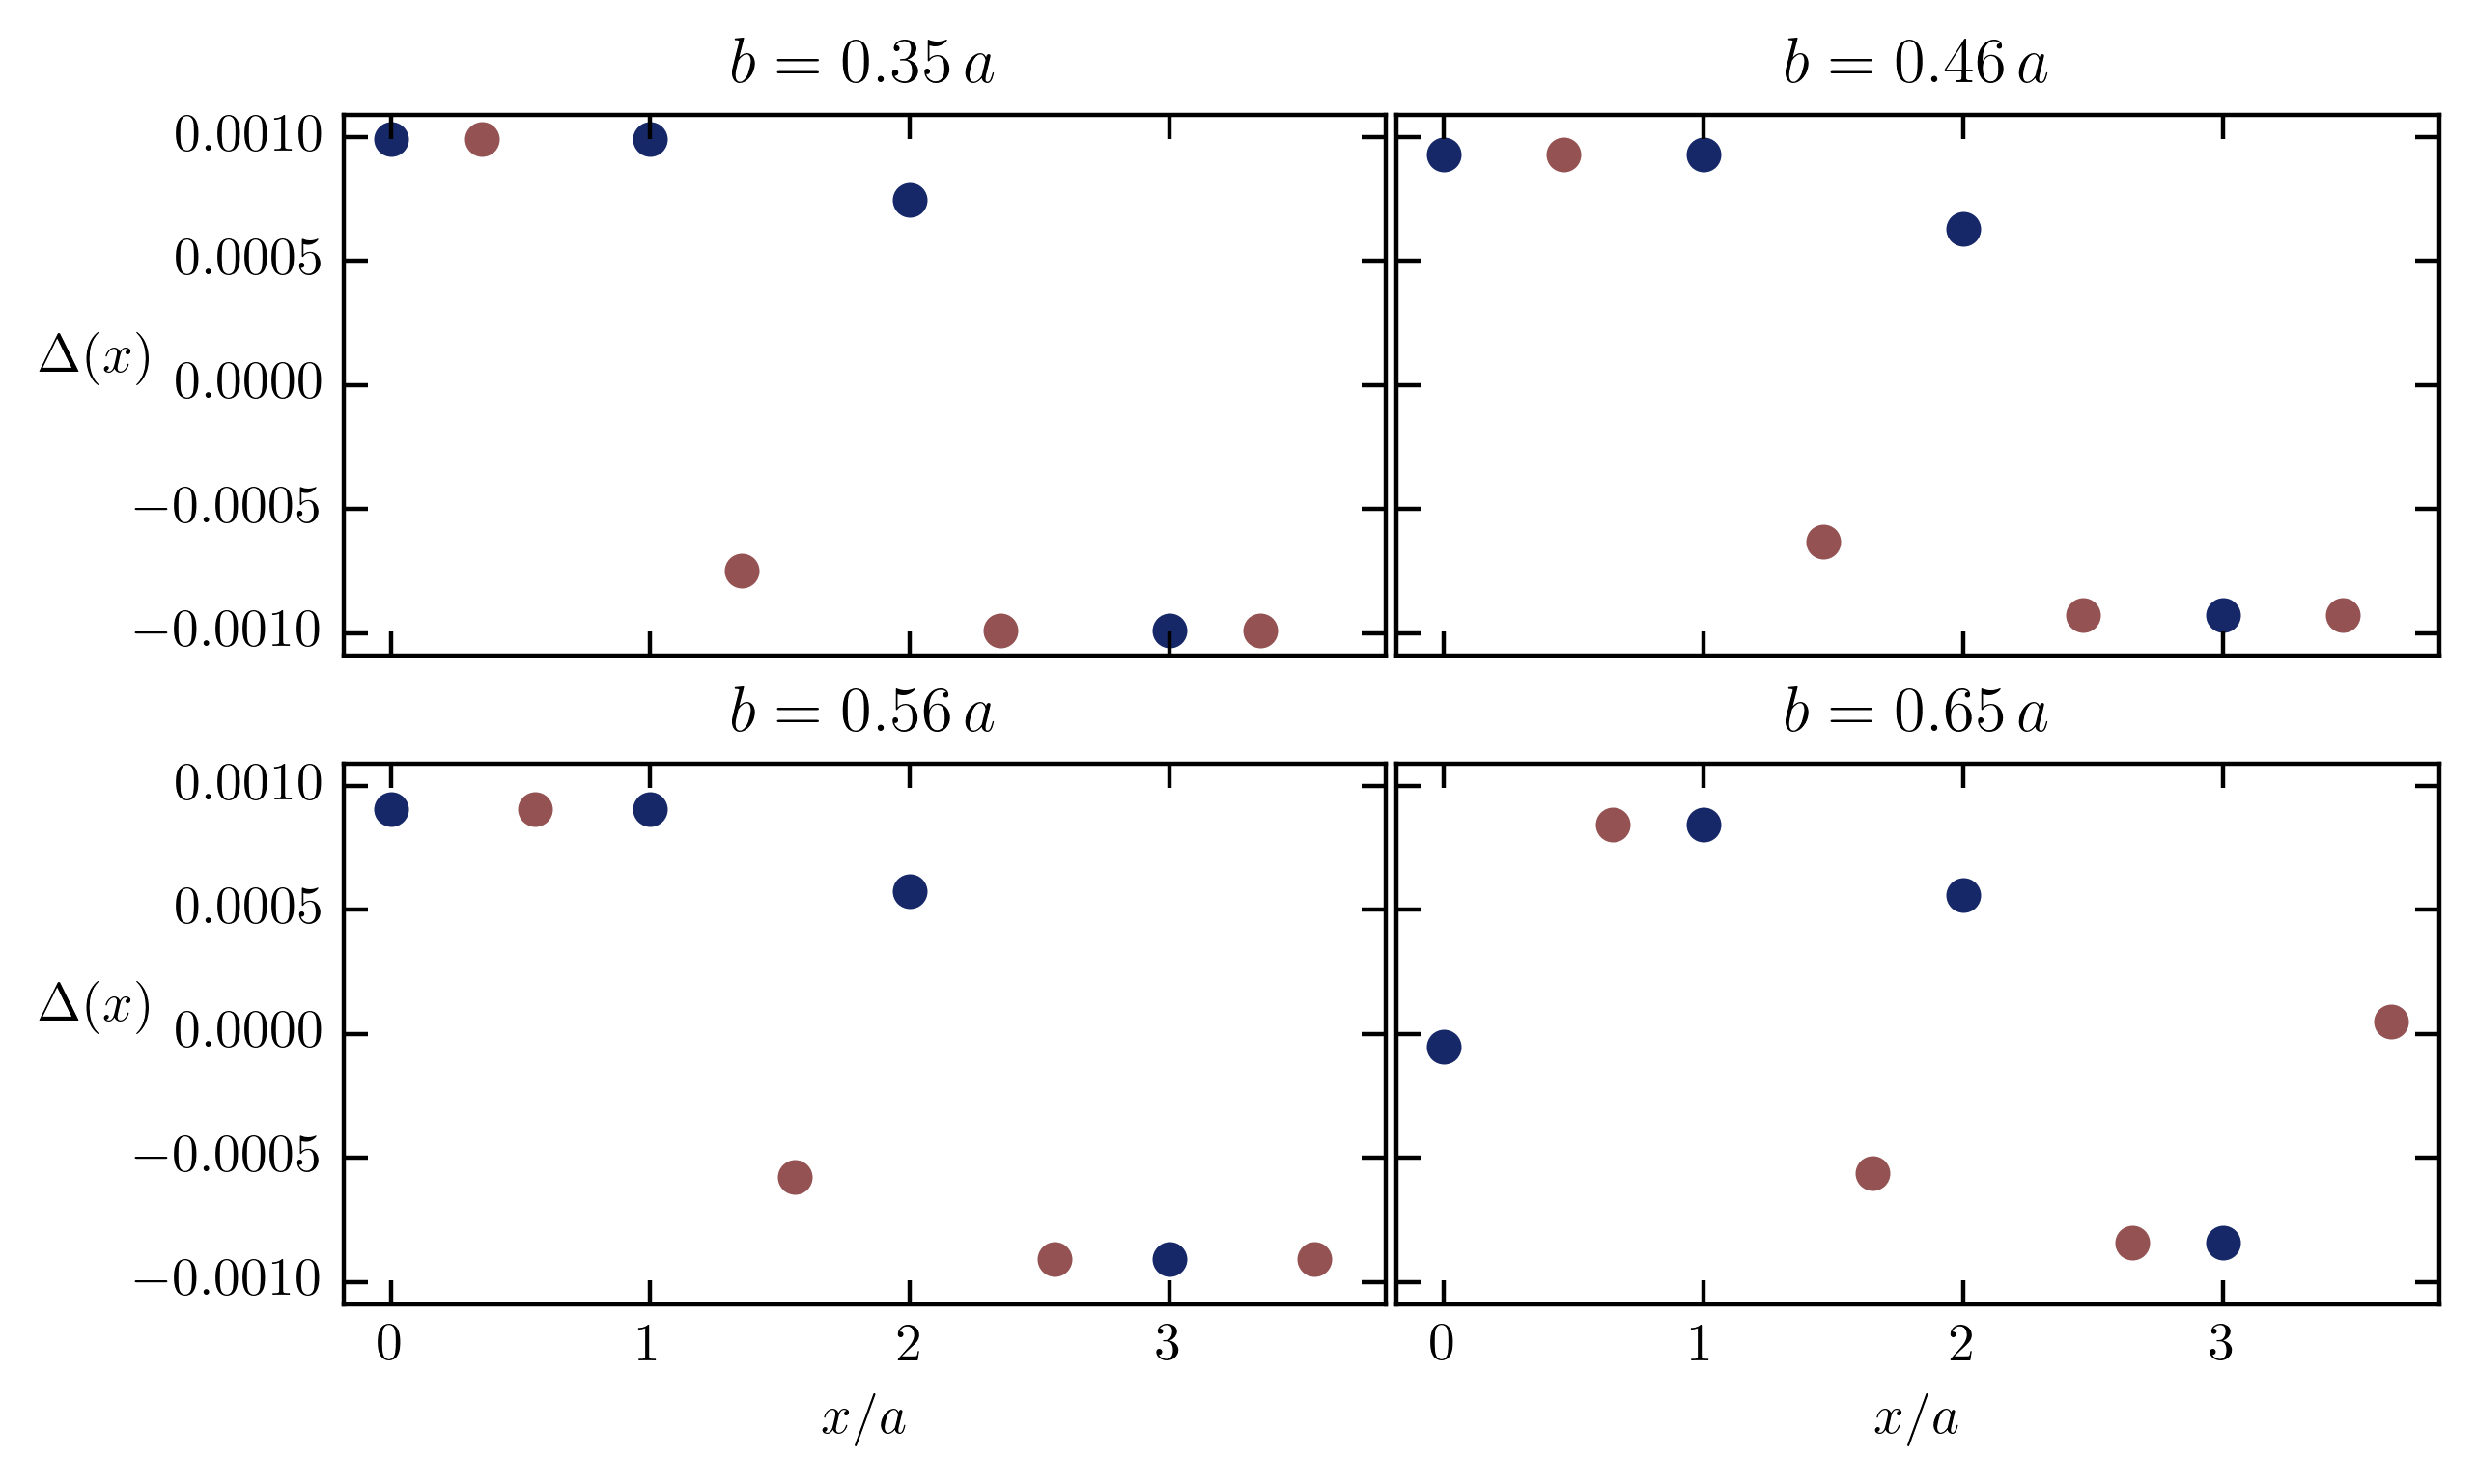

In [ ]:
# phis_plot = phis
# hs_plot = hs
l = 3
phis_plot = opt_param[l][0]
hs_plot = opt_param[l][1]
setup = Setup_Fig(name_of_plot='lam2_anal_ml.png',fig_width=7,fig_height=4,xax_share=True,yax_share=True)
# fig = plt.figure(figsize=(setup.fig_width,setup.fig_height))
# fig.tight_layout()
# gs = gridspec.GridSpec(2,4, figure=fig)
# ax0 = fig.add_subplot(gs[0,0])
# ax1 = fig.add_subplot(gs[0,1])
# ax2 = fig.add_subplot(gs[0,2])
# ax3 = fig.add_subplot(gs[0,3])
# ax4 = fig.add_subplot(gs[1,:2])
# ax5 = fig.add_subplot(gs[1,2:])
# ax6 = fig.add_subplot(gs[1,8:])
# fig, ax = setup.return_fig((1,2))
# fig2, ax3 = setup.return_fig((1,2))
# N = 30
pad = 7
fig, ax = setup.return_fig((2,2))
# fig, ax = plt.subplots(2,2,sharex=True,sharey=True)
# b = np.linspace(0.25,0.75,N)
# b = np.linspace(0.3,0.7,N)
n = 0
wrapper = [[],[]]
# fig2, ax2 = plt.subplots(1,1)
# for i in range(N):
#     dmat = hopping_Ham(b[i],hs[i],1,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis[i]),np.sin(phis[i])]))
    
#     beta = grad_long_range(b[i],hs[i],a,chain_length,nom_der1_vec,np.array([np.cos(phis[i]),np.sin(phis[i])]))
#     dis = np.linalg.solve(dmat,beta)
#     ax2.scatter(b[i],np.max(np.abs(dis)),s=10,color="0")
# for i in [0,9,20,29]:
for i in [0,7,13,19]:

    latticeA = np.stack((np.arange(chain_length//2+chain_length%2),np.zeros(chain_length//2+chain_length%2))).T * a
    latticeB = np.stack((np.arange(chain_length//2)*a+b[i],np.ones(chain_length//2)*hs_plot[i])).T  
    # fig, ax = plt.subplots(1,1)
    # dmat = hopping_Ham(b[i],hs[i],(m*w**2*r**2/V)[-1]/10**8,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis[i]),np.sin(phis[i])]))
    dmat = hopping_Ham(b[i],hs_plot[i],Deltas[l],a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis_plot[i]),np.sin(phis_plot[i])]))
    # bdg = BdG_Ham(b[i],hs[i],(m*w**2*r**2/V)[-1]/10**8,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis[i]),np.sin(phis[i])]))
    # eig = np.linalg.eigvals(dmat)
    # ax1.scatter(b[i],np.max(np.abs(np.real(eig))),color='0',s=10)
    
    
    beta = grad_long_range(b[i],hs_plot[i],a,chain_length,nom_der1_vec,np.array([np.cos(phis_plot[i]),np.sin(phis_plot[i])]))
    dis = np.linalg.solve(dmat,beta)
   
    ax[n//2,n%2].scatter(latticeA[:,0],dis[::2],color="#162868ff",s=30)
    ax[n//2,n%2].scatter(latticeB[:,0],dis[1::2],color="#945252ff",s=30)
    ax[n//2,n%2].set_title(r"$b={:.2f}\,a$".format(b[i]))
    wrapper[n//2].append(lambda k=n%2, s=n//2: setup.format_ax(ax[s,k],shape=(2,2),j=-int(k>0),set_ticks=False,bottom=s))
    
    ax[n//2,n%2] = wrapper[n//2][n%2]()
    n+=1
for i in range(2):
    ax[i,0].set_ylabel(r"$\Delta(x)$",rotation=0,labelpad=pad)
    ax[1,i].set_xlabel(r"$x/a$")
    
# ax4.text(0.02,0.88,"d)",fontsize=9,transform=ax4.transAxes)
# ax5.text(0.02,0.88,"e)",fontsize=9,transform=ax5.transAxes)
# ax1.text(0.06,0.87,"a)",fontsize=9,transform=ax1.transAxes)
# ax2.text(0.06,0.87,"b)",fontsize=9,transform=ax2.transAxes)
# ax3.text(0.06,0.87,"c)",fontsize=9,transform=ax3.transAxes)
plt.subplots_adjust(wspace=0.01,hspace=0.2)
plt.savefig("/home//christian/Documents/master/protocol/pictures/"+"Deltas4.pdf",bbox_inches='tight')#free_evol_1spto10coupling
plt.show()

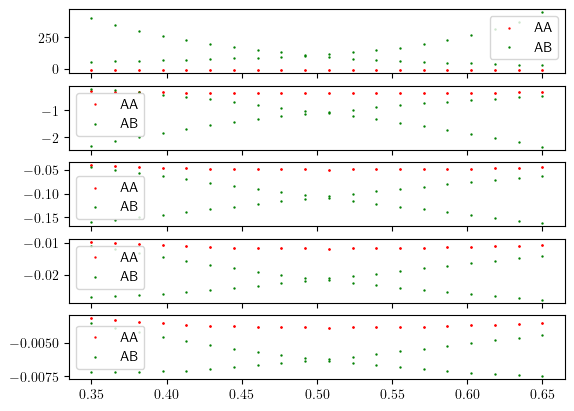

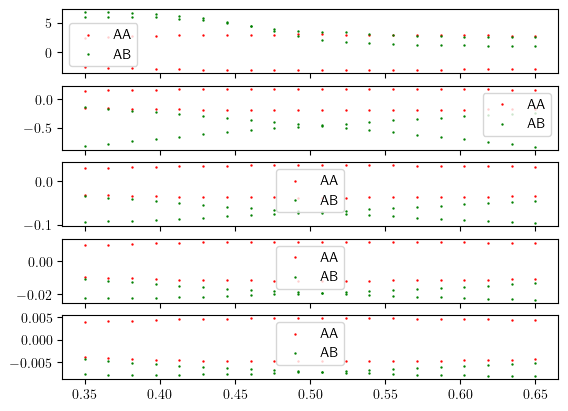

In [ ]:
int_range = 5
a=1
# N= 30
l = 10
phis_plot = opt_param[l][0]
hs_plot = opt_param[l][1]
def interactions(b,h,d,interaction):
    
    interAA = np.zeros((int_range,2))
    interAB = np.zeros_like(interAA)
    for i in range(int_range):
        distAB = np.array([[a*i+b,h],[(i+1)*a-b,-h]])
        distAA = np.array([[-a*(i+1),0],[a*(i+1),0]])
        interAA[i] = interaction(distAA,d)
        interAB[i] = interaction(distAB,d)
    return interAA, interAB
fig, ax = plt.subplots(int_range,1,sharex=True)
fig2, ax2 = plt.subplots(int_range,1,sharex=True)
for i in range(N):
    d= np.array([np.cos(phis_plot[i]),np.sin(phis_plot[i])])
    gradAA, gradAB = interactions(b[i],hs_plot[i],d,lambda x, y: dip_derivative_full_vec(x, y))
    hessAA, hessAB = interactions(b[i],hs_plot[i],d,nom_der1_vec)
    for n in range(int_range):
        ax[n].scatter([b[i]]*2,gradAA[n],color='red',label="AA")
        ax[n].scatter([b[i]]*2,gradAB[n],color='green',label="AB")
        ax2[n].scatter([b[i]]*2,hessAA[n],color='red',label="AA")
        ax2[n].scatter([b[i]]*2,hessAB[n],color='green',label="AB")
        if i ==0:
            ax[n].legend()
            ax2[n].legend()

plt.show()


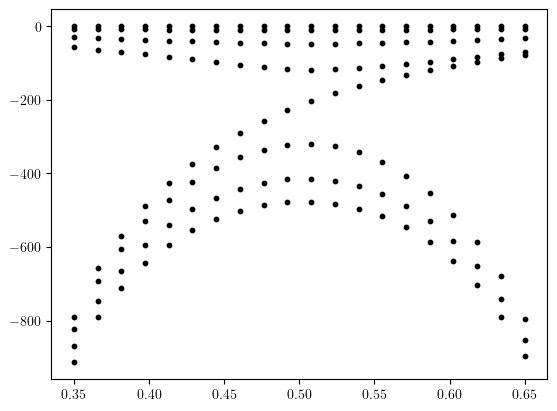

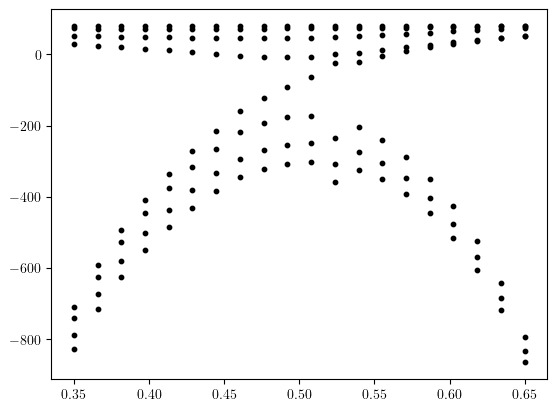

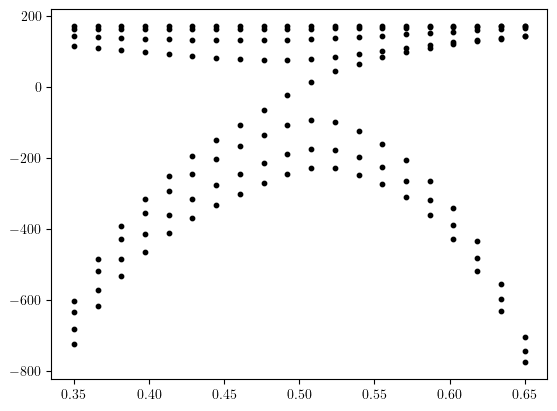

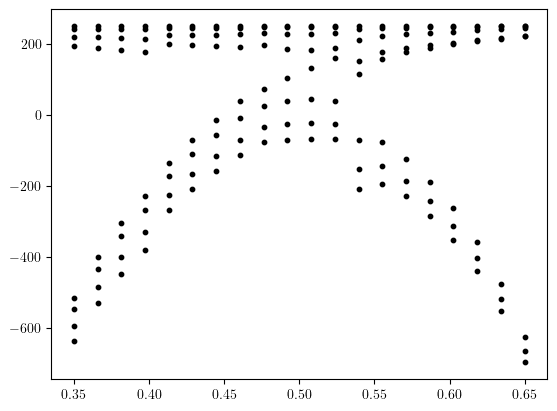

In [ ]:
for l in [0,6,13,19]:
    fig, ax = plt.subplots(1,1)
    phis_plot = opt_param[l][0]
    hs_plot = opt_param[l][1]
    eigenvals = np.zeros((N,chain_length))
    for i in range(N):
        # for n in range(chain_length//4):
            
            # dmat = hopping_Ham(b[i],hs[i],1,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis[i]),np.sin(phis[i])]))
            dmat = hopping_Ham(b[i],hs_plot[i],Deltas[l],a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis_plot[i]),np.sin(phis_plot[i])]))
            # print(np.round(dmat,0))
            # dmat = hopping_Ham_k(k,b[i],hs[i],(m*w**2*r**2/V)[-1]/10**8,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis[i]),np.sin(phis[i])]))
            eig = np.linalg.eigvals(dmat)
            eigenvals[i] = eig
            ax.scatter(b[i]*np.ones(len(eig)),eig,color="0",s=10)
    plt.show()

In [ ]:
def k_tranform(k,mat):
    T = np.stack([np.arange(mat.shape[0]//2)-i for i in range(mat.shape[0]//2)])
    print(T[mat.shape[0]//4])
    T= np.exp(-1j*T*k)
    dmat = np.zeros((2,2),dtype=np.complex128)
    for i in range(mat.shape[0]//2):
        i = mat.shape[0]//4
        dmat[0,0] += np.sum(mat[2*i,::2]*T[i])
        dmat[0,1] += np.sum(mat[2*i,1::2]*T[i])
        dmat[1,0] += np.sum(mat[2*i+1,::2]*T[i])
        dmat[1,1] += np.sum(mat[2*i+1,1::2]*T[i])
        break
    return dmat

chain_length = 8
i = chain_length//4
cell_list = [n for n in range(chain_length//2)]
k_tranform(0,np.zeros((8,8)))
unit_distAA = (np.array(cell_list[:i] +cell_list[i+1:])-i)*a
unit_distAB = (np.array(cell_list)-i)*a
np.concatenate((unit_distAA, unit_distAB))

[-2 -1  0  1]


array([-2, -1,  1, -2, -1,  0,  1])

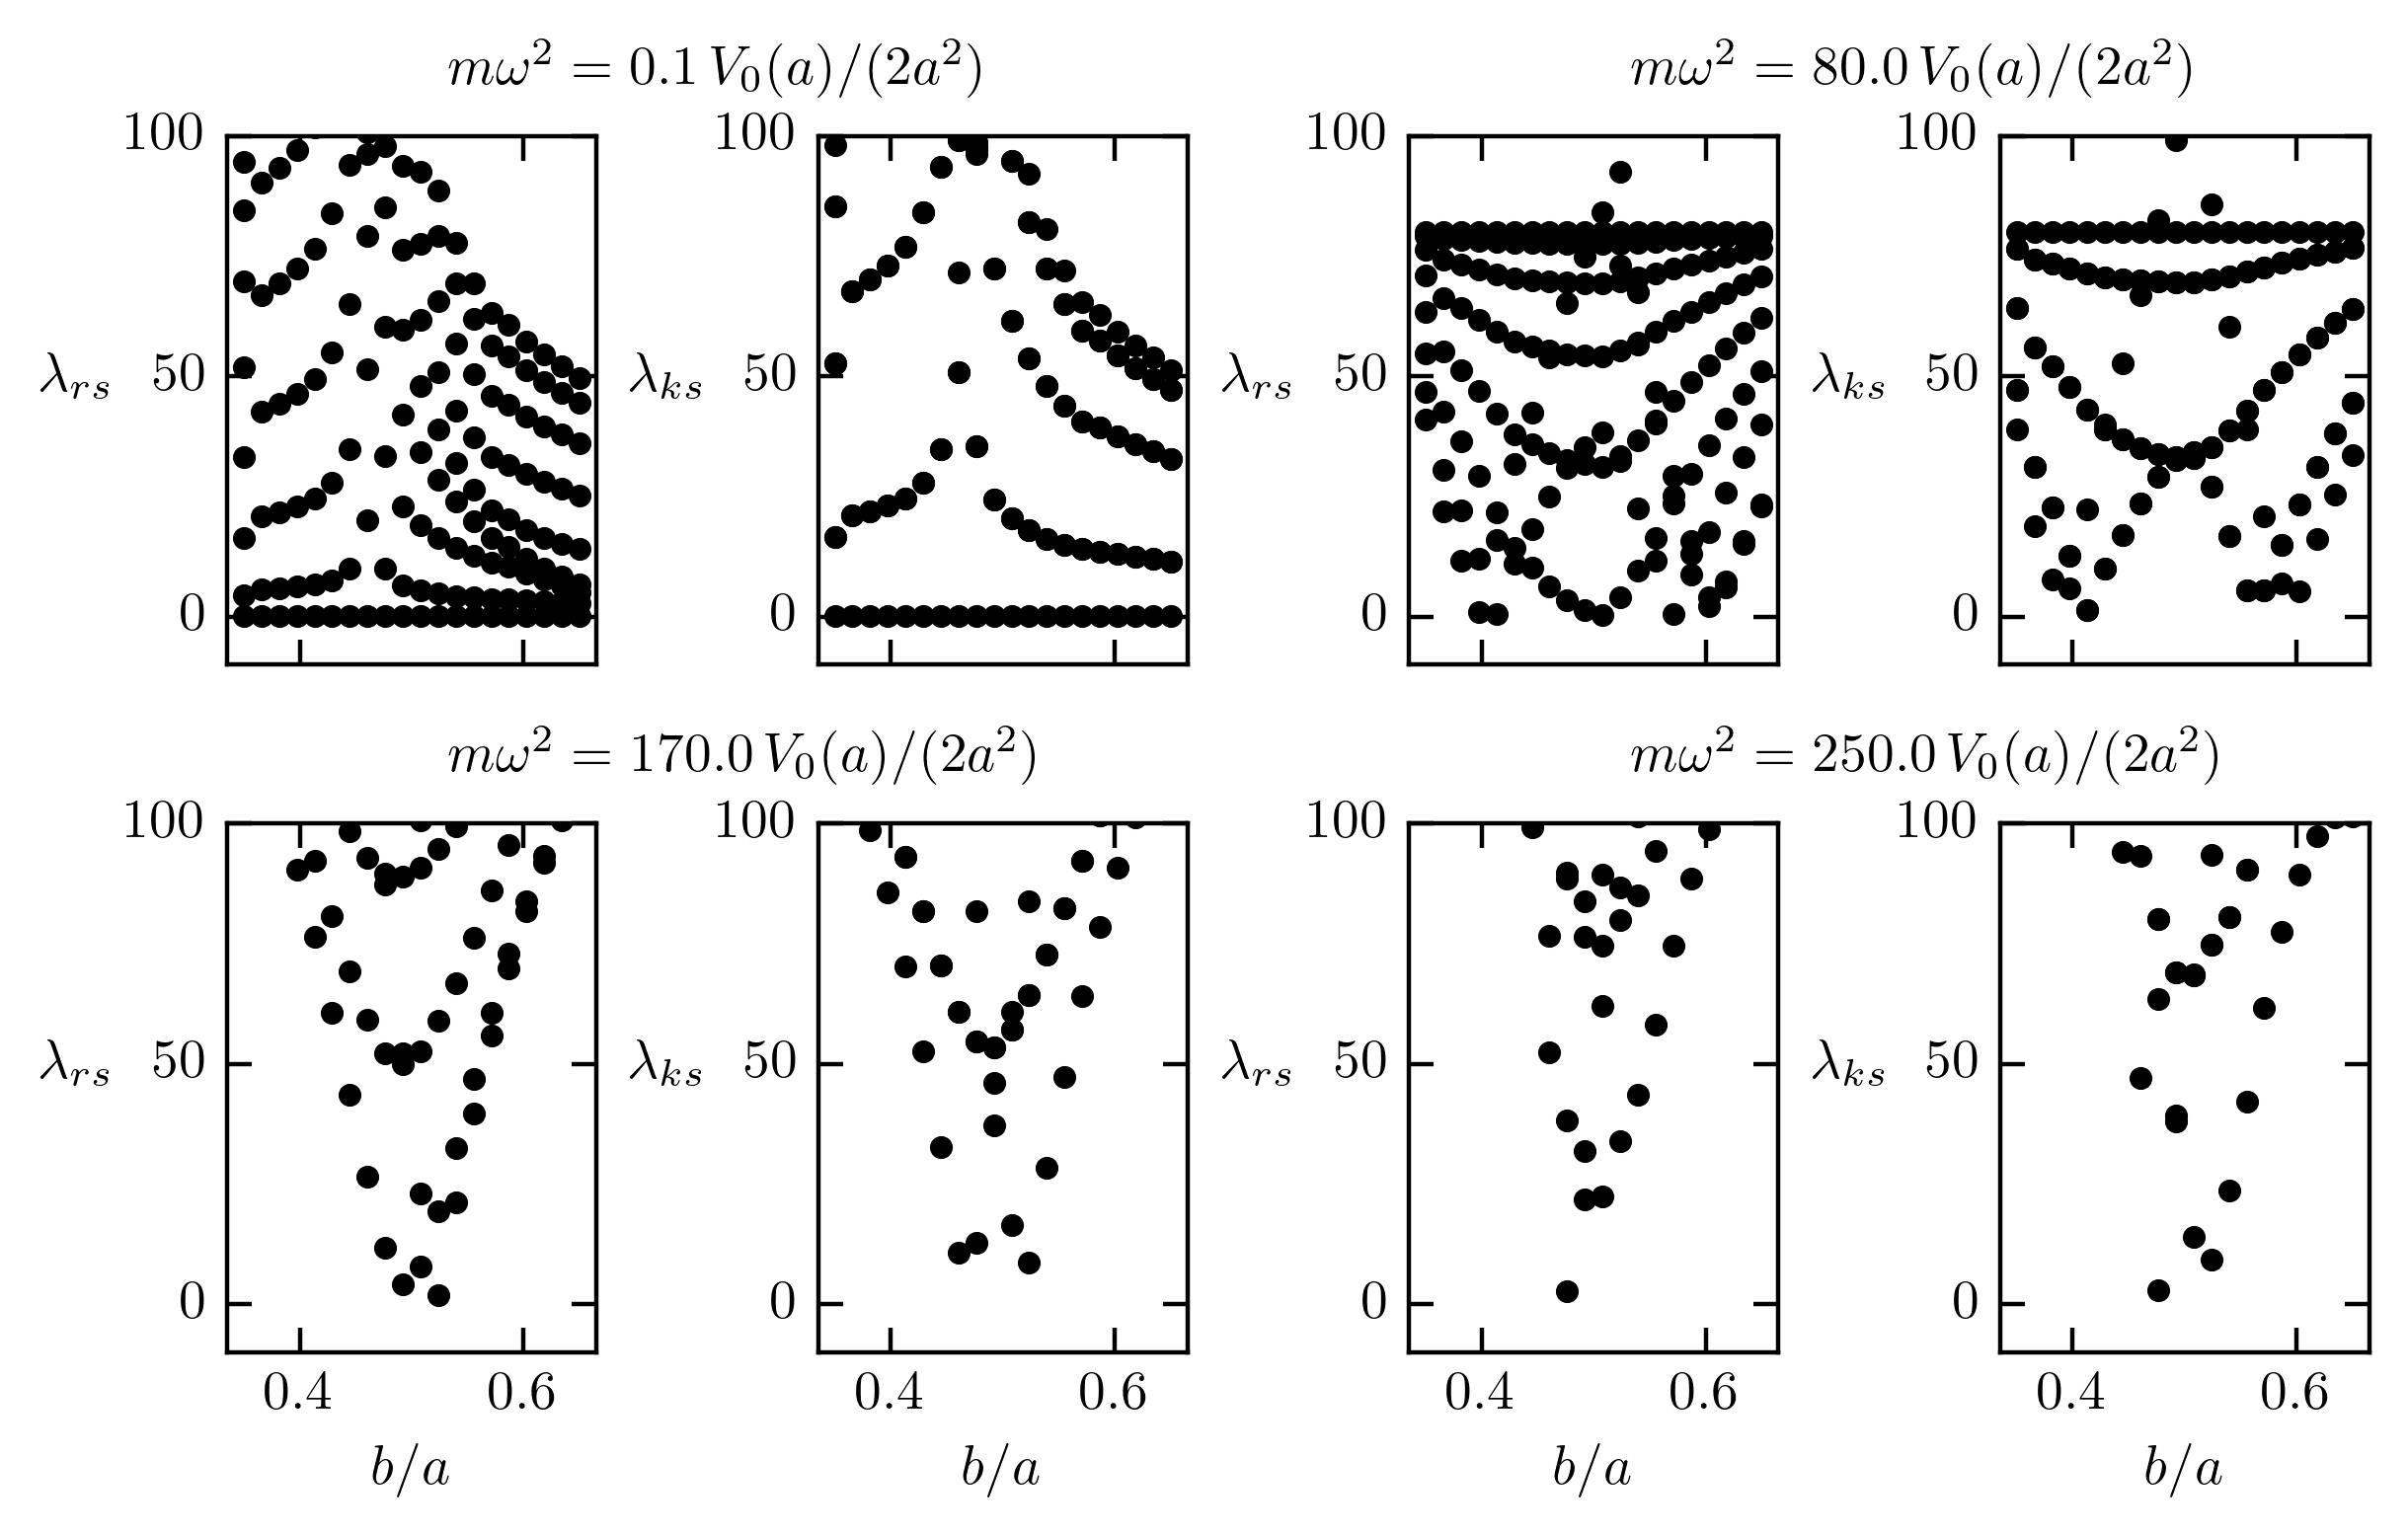

In [ ]:
setup = Setup_Fig(name_of_plot='lam2_anal_ml.png',fig_width=7,fig_height=4,xax_share=True,joined=False)
fig, ax = setup.return_fig((2,4))
marker_size = 3
b = np.linspace(0.35,0.65,N)
# fig2, ax2 = plt.subplots(1,1)
pad = 7
chain_length = 16
n=0
wrapper = [[],[],[]]
# for l in [0,6,13,19]:
for l in range(4):

    phis_plot = opt_param[l][0]
    hs_plot = opt_param[l][1]
    eigenvals = np.zeros((N,2*chain_length),dtype=np.complex128)
    for i in range(N):
        for m in range(chain_length//2):
            k = 2*np.pi*m/((chain_length//2)*a)-np.pi/a+2*np.pi/((chain_length//2)*a) 
            # k = 2*np.pi*n/((chain_length//2)*a)
            dmatk = hopping_Ham_k(k,b[i],hs_plot[i],Deltas[l],a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis_plot[i]),np.sin(phis_plot[i])]))
            # dmat = BdG_Ham_k(k,b[i],hs_plot[i],Deltas[l],a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis_plot[i]),np.sin(phis_plot[i])]))
            # dmat = hopping_Ham(b[i],hs_plot[i],Deltas[l],a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis_plot[i]),np.sin(phis_plot[i])]))
            # dmat = k_tranform(k,dmat)
            eigk = np.linalg.eigvals(dmatk)
            # eigenvals[i,2*n:2*(n+1)] = eig
            ax[n//2,2*(n%2)+1].scatter(b[i]*np.ones(len(eigk)),np.abs(eigk),color="0",s=10)
        
        dmat = hopping_Ham(b[i],hs_plot[i],Deltas[l],a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis_plot[i]),np.sin(phis_plot[i])]))
        eig = np.linalg.eigvals(dmat)
            # eigenvals[i,2*n:2*(n+1)] = eig
        ax[n//2,2*(n%2)].scatter(b[i]*np.ones(len(eig)),np.abs(eig),color="0",s=10)
            
            
    wrapper[n//2].append(lambda k=2*(n%2), s=n//2: setup.format_ax(ax[s,k],shape=(2,4),j=int(k>0),set_ticks=False,bottom=s))
    wrapper[n//2].append(lambda k=2*(n%2)+1, s=n//2: setup.format_ax(ax[s,k],shape=(2,4),j=int(k>0),set_ticks=False,bottom=s))
    
    
    ax[n//2,2*(n%2)] = wrapper[n//2][2*(n%2)]()
    ax[n//2,2*(n%2)+1] = wrapper[n//2][2*(n%2)+1]()
    
    ax[n//2,2*(n%2)].text(0.6,1.1,r"$m\omega^2={:.1f}\,V_0(a)/(2a^2)$".format(Deltas[l]),transform=ax[n//2,2*(n%2)].transAxes)
    ax[n//2,2*(n%2)].set_ylabel(r"$\lambda_{rs}$",rotation=0,labelpad=9)
    ax[n//2,2*(n%2)+1].set_ylabel(r"$\lambda_{ks}$",rotation=0,labelpad=9)
    ax[1,n].set_xlabel(r"$b/a$")
    ax[1,n].set_ylim(-10,100)
    ax[0,n].set_ylim(-10,100)
    n +=1
# ax[2,0].set_yticks([0,0.1,0.2])
plt.subplots_adjust(wspace=0.6,hspace=0.3)
# plt.savefig("/home//christian/Documents/master/protocol/pictures/"+"spectrum_U_r_and_k_space.pdf",bbox_inches='tight')#free_evol_1spto10coupling
plt.show()

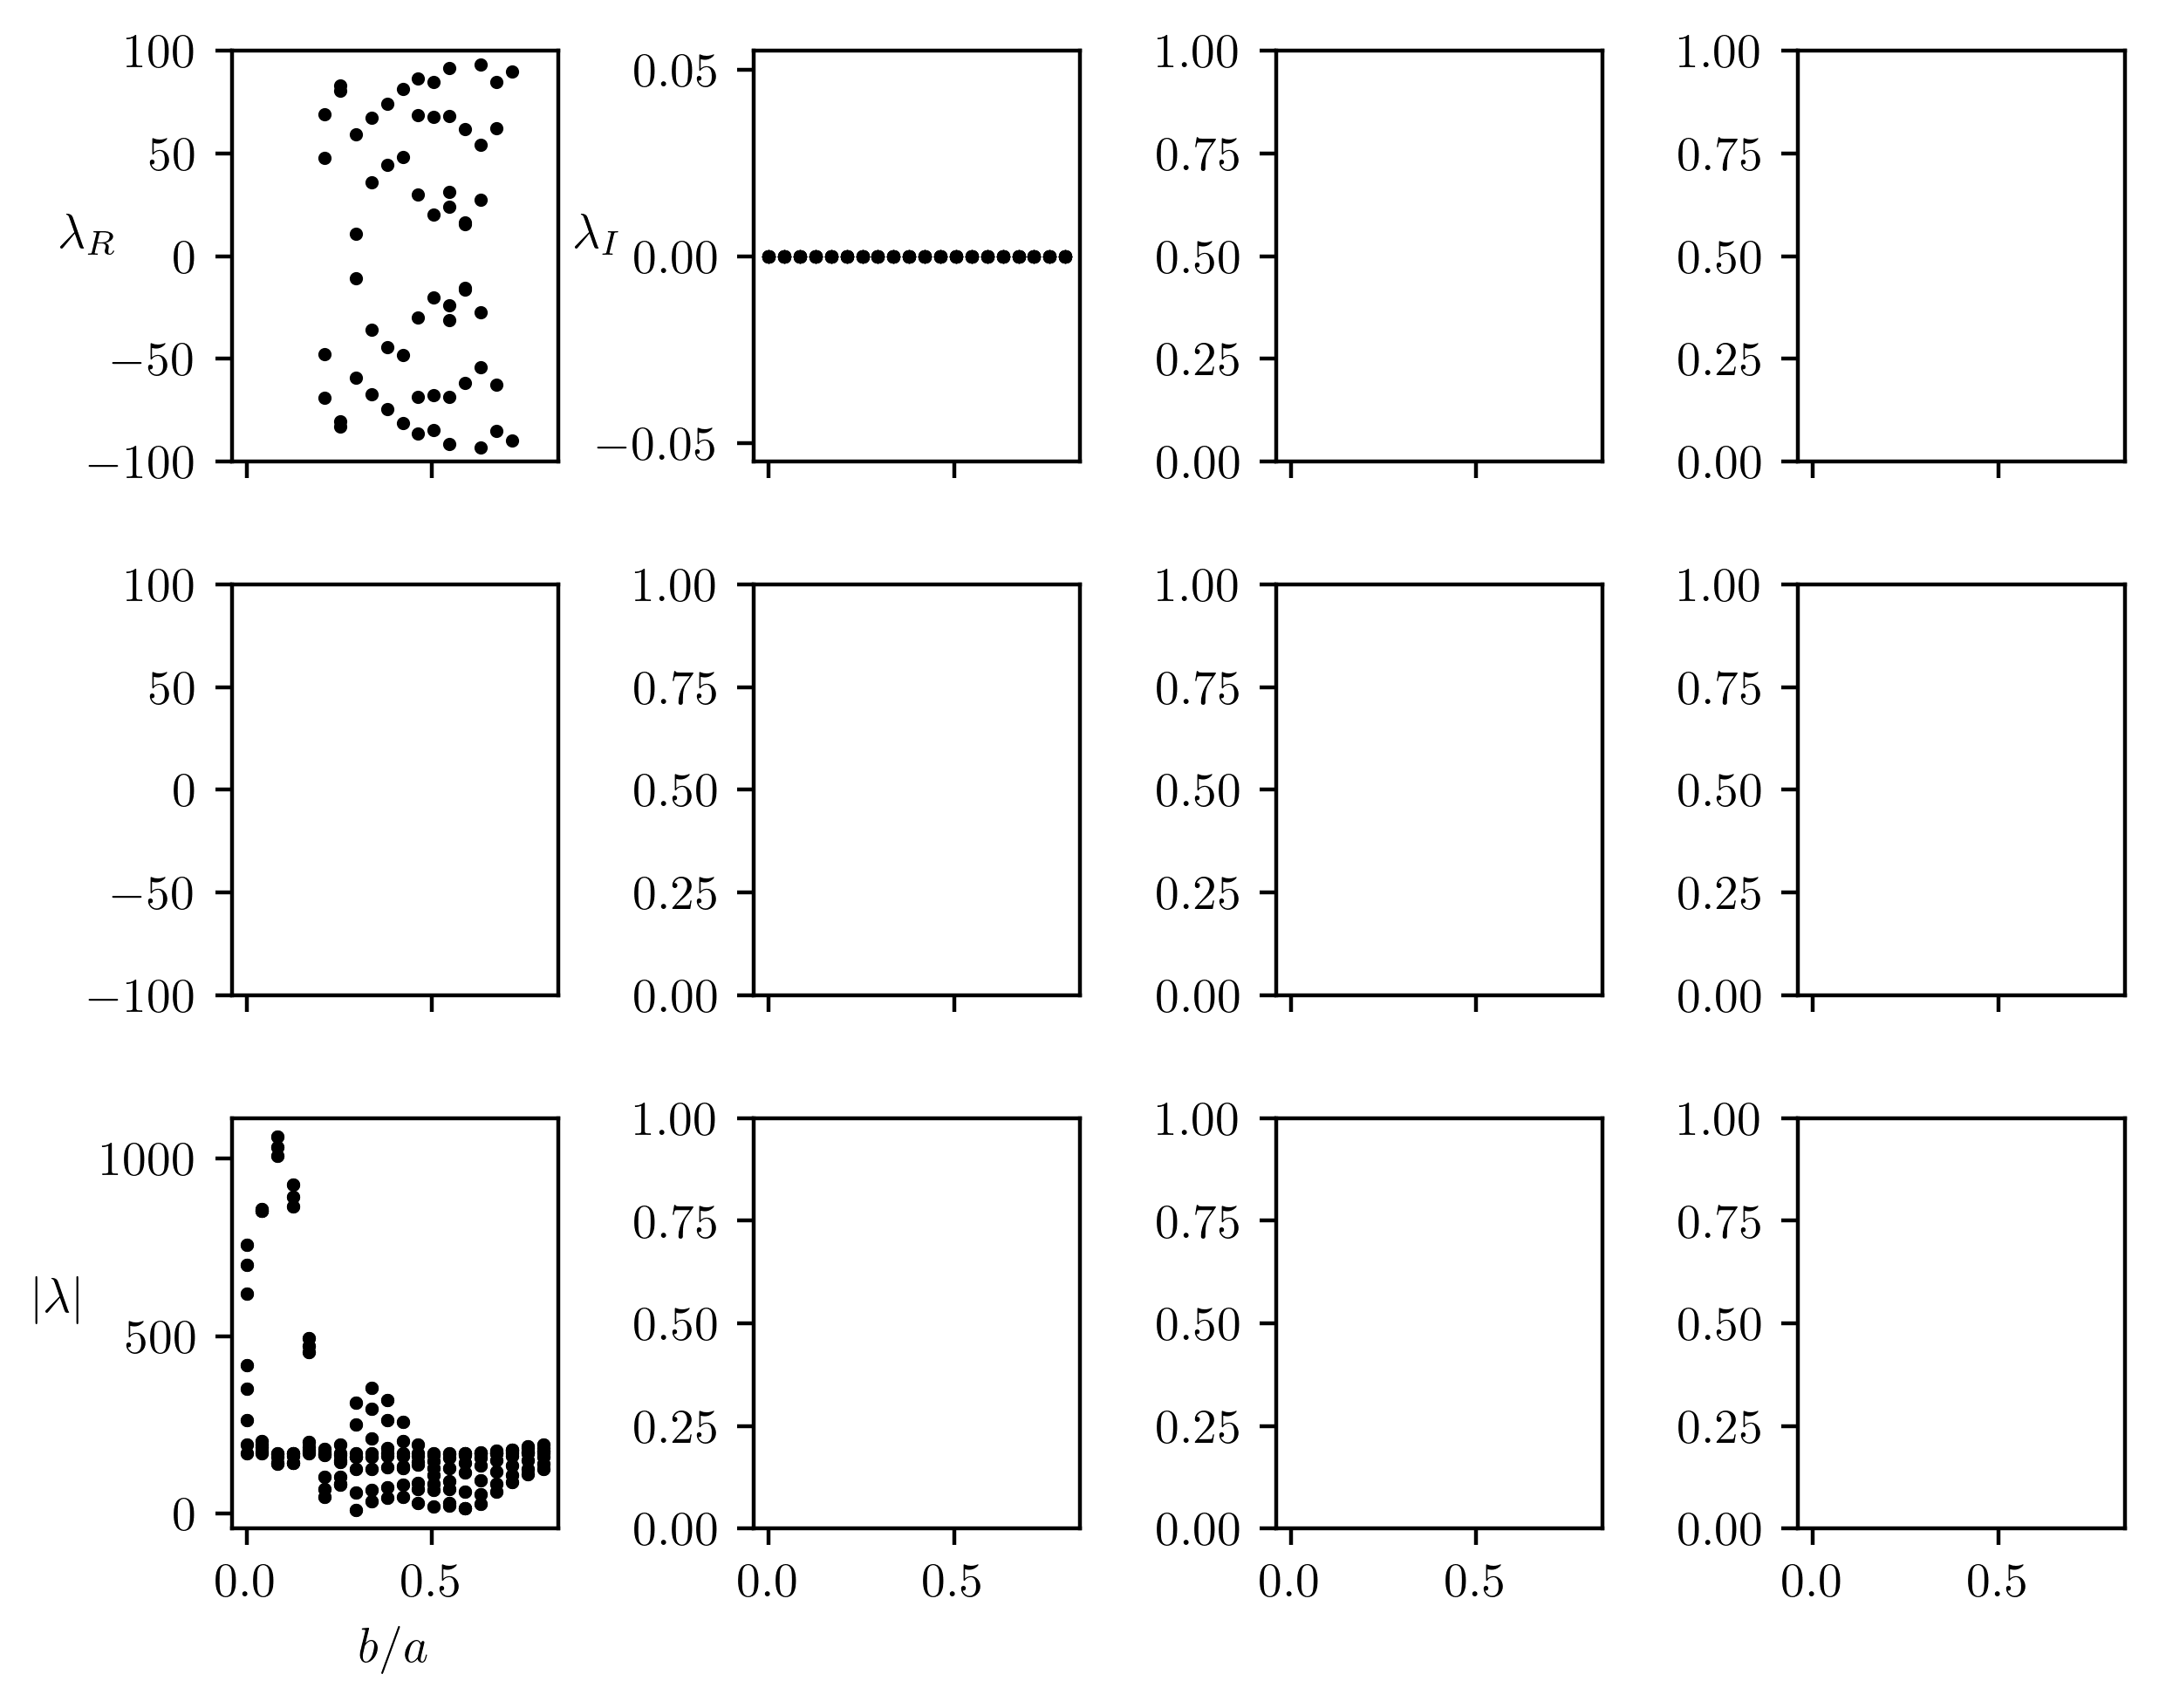

In [ ]:
# fig, ax = plt.subplots(1,1)
# fig, ax = plt.subplots(3,4,sharex=True)
setup = Setup_Fig(name_of_plot='lam2_anal_ml.png',fig_width=7,fig_height=5.5,xax_share=True,joined=False)
fig, ax = setup.return_fig((3,4))

# fig2, ax2 = plt.subplots(1,1)
pad = 7
chain_length = 8
n=0

    
phis_plot = phis
hs_plot = hs
eigenvals = np.zeros((N,2*chain_length),dtype=np.complex128)
for i in range(N):
    # for n in range(chain_length//4):
        
        # dmat = hopping_Ham(b[i],hs[i],1,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis[i]),np.sin(phis[i])]))
        dmat = BdG_Ham(b[11],hs_plot[i],170,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis_plot[i]),np.sin(phis_plot[i])]))
        # dmat = hopping_Ham_k(k,b[i],hs[i],(m*w**2*r**2/V)[-1]/10**8,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis[i]),np.sin(phis[i])]))
        eig = np.linalg.eigvals(dmat)
        eigenvals[i] = eig
        
        marker_size = 3
        ax[2,n].scatter(hs[i]*np.ones(len(eig)),np.real(np.abs(eig)),color="0",s=marker_size)
        ax[n//2,2*(n%2)].scatter(hs[i]*np.ones(len(eig)),np.real(eig),color="0",s=marker_size)
        ax[n//2,2*(n%2)+1].scatter(hs[i]*np.ones(len(eig)),np.imag(eig),color="0",s=marker_size)
# wrapper[n//2].append(lambda k=2*(n%2), s=n//2: setup.format_ax(ax[s,k],shape=(3,4),j=int(k>0),set_ticks=False,bottom=0))
# wrapper[n//2].append(lambda k=2*(n%2)+1, s=n//2: setup.format_ax(ax[s,k],shape=(3,4),j=int(k>0),set_ticks=False,bottom=0))
# wrapper[2].append(lambda k=n, s=2: setup.format_ax(ax[s,k],shape=(3,4),j=int(k>0),set_ticks=False,bottom=s))

# ax[n//2,2*(n%2)] = wrapper[n//2][2*(n%2)]()
# ax[n//2,2*(n%2)+1] = wrapper[n//2][2*(n%2)+1]()
# ax[2,n] = wrapper[2][n]()
# ax[n//2,2*(n%2)].text(0.6,1.1,r"$m\omega^2={:.1f}\,V_0(a)/(2a^2)$".format(Deltas[l]),transform=ax[n//2,2*(n%2)].transAxes)
# ax[2,n].text(-0.08,1.1,r"$m\omega^2={:.1f}\,V_0(a)/(2a^2)$".format(Deltas[l]),transform=ax[2,n].transAxes,fontsize=7)
ax[n//2,2*(n%2)].set_ylabel(r"$\lambda_R$",rotation=0,labelpad=0)
ax[n//2,2*(n%2)+1].set_ylabel(r"$\lambda_I$",rotation=0,labelpad=0)
ax[2,n].set_ylabel(r"$|\lambda|$",rotation=0,labelpad=8)
ax[2,n].set_xlabel(r"$b/a$")
ax[0,n].set_ylim(-100,100)
ax[1,n].set_ylim(-100,100)
n +=1
min_ind = np.argmin(np.min(np.abs(eigenvals),axis=1))
# print(Deltas[l],min_ind,b[min_ind])
# ax[2,0].set_yticks([0,0.1,0.2])
plt.subplots_adjust(wspace=0.6,hspace=0.3)
# plt.savefig("/home//christian/Documents/master/protocol/pictures/"+"spectrum_abs_of_tuned_BdG_various_shift.pdf",bbox_inches='tight')#free_evol_1spto10coupling
plt.show()

2.5 3 0.3973684210526316
200.0 9 0.4921052631578947
1000 3 0.3973684210526316
2500 19 0.65


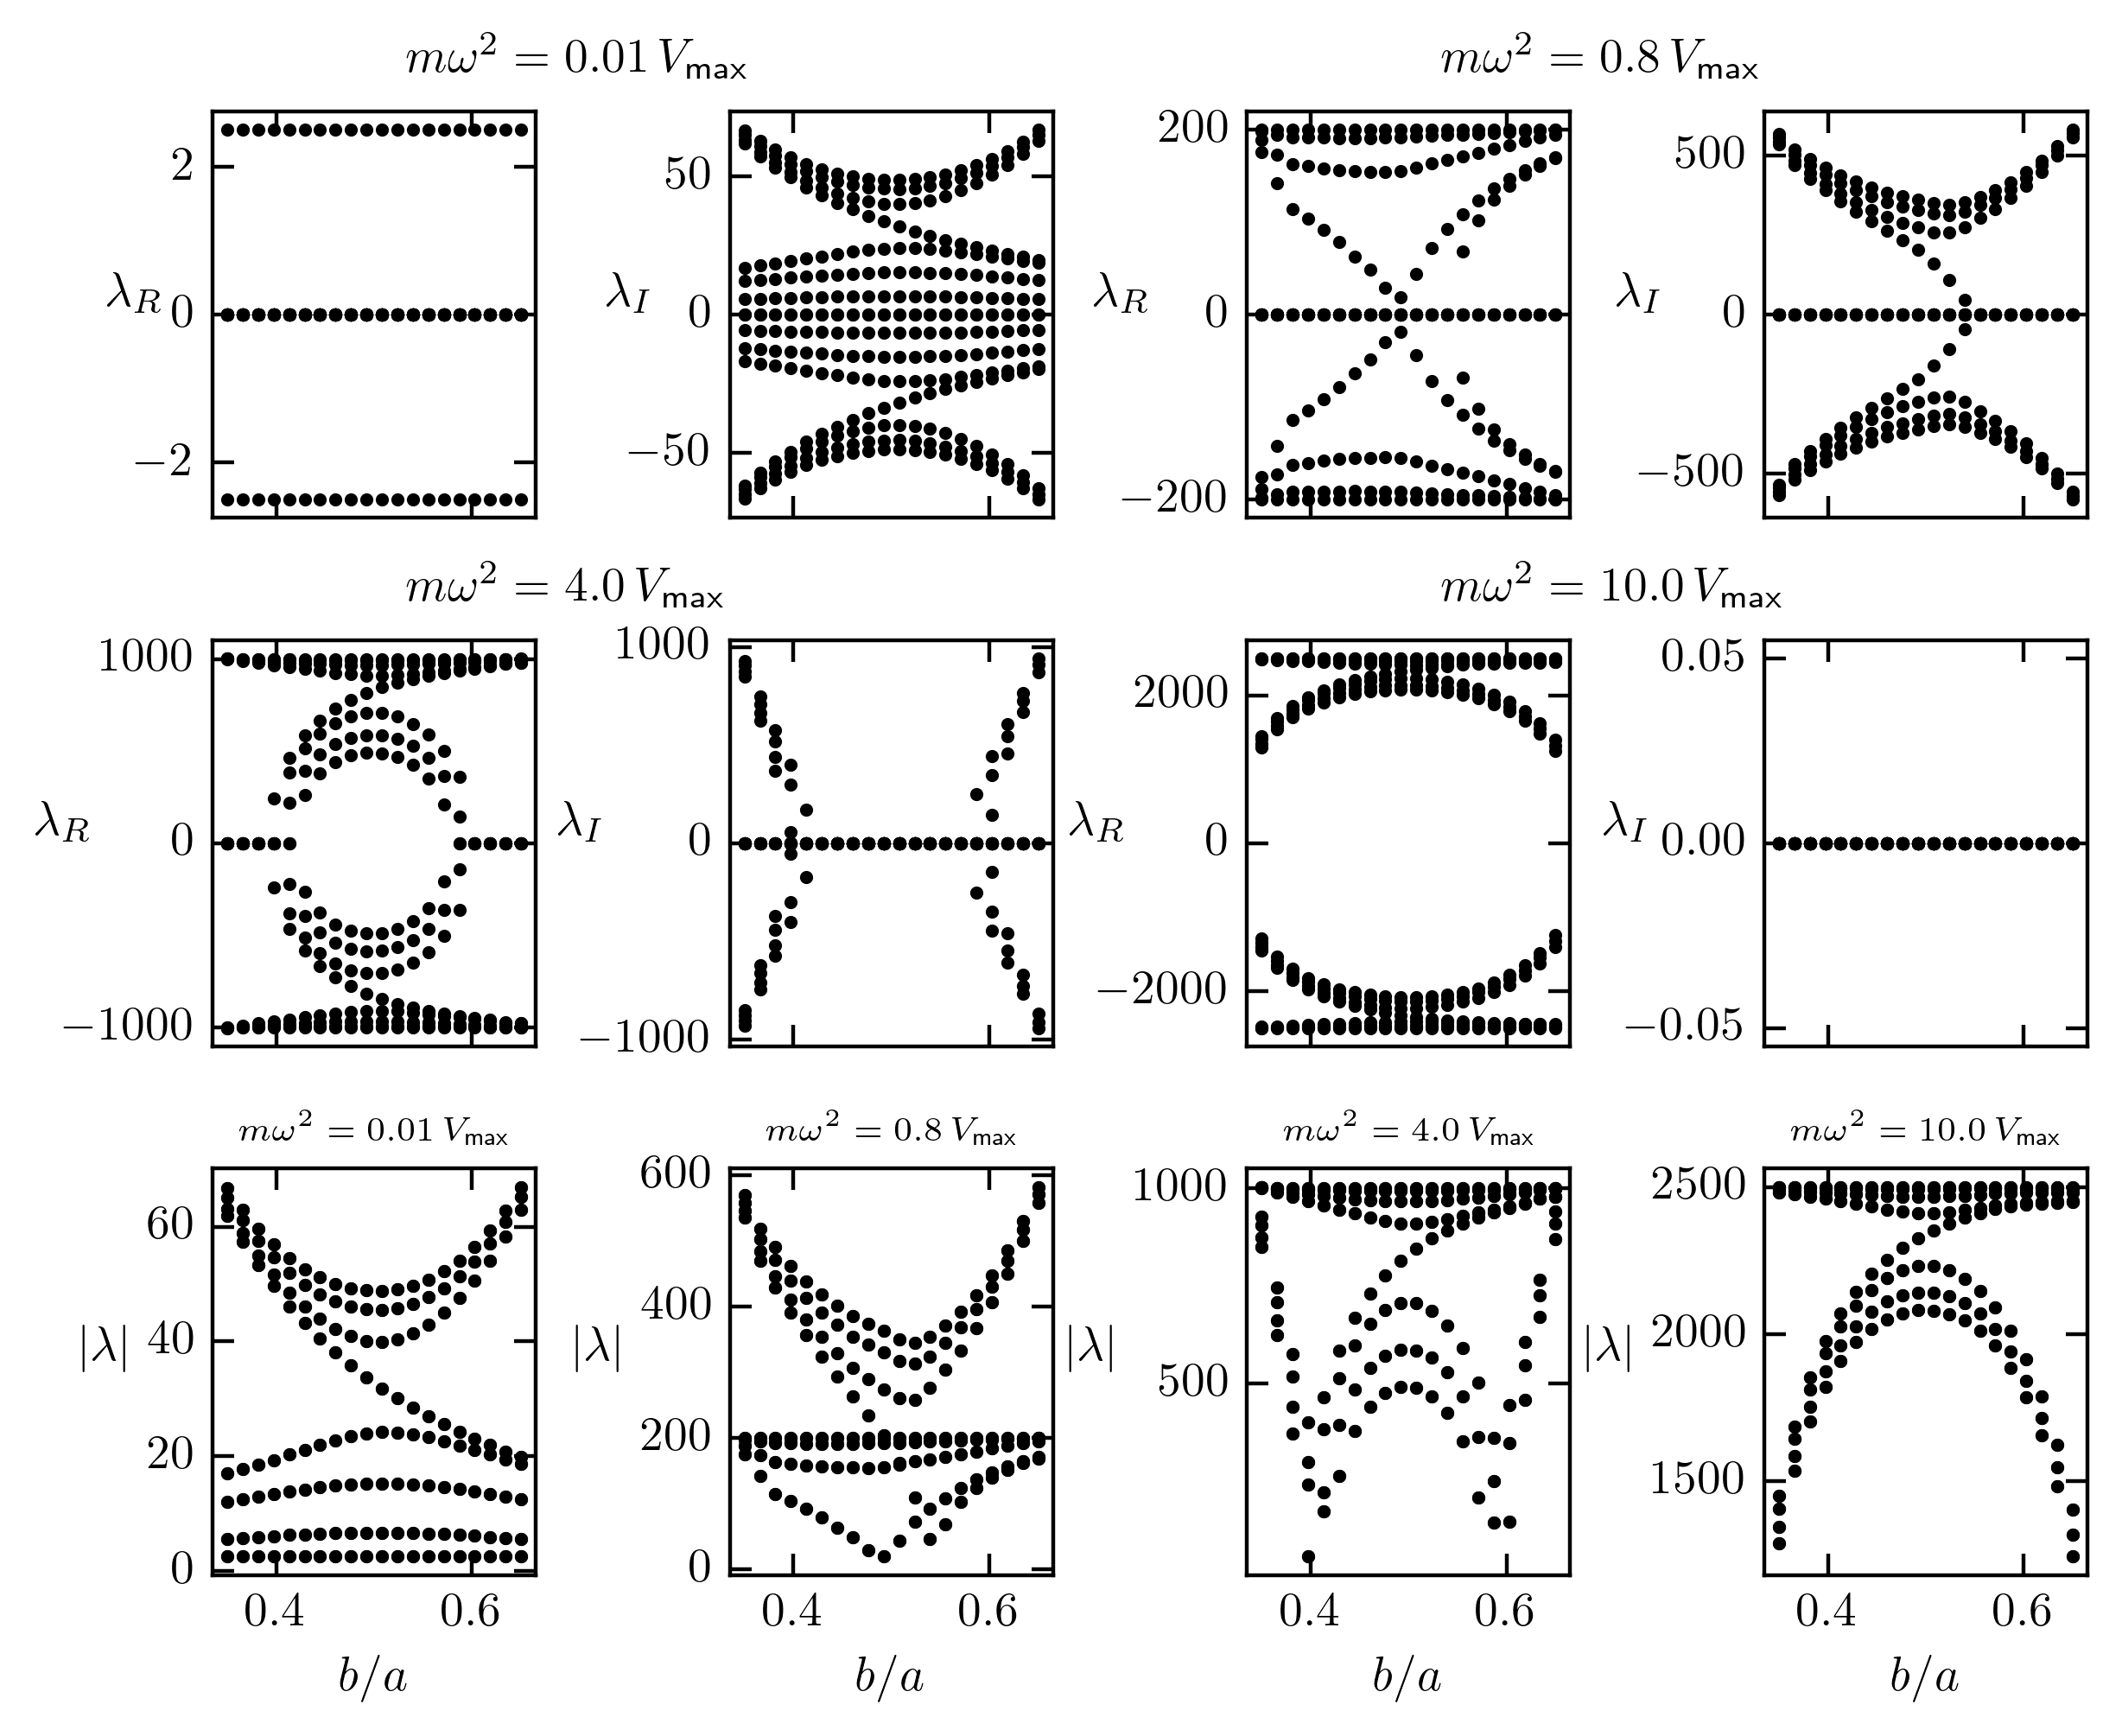

In [ ]:
# fig, ax = plt.subplots(1,1)
# fig, ax = plt.subplots(3,4,sharex=True)
setup = Setup_Fig(name_of_plot='lam2_anal_ml.png',fig_width=7,fig_height=5.5,xax_share=True)
fig, ax = setup.return_fig((3,4))

# fig2, ax2 = plt.subplots(1,1)
pad = 7
chain_length = 8
n=0
wrapper = [[],[],[]]
# for l in [0,6,13,19]:
for l in range(4):
    
    phis_plot = opt_param[l][0]
    hs_plot = opt_param[l][1]
    eigenvals = np.zeros((N,2*chain_length),dtype=np.complex128)
    for i in range(N):
    # for i in range(7,14):
        # for n in range(chain_length//4):
            
            # dmat = hopping_Ham(b[i],hs[i],1,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis[i]),np.sin(phis[i])]))
            dmat = BdG_Ham(b[i],hs_plot[i],Deltas[l],a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis_plot[i]),np.sin(phis_plot[i])]))
            # dmat = hopping_Ham_k(k,b[i],hs[i],(m*w**2*r**2/V)[-1]/10**8,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis[i]),np.sin(phis[i])]))
            eig = np.linalg.eigvals(dmat)
            eigenvals[i] = eig
            
            marker_size = 3
            ax[2,n].scatter(b[i]*np.ones(len(eig)),np.real(np.abs(eig)),color="0",s=marker_size)
            ax[n//2,2*(n%2)].scatter(b[i]*np.ones(len(eig)),np.real(eig),color="0",s=marker_size)
            ax[n//2,2*(n%2)+1].scatter(b[i]*np.ones(len(eig)),np.imag(eig),color="0",s=marker_size)
    wrapper[n//2].append(lambda k=2*(n%2), s=n//2: setup.format_ax(ax[s,k],shape=(3,4),j=int(k>0),set_ticks=False,bottom=0))
    wrapper[n//2].append(lambda k=2*(n%2)+1, s=n//2: setup.format_ax(ax[s,k],shape=(3,4),j=int(k>0),set_ticks=False,bottom=0))
    wrapper[2].append(lambda k=n, s=2: setup.format_ax(ax[s,k],shape=(3,4),j=int(k>0),set_ticks=False,bottom=s))
    
    ax[n//2,2*(n%2)] = wrapper[n//2][2*(n%2)]()
    ax[n//2,2*(n%2)+1] = wrapper[n//2][2*(n%2)+1]()
    ax[2,n] = wrapper[2][n]()
    ax[n//2,2*(n%2)].text(0.6,1.1,r"$m\omega^2={}$".format(Deltas[l]/250)+r"$\,V_\text{max}$",transform=ax[n//2,2*(n%2)].transAxes)
    ax[2,n].set_title(r"$m\omega^2={}$".format(Deltas[l]/250)+r"$\,V_\text{max}$",fontsize=7)
    ax[n//2,2*(n%2)].set_ylabel(r"$\lambda_R$",rotation=0,labelpad=0)
    ax[n//2,2*(n%2)+1].set_ylabel(r"$\lambda_I$",rotation=0,labelpad=0)
    ax[2,n].set_ylabel(r"$|\lambda|$",rotation=0,labelpad=8)
    ax[2,n].set_xlabel(r"$b/a$")
    # ax[0,n].set_ylim(-100,100)
    # ax[1,n].set_ylim(-100,100)
    n +=1
    min_ind = np.argmin(np.min(np.abs(eigenvals),axis=1))
    print(Deltas[l],min_ind,b[min_ind])
# ax[2,0].set_yticks([0,0.1,0.2])
plt.subplots_adjust(wspace=0.6,hspace=0.3)
# plt.savefig("/home//christian/Documents/master/protocol/pictures/"+"spectrum_abs_of_tuned_BdG_various_shift_opt.pdf",bbox_inches='tight')#free_evol_1spto10coupling
plt.show()

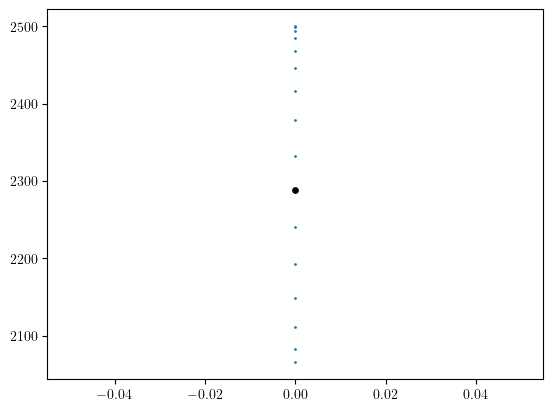

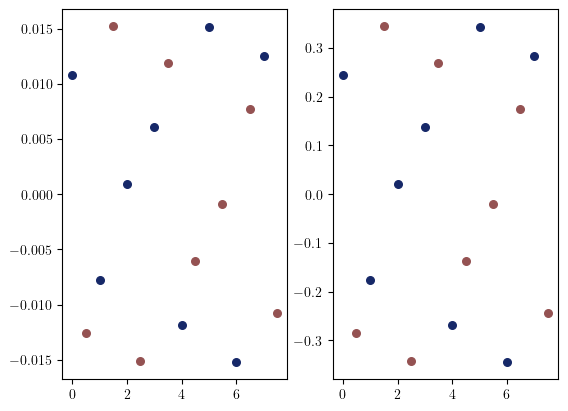

In [ ]:
phis_plot = opt_param[l][0]
hs_plot = opt_param[l][1]
chain_length = 16
i = 9
    # for n in range(chain_length//4):
        
        # dmat = hopping_Ham(b[i],hs[i],1,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis[i]),np.sin(phis[i])]))
dmat = BdG_Ham(b[i],hs_plot[i],Deltas[l],a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis_plot[i]),np.sin(phis_plot[i])]))
# dmat = hopping_Ham_k(k,b[i],hs[i],(m*w**2*r**2/V)[-1]/10**8,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis[i]),np.sin(phis[i])]))
eig, vecs = np.linalg.eig(dmat)
eigenvecs = sort_eigenvalues(eig, vecs)
latticeA = np.stack((np.arange(chain_length//2+chain_length%2),np.zeros(chain_length//2+chain_length%2))).T * a
latticeB = np.stack((np.arange(chain_length//2)*a+b[i],np.ones(chain_length//2)*hs_plot[i])).T  
j =12
fig , ax = plt.subplots(1,1)
ax.scatter(np.zeros(len(eig)),np.abs(eig))
ax.scatter(0,np.abs(eigenvecs[j,0]),s=15,color='0')
plt.show

fig , ax = plt.subplots(1,2)
ax[0].scatter(latticeA[:,0],eigenvecs[j,1:chain_length+1:2],color="#162868ff",s=30)
ax[0].scatter(latticeB[:,0],eigenvecs[j,2:chain_length+1:2],color="#945252ff",s=30)
ax[1].scatter(latticeA[:,0],eigenvecs[j,chain_length+1::2],color="#162868ff",s=30)
ax[1].scatter(latticeB[:,0],eigenvecs[j,chain_length+2::2],color="#945252ff",s=30)
plt.show()

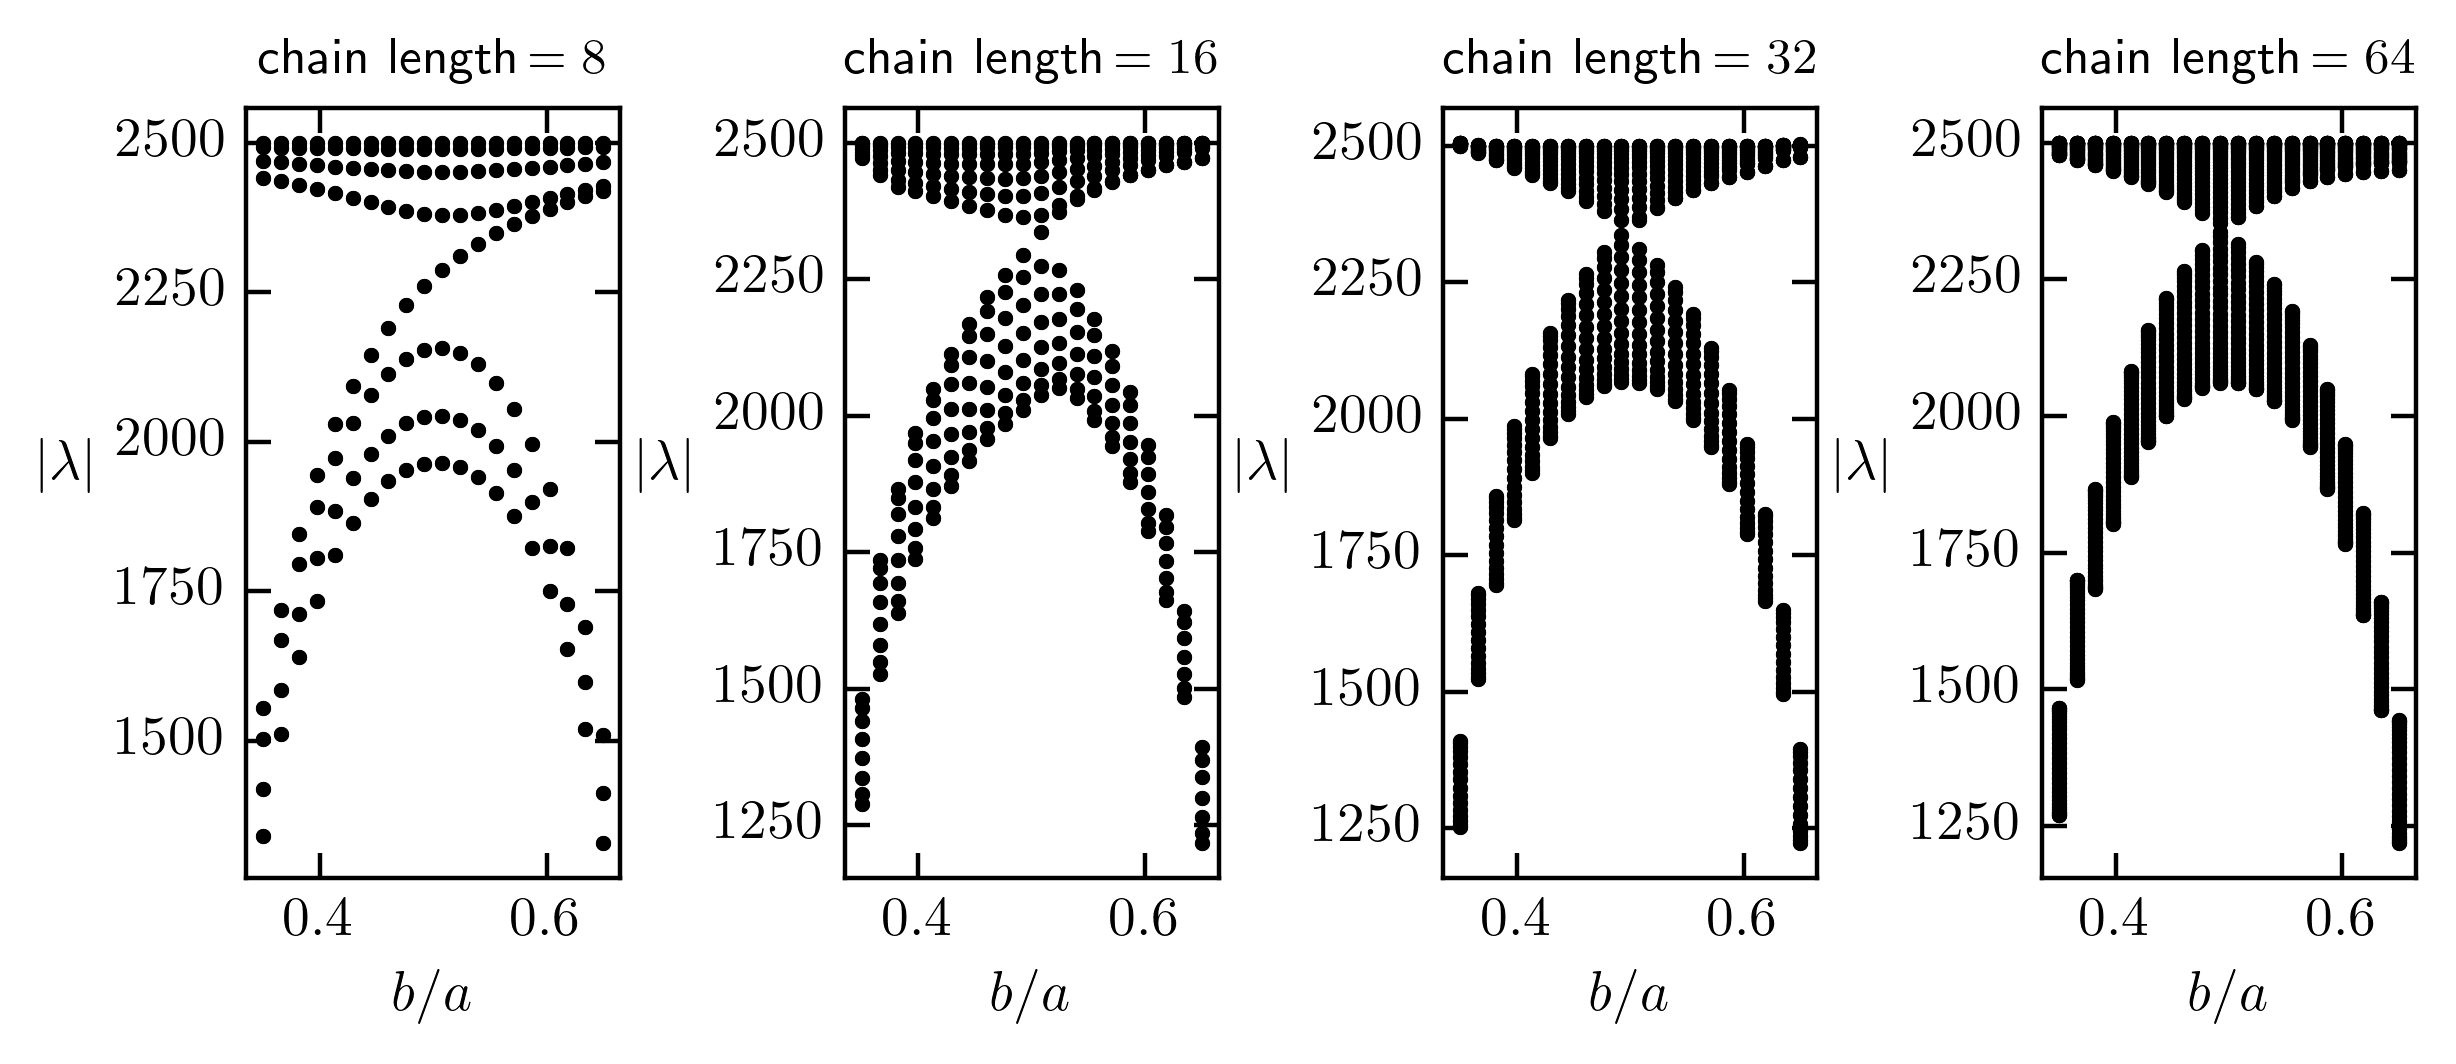

In [ ]:
# fig, ax = plt.subplots(1,1)
# fig, ax = plt.subplots(3,4,sharex=True)
setup = Setup_Fig(name_of_plot='lam2_anal_ml.png',fig_width=7,fig_height=2.5,xax_share=True)
fig, ax = setup.return_fig((1,4))

# fig2, ax2 = plt.subplots(1,1)
pad = 7

n=0
wrapper = []
# for l in [0,6,13,19]:
for l in range(4):
    
    phis_plot = opt_param[l][0]
    hs_plot = opt_param[l][1]
    chain_length = [8,16,32,64][l]
    eigenvals = np.zeros((N,2*chain_length),dtype=np.complex128)
    for i in range(N):
    # for i in range(7,14):
        # for n in range(chain_length//4):
            
            # dmat = hopping_Ham(b[i],hs[i],1,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis[i]),np.sin(phis[i])]))
            dmat = BdG_Ham(b[i],hs_plot[i],Deltas[3],a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis_plot[i]),np.sin(phis_plot[i])]))
            # dmat = hopping_Ham_k(k,b[i],hs[i],(m*w**2*r**2/V)[-1]/10**8,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis[i]),np.sin(phis[i])]))
            eig = np.linalg.eigvals(dmat)
            eigenvals[i] = eig
            
            marker_size = 3
            ax[n].scatter(b[i]*np.ones(len(eig)),np.real(np.abs(eig)),color="0",s=marker_size)
    wrapper.append(lambda k=n: setup.format_ax(ax[k],shape=(1,4),j=int(k>0),set_ticks=False,bottom=1))
    
  
    ax[n] = wrapper[n]()
    ax[n].set_title(r"chain length$\,={}$".format(chain_length),fontsize=9)
    ax[n].set_ylabel(r"$|\lambda|$",rotation=0,labelpad=8)
    ax[n].set_xlabel(r"$b/a$")
    # ax[0,n].set_ylim(-100,100)
    # ax[1,n].set_ylim(-100,100)
    n +=1
    min_ind = np.argmin(np.min(np.abs(eigenvals),axis=1))
    # print(Deltas[3],min_ind,b[min_ind])
# ax[2,0].set_yticks([0,0.1,0.2])
plt.subplots_adjust(wspace=0.6,hspace=0.3)
plt.savefig("/home//christian/Documents/master/protocol/pictures/"+"spectrum_abs_of_tuned_BdG_various_chainlengths_for_gap_10V.pdf",bbox_inches='tight')#free_evol_1spto10coupling
plt.show()

In [ ]:
latticeA[:,0].shape ,eigenvecs[0,1::2].shape

((4,), (8,))

In [ ]:
# fig, ax = plt.subplots(1,1)
# fig2, ax2 = plt.subplots(1,1)
pad = 7
chain_length = 8
# b = np.linspace(0.25,0.75,N)
# b = np.linspace(0.3,0.7,N)
eigenvals = np.zeros((N,chain_length//2,4),dtype=np.complex128)
for i in range(N):
    for n in range(chain_length//2):
        k = 2*np.pi*n/((chain_length//2)*a)-np.pi/a+np.pi/((chain_length//2)*a)
        dmat = BdG_Ham_k(k,b[i],hs_plot[i],Deltas[l],a,chain_length*100,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis_plot[i]),np.sin(phis_plot[i])]))
        # dmat = hopping_Ham_k(k,b[i],hs[i],(m*w**2*r**2/V)[-1]/10**8,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis[i]),np.sin(phis[i])]))
        eig = np.linalg.eigvals(dmat)
        eigenvals[i,n] = eig
        # ax.scatter(b[i]*np.ones(len(eig)),np.real(eig),color='0',s=10)
        # ax2.scatter(b[i]*np.ones(len(eig)),np.imag(eig),color='0',s=10)
# ax.set_xlabel(r"$b/a$")
# ax.set_ylabel(r"$\text{Re}(\lambda)$")
# plt.show()

IndexError: index 4 is out of bounds for axis 1 with size 4

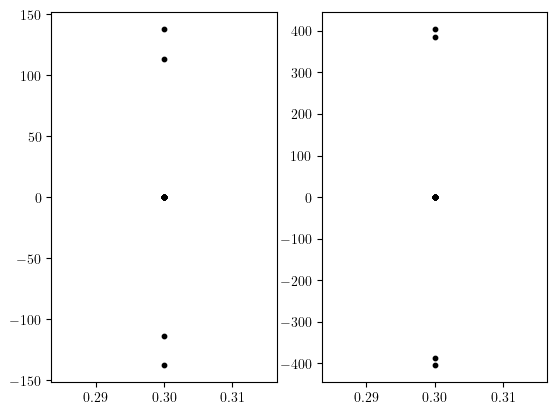

In [ ]:
# fig, ax = plt.subplots(1,2)
# # fig2, ax2 = plt.subplots(1,1)
# pad = 7
# chain_length = 80
# # b = np.linspace(0.25,0.75,N)
# b = np.linspace(0.3,0.7,N)
# # eigenvals = np.zeros((N,chain_length//2,4),dtype=np.complex128)
# for i in range(N):
#     for n in range(chain_length//2):
#         # k = 2*np.pi*n/((chain_length//2)*a)
#         # dmat = BdG_Ham_k(k,b[i],hs[i],(m*w**2*r**2/V)[-1]/10**8,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis[i]),np.sin(phis[i])]))
#         # # dmat = hopping_Ham_k(k,b[i],hs[i],(m*w**2*r**2/V)[-1]/10**8,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis[i]),np.sin(phis[i])]))
      
#         eig = eigenvals[i,n]
#         ax[0].scatter(b[i]*np.ones(len(eig)),np.real(eig),color='0',s=10)
#         ax[1].scatter(b[i]*np.ones(len(eig)),np.imag(eig),color='0',s=10)
# # ax.set_xlabel(r"$b/a$")
# # ax.set_ylabel(r"$\text{Re}(\lambda)$")
# plt.show()

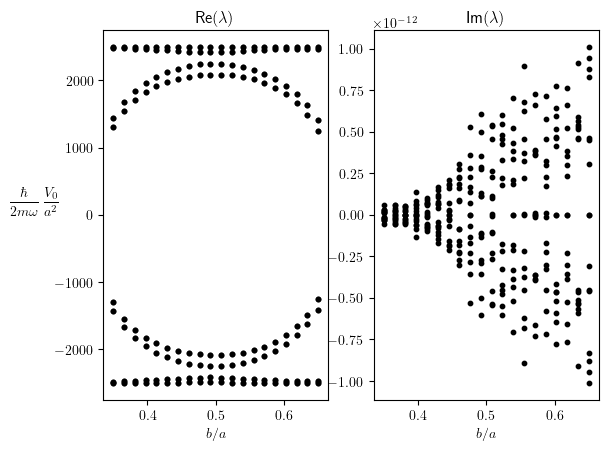

In [ ]:
fig, ax = plt.subplots(1,2)#,sharey=True)
# fig2, ax2 = plt.subplots(1,1)
pad = 15

# b = np.linspace(0.25,0.75,N)
# b = np.linspace(0.3,0.7,N)
# eigenvals = np.load("topological_phenomena_dipoles/BdG_spec.npy")
eigenvals2 = np.reshape(eigenvals,shape=(eigenvals.shape[0],eigenvals.shape[1]*eigenvals.shape[2]))
for i in range(N):
    
        
        ax[0].scatter(b[i]*np.ones(eigenvals2.shape[1]),np.real(eigenvals2[i]),color='0',s=10)
        ax[1].scatter(b[i]*np.ones(eigenvals2.shape[1]),np.imag(eigenvals2[i]),color='0',s=10)
ax[0].set_xlabel(r"$b/a$")
ax[0].set_title(r"$\text{Re}(\lambda)$")
ax[0].set_ylabel(r"$$\frac{\hbar}{2m\omega}\,\frac{V_0}{a^2}$$",rotation=0,labelpad = pad)
# ax[1].tick_params(axis='y',direction='in',which='both',left=False,right=False,labelleft=False)   

ax[1].set_xlabel(r"$b/a$")
ax[1].set_title(r"$\text{Im}(\lambda)$")
plt.subplots_adjust(wspace=0.2)
# plt.savefig("/home/christian/Documents/master/protocol/pictures/"+"Bdg_spec_8N.pdf",bbox_inches='tight')
plt.show()

In [ ]:
np.save("topological_phenomena_dipoles/BdG_spec",eigenvals)

In [ ]:
def sort_eigenvalues(eigenvalues: np.ndarray,eigenvectors: np.ndarray) -> np.ndarray:
    """Sort eigenvalues in ascending order."""
    # eigenvectors *= np.conjugate(eigenvectors[0, :])/np.absolute(eigenvectors[0,:])#np.array([np.absolute(eigenvectors[0,i]) for i in range(eigenvectors.shape[1])]) # Normalize the eigenvectors
    comb = np.column_stack((eigenvalues.T, eigenvectors.T))
    # return comb
    # sorted_comb = sorted(comb, key=lambda x: x[0])
    sorted_comb = sorted(comb, key=lambda x: np.abs(x[0]))
    return np.array(sorted_comb)

In [ ]:
i = 3   
bdg = BdG_Ham(b[i],hs[i],(m*w**2*r**2/V)[-1]/10**8,a,chain_length,lambda x, y: dip_derivative_full_vec(x, y),np.array([np.cos(phis[i]),np.sin(phis[i])]))  
eig, vec = np.linalg.eig(bdg)
eigenvals = sort_eigenvalues(eig,vec)
chain_length
j = 6
eigenvals[j,0], eigenvals[2*chain_length-j-1], eigenvals


In [ ]:
def abs_eigvec(param,b):
    phid = param[0]
    h = param[1]
    d = np.array([np.cos(phid),np.sin(phid)])
    dmat = nearest_nb_Hamiltonian(b,h,a,chain_length,lambda x, y: dip_derivative_full(x, 0, 0, y),0,d)
    # dmat += np.diag(np.ones(chain_length))*(m*w**2*r**2/V)[-1]/10**8
    beta = grad(b,h,a,chain_length,nom_der1,d)
    # eigenvecs = np.linalg.solve(dmat,beta)
    eigenvecs = np.linalg.lstsq(dmat,beta)[0]
    # return np.linalg.norm(beta)
    return np.max(np.abs(eigenvecs))
from scipy.optimize import minimize
N = 60
b = np.linspace(0.25,0.75,N)
phis_new = np.ones(N)*(3.7)
hs_new = np.ones(N)*0.25
chain_length = 16
Deltap = 0.2
Deltah = 0.1
for i in range(N):
    
    res = minimize(abs_eigvec,x0=(phis[i],hs[i]),args=b[i],bounds=((phis[i]-Deltap,phis[i]+Deltap),(hs[i]-Deltah,hs[i]+Deltah)),tol=1e-12)
   
    

    phis_new[i] = res.x[0]
    hs_new[i] = res.x[1]

In [ ]:
pad = 7

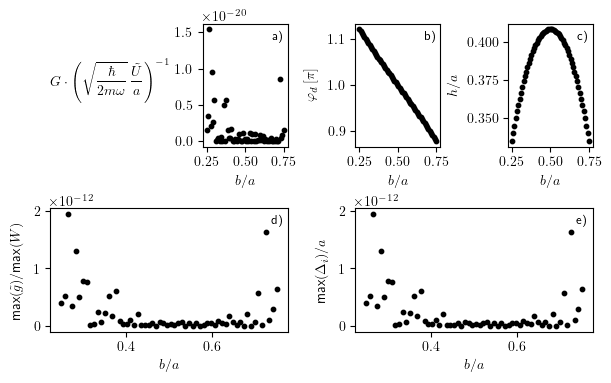

In [ ]:
phis_plot = phis
hs_plot = hs
setup = Setup_Fig(name_of_plot='lam2_anal_ml.png',fig_width=7,fig_height=4,xax_share=True,joined=True)
fig = plt.figure(figsize=(setup.fig_width,setup.fig_height))
fig.tight_layout()
gs = gridspec.GridSpec(2,4, figure=fig)
ax0 = fig.add_subplot(gs[0,0])
ax1 = fig.add_subplot(gs[0,1])
ax2 = fig.add_subplot(gs[0,2])
ax3 = fig.add_subplot(gs[0,3])
ax4 = fig.add_subplot(gs[1,:2])
ax5 = fig.add_subplot(gs[1,2:])
# ax6 = fig.add_subplot(gs[1,8:])
# fig, ax = setup.return_fig((1,2))
# fig2, ax3 = setup.return_fig((1,2))
for i in range(N):
    
    dmat = nearest_nb_Hamiltonian(b[i],hs_plot[i],a,chain_length,lambda x, y: dip_derivative_full(x, 0, 0, y),0,np.array([np.cos(phis_plot[i]),np.sin(phis_plot[i])]))

    eig, vec = np.linalg.eig(dmat)
    # ax.scatter(b[i]*np.ones(chain_length),eig,color='0',s=30)
    beta = grad(b[i],hs_plot[i],a,chain_length,nom_der1,np.array([np.cos(phis_plot[i]),np.sin(phis_plot[i])]))
    dmatp = dmat+ np.diag(np.ones(chain_length))*(m*w**2*r**2/V)[-1]/10**8
    # dis = np.linalg.lstsq(dmat,beta)[0]
    dis = np.linalg.solve(dmatp,beta)
    h_new = beta-dmatp@dis
    # ax3[1].scatter(b[i],np.max(h_new),color='0',s=10)
    # ax3[1].scatter(b[i]*np.ones(chain_length),beta,color='0',s=30)
    ax1.scatter(b[i],np.max(h_new)/(np.max(np.abs(dmat))*3/1000),color='0',s=10)
    # ax6.scatter(b[i],np.max(dis)*10**3,color='0',s=10)
    ax5.scatter(b[i],np.max(dis),color='0',s=10)
    ax4.scatter(b[i],np.max(beta)/np.max(np.abs(dmatp)),color='0',s=10)
    # ax2.scatter(b[i],sorted_crit[0][0],color='0',s=10)
ax0.axis("off")
ax2.scatter(b,phis_plot/np.pi,color='0',s=10)
ax3.scatter(b,hs_plot,color='0',s=10)
ax1.set_xlabel(r"$b/a$")
ax2.set_ylabel(r"$\varphi_d\,[\pi]$",labelpad=pad)
ax2.set_xlabel(r"$b/a$")
ax3.set_ylabel(r"$h/a$")
ax3.set_xlabel(r"$b/a$")
ax4.set_xlabel(r"$b/a$")
# ax1.text(0.7,0.7,"a)",fontsize=9)

ax5.set_ylabel(r"max$(\Delta_i)/a$",labelpad=pad)
ax0.text(-0.,0.5,r"$$G\cdot\left(\sqrt{\frac{\hbar }{2m \omega}}\,\frac{\tilde{U}}{a}\right)^{-1}$$")
ax5.set_xlabel(r"$b/a$")
ax4.set_ylabel(r"$\text{max}(\tilde{g})/\text{max}(W)$",labelpad=pad)
# ax6.set_xlabel(r"$b/a$")
# ax6.set_ylabel(r"$$\text{max}(\Delta_i)/\sqrt{\hbar/2m\omega}$$",labelpad=pad)
ax4.text(0.93,0.88,"d)",fontsize=9,transform=ax4.transAxes)
ax5.text(0.93,0.88,"e)",fontsize=9,transform=ax5.transAxes)
ax1.text(0.82,0.87,"a)",fontsize=9,transform=ax1.transAxes)
ax2.text(0.82,0.87,"b)",fontsize=9,transform=ax2.transAxes)
ax3.text(0.82,0.87,"c)",fontsize=9,transform=ax3.transAxes)
plt.subplots_adjust(wspace=0.8,hspace=0.5)
# plt.savefig("/home//christian/Documents/master/protocol/pictures/"+"tuning_first_order_to_zero.pdf",bbox_inches='tight')#free_evol_1spto10coupling
plt.show()

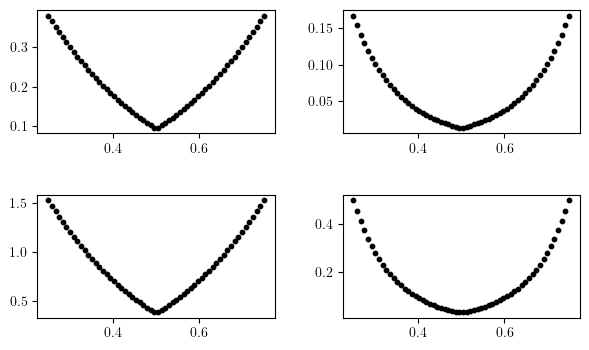

In [ ]:
phis_plot = phis
hs_plot = hs
setup = Setup_Fig(name_of_plot='lam2_anal_ml.png',fig_width=7,fig_height=4,xax_share=True,joined=True)
fig = plt.figure(figsize=(setup.fig_width,setup.fig_height))
fig.tight_layout()
gs = gridspec.GridSpec(2,4, figure=fig)
# ax0 = fig.add_subplot(gs[0,0])
ax1 = fig.add_subplot(gs[0,:2])
ax2 = fig.add_subplot(gs[0,2:])
# ax3 = fig.add_subplot(gs[0,3])
ax4 = fig.add_subplot(gs[1,:2])
ax5 = fig.add_subplot(gs[1,2:])
def interaction_nnn(b,h,a,interaction1,interaction2,d):
    latticeA = np.array([[0,0],[3*a,0]])
    latticeB = np.array([b,h])
    dist1 = latticeB-latticeA[0]
    dist2 = latticeA[1]-latticeB
    grad1 = interaction1(dist1,d)
    grad2 = interaction1(dist2,d)
    hess1 = -interaction2(dist1,d)
    hess2 = -interaction2(dist2,d)
    return grad1, grad2, hess1, hess2
# ax6 = fig.add_subplot(gs[1,8:])
# fig, ax = setup.return_fig((1,2))
# fig2, ax3 = setup.return_fig((1,2))
for i in range(N):
    
    inter1 = interaction_nnn(a,0,a,nom_der1,lambda x, y: dip_derivative_full(x, 0, 0, y),np.array([np.cos(phis_plot[i]),np.sin(phis_plot[i])]))
    inter2 = interaction_nnn(a+b[i],hs_plot[i],a,nom_der1,lambda x, y: dip_derivative_full(x, 0, 0, y),np.array([np.cos(phis_plot[i]),np.sin(phis_plot[i])]))
    dmat = nearest_nb_Hamiltonian(b[i],hs_plot[i],a,chain_length,lambda x, y: dip_derivative_full(x, 0, 0, y),0,np.array([np.cos(phis_plot[i]),np.sin(phis_plot[i])]))


    # eig, vec = np.linalg.eig(dmat)
    # # ax.scatter(b[i]*np.ones(chain_length),eig,color='0',s=30)
    # beta = grad(b[i],hs_plot[i],a,chain_length,nom_der1,np.array([np.cos(phis_plot[i]),np.sin(phis_plot[i])]))
    # dmatp = dmat+ np.diag(np.ones(chain_length))*(m*w**2*r**2/V)[-1]/10**8
    # # dis = np.linalg.lstsq(dmat,beta)[0]
    # dis = np.linalg.solve(dmatp,beta)
    # h_new = beta-dmatp@dis
    # # ax3[1].scatter(b[i],np.max(h_new),color='0',s=10)
    # # ax3[1].scatter(b[i]*np.ones(chain_length),beta,color='0',s=30)
    # ax1.scatter(b[i],np.max(h_new)/(np.max(np.abs(dmat))*3/1000),color='0',s=10)
    # ax6.scatter(b[i],np.max(dis)*10**3,color='0',s=10)
    max_dmat = np.min(np.where(np.abs(dmat)==0,np.inf,np.abs(dmat)))
    ax4.scatter(b[i],np.max(np.abs(inter1[2:]))/max_dmat,color='0',s=10)
    ax5.scatter(b[i],np.max(np.abs(inter2[2:]))/max_dmat,color='0',s=10)
    ax1.scatter(b[i],np.max(np.abs(inter1[:2]))/max_dmat,color='0',s=10)
    ax2.scatter(b[i],np.max(np.abs(inter2[:2]))/max_dmat,color='0',s=10)
    # ax2.scatter(b[i],sorted_crit[0][0],color='0',s=10)
# ax0.axis("off")
# ax2.scatter(b,phis_plot/np.pi,color='0',s=10)
# ax3.scatter(b,hs_plot,color='0',s=10)
# ax1.set_xlabel(r"$b/a$")
# ax2.set_ylabel(r"$\varphi_d\,[\pi]$",labelpad=pad)
# ax2.set_xlabel(r"$b/a$")
# ax3.set_ylabel(r"$h/a$")
# ax3.set_xlabel(r"$b/a$")
# ax4.set_xlabel(r"$b/a$")
# # ax1.text(0.7,0.7,"a)",fontsize=9)

# ax5.set_ylabel(r"max$(\Delta_i)/a$",labelpad=pad)
# ax0.text(-0.,0.5,r"$$G\cdot\left(\sqrt{\frac{\hbar }{2m \omega}}\,\frac{\tilde{U}}{a}\right)^{-1}$$")
# ax5.set_xlabel(r"$b/a$")
# ax4.set_ylabel(r"$\text{max}(\tilde{g})/\text{max}(W)$",labelpad=pad)
# # ax6.set_xlabel(r"$b/a$")
# # ax6.set_ylabel(r"$$\text{max}(\Delta_i)/\sqrt{\hbar/2m\omega}$$",labelpad=pad)
# ax4.text(0.93,0.88,"d)",fontsize=9,transform=ax4.transAxes)
# ax5.text(0.93,0.88,"e)",fontsize=9,transform=ax5.transAxes)
# ax1.text(0.82,0.87,"a)",fontsize=9,transform=ax1.transAxes)
# ax2.text(0.82,0.87,"b)",fontsize=9,transform=ax2.transAxes)
# ax3.text(0.82,0.87,"c)",fontsize=9,transform=ax3.transAxes)
plt.subplots_adjust(wspace=0.8,hspace=0.5)
# plt.savefig("/home//christian/Documents/master/protocol/pictures/"+"tuning_first_order_to_zero.pdf",bbox_inches='tight')#free_evol_1spto10coupling
plt.show()

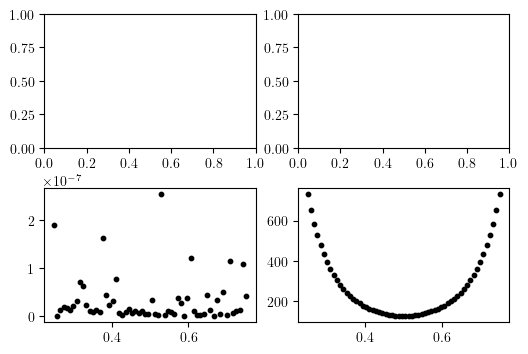

In [ ]:
phis_plot = phis_new
hs_plot = hs_new
setup = Setup_Fig(name_of_plot='lam2_anal_ml.png',fig_width=6,fig_height=4,xax_share=True,joined=True)
fig = plt.figure(figsize=(setup.fig_width,setup.fig_height))
gs = gridspec.GridSpec(2,2, figure=fig)
ax = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[0,1])
ax3 = fig.add_subplot(gs[1,0])
ax4 = fig.add_subplot(gs[1,1])
# fig, ax = setup.return_fig((1,2))
# fig2, ax3 = setup.return_fig((1,2))
for i in range(N):
    
    dmat = nearest_nb_Hamiltonian(b[i],hs_plot[i],a,chain_length,lambda x, y: dip_derivative_full(x, 0, 0, y),0,np.array([np.cos(phis_plot[i]),np.sin(phis_plot[i])]))

    eig, vec = np.linalg.eig(dmat)
    # ax.scatter(b[i]*np.ones(chain_length),eig,color='0',s=30)
    beta = grad(b[i],hs_plot[i],a,chain_length,nom_der1,np.array([np.cos(phis_plot[i]),np.sin(phis_plot[i])]))
    dmatp = dmat+ np.diag(np.ones(chain_length))*(m*w**2*r**2/V)[-1]/10**8
    dis = np.linalg.solve(dmatp,beta)
    h_new = beta-dmat@dis
    ax3.scatter(b[i],np.max(beta)/np.max(dmat),color='0',s=10)
    ax4.scatter(b[i],np.max(dmat),color='0',s=10)
plt.subplots_adjust(hspace=0.3)
    # ax3[1].scatter(b[i]*np.ones(chain_length),beta,color='0',s=30)
    # ax3.scatter(b[i],np.max(h_new)/(np.max(np.abs(dmat))*3/1000),color='0',s=10)

In [ ]:
def first_order_spph(b,h,a,chain_length,interaction,d):
    latticeA = np.zeros((2,chain_length//2+chain_length%2))
    latticeB = np.zeros((2,chain_length//2))
    for n in range(latticeA.shape[1]):
        latticeA[:,n] = n*np.array([1,0])*a
    for n in range(latticeB.shape[1]):
        latticeB[:,n] = n*np.array([1,0])*a + b * np.array([1,0])+h*np.array([0,1])
    dmat = np.zeros((chain_length-1,chain_length))
    ind = np.arange(chain_length,dtype=np.int16)
    inter_1 = -interaction(latticeB[:,0]-latticeA[:,0],d)
    inter_2 = -interaction(latticeA[:,1]-latticeB[:,0],d)
    dmat[ind[:-1:2],ind[:-1:2]]= -inter_1
    dmat[ind[1:-1:2],ind[1:-1:2]]= -inter_2
    dmat[ind[:-1:2],ind[1::2]] = inter_1
    dmat[ind[1:-1:2],ind[2::2]] = inter_2
    return dmat

def grad_spph(b,h,a,chain_length,interaction,d):
    latticeA = np.array([[0,0],[a,0]])
    latticeB = np.array([b,h])
    dist1 = latticeB-latticeA[0]
    dist2 = latticeA[1]-latticeB
    grad1 = interaction(dist1,d)
    grad2 = interaction(dist2,d)
    grad_vec = np.zeros(chain_length-1)
    # print(grad1,grad2)
    grad_vec[::2] = grad1
    grad_vec[1::2] = grad2
    return grad_vec
 

def interaction(b,h,a,interaction1,interaction2,d):
    latticeA = np.array([[0,0],[a,0]])
    latticeB = np.array([b,h])
    dist1 = latticeB-latticeA[0]
    dist2 = latticeA[1]-latticeB
    grad1 = interaction1(dist1,d)
    grad2 = interaction1(dist2,d)
    hess1 = -interaction2(dist1,d)
    hess2 = -interaction2(dist2,d)
    return grad1, grad2, hess1, hess2

# chain_length = 6
# dmat = first_order_spph(0.3,0.2,a,chain_length,lambda x, y: dip_derivative_full(x, 0, 0, y),d)
# np.round(dmat,2)



In [ ]:

fig, ax = plt.subplots(1,2)
chain_length = 16
Deltap = np.pi
Deltah = 1
N = 3
N_phi = 50
phi_test = np.linspace(-np.pi,np.pi,N_phi)
ds = np.array([np.cos(phi_test),np.sin(phi_test)])
b = np.linspace(0.4,0.6,N)
for i in range(N):
    his = np.linspace(0.2,0.3,N)
    derivatives = np.zeros((N_phi,4))
    # fig, ax = plt.subplots(1,1)
    for j in range(N):
        derivatives = interaction(b[i],his[j],a,chain_length,nom_der1,lambda x, y: dip_derivative_full(x, 0, 0, y),ds)
        print("b: ",b[i],", h: ",his[j])
        fig, ax = plt.subplots(1,1)
        ax.scatter(phi_test,derivatives[:,0]/derivatives[:,2],s=10)
        # ax.scatter(phi_test,derivatives[:,0]/derivatives[:,2],s=10)
        ax.scatter(phi_test,derivatives[:,1]/derivatives[:,3],s=10)
        plt.show()
        

    

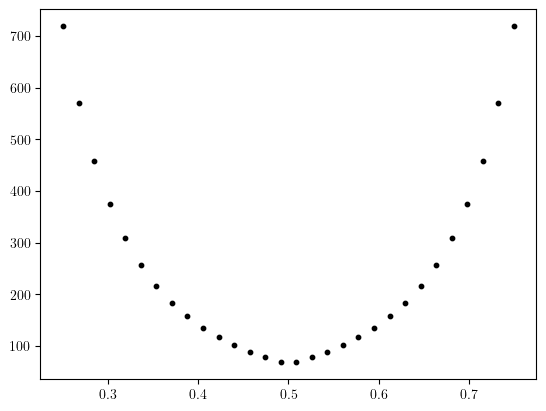

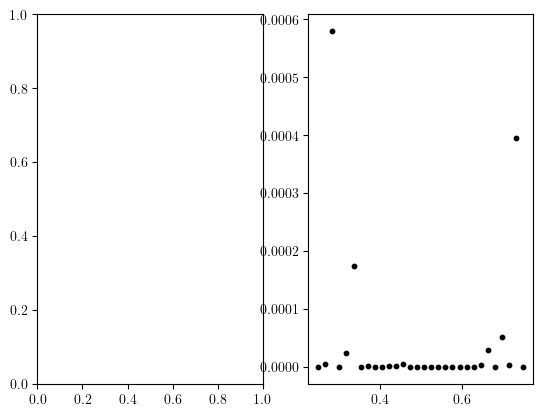

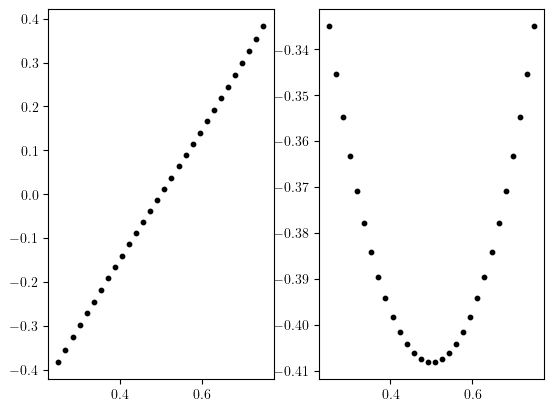

In [ ]:
def abs_eigvec(param,b,*paramlast):
    phid = param[0]
    h = param[1]
    d = np.array([np.cos(phid),np.sin(phid)])
    dmat = first_order_spph(b,h,a,chain_length,lambda x, y: dip_derivative_full(x, 0, 0, y),d)
    # dmat += np.diag(np.ones(chain_length))*(m*w**2*r**2/V)[-1]/10**8
    beta = grad_spph(b,h,a,chain_length,nom_der1,d)
    # eigenvecs = np.linalg.solve(dmat,beta)
    eigenvecs = np.linalg.lstsq(dmat,beta)[0]
    # return np.max(np.abs(beta))/np.max(np.abs(dmat))
    return np.max(np.abs(eigenvecs))+(np.abs(phid-paramlast[0]) + np.abs(h-paramlast[1]))*1e-6
from scipy.optimize import minimize
N = 30
b = np.linspace(0.25,0.75,N)
phis = np.ones(N)*0*(np.pi)
hs = np.ones(N)*0
fig2, ax2 = plt.subplots(1,1)
fig3, ax3 = plt.subplots(1,2)
fig, ax = plt.subplots(1,2)
chain_length = 16
Deltap = np.pi
Deltah = 1
bound_p = (-np.pi/2*3,np.pi/2*3)
for i in range(N):
    phi_grid = np.linspace(-Deltap,Deltap,10)+phis[i-1]
    h_grid = np.linspace(-Deltah,Deltah,10)+hs[i-1]
    min_vals = np.zeros((len(phi_grid),len(h_grid)))
    min_phi = np.zeros_like(min_vals)
    min_h = np.zeros_like(min_vals)
    min_vals = []
    min_phi = []
    min_h = []
    Deltap = 0.2
    Deltah = 0.1
    
    for n in range(len(phi_grid)):
        for m in range(len(h_grid)):
            # try:
                res = minimize(abs_eigvec,x0=(phi_grid[n],h_grid[m]),args=(b[i],phis[i-1],hs[i-1]),bounds=(bound_p,(-0.5,0.5)),tol=1e-12)
                min_vals.append(res.fun)
                min_phi.append(res.x[0])
                min_h.append(res.x[1])
            # except:
            #     pass
    bound_p = (-np.pi/2*3,np.pi/2*3)
    crit = np.array([min_vals, min_phi, min_h]).T
    sorted_crit = sorted(crit, key=lambda x: x[0])
    

    phis[i] = sorted_crit[0][1]
    hs[i] = sorted_crit[0][2]
    dmat = first_order_spph(b[i],hs[i],a,chain_length,lambda x, y: dip_derivative_full(x, 0, 0, y),np.array([np.cos(phis[i]),np.sin(phis[i])]))
    # eig, vec = np.linalg.eig(dmat)
    # ax3[0].scatter(b[i]*np.ones(chain_length-1),eig,color='0',s=30)
    beta = grad_spph(b[i],hs[i],a,chain_length,nom_der1,np.array([np.cos(phis[i]),np.sin(phis[i])]))
    # dmatp = dmat+ np.diag(np.ones(chain_length))*(m*w**2*r**2/V)[-1]/10**8
    vecp = np.linalg.lstsq(dmat,beta)[0]
    dis = dmat@vecp
    ax3[1].scatter(b[i],np.max(dis),color='0',s=10)
    # ax3[1].scatter(b[i]*np.ones(chain_length),beta,color='0',s=30)
    ax2.scatter(b[i],np.max(np.abs(dmat)),color='0',s=10)
    # ax2.scatter(b[i],sorted_crit[0][0],color='0',s=10)

ax[0].scatter(b,phis,color='0',s=10)
ax[1].scatter(b,hs,color='0',s=10)
plt.show()

In [ ]:
Deltah, Deltap = (1,2)
def wrap_func(i,base):
    b = np.linspace(0.25,0.75,N)
    phi_grid = np.linspace(-Deltap,Deltap,10)+phis[i-1]
    h_grid = np.linspace(-Deltah,Deltah,10)+hs[i-1]
    Deltah, Deltap = (0.1,0.2)
    min_vals = np.zeros((len(phi_grid),len(h_grid)))
    min_phi = np.zeros_like(min_vals)
    min_h = np.zeros_like(min_vals)
    min_vals = []
    min_phi = []
    min_h = []
    
    for n in range(len(phi_grid)):
        for m in range(len(h_grid)):
            # try:
                res = minimize(abs_eigvec,x0=(phi_grid[n],h_grid[m]),args=b[i],bounds=((0,2*np.pi),(-0.5,0.5)),tol=1e-12)
                min_vals.append(res.fun)
                min_phi.append(res.x[0])
                min_h.append(res.x[1])
            # except:
            #     pass
    crit = np.array([min_vals, min_phi, min_h]).T
    sorted_crit = sorted(crit, key=lambda x: x[0])
    

    return sorted_crit[0][1], sorted_crit[0][2]
N= 15
# wrapper(0,0)
res = parallel_for([[0,N]],wrap_func,chunk = 3)

In [ ]:
pad = 8

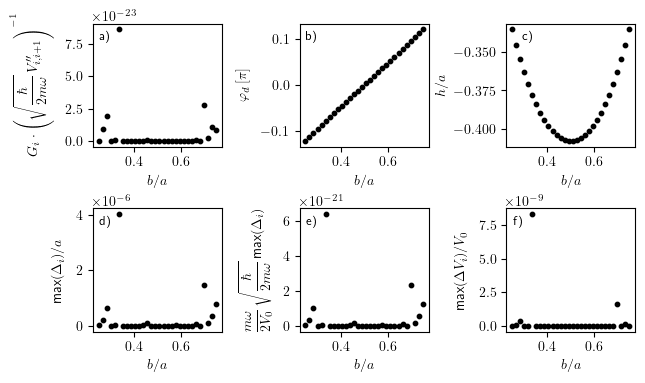

In [ ]:
# phis_plot = res[:,0]
# hs_plot = res[:,1]
# N = 15
# b = np.linspace(0.25,0.75,N)
phis_plot = phis
hs_plot = hs
setup = Setup_Fig(name_of_plot='lam2_anal_ml.png',fig_width=7,fig_height=4,xax_share=True,joined=True)
fig = plt.figure(figsize=(setup.fig_width,setup.fig_height))
fig.tight_layout()
gs = gridspec.GridSpec(2,3, figure=fig)
# ax0 = fig.add_subplot(gs[0,0])
ax1 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[0,1])
ax3 = fig.add_subplot(gs[0,2])
ax4 = fig.add_subplot(gs[1,0])
ax5 = fig.add_subplot(gs[1,1])
ax6 = fig.add_subplot(gs[1,2])
# fig, ax = setup.return_fig((1,2))
# fig2, ax3 = setup.return_fig((1,2))
for i in range(N):
    
    dmat = first_order_spph(b[i],hs_plot[i],a,chain_length,lambda x, y: dip_derivative_full(x, 0, 0, y),np.array([np.cos(phis_plot[i]),np.sin(phis_plot[i])]))
    second_order = nearest_nb_Hamiltonian(b[i],hs_plot[i],a,chain_length,lambda x, y: dip_derivative_full(x, 0, 0, y),0,np.array([np.cos(phis_plot[i]),np.sin(phis_plot[i])]))
    # eig, vec = np.linalg.eig(dmat)
    # ax.scatter(b[i]*np.ones(chain_length),eig,color='0',s=30)
    beta = grad_spph(b[i],hs_plot[i],a,chain_length,nom_der1,np.array([np.cos(phis_plot[i]),np.sin(phis_plot[i])]))
    # dmatp = dmat+ np.diag(np.ones(chain_length))*(m*w**2*r**2/V)[-1]/10**8
    dis = np.linalg.lstsq(dmat,beta)[0]
    # dis = np.linalg.solve(dmatp,beta)
    h_new = beta-dmat@dis
    # ax3[1].scatter(b[i],np.max(h_new),color='0',s=10)
    # ax3[1].scatter(b[i]*np.ones(chain_length),beta,color='0',s=30)
    second_der = grad_spph(b[i],hs_plot[i],a,chain_length,lambda x, y: dip_derivative_full(x, 0, 0, y),np.array([np.cos(phis_plot[i]),np.sin(phis_plot[i])]))
    ax1.scatter(b[i],np.max(np.abs(h_new/second_der))*3/1000,color='0',s=10)
    # ax6.scatter(b[i],np.max(dis)*10**3,color='0',s=10)
    Ew = 3*1e-20*10/10**6
    ax4.scatter(b[i],np.max(dis),color='0',s=10)
    ax5.scatter(b[i],np.max(dis)*Ew/V[0]*np.sqrt(c.hbar/2/m/w[0]),color='0',s=10)
    DV1 = beta * (dis[1:]-dis[:-1])
    
    DV2 = 1/2*second_der * (dis[1:]-dis[:-1])**2
    ax6.scatter(b[i],np.max(np.abs(DV1+DV2)),color='0',s=10)
    # ax2.scatter(b[i],sorted_crit[0][0],color='0',s=10)
ax0.axis("off")
ax2.scatter(b,phis_plot/np.pi,color='0',s=10)
ax3.scatter(b,hs_plot,color='0',s=10)
ax1.set_xlabel(r"$b/a$")
ax2.set_ylabel(r"$\varphi_d\,[\pi]$",labelpad=pad)
ax2.set_xlabel(r"$b/a$")
ax3.set_ylabel(r"$h/a$")
ax3.set_xlabel(r"$b/a$")
ax4.set_xlabel(r"$b/a$")
# ax1.text(0.7,0.7,"a)",fontsize=9)

ax4.set_ylabel(r"max$(\Delta_i)/a$",labelpad=pad)
ax1.set_ylabel(r"$$G_i\cdot\left(\sqrt{\frac{\hbar }{2m \omega}}\,{V_{i,i+1}''}\right)^{-1}$$",labelpad=pad)
ax5.set_xlabel(r"$b/a$")
ax5.set_ylabel(r"$$\frac{m\omega}{2V_0}\,\sqrt{\frac{\hbar}{2m\omega}}\,\text{max}(\Delta_i)$$",labelpad=pad)
ax6.set_xlabel(r"$b/a$")
ax6.set_ylabel(r"$\text{max}(\Delta V_i)/V_0$",labelpad=pad)
ax4.text(0.05,0.87,"d)",fontsize=9,transform=ax4.transAxes)
ax5.text(0.05,0.87,"e)",fontsize=9,transform=ax5.transAxes)
ax6.text(0.05,0.87,"f)",fontsize=9,transform=ax6.transAxes)
ax1.text(0.05,0.87,"a)",fontsize=9,transform=ax1.transAxes)
ax2.text(0.05,0.87,"b)",fontsize=9,transform=ax2.transAxes)
ax3.text(0.12,0.87,"c)",fontsize=9,transform=ax3.transAxes)
plt.subplots_adjust(wspace=0.6,hspace=0.5)
plt.savefig("/home//christian/Documents/master/protocol/pictures/"+"tuning_first_order_to_zero_spph.pdf",bbox_inches='tight')#free_evol_1spto10coupling
plt.show()

In [ ]:
dmat = nearest_nb_Hamiltonian(b[0],h,a,8,lambda x, y: dip_derivative_full(x, 0, 0, y),0,d)
eig, vec = np.linalg.eig(dmat)
np.round(dmat,1), eig

(array([[-1701.3,  1701.3,     0. ,     0. ,     0. ,     0. ,     0. ,
             0. ],
        [ 1701.3, -1678.5,   -22.9,     0. ,     0. ,     0. ,     0. ,
             0. ],
        [    0. ,   -22.9, -1678.5,  1701.3,     0. ,     0. ,     0. ,
             0. ],
        [    0. ,     0. ,  1701.3, -1678.5,   -22.9,     0. ,     0. ,
             0. ],
        [    0. ,     0. ,     0. ,   -22.9, -1678.5,  1701.3,     0. ,
             0. ],
        [    0. ,     0. ,     0. ,     0. ,  1701.3, -1678.5,   -22.9,
             0. ],
        [    0. ,     0. ,     0. ,     0. ,     0. ,   -22.9, -1678.5,
          1701.3],
        [    0. ,     0. ,     0. ,     0. ,     0. ,     0. ,  1701.3,
         -1701.3]]),
 array([ 3.90897870e+01,  2.30072217e+01,  5.36701980e-14,  6.77118539e+00,
        -3.36372729e+03, -3.37996333e+03, -3.40266358e+03, -3.39604590e+03]))

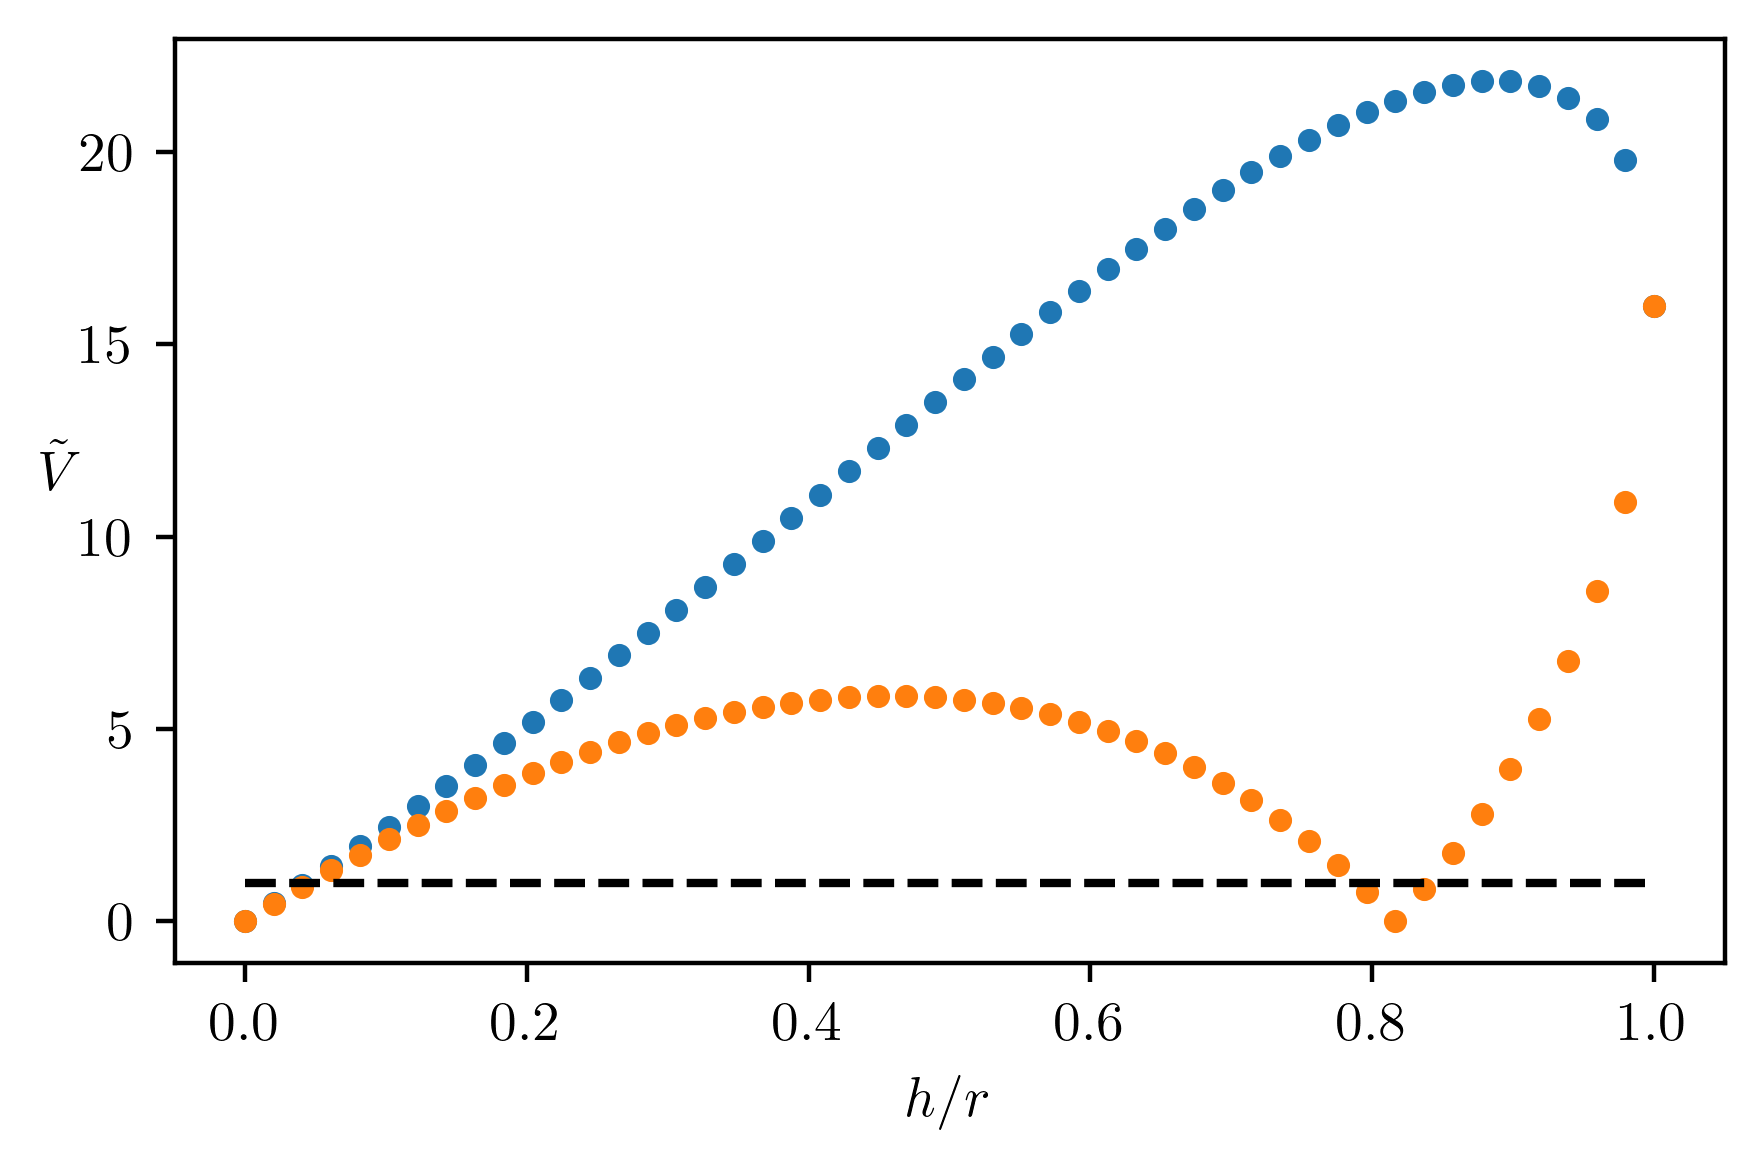

In [ ]:
x = np.linspace(0,1)
y1 = -16*(x**2+np.sqrt(2*(1-x**2))*x)
y2 = -16*(x**2-np.sqrt(2*(1-x**2))*x)

setup = Setup_Fig(name_of_plot='lam2_anal_ml.png',fig_width=5,fig_height=3,xax_share=True,joined=True)

wrapper = [[],[]]
fig, ax = setup.return_fig((1,1))
ax.set_xlabel(r"$h/r$")
ax.set_ylabel(r"$\tilde{V}$",rotation=0)
ax.scatter(x,np.abs(y1),label="-",s=10)
ax.scatter(x,np.abs(y2),label="+",s=10)
ax.hlines(1,x[0],x[-1],linestyle="dashed",color='0')
# plt.savefig("/home/christian/Documents/master/protocol/pictures/"+"magnitude_derV_ifVzero.pdf")#free_evol_1spto10coupling

plt.show()

In [ ]:

"""
Computes ∂f/∂r_x of the function:
 
    f = (1/r^5) * [-3 + 15*(r·d)²/r² - 6*dx² + 60*dx*rx/r²*(r·d) + 15*(rx/r)²*(1 - 7*(r·d)²/r²)]
 
where r = ||(rx, ry)||, r·d = rx*dx + ry*dy.
"""
 
import sympy as sp
 
# ── Symbols ───────────────────────────────────────────────────────────────────
rx, ry, dx, dy = sp.symbols("r_x r_y d_x d_y", real=True)
 
# ── Derived quantities ────────────────────────────────────────────────────────
r2   = rx**2 + ry**2          # r² (avoids sqrt in denominator until the end)
rdot = rx*dx + ry*dy          # r · d
 
# ── Function f ────────────────────────────────────────────────────────────────
bracket = (
    -3
    + 15 * rdot**2 / r2
    - 6 * dx**2
    + 60 * dx * rx / r2 * rdot
    + 15 * rx**2 / r2 * (1 - 7 * rdot**2 / r2)
)
 
f = bracket / r2**sp.Rational(5, 2)   # 1/r^5 = 1/(r²)^(5/2)
 
# ── Derivative ────────────────────────────────────────────────────────────────
df_drx = sp.simplify(sp.diff(f, rx))
df2_drx2 = sp.simplify(sp.diff(df_drx, rx))

# ── Output ────────────────────────────────────────────────────────────────────
print("∂f/∂r_x =")
sp.pprint(df_drx, use_unicode=True)
print()
print("LaTeX:")
print(sp.latex(df_drx))


ModuleNotFoundError: No module named 'sympy'

/tmp/ipykernel_43745/2634336619.py:7: RuntimeWarning: invalid value encountered in sqrt
  dy = np.sqrt(1-dx**2)
/tmp/ipykernel_43745/2634336619.py:33: RuntimeWarning: invalid value encountered in divide
  ax[1].scatter(phi,V/Vder,s=10)


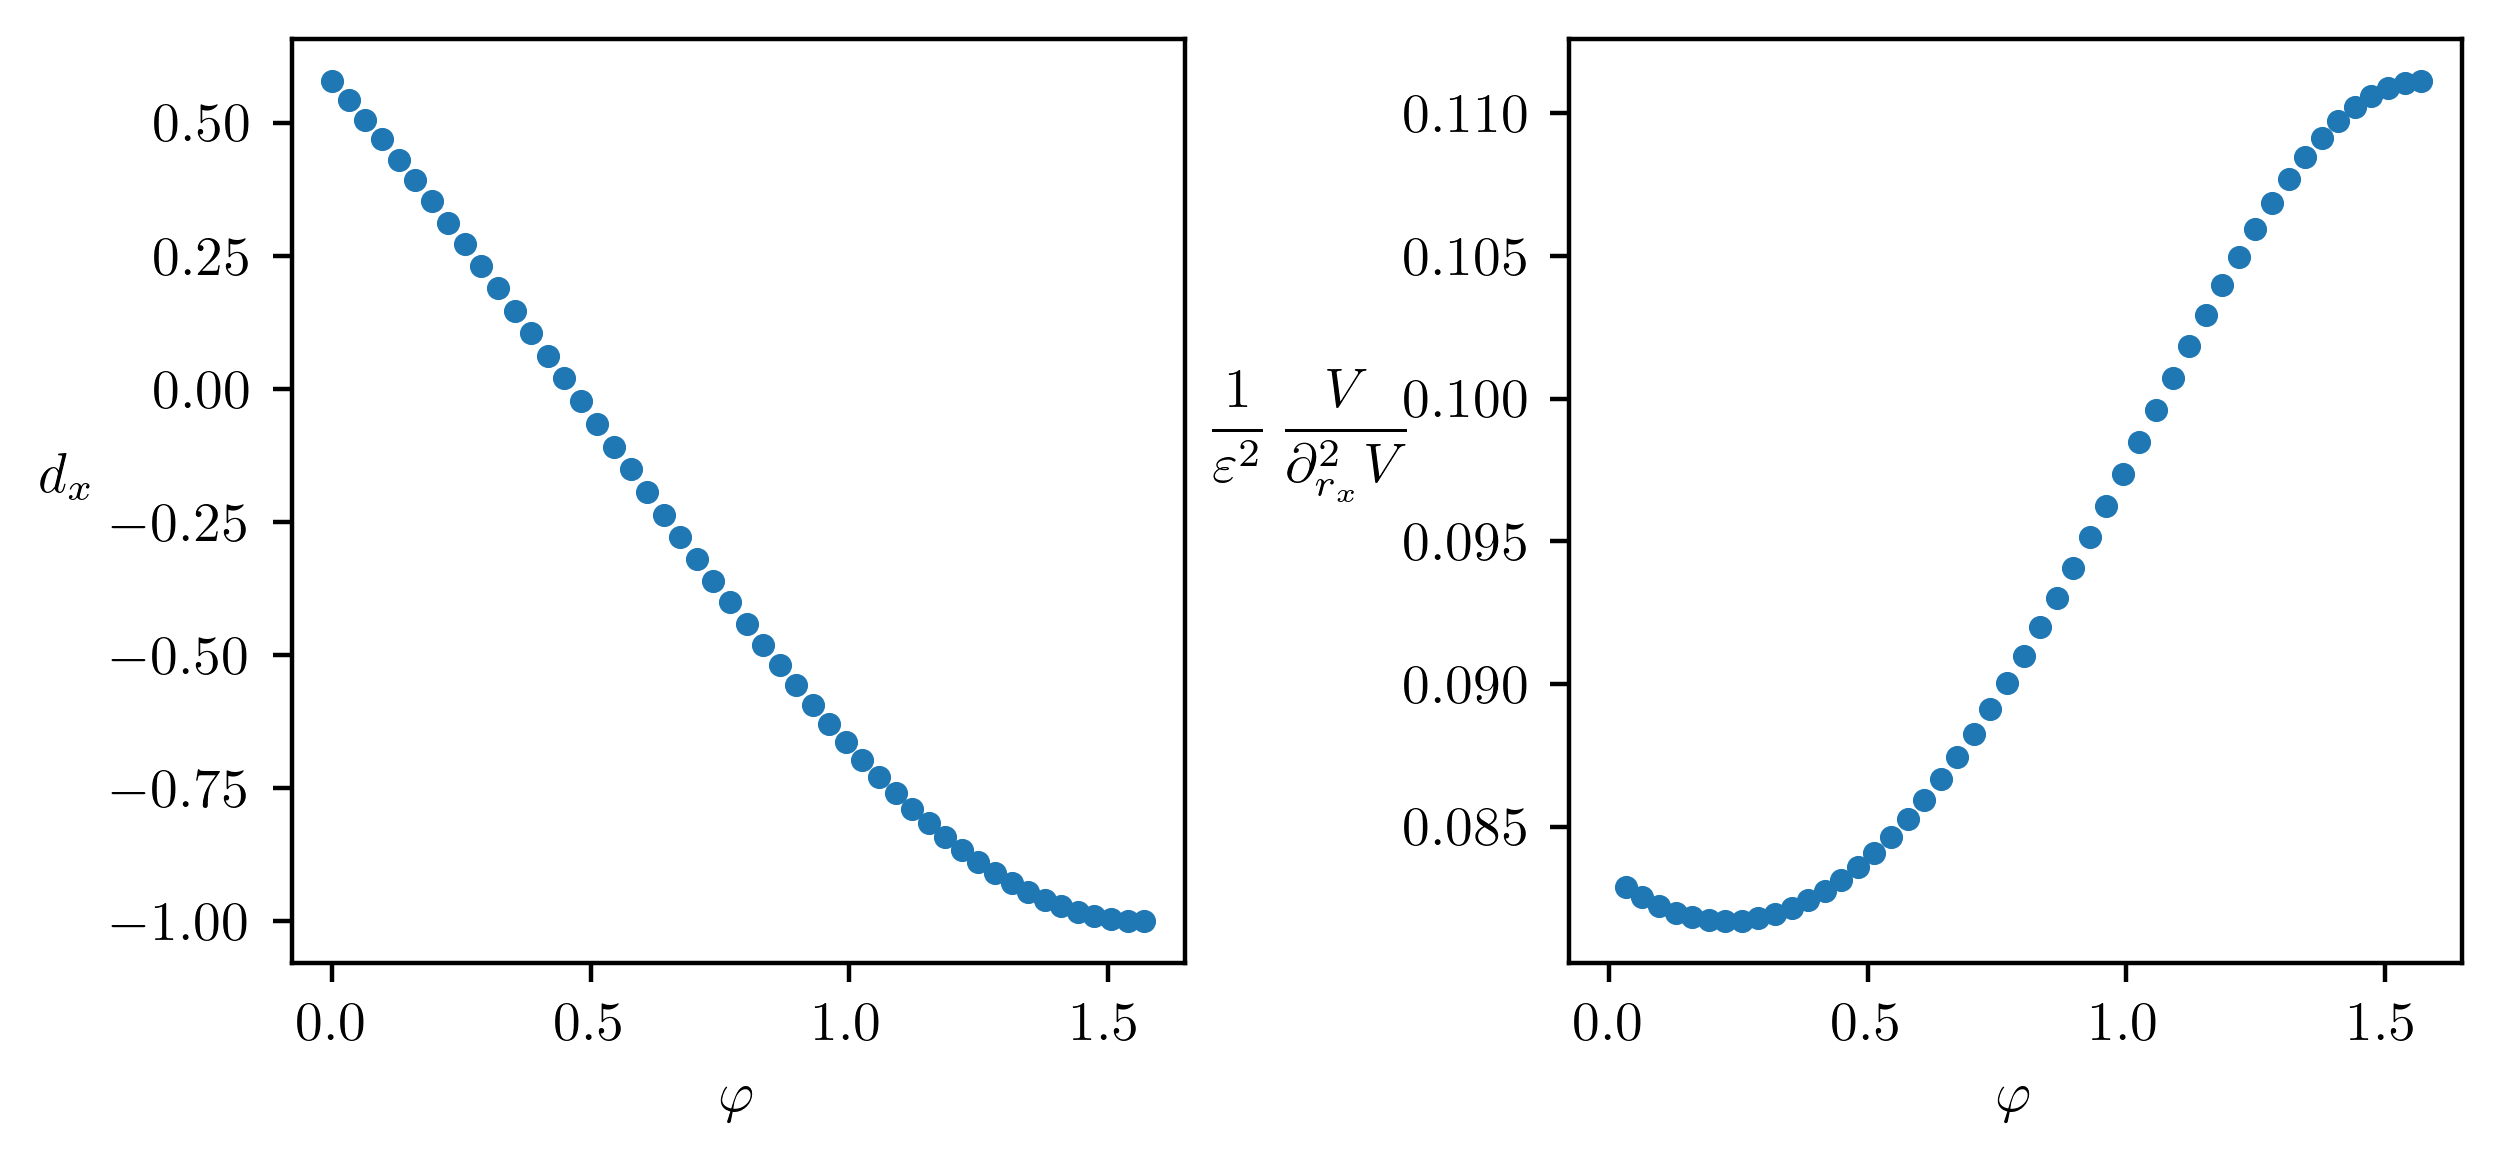

In [ ]:
from scipy.optimize import root_scalar
phi =  np.linspace(0,np.pi/2)

def func(dx,phi):
    rx = np.cos(phi)
    ry = np.sin(phi)
    dy = np.sqrt(1-dx**2)
    f = -3*rx + 15*rx*(rx*dx+ry*dy)**2-6*dx*(rx*dx+ry*dy)
    return f
dip = np.zeros(len(phi))
dip2 = np.zeros(len(phi))
V = np.zeros_like(phi)
Vder = np.zeros_like(phi)
for i in range(len(phi)):
    bracket = (max(-1,0-phi[i]/2*2.8),max(0,0.7-phi[i]/2))
    # bracket = (0,1)
    if func(bracket[0],phi[i])*func(bracket[1],phi[i])<=0:
        root = root_scalar(func,args=phi[i],bracket=bracket)
        # root = root_scalar(func,args=phi[i],x0=0)
        dip[i] = root.root
        Vder[i] = dip_derivative_full(np.array([np.cos(phi[i]),np.sin(phi[i])]),0,0,np.array([dip[i],np.sqrt(1-dip[i]**2)]))
        V[i] = dip_dip(np.array([np.cos(phi[i]),np.sin(phi[i])]),np.array([dip[i],np.sqrt(1-dip[i]**2)]))
    root = root_scalar(func,args=phi[i],x0=0)
    dip2[i] = root.root
setup = Setup_Fig(name_of_plot='lam2_anal_ml.png',fig_width=7,fig_height=3,xax_share=True,joined=True)

fig, ax = setup.return_fig((1,2))
ax[0].scatter(phi,dip,s=10)
# ax.scatter(phi,dip2)
# ax.scatter(phi,np.cos(phi))
# plt.show()
# fig, ax = plt.subplots(1,1)
ax[1].scatter(phi,V/Vder,s=10)
# ax.scatter(phi,V)
# ax.scatter(phi,dip2)
ax[0].set_xlabel(r'$\varphi$')
ax[1].set_xlabel(r'$\varphi$')
ax[0].set_ylabel(r"$d_x$",rotation=0,labelpad=8)
ax[1].set_ylabel(r"$$\frac{1}{\varepsilon^2}\,\frac{V}{\partial_{r_x}^2 V}$$",rotation=0,labelpad=17)
plt.subplots_adjust(wspace=0.43)
# plt.savefig("/home/christian/Documents/master/protocol/pictures/"+"magnitude_dersqV_ifderVzero.pdf",bbox_inches='tight')#free_evol_1spto10coupling
#
plt.show()

In [ ]:
2*np.pi*86*c.u, c.hbar, c.u

(8.9727882246588e-25, 1.0545718176461565e-34, 1.66053906892e-27)

In [ ]:
import sympy as sp
from sympy import I
from sympy import shape, eye, zeros
from sympy.physics.quantum import TensorProduct

# ── Define symbols ────────────────────────────────────────────────────────────
# u, a, b, c, d, w, x, y, z, t = sp.symbols('u a b c d w x y z t')
u,v1 = sp.symbols('u v_1')
v, t, s, w, phib, phix, phiy = sp.symbols(r"v t s w phi_b phi_x phi_y",real=True)
# a = sp.sinh(t)*sp.exp(I*phia)
# b = sp.cosh(t)*sp.exp(I*phib)
# x = sp.sinh(s)*sp.exp(I*phix)
# y = sp.cosh(s)*sp.exp(I*phiy)
v1st = sp.conjugate(v1)
ust = sp.conjugate(u)
# ── Define a matrix ───────────────────────────────────────────────────────────
M = sp.Matrix([
    [v, u, 0, 0, 0, 0, v, u],
    [ust, v, 0, 0, 0, 0, ust, v],
    [0, 0, v, ust, v, ust, 0, 0],
    [0, 0, u, v, u, v, 0, 0],
    [0, 0, -v, -ust, -v, -ust, 0, 0],
    [0, 0, -u, -v, -u, -v, 0, 0],
    [-v, -u, 0, 0, 0, 0, -v, -u],
    [-ust, -v, 0, 0, 0, 0, -ust, -v]
])

M2 = sp.Matrix([
    [w, u, v, u],
    [ust, w, ust, v],
    [-v, -u, -w, -u],
    [-ust, -v, -ust, -w],
])

M1 = sp.Matrix([
    [w, t, v1, u],
    [t, -w, u, -v1],
    [v1st, ust, w, t],
    [ust, -v1st, t, -w],
])

M4 = sp.Matrix([
    [0, t, 0, u],
    [t, 0, u, 0],
    [0, ust, 0, t],
    [ust, 0, t, 0],
])

S1 = sp.Matrix([
    [1, 0, -1, 0],
    [1j, 0, 1j, 0],
    [0, 1, 0, -1],
    [0, 1j, 0, 1j],    
])/np.sqrt(2)


def symmetry_condition(mat):
    identity = eye(shape(mat)[0])
    return TensorProduct(mat.T,identity) - TensorProduct(identity,mat)

def vec_to_mat(vec):
    n = int(np.sqrt(shape(vec)[0]))
    mat = zeros(n,n)
    for i in range(n):
        mat[:,i] = vec[i*n:i*n+n]
    return mat

M3 = sp.Matrix([
    [w, u, 0,0],
    [ust, w, 0,0],
    [0,0, -w, -u],
    [0,0, -ust, -w],
])
# print("Matrix M:")
# sp.pprint(M)
display(M2)
# ── Invert ────────────────────────────────────────────────────────────────────
# ast = sp.conjugate(a)
# bst = sp.conjugate(b)
# cst = sp.conjugate(c)
# dst = sp.conjugate(d)
# wst = sp.conjugate(w)
# xst = sp.conjugate(x)
# yst = sp.conjugate(y)
# zst = sp.conjugate(z)
# x = symmetry_condition(M2)
# display(x)
# # sym = x.nullspace()
# for s in sym:
#     display(s)
#     display(vec_to_mat(s))
T = sp.Matrix([
    [0, 0, 0, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 1],
    [0, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 0, 0, 0, 0, 0, 0],
    [1, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 0, 0, 0]
])
# sp.pprint(T)
S = sp.Matrix([
    [1, 1, 0, 0, 1, 1, 0, 0],
    [1, -1, 0, 0, -1, 1, 0, 0],
    [0, 0, 1, 1, 0, 0, 1, 1],
    [0, 0, 1, -1, 0, 0, -1, 1],
    [1, 1, 0, 0, -1, -1, 0, 0],
    [1, -1, 0, 0, 1, -1, 0, 0],
    [0, 0, 1, 1, 0, 0, -1, -1],
    [0, 0, 1, -1, 0, 0, 1, -1]
])/2
# T_inv = T.inv()#method="ADJ")
S2 = sp.Matrix([
    [1, 0, 1, 0],
    [0, 1, 0, 1],
    [1, 0, -1, 0],
    [0, 1, 0, -1],    
])/np.sqrt(2)

J = sp.Matrix([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, -1, 0],
    [0, 0, 0, -1],    
])

T2 = sp.Matrix([
    [0, 0, 1, 0],
    [0, 0, 0, 1],
    [1, 0, 0, 0],
    [0, 1, 0, 0],
])
# print("\nInverse of T:")
# sp.pprint(S@M@S.T)
# T2@M2@T2.T+M2
# S2@M2@S2.T
# display(S1.conjugate().T)
display(M1)
sp.simplify(S1.conjugate().T@M1@S1)
# sp.pprint(T@M@T)
# # print(T_inv) 
# T_inv = sp.simplify(T_inv)
# # display(T_inv)
# M_prime = T_inv @ M @ T
# M_prime = sp.simplify(M_prime)
# S2*J*S2.T
# # ── Simplify if needed ────────────────────────────────────────────────────────
# M_inv_simplified = sp.simplify(M_inv)
# print("\nSimplified inverse:")
# sp.pprint(M_inv_simplified)

# # ── Verify: M * M_inv should be identity ─────────────────────────────────────
# identity_check = sp.simplify(T @ T_inv)
# print("\nM @ M_inv (should be identity):")
# sp.pprint(identity_check)

Matrix([
[            w,  u,             v,  u],
[ conjugate(u),  w,  conjugate(u),  v],
[           -v, -u,            -w, -u],
[-conjugate(u), -v, -conjugate(u), -w]])

Matrix([
[             w,               t, v_1,    u],
[             t,              -w,   u, -v_1],
[conjugate(v_1),    conjugate(u),   w,    t],
[  conjugate(u), -conjugate(v_1),   t,   -w]])

Matrix([
[                                       0,                  0,                         1.0*I*t - 1.0*w, 1.0*I*u - 1.0*v_1],
[                                       0,                  0, 1.0*I*conjugate(u) - 1.0*conjugate(v_1),   1.0*I*t - 1.0*w],
[                        -1.0*I*t - 1.0*w, -1.0*I*u - 1.0*v_1,                                       0,                 0],
[-1.0*I*conjugate(u) - 1.0*conjugate(v_1),   -1.0*I*t - 1.0*w,                                       0,                 0]])

In [ ]:
eigen = M2.T.eigenvals()
for eig, mul in eigen.items():
    display(sp.simplify(sp.expand(eig)))

-sqrt(-v**2 + w**2 - 2*sqrt(u*(v**2 - 2*v*w + w**2)*conjugate(u)))

-sqrt(-v**2 + w**2 + 2*sqrt(u*(v**2 - 2*v*w + w**2)*conjugate(u)))

sqrt(-v**2 + w**2 - 2*sqrt(u*(v**2 - 2*v*w + w**2)*conjugate(u)))

sqrt(-v**2 + w**2 + 2*sqrt(u*(v**2 - 2*v*w + w**2)*conjugate(u)))

In [ ]:
# eigen = M2.T.eigenvects()
for i in range(len(eigen)):
    display(sp.simplify(eigen[i][0].subs(v**2-2*v*w+w**2,(v-w)**2)))
    display(sp.simplify(sp.simplify(eigen[i][2][0].subs(v**2-2*v*w+w**2,(v-w)**2))))

-sqrt(-v**2 + w**2 - 2*sqrt(u*conjugate(u))*Abs(v - w))

Matrix([
[(2*u**2*v**2*conjugate(u)**2 - 4*u**2*v*w*conjugate(u)**2 + 2*u**2*w**2*conjugate(u)**2 + 9*u*v**4*conjugate(u) - 21*u*v**3*w*conjugate(u) - 2*u*v**2*w**2*conjugate(u) - 10*u*v**2*w*sqrt(-v**2 + w**2 - 2*sqrt(u*(v**2 - 2*v*w + w**2)*conjugate(u)))*conjugate(u) + 7*u*v**2*sqrt(u*(v**2 - 2*v*w + w**2)*conjugate(u))*conjugate(u) + 30*u*v*w**3*conjugate(u) + 18*u*v*w**2*sqrt(-v**2 + w**2 - 2*sqrt(u*(v**2 - 2*v*w + w**2)*conjugate(u)))*conjugate(u) - 10*u*v*w*sqrt(u*(v**2 - 2*v*w + w**2)*conjugate(u))*conjugate(u) - 16*u*w**4*conjugate(u) - 8*u*w**3*sqrt(-v**2 + w**2 - 2*sqrt(u*(v**2 - 2*v*w + w**2)*conjugate(u)))*conjugate(u) + 2*u*w**2*sqrt(u*(v**2 - 2*v*w + w**2)*conjugate(u))*conjugate(u) - 2*u*w*sqrt(u*(v**2 - 2*v*w + w**2)*conjugate(u))*sqrt(-v**2 + w**2 - 2*sqrt(u*(v**2 - 2*v*w + w**2)*conjugate(u)))*conjugate(u) + v**6 - v**5*w - 8*v**4*w**2 - 4*v**4*w*sqrt(-v**2 + w**2 - 2*sqrt(u*(v**2 - 2*v*w + w**2)*conjugate(u))) + 5*v**4*sqrt(u*(v**2 - 2*v*w + w**2)*conjugate(u)) + 8*

sqrt(-v**2 + w**2 - 2*sqrt(u*conjugate(u))*Abs(v - w))

Matrix([
[(2*u**2*v**2*conjugate(u)**2 - 4*u**2*v*w*conjugate(u)**2 + 2*u**2*w**2*conjugate(u)**2 + 9*u*v**4*conjugate(u) - 21*u*v**3*w*conjugate(u) - 2*u*v**2*w**2*conjugate(u) + 10*u*v**2*w*sqrt(-v**2 + w**2 - 2*sqrt(u*(v**2 - 2*v*w + w**2)*conjugate(u)))*conjugate(u) + 7*u*v**2*sqrt(u*(v**2 - 2*v*w + w**2)*conjugate(u))*conjugate(u) + 30*u*v*w**3*conjugate(u) - 18*u*v*w**2*sqrt(-v**2 + w**2 - 2*sqrt(u*(v**2 - 2*v*w + w**2)*conjugate(u)))*conjugate(u) - 10*u*v*w*sqrt(u*(v**2 - 2*v*w + w**2)*conjugate(u))*conjugate(u) - 16*u*w**4*conjugate(u) + 8*u*w**3*sqrt(-v**2 + w**2 - 2*sqrt(u*(v**2 - 2*v*w + w**2)*conjugate(u)))*conjugate(u) + 2*u*w**2*sqrt(u*(v**2 - 2*v*w + w**2)*conjugate(u))*conjugate(u) + 2*u*w*sqrt(u*(v**2 - 2*v*w + w**2)*conjugate(u))*sqrt(-v**2 + w**2 - 2*sqrt(u*(v**2 - 2*v*w + w**2)*conjugate(u)))*conjugate(u) + v**6 - v**5*w - 8*v**4*w**2 + 4*v**4*w*sqrt(-v**2 + w**2 - 2*sqrt(u*(v**2 - 2*v*w + w**2)*conjugate(u))) + 5*v**4*sqrt(u*(v**2 - 2*v*w + w**2)*conjugate(u)) + 8*

-sqrt(-v**2 + w**2 + 2*sqrt(u*conjugate(u))*Abs(v - w))

Matrix([
[(-2*u**2*v**2*conjugate(u)**2 + 4*u**2*v*w*conjugate(u)**2 - 2*u**2*w**2*conjugate(u)**2 - 9*u*v**4*conjugate(u) + 21*u*v**3*w*conjugate(u) + 2*u*v**2*w**2*conjugate(u) + 10*u*v**2*w*sqrt(-v**2 + w**2 + 2*sqrt(u*(v**2 - 2*v*w + w**2)*conjugate(u)))*conjugate(u) + 7*u*v**2*sqrt(u*(v**2 - 2*v*w + w**2)*conjugate(u))*conjugate(u) - 30*u*v*w**3*conjugate(u) - 18*u*v*w**2*sqrt(-v**2 + w**2 + 2*sqrt(u*(v**2 - 2*v*w + w**2)*conjugate(u)))*conjugate(u) - 10*u*v*w*sqrt(u*(v**2 - 2*v*w + w**2)*conjugate(u))*conjugate(u) + 16*u*w**4*conjugate(u) + 8*u*w**3*sqrt(-v**2 + w**2 + 2*sqrt(u*(v**2 - 2*v*w + w**2)*conjugate(u)))*conjugate(u) + 2*u*w**2*sqrt(u*(v**2 - 2*v*w + w**2)*conjugate(u))*conjugate(u) - 2*u*w*sqrt(u*(v**2 - 2*v*w + w**2)*conjugate(u))*sqrt(-v**2 + w**2 + 2*sqrt(u*(v**2 - 2*v*w + w**2)*conjugate(u)))*conjugate(u) - v**6 + v**5*w + 8*v**4*w**2 + 4*v**4*w*sqrt(-v**2 + w**2 + 2*sqrt(u*(v**2 - 2*v*w + w**2)*conjugate(u))) + 5*v**4*sqrt(u*(v**2 - 2*v*w + w**2)*conjugate(u)) - 8

sqrt(-v**2 + w**2 + 2*sqrt(u*conjugate(u))*Abs(v - w))

Matrix([
[(-2*u**2*v**2*conjugate(u)**2 + 4*u**2*v*w*conjugate(u)**2 - 2*u**2*w**2*conjugate(u)**2 - 9*u*v**4*conjugate(u) + 21*u*v**3*w*conjugate(u) + 2*u*v**2*w**2*conjugate(u) - 10*u*v**2*w*sqrt(-v**2 + w**2 + 2*sqrt(u*(v**2 - 2*v*w + w**2)*conjugate(u)))*conjugate(u) + 7*u*v**2*sqrt(u*(v**2 - 2*v*w + w**2)*conjugate(u))*conjugate(u) - 30*u*v*w**3*conjugate(u) + 18*u*v*w**2*sqrt(-v**2 + w**2 + 2*sqrt(u*(v**2 - 2*v*w + w**2)*conjugate(u)))*conjugate(u) - 10*u*v*w*sqrt(u*(v**2 - 2*v*w + w**2)*conjugate(u))*conjugate(u) + 16*u*w**4*conjugate(u) - 8*u*w**3*sqrt(-v**2 + w**2 + 2*sqrt(u*(v**2 - 2*v*w + w**2)*conjugate(u)))*conjugate(u) + 2*u*w**2*sqrt(u*(v**2 - 2*v*w + w**2)*conjugate(u))*conjugate(u) + 2*u*w*sqrt(u*(v**2 - 2*v*w + w**2)*conjugate(u))*sqrt(-v**2 + w**2 + 2*sqrt(u*(v**2 - 2*v*w + w**2)*conjugate(u)))*conjugate(u) - v**6 + v**5*w + 8*v**4*w**2 - 4*v**4*w*sqrt(-v**2 + w**2 + 2*sqrt(u*(v**2 - 2*v*w + w**2)*conjugate(u))) + 5*v**4*sqrt(u*(v**2 - 2*v*w + w**2)*conjugate(u)) - 8

In [ ]:
180-80*np.sqrt(5)-8+12/15+16*np.sqrt(3/15)

np.float64(1.0699793280161423)

In [ ]:
# mpp = M_prime.subs(sp.cosh(t),-sp.sinh(t)*sp.exp(I*(phia+phib)))
# mpp = mpp.subs(sp.cosh(s),-sp.sinh(s)*sp.exp(I*(phix+phiy)))
# mpp = M_prime.subs(t,0)
# # mpp = sp.simplify(mpp)
# display(mpp)
M_prime

Matrix([
[                                  -v*(exp(I*(phi_a + phi_b))*sinh(t) - cosh(t))*(exp(I*(phi_a + phi_b))*cosh(t) + sinh(t))*exp(-I*(phi_a + phi_b)), -u*(exp(I*phi_a)*cosh(s) + exp(I*(phi_a + phi_x + phi_y))*sinh(s))*(exp(I*(phi_a + phi_b))*cosh(t) + sinh(t))*exp(-I*(2*phi_a + phi_y)),                                                                                                                                       0,                                                                                                                                                  0,                                                                                                                                       0,                                                                                                                                                  0,                                                                          -v*(exp(2*I*(phi_a + phi_b))*cosh(t)**2 - cosh(t)**2 + 1)*exp(